# Frame-to-Trial Alignment

This notebook aligns video frames with behavioral trials, accounting for extra trigger frames.

## Problem
- Video captured at 40 FPS (0.025s per frame) with trial-based triggers
- If a trial length is NOT an exact multiple of 0.025s (±0.0001s tolerance), an extra trigger is sent
- This creates ~N extra frames for N trials (where not exact multiples)
- These extra frames are unreliable and should be skipped

## Solution
For each trial:
1. Read trial length from `SessionData.RawEvents.Trial{1,t}.States.TrialEnd[1]`
2. Calculate expected frames: `M = floor(trial_length * 40)`
3. Check if `trial_length % 0.025` is within tolerance
4. If NOT exact multiple: use M frames, skip the (M+1)th frame
5. If exact multiple: use all frames

## Output
- `aligned_data`: DataFrame with tracking data + metadata
  - `trial_idx`: Trial number (0-indexed)
  - `frame_idx_global`: Original frame index in video
  - `frame_idx_in_trial`: Frame index within trial
  - `frame_time_in_trial`: Time relative to trial start (seconds)
  - `frame_time_absolute`: Absolute session time (seconds)
  - All DLC tracking columns

## Usage with Spike Times
Since spike times are trial-relative, use `trial_idx` and `frame_time_in_trial` to match spikes with frames.

In [2182]:
import scipy.io
import pandas as pd
# import mat73
import h5py
import numpy as np
import pickle
from pathlib import Path
import glob


# Update the subject and session variables to match the mouse and the date in your file names
subject = 'NPC4'
session = '19/05/2026'

YY = session[-2:]
YYYY = session[-4:]
MM = session[3:5]
DD = session[:2]

DD_MM_YYYY = f"{DD}_{MM}_{YYYY}"
MM_DD_YYYY = f"{MM}_{DD}_{YYYY}"

# Load the .mat file
# spike_clusters = scipy.io.loadmat(rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD}_{MM}_{YYYY}/aligned_spike_clusters.mat')
# spike_times = scipy.io.loadmat(rf'/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD}_{MM}_{YYYY}/aligned_spike_times.mat')
# cluster_info = pd.read_csv(r'F:\NPC2\kilosort_output\NPC2_27_11_2025_1\catgt\catgt_NPC2_27_11_2025_g0\NPC2_27_11_2025_g0_imec0\imec0_ks4\cluster_info.tsv', sep='\t')
# file_data = pd.read_csv(rf"/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD}_{MM}_{YYYY}/{subject}_10092025_1_g0_ct_offsets.txt", sep='\t')

# Extract the specific array by row index (sec_imap0 is in row 1)
# start_times = file_data.iloc[1].values

# start_times = start_times[1:]

# start_times = start_times + 1

# Find the .mat file with any 6 digits before the extension
mat_files = glob.glob(rf"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/{subject}/maze_pairs_fix/Session Data/{subject}_maze_pairs_fix*_{YYYY}{MM}{DD}_*.mat")
if mat_files:
    bpod_file = Path(mat_files[0]).name
else:
    raise FileNotFoundError(f"No .mat file found for date {YYYY}{MM}{DD}")
# bpod_file = f'{subject}_maze_pairs_fix_{YYYY}{MM}{DD}_115442.mat' # .mat file

# Load the .h5 file
h5_file_path = rf"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_trackings/{subject}_{YYYY}_{MM}_{DD}_corrected.h5"

h5_file = pd.read_hdf(h5_file_path)


def normalize_tracking_columns(df):
    """Bring a tracking file to the (bodypart, coord) layout used downstream.

    DLC exports two column levels; the newer heatmap tracker adds a leading
    'scorer' level and lower-cases ear_R. Everything after this cell indexes
    columns as ('headstage', 'x'), so normalise here rather than in each user.
    """
    cols = df.columns
    if getattr(cols, "nlevels", 1) > 2:
        extra = sorted(set(cols.get_level_values(0)))
        df = df.copy()
        df.columns = cols.droplevel(0)
        print(f"  tracking: dropped leading column level {extra}")
    canonical = {"ear_r": "ear_R", "ear_l": "ear_L"}
    if getattr(df.columns, "nlevels", 1) == 2:
        renamed = [(canonical.get(str(b), str(b)), c) for b, c in df.columns]
        if renamed != list(df.columns):
            changed = {b for (b, _), (nb_, _) in zip(df.columns, renamed) if b != nb_}
            df = df.copy()
            df.columns = pd.MultiIndex.from_tuples(renamed)
            print(f"  tracking: renamed bodyparts {sorted(changed)} to canonical case")
    return df


h5_file = normalize_tracking_columns(h5_file)
print(f"  tracking: {len(h5_file)} frames, bodyparts "
      f"{list(dict.fromkeys(c[0] for c in h5_file.columns))}")

maze_video_path = rf"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_videos/{subject}_{YYYY}_{MM}_{DD}.mp4"
bpod_data = scipy.io.loadmat(rf"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/{subject}/maze_pairs_fix/Session Data/{bpod_file}")
session_data = bpod_data['SessionData']

# Access a specific variable (replace 'variable_name' with actual variable name)
# data = mat_data['variable_name']

  tracking: dropped leading column level ['heatmap_tracker']
  tracking: renamed bodyparts ['ear_r'] to canonical case
  tracking: 128489 frames, bodyparts ['headstage', 'ear_L', 'ear_R', 'midbody', 'tailbase']


## Port layout configuration

Single source of truth for which maze node each reward port sits on, per subject and per date range.
`reward_leaf_parents`, `ports`, `port_map`, `inv_port_map`, `pairs_to_check` and
`port_parent_grandparents` are all derived from it below.


In [2183]:
# ============================================================================
# Port layout — set every reward port here, once, for the whole notebook.
# ============================================================================
# PORT_LAYOUTS[subject] is a list of layout periods:
#     (valid_from, valid_until, {port number: (leaf node, [parent node(s)])})
# Dates are 'DD/MM/YYYY' and inclusive; None means open-ended. The first period
# whose window contains `session` wins, so a mouse whose ports were re-wired
# mid-experiment simply gets another period. To add a mouse, add a key here —
# no other cell in the notebook needs editing.
PORT_LAYOUTS = {
    'NPC1': [
        # Up to 06/09/2025 — Port 7 = R55, Port 8 = R59
        (None, '06/09/2025', {
            1: ('R522', ['R411']),
            2: ('R526', ['R413']),
            3: ('L56',  ['L43']),
            4: ('L510', ['L45']),
            5: ('L521', ['L410']),
            6: ('L525', ['L412']),
            7: ('R55',  ['R42']),
            8: ('R59',  ['R44']),
        }),
        # From 07/09/2025 — Ports 7 and 8 swapped
        ('07/09/2025', None, {
            1: ('R522', ['R411']),
            2: ('R526', ['R413']),
            3: ('L56',  ['L43']),
            4: ('L510', ['L45']),
            5: ('L521', ['L410']),
            6: ('L525', ['L412']),
            7: ('R59',  ['R44']),
            8: ('R55',  ['R42']),
        }),
    ],

    # From 01/04/2026 — same maze as NPC1, Ports 3 and 4 swapped
    'NPC4': [
        ('01/04/2026', None, {
            1: ('R522', ['R411']),
            2: ('R526', ['R413']),
            3: ('L510', ['L45']),
            4: ('L56',  ['L43']),
            5: ('L521', ['L410']),
            6: ('L525', ['L412']),
            7: ('R59',  ['R44']),
            8: ('R55',  ['R42']),
        }),
    ],
}

# Reward-port pairs the animal alternates between, given as BPOD port numbers so
# they survive any re-wiring. Add a subject key to PORT_PAIRS_BY_SUBJECT to
# override for one mouse.
PORT_PAIRS = [(1, 2), (3, 4), (5, 6), (7, 8)]
PORT_PAIRS_BY_SUBJECT = {}

# Maze structure: parent node -> its grandparent neighbours. A property of the
# maze graph rather than of the wiring, so it is shared by all subjects.
GRANDPARENTS = {
    'R411': ['R523', 'R35'],
    'R413': ['R527', 'R36'],
    'L43':  ['L57',  'L31'],
    'L45':  ['L511', 'L32'],
    'L410': ['L520', 'L35'],
    'L412': ['L524', 'L36'],
    'R44':  ['R58',  'R32'],
    'R42':  ['R54',  'R31'],
}


# Figures are written under Graphs/<subject>/..., which does not exist for a
# mouse the first time it is analysed. Wrap every save path in ensure_dir() so
# the folder is created on demand instead of raising FileNotFoundError.
def ensure_dir(path):
    """Create the parent folder of `path` if needed and return `path`."""
    from pathlib import Path as _Path
    _Path(path).parent.mkdir(parents=True, exist_ok=True)
    return path


def _date_key(d):
    """'DD/MM/YYYY' -> sortable ('YYYY', 'MM', 'DD'); None passes through."""
    return None if d is None else (d[6:10], d[3:5], d[0:2])


def resolve_port_layout(subject, session, layouts=PORT_LAYOUTS):
    """Return {port number: (leaf node, [parent node(s)])} for this session."""
    if subject not in layouts:
        raise KeyError(
            f"No port layout defined for subject {subject!r}. "
            f"Add an entry to PORT_LAYOUTS (defined: {sorted(layouts)})."
        )
    s = _date_key(session)
    for valid_from, valid_until, layout in layouts[subject]:
        lo, hi = _date_key(valid_from), _date_key(valid_until)
        if (lo is None or lo <= s) and (hi is None or s <= hi):
            return layout
    raise KeyError(
        f"No port layout period covers {subject} on {session}. "
        f"Widen a date window in PORT_LAYOUTS['{subject}']."
    )


# ── Everything below is derived — nothing here needs editing per subject ─────
reward_leaf_parents = resolve_port_layout(subject, session)
port_numbers   = sorted(reward_leaf_parents)
port_nodes     = [reward_leaf_parents[p][0] for p in port_numbers]   # leaf nodes, port order
ports          = port_nodes   # alias; prefer port_nodes — `ports` is rebound by a later cell
port_map       = {reward_leaf_parents[p][0]: f'Target{p}' for p in port_numbers}
inv_port_map   = {label: node for node, label in port_map.items()}
pairs_to_check = [(reward_leaf_parents[a][0], reward_leaf_parents[b][0])
                  for a, b in PORT_PAIRS_BY_SUBJECT.get(subject, PORT_PAIRS)]
port_parent_grandparents = {
    p: {'parent': reward_leaf_parents[p][1][0],
        'grandparents': GRANDPARENTS.get(reward_leaf_parents[p][1][0], [])}
    for p in port_numbers
}

_missing = [p for p in port_numbers if not GRANDPARENTS.get(reward_leaf_parents[p][1][0])]
if _missing:
    print(f"⚠️  No GRANDPARENTS entry for the parent of port(s) {_missing} — "
          f"add them above if the port-parent-grandparent analysis is used.")

print(f"✓ Port layout for {subject}, session {session}:")
for p in port_numbers:
    leaf, parents = reward_leaf_parents[p]
    print(f"   Port {p}: {leaf:>5s} -> Target{p}   parent: {parents[0]}   "
          f"grandparents: {port_parent_grandparents[p]['grandparents']}")
print(f"   Alternation pairs: {pairs_to_check}")


✓ Port layout for NPC4, session 19/05/2026:
   Port 1:  R522 -> Target1   parent: R411   grandparents: ['R523', 'R35']
   Port 2:  R526 -> Target2   parent: R413   grandparents: ['R527', 'R36']
   Port 3:  L510 -> Target3   parent: L45   grandparents: ['L511', 'L32']
   Port 4:   L56 -> Target4   parent: L43   grandparents: ['L57', 'L31']
   Port 5:  L521 -> Target5   parent: L410   grandparents: ['L520', 'L35']
   Port 6:  L525 -> Target6   parent: L412   grandparents: ['L524', 'L36']
   Port 7:   R59 -> Target7   parent: R44   grandparents: ['R58', 'R32']
   Port 8:   R55 -> Target8   parent: R42   grandparents: ['R54', 'R31']
   Alternation pairs: [('R522', 'R526'), ('L510', 'L56'), ('L521', 'L525'), ('R59', 'R55')]


In [2184]:

# Auto-load results_file from the session date folder
navigraph_raw_data_dir = Path('/var/home/almogmeir/Documents/M.Sc/Project/Input/Navigraph_Raw_Data') / subject

results_files = sorted(glob.glob(str(navigraph_raw_data_dir / DD_MM_YYYY / 'session_metrics_*.pkl')))
if not results_files:
    raise FileNotFoundError(f"No session_metrics_*.pkl found in {navigraph_raw_data_dir / DD_MM_YYYY}")
results_file = Path(results_files[-1])
print(f"Loaded results_file: {results_file}")

with open(results_file, 'rb') as f:
    results = pickle.load(f)

metrics = results['session_results'][0]['metrics']
jumps = metrics.get('tracking_jumps', {}) or {}
flow = metrics.get('transition_flow', {}) or {}
traversal_data = metrics.get('traversal_sequence', {}) or {}


Loaded results_file: /var/home/almogmeir/Documents/M.Sc/Project/Input/Navigraph_Raw_Data/NPC4/19_05_2026/session_metrics_20260903_121921.pkl


In [2185]:
# Load NaviGraph output with graph locations
import pickle


navigraph_pkl_files = sorted(glob.glob(str(navigraph_raw_data_dir / DD_MM_YYYY / 'raw_session_data_*.pkl')))
if not navigraph_pkl_files:
    raise FileNotFoundError(f"No raw_session_data_*.pkl found in {navigraph_raw_data_dir / DD_MM_YYYY}")
navigraph_pkl_path = navigraph_pkl_files[-1]
print(f"Loaded navigraph_pkl_path: {navigraph_pkl_path}")


with open(navigraph_pkl_path, 'rb') as f:
    navigraph_data = pickle.load(f)

print("NaviGraph data structure:")
print(f"Type: {type(navigraph_data)}")
if isinstance(navigraph_data, dict):
    print(f"Keys: {navigraph_data.keys()}")
elif isinstance(navigraph_data, pd.DataFrame):
    print(f"Shape: {navigraph_data.shape}")
    print(f"Columns: {navigraph_data.columns.tolist()[:10]}")
    print(f"\nFirst few rows:")
    print(navigraph_data.head())


Loaded navigraph_pkl_path: /var/home/almogmeir/Documents/M.Sc/Project/Input/Navigraph_Raw_Data/NPC4/19_05_2026/raw_session_data_20260903_121921.pkl
NaviGraph data structure:
Type: <class 'dict'>
Keys: dict_keys(['session_NPC4_19_05_2026', 'timestamp', 'experiment_path'])


In [2186]:
session_data['nTrials']

array([[array([[165]], dtype=uint8)]], dtype=object)

In [2187]:
h5_file

headstage                              ear_L                         \
                 x           y likelihood           x           y likelihood   
0       374.673859  688.107117   0.945964  366.140625  673.756836   0.936161   
1       384.999023  691.938232   0.966862  371.006714  677.282471   0.973281   
2       393.137421  689.981750   0.930411  376.293335  680.371948   0.978842   
3       399.171265  690.964539   0.982398  385.348145  683.598267   0.979047   
4       408.159760  691.375427   0.995808  399.503082  682.834717   0.997206   
...            ...         ...        ...         ...         ...        ...   
128484  906.941223  417.693604   0.990335  898.075684  425.506134   0.997619   
128485  906.789917  416.839203   0.989463  897.828979  424.934692   0.986586   
128486  907.569092  417.478485   0.989673  898.523499  424.656036   0.990994   
128487  906.467834  416.490265   0.993927  897.598877  424.217438   0.986239   
128488  906.248230  416.284241   0.996071  897.363525  424.258240   0.989043   

             ear_R                            midbody                         \
                 x           y likelihood           x           y likelihood   
0       358.672974  687.320190   0.887631  345.953186  663.298584   0.989526   
1       366.785919  690.824036   0.976439  348.289734  668.198853   0.998091   
2       373.905853  695.851379   0.937463  355.639252  674.094055   0.989760   
3       386.712860  698.500488   0.964300  364.833466  684.281616   0.995670   
4       396.944733  700.951538   0.988555  373.419525  688.765198   0.997035   
...            ...         ...        ...         ...         ...        ...   
128484  912.406067  430.487396   0.997825  903.750671  445.792297   0.999088   
128485  912.440918  429.806213   0.999560  904.003235  445.499146   0.999028   
128486  912.531799  429.627167   0.999639  904.008423  444.537628   0.999202   
128487  911.907349  429.048859   0.997350  903.635742  444.454987   0.999607   
128488  911.868469  429.047638   0.997777  903.638000  444.532806   0.999579   

          tailbase                         
                 x           y likelihood  
0       338.119415  643.458984   0.970307  
1       338.912048  649.479370   0.991506  
2       342.044312  657.684082   0.971112  
3       344.882843  666.116882   0.957171  
4       350.018738  677.319458   0.966636  
...            ...         ...        ...  
128484  900.892395  462.123932   0.988604  
128485  900.871094  462.248444   0.989249  
128486  900.682129  461.551727   0.993531  
128487  900.632935  461.668304   0.991576  
128488  900.858459  461.598236   0.989861  

[128489 rows x 15 columns]

In [2188]:
# Update to be the actual file name according to the first index column value of the h5 table
# table_name = 'DLC_Resnet101_Neuropixel_2Cams_GammaJul22shuffle6_snapshot_100'

# Load the DataFrame from the HDF5 file
# dlc_raw_h5 = h5_file[table_name]
dlc_raw_h5 = h5_file

# Extract the MultiIndex from the first two rows
multi_index = pd.MultiIndex.from_arrays([dlc_raw_h5.iloc[0], dlc_raw_h5.iloc[1]])

# Convert the data to numeric, errors='coerce' will turn non-numeric values into NaN
dlc_raw_h5 = dlc_raw_h5.apply(pd.to_numeric, errors='coerce')

new_index = pd.MultiIndex.from_tuples([
        ('weighted', 'x'),
        ('weighted', 'y'),
        ('weighted', 'likelihood')
    ])

new_index_df = pd.DataFrame(np.nan, index=range(len(dlc_raw_h5)), columns=new_index)


# Concatenate the original DataFrame with the new columns DataFrame
# dlc_raw_h5 = pd.concat([dlc_raw_h5, new_columns], axis=1)

dlc_raw_h5 = pd.concat([dlc_raw_h5, new_index_df], axis=1)
dlc_raw_h5

headstage                              ear_L                         \
                 x           y likelihood           x           y likelihood   
0       374.673859  688.107117   0.945964  366.140625  673.756836   0.936161   
1       384.999023  691.938232   0.966862  371.006714  677.282471   0.973281   
2       393.137421  689.981750   0.930411  376.293335  680.371948   0.978842   
3       399.171265  690.964539   0.982398  385.348145  683.598267   0.979047   
4       408.159760  691.375427   0.995808  399.503082  682.834717   0.997206   
...            ...         ...        ...         ...         ...        ...   
128484  906.941223  417.693604   0.990335  898.075684  425.506134   0.997619   
128485  906.789917  416.839203   0.989463  897.828979  424.934692   0.986586   
128486  907.569092  417.478485   0.989673  898.523499  424.656036   0.990994   
128487  906.467834  416.490265   0.993927  897.598877  424.217438   0.986239   
128488  906.248230  416.284241   0.996071  897.363525  424.258240   0.989043   

             ear_R                            midbody                         \
                 x           y likelihood           x           y likelihood   
0       358.672974  687.320190   0.887631  345.953186  663.298584   0.989526   
1       366.785919  690.824036   0.976439  348.289734  668.198853   0.998091   
2       373.905853  695.851379   0.937463  355.639252  674.094055   0.989760   
3       386.712860  698.500488   0.964300  364.833466  684.281616   0.995670   
4       396.944733  700.951538   0.988555  373.419525  688.765198   0.997035   
...            ...         ...        ...         ...         ...        ...   
128484  912.406067  430.487396   0.997825  903.750671  445.792297   0.999088   
128485  912.440918  429.806213   0.999560  904.003235  445.499146   0.999028   
128486  912.531799  429.627167   0.999639  904.008423  444.537628   0.999202   
128487  911.907349  429.048859   0.997350  903.635742  444.454987   0.999607   
128488  911.868469  429.047638   0.997777  903.638000  444.532806   0.999579   

          tailbase                        weighted                 
                 x           y likelihood        x   y likelihood  
0       338.119415  643.458984   0.970307      NaN NaN        NaN  
1       338.912048  649.479370   0.991506      NaN NaN        NaN  
2       342.044312  657.684082   0.971112      NaN NaN        NaN  
3       344.882843  666.116882   0.957171      NaN NaN        NaN  
4       350.018738  677.319458   0.966636      NaN NaN        NaN  
...            ...         ...        ...      ...  ..        ...  
128484  900.892395  462.123932   0.988604      NaN NaN        NaN  
128485  900.871094  462.248444   0.989249      NaN NaN        NaN  
128486  900.682129  461.551727   0.993531      NaN NaN        NaN  
128487  900.632935  461.668304   0.991576      NaN NaN        NaN  
128488  900.858459  461.598236   0.989861      NaN NaN        NaN  

[128489 rows x 18 columns]

In [2189]:
dlc_raw_h5 = h5_file

In [2190]:
# Explore the structure of the bpod_data and session_data
print("Keys in bpod_data:", bpod_data.keys())
print("\nType of SessionData:", type(session_data))
print("Shape of SessionData:", session_data.shape)
print("Dtype of SessionData:", session_data.dtype)

# If it's a structured array, check the field names
if hasattr(session_data, 'dtype') and session_data.dtype.names:
    print("\nField names in SessionData:", session_data.dtype.names)
    
# Check nTrials
print("\nnTrials:", session_data['nTrials'])
print("Type of nTrials:", type(session_data['nTrials']))

# Explore RawEvents structure
print("\nRawEvents type:", type(session_data['RawEvents']))
print("RawEvents shape:", session_data['RawEvents'].shape)
print("RawEvents dtype:", session_data['RawEvents'].dtype)

# Try to access the first element
raw_events = session_data['RawEvents'][0, 0]
print("\nType of RawEvents[0,0]:", type(raw_events))
if hasattr(raw_events, 'dtype') and raw_events.dtype.names:
    print("Field names in RawEvents[0,0]:", raw_events.dtype.names)
    
# Try to access Trial
if 'Trial' in raw_events.dtype.names:
    trial = raw_events['Trial']
    print("\nTrial type:", type(trial))
    print("Trial shape:", trial.shape)
    print("Trial dtype:", trial.dtype)
    
    # Access first trial
    if trial.shape[0] > 0:
        first_trial = trial[0, 0]
        print("\nFirst trial type:", type(first_trial))
        if hasattr(first_trial, 'dtype') and first_trial.dtype.names:
            print("Field names in first trial:", first_trial.dtype.names)
            
            # Try to access TrialEnd
            if 'TrialEnd' in first_trial.dtype.names:
                trial_end = first_trial['TrialEnd']
                print("\nTrialEnd:", trial_end)
                print("TrialEnd type:", type(trial_end))
                print("TrialEnd shape:", trial_end.shape if hasattr(trial_end, 'shape') else 'N/A')

Keys in bpod_data: dict_keys(['__header__', '__version__', '__globals__', 'SessionData', '__function_workspace__'])

Type of SessionData: <class 'numpy.ndarray'>
Shape of SessionData: (1, 1)
Dtype of SessionData: [('nTrials', 'O'), ('TrialTypes', 'O'), ('MATLABStartTimes', 'O'), ('Blocks', 'O'), ('DepletionSteps', 'O'), ('AllRewardSizes', 'O'), ('bitcode', 'O'), ('TrialRewardFlag', 'O'), ('DepletionRewardSize', 'O'), ('DepletionStep', 'O'), ('DepletionDivideStepIndex', 'O'), ('BehaviorORSpontaneous', 'O'), ('RewardMatrix', 'O'), ('Info', 'O'), ('SettingsFile', 'O'), ('RawEvents', 'O'), ('RawData', 'O'), ('TrialStartTimestamp', 'O'), ('TrialEndTimestamp', 'O'), ('TrialRewardSize', 'O')]

Field names in SessionData: ('nTrials', 'TrialTypes', 'MATLABStartTimes', 'Blocks', 'DepletionSteps', 'AllRewardSizes', 'bitcode', 'TrialRewardFlag', 'DepletionRewardSize', 'DepletionStep', 'DepletionDivideStepIndex', 'BehaviorORSpontaneous', 'RewardMatrix', 'Info', 'SettingsFile', 'RawEvents', 'RawData

In [2191]:
# Deeper exploration of trial structure
raw_events = session_data['RawEvents'][0, 0]
trial = raw_events['Trial'][0, 0]

print("Trial is a list/array with length:", len(trial) if hasattr(trial, '__len__') else 'N/A')
print("Type of trial[0]:", type(trial[0]) if hasattr(trial, '__getitem__') and len(trial) > 0 else 'N/A')

# Try to look at first few trials
if hasattr(trial, '__len__'):
    for i in range(min(3, len(trial))):
        print(f"\n--- Trial {i+1} ---")
        t = trial[i]
        print(f"Type: {type(t)}")
        if hasattr(t, 'dtype') and t.dtype.names:
            print(f"Fields: {t.dtype.names}")
            if 'TrialEnd' in t.dtype.names:
                trial_end = t['TrialEnd']
                print(f"TrialEnd: {trial_end}")
                print(f"TrialEnd shape: {trial_end.shape if hasattr(trial_end, 'shape') else 'N/A'}")
                print(f"TrialEnd value: {trial_end[0] if hasattr(trial_end, '__getitem__') and len(trial_end) > 0 else trial_end}")
        elif hasattr(t, '__len__') and len(t) > 0:
            print(f"Length: {len(t)}")
            print(f"First element type: {type(t[0])}")
            if hasattr(t[0], 'dtype') and hasattr(t[0].dtype, 'names') and t[0].dtype.names:
                print(f"First element fields: {t[0].dtype.names}")
                if 'TrialEnd' in t[0].dtype.names:
                    print(f"TrialEnd from [0]: {t[0]['TrialEnd']}")


Trial is a list/array with length: 1
Type of trial[0]: <class 'numpy.ndarray'>

--- Trial 1 ---
Type: <class 'numpy.ndarray'>
Length: 165
First element type: <class 'numpy.ndarray'>
First element fields: ('States', 'Events')


In [2192]:
# Access the actual trial array
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]  # This is the array of n trials

print(f"Number of trials: {len(trial_array)}")
print(f"Type of first trial: {type(trial_array[0])}")
print(f"First trial fields: {trial_array[0].dtype.names if hasattr(trial_array[0], 'dtype') else 'N/A'}")

# Check first trial structure
first_trial = trial_array[0]
print(f"\nFirst trial structure - type: {type(first_trial)}")
print(f"First trial shape: {first_trial.shape}")
if hasattr(first_trial, 'dtype') and first_trial.dtype.names:
    print(f"Fields: {first_trial.dtype.names}")
    
    # Check States
    if 'States' in first_trial.dtype.names:
        states = first_trial['States']
        print(f"\nStates type: {type(states)}")
        print(f"States shape: {states.shape if hasattr(states, 'shape') else 'N/A'}")
        
        # Access the actual states object
        if hasattr(states, '__len__') and len(states) > 0:
            states_obj = states[0] if states.shape == (1,) else states
            if hasattr(states_obj, 'dtype') and states_obj.dtype.names:
                print(f"States fields: {states_obj.dtype.names}")
                if 'TrialEnd' in states_obj.dtype.names:
                    print(f"TrialEnd found in States!")
                    trial_end = states_obj['TrialEnd']
                    print(f"TrialEnd: {trial_end}")
                    print(f"TrialEnd value: {trial_end[0] if hasattr(trial_end, '__getitem__') and len(trial_end) > 0 else trial_end}")


Number of trials: 165
Type of first trial: <class 'numpy.ndarray'>
First trial fields: ('States', 'Events')

First trial structure - type: <class 'numpy.ndarray'>
First trial shape: (1, 1)
Fields: ('States', 'Events')

States type: <class 'numpy.ndarray'>
States shape: (1, 1)


In [2193]:
# Continue deeper exploration
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]

first_trial = trial_array[0]
states = first_trial['States'][0, 0]

print(f"States type after [0,0]: {type(states)}")
if hasattr(states, 'dtype') and states.dtype.names:
    print(f"States fields: {states.dtype.names}")
    
    # Try to access TrialEnd
    if 'TrialEnd' in states.dtype.names:
        trial_end = states['TrialEnd']
        print(f"\nTrialEnd type: {type(trial_end)}")
        print(f"TrialEnd shape: {trial_end.shape if hasattr(trial_end, 'shape') else 'N/A'}")
        print(f"TrialEnd: {trial_end}")
        if hasattr(trial_end, '__len__') and len(trial_end) > 0:
            print(f"TrialEnd[0]: {trial_end[0]}")
            if hasattr(trial_end[0], '__len__') and len(trial_end[0]) > 0:
                print(f"TrialEnd[0][0]: {trial_end[0][0]}")

# Try multiple trials
print("\n\n=== First 5 Trials ===")
for i in range(min(5, len(trial_array))):
    trial = trial_array[i]
    states = trial['States'][0, 0]
    trial_end = states['TrialEnd']
    if hasattr(trial_end, '__len__') and len(trial_end) > 0:
        if hasattr(trial_end[0], '__len__'):
            value = trial_end[0][0] if len(trial_end[0]) > 0 else trial_end[0]
        else:
            value = trial_end[0]
    else:
        value = trial_end
    print(f"Trial {i+1}: TrialEnd = {value}")


States type after [0,0]: <class 'numpy.ndarray'>
States fields: ('TimerTrig1', 'TrialStart', 'MazeIntroduction', 'Reward6', 'CloseValve2', 'RewardConsumption', 'InterTrialInterval', 'TrialEnd', 'RepeatIntroduction', 'Reward1', 'Reward2', 'Reward3', 'Reward4', 'Reward5', 'Reward7', 'Reward8', 'CloseValve1', 'CloseValve3', 'CloseValve4')

TrialEnd type: <class 'numpy.ndarray'>
TrialEnd shape: (1, 1)
TrialEnd: [[array([[15.47, 15.52]])]]
TrialEnd[0]: [array([[15.47, 15.52]])]
TrialEnd[0][0]: [[15.47 15.52]]


=== First 5 Trials ===
Trial 1: TrialEnd = [[15.47 15.52]]
Trial 2: TrialEnd = [[3.1899 3.2399]]
Trial 3: TrialEnd = [[7.8036 7.8536]]
Trial 4: TrialEnd = [[5.3378 5.3878]]
Trial 5: TrialEnd = [[6.4813 6.5313]]


In [2194]:
# Extract trial end times for all trials
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]

n_trials = len(trial_array)
trial_end_times = []

for i in range(n_trials):
    trial = trial_array[i]
    states = trial['States'][0, 0]
    trial_end = states['TrialEnd']
    # Get the second value (end of TrialEnd state) as the trial length
    trial_length = trial_end[0][0][0][0]  # [0][0] to unwrap, [0] for first pair
    trial_end_times.append(trial_length)

trial_end_times = np.array(trial_end_times)
print(f"Number of trials: {len(trial_end_times)}")
print(f"First 10 trial end times: {trial_end_times[:10]}")


Number of trials: 165
First 10 trial end times: [15.47    3.1899  7.8036  5.3378  6.4813  5.0155  6.7376 15.7473  9.6603
  4.8263]


In [2195]:
len(trial_array)

165

In [2196]:
# Now create the frame-to-trial alignment
FPS = 40
FRAME_INTERVAL = 0.025  # 1/40
TOLERANCE = 0.0001

# Calculate expected frames per trial and detect extra frames
frame_data = []
current_frame_idx = 0

for trial_idx in range(len(trial_end_times)):
    trial_length = trial_end_times[trial_idx]
    
    # Calculate expected number of frames
    expected_frames = trial_length * FPS
    
    # Check if trial length is exact multiple of frame interval
    remainder = trial_length % FRAME_INTERVAL
    is_exact_multiple = remainder < TOLERANCE or (FRAME_INTERVAL - remainder) < TOLERANCE
    
    # Determine number of frames for this trial
    if is_exact_multiple:
        n_frames = int(np.round(expected_frames))
        has_extra_frame = False
    else:
        # Not exact multiple, so we have M+1 frames but should skip the M+1 frame
        n_frames = int(np.floor(expected_frames))  # Only take M frames
        has_extra_frame = True
    
    # Create frame entries for this trial
    for frame_in_trial in range(n_frames):
        frame_data.append({
            'trial_idx': trial_idx,
            'frame_idx_global': current_frame_idx,
            'frame_idx_in_trial': frame_in_trial,
            'frame_time_in_trial': frame_in_trial * FRAME_INTERVAL,
            'trial_length': trial_length,
            'is_exact_multiple': is_exact_multiple,
            'has_extra_frame': has_extra_frame
        })
        current_frame_idx += 1
    
    # Skip the extra frame if present
    if has_extra_frame:
        current_frame_idx += 1  # Skip the unreliable M+1 frame
        print(f"Trial {trial_idx}: Skipping extra frame at global index {current_frame_idx-1}")

# Create DataFrame
frames_df = pd.DataFrame(frame_data)

print(f"\nTotal frames in DataFrame: {len(frames_df)}")
print(f"Total frames in video (including skipped): {current_frame_idx}")
print(f"Number of extra frames skipped: {current_frame_idx - len(frames_df)}")
print(f"\nFirst few rows:")
print(frames_df.head(10))
print(f"\nLast few rows:")
print(frames_df.tail(10))


Trial 0: Skipping extra frame at global index 618
Trial 1: Skipping extra frame at global index 746
Trial 2: Skipping extra frame at global index 1059
Trial 3: Skipping extra frame at global index 1273
Trial 4: Skipping extra frame at global index 1533
Trial 5: Skipping extra frame at global index 1734
Trial 6: Skipping extra frame at global index 2004
Trial 7: Skipping extra frame at global index 2634
Trial 8: Skipping extra frame at global index 3021
Trial 9: Skipping extra frame at global index 3215
Trial 10: Skipping extra frame at global index 3427
Trial 11: Skipping extra frame at global index 3981
Trial 12: Skipping extra frame at global index 4943
Trial 13: Skipping extra frame at global index 21592
Trial 14: Skipping extra frame at global index 21814
Trial 15: Skipping extra frame at global index 22989
Trial 16: Skipping extra frame at global index 24201
Trial 17: Skipping extra frame at global index 24873
Trial 18: Skipping extra frame at global index 25045
Trial 19: Skipping

In [2197]:
# Check the alignment results
print(f"Total frames in DataFrame: {len(frames_df)}")
print(f"\nDataFrame columns: {frames_df.columns.tolist()}")
print(f"\nFirst 5 rows:")
print(frames_df.head())
print(f"\nLast 5 rows:")
print(frames_df.tail())

# Check trials with extra frames
extra_frame_trials = frames_df[frames_df['has_extra_frame'] == True]['trial_idx'].unique()
print(f"\n\nNumber of trials with extra frames: {len(extra_frame_trials)}")
print(f"First 10 trials with extra frames: {extra_frame_trials[:10]}")


Total frames in DataFrame: 128325

DataFrame columns: ['trial_idx', 'frame_idx_global', 'frame_idx_in_trial', 'frame_time_in_trial', 'trial_length', 'is_exact_multiple', 'has_extra_frame']

First 5 rows:
   trial_idx  frame_idx_global  frame_idx_in_trial  frame_time_in_trial  \
0          0                 0                   0                0.000   
1          0                 1                   1                0.025   
2          0                 2                   2                0.050   
3          0                 3                   3                0.075   
4          0                 4                   4                0.100   

   trial_length  is_exact_multiple  has_extra_frame  
0         15.47              False             True  
1         15.47              False             True  
2         15.47              False             True  
3         15.47              False             True  
4         15.47              False             True  

Last 5 rows:
       

In [2198]:
# Add the DLC tracking data to the DataFrame
# The frame_idx_global in frames_df corresponds to the row index in dlc_raw_h5

# First, let's check if the number of frames matches
print(f"Number of frames in frames_df: {len(frames_df)}")
print(f"Number of rows in dlc_raw_h5: {len(dlc_raw_h5)}")

# Filter out any frame indices that are out of bounds (can happen when trial-based
# frame calculation slightly overshoots the actual recording length)
max_valid_idx = len(dlc_raw_h5) - 1
out_of_bounds_mask = frames_df['frame_idx_global'] > max_valid_idx
if out_of_bounds_mask.any():
    print(f"Warning: {out_of_bounds_mask.sum()} frames have out-of-bounds indices "
          f"(max valid: {max_valid_idx}). These will be dropped.")
    frames_df = frames_df[~out_of_bounds_mask].copy()
    print(f"Remaining frames after filtering: {len(frames_df)}")

# Create a copy of the DLC data with only the frames we need
aligned_data = dlc_raw_h5.iloc[frames_df['frame_idx_global'].values].copy()

# Reset index to align with frames_df
aligned_data.reset_index(drop=True, inplace=True)
frames_df = frames_df.reset_index(drop=True)

# Combine the metadata from frames_df with the tracking data
# Need to ensure we're setting scalar values, not arrays
for col in frames_df.columns:
    # Create a Series with the metadata values
    aligned_data[(col, '')] = pd.Series(frames_df[col].values, index=aligned_data.index)

print(f"\nAligned data shape: {aligned_data.shape}")
print(f"\nFirst few rows of aligned data:")
print(aligned_data.head())


Number of frames in frames_df: 128325
Number of rows in dlc_raw_h5: 128489

Aligned data shape: (128325, 22)

First few rows of aligned data:
    headstage                              ear_L                         \
            x           y likelihood           x           y likelihood   
0  374.673859  688.107117   0.945964  366.140625  673.756836   0.936161   
1  384.999023  691.938232   0.966862  371.006714  677.282471   0.973281   
2  393.137421  689.981750   0.930411  376.293335  680.371948   0.978842   
3  399.171265  690.964539   0.982398  385.348145  683.598267   0.979047   
4  408.159760  691.375427   0.995808  399.503082  682.834717   0.997206   

        ear_R                            midbody  ...    tailbase              \
            x           y likelihood           x  ...           x           y   
0  358.672974  687.320190   0.887631  345.953186  ...  338.119415  643.458984   
1  366.785919  690.824036   0.976439  348.289734  ...  338.912048  649.479370   
2  373.9

In [2199]:
# Summary of the alignment
print("="*60)
print("FRAME-TO-TRIAL ALIGNMENT SUMMARY")
print("="*60)
print(f"\nTotal trials: {len(trial_end_times)}")
print(f"Total frames in video: {len(dlc_raw_h5)}")
print(f"Total aligned frames (after removing extra): {len(aligned_data)}")
print(f"Number of extra frames skipped: {len(dlc_raw_h5) - len(aligned_data)}")
print(f"Number of trials with extra frames: {len(extra_frame_trials)}")
print(f"Number of trials with exact frame timing: {len(trial_end_times) - len(extra_frame_trials)}")

# Show examples of extra frame trials
print("\n" + "="*60)
print("EXAMPLES OF EXTRA FRAME DETECTION")
print("="*60)
for i in range(min(5, len(extra_frame_trials))):
    trial_idx = extra_frame_trials[i]
    trial_length = trial_end_times[trial_idx]
    expected_frames = trial_length * FPS
    remainder = trial_length % FRAME_INTERVAL
    
    print(f"\nTrial {trial_idx}:")
    print(f"  Length: {trial_length:.4f} seconds")
    print(f"  Expected frames (M): {int(np.floor(expected_frames))}")
    print(f"  Remainder: {remainder:.6f} (tolerance: {TOLERANCE})")
    print(f"  Extra frame at global index: {frames_df[frames_df['trial_idx'] == trial_idx]['frame_idx_global'].max() + 1}")

print("\n" + "="*60)
print("DATA STRUCTURE")
print("="*60)
print(f"\nColumns in aligned_data:")
for col in aligned_data.columns[:10]:
    print(f"  {col}")
print("  ...")
print(f"\nMetadata columns added:")
print(f"  - trial_idx: Trial number (0-indexed)")
print(f"  - frame_idx_global: Original frame index in video")
print(f"  - frame_idx_in_trial: Frame index within trial (0-indexed)")
print(f"  - frame_time_in_trial: Time relative to trial start (seconds)")
print(f"  - frame_time_absolute: Absolute session time (seconds)")
print(f"  - trial_length: Total length of the trial (seconds)")
print(f"  - is_exact_multiple: Whether trial length is exact multiple of 0.025s")
print(f"  - has_extra_frame: Whether an extra frame was skipped after this trial")


FRAME-TO-TRIAL ALIGNMENT SUMMARY

Total trials: 165
Total frames in video: 128489
Total aligned frames (after removing extra): 128325
Number of extra frames skipped: 164
Number of trials with extra frames: 164
Number of trials with exact frame timing: 1

EXAMPLES OF EXTRA FRAME DETECTION

Trial 0:
  Length: 15.4700 seconds
  Expected frames (M): 618
  Remainder: 0.020000 (tolerance: 0.0001)
  Extra frame at global index: 618

Trial 1:
  Length: 3.1899 seconds
  Expected frames (M): 127
  Remainder: 0.014900 (tolerance: 0.0001)
  Extra frame at global index: 746

Trial 2:
  Length: 7.8036 seconds
  Expected frames (M): 312
  Remainder: 0.003600 (tolerance: 0.0001)
  Extra frame at global index: 1059

Trial 3:
  Length: 5.3378 seconds
  Expected frames (M): 213
  Remainder: 0.012800 (tolerance: 0.0001)
  Extra frame at global index: 1273

Trial 4:
  Length: 6.4813 seconds
  Expected frames (M): 259
  Remainder: 0.006300 (tolerance: 0.0001)
  Extra frame at global index: 1533

DATA STRUCT

In [2200]:
# Save the aligned data
output_h5_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_trackings/{subject}_{YYYY}_{MM}_{DD}_corrected_aligned.h5"

# Debug: Check the current column structure
print("Column structure before flattening:")
print(f"Type: {type(aligned_data.columns)}")
print(f"First 5 columns: {aligned_data.columns[:5].tolist()}")
print(f"Number of columns: {len(aligned_data.columns)}")

# Flatten the MultiIndex columns properly
aligned_data_flat = aligned_data.copy()

# Check if columns is MultiIndex
if isinstance(aligned_data_flat.columns, pd.MultiIndex):
    # Flatten MultiIndex by joining with underscore
    aligned_data_flat.columns = ['_'.join(str(c) for c in col if str(c) != '').strip('_') 
                                  for col in aligned_data_flat.columns.values]
else:
    # Already flat, just ensure string type
    aligned_data_flat.columns = [str(col) for col in aligned_data_flat.columns]

# Check for duplicate column names after flattening
duplicate_cols = aligned_data_flat.columns[aligned_data_flat.columns.duplicated()].tolist()
if duplicate_cols:
    print(f"\nWarning: Found {len(duplicate_cols)} duplicate column names after flattening:")
    print(duplicate_cols[:10])
    # Make column names unique by adding suffix
    aligned_data_flat.columns = pd.io.common.dedup_names(aligned_data_flat.columns, is_potential_multiindex=False)

print(f"\nColumn structure after flattening:")
print(f"Type: {type(aligned_data_flat.columns)}")
print(f"First 5 columns: {aligned_data_flat.columns[:5].tolist()}")
print(f"Number of unique columns: {aligned_data_flat.columns.nunique()}")

# Save with flattened columns
try:
    aligned_data_flat.to_hdf(output_h5_path, key='aligned_data', mode='w', format='fixed')
    print(f"\n✓ Successfully saved aligned tracking data to: {output_h5_path}")
except Exception as e:
    print(f"\n✗ Error saving with fixed format: {e}")
    print("\nTrying with table format instead...")
    try:
        aligned_data_flat.to_hdf(output_h5_path, key='aligned_data', mode='w', format='table')
        print(f"✓ Successfully saved with table format to: {output_h5_path}")
    except Exception as e2:
        print(f"✗ Error with table format too: {e2}")
        print("\nTrying to save as CSV as fallback...")
        csv_path = output_h5_path.replace('.h5', '.csv')
        aligned_data_flat.to_csv(csv_path)
        print(f"✓ Saved as CSV to: {csv_path}")

print("\nAlignment complete!")

Column structure before flattening:
Type: <class 'pandas.MultiIndex'>
First 5 columns: [('headstage', 'x'), ('headstage', 'y'), ('headstage', 'likelihood'), ('ear_L', 'x'), ('ear_L', 'y')]
Number of columns: 22

Column structure after flattening:
Type: <class 'pandas.Index'>
First 5 columns: ['headstage_x', 'headstage_y', 'headstage_likelihood', 'ear_L_x', 'ear_L_y']
Number of unique columns: 22

✓ Successfully saved aligned tracking data to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/maze_trackings/NPC4_2026_05_19_corrected_aligned.h5

Alignment complete!


## Reward Time Analysis

Extract reward times from BPOD data and compare with graph locations from NaviGraph.

In [2201]:
# Load reward data from CSV file instead of extracting from raw BPOD .mat file
# CSV contains: trial, relative_time, and other reward information

def load_reward_data_from_csv(csv_path):
    """
    Load reward data from CSV file.
    
    Parameters:
    -----------
    csv_path : str
        Path to the reward CSV file
    
    Returns:
    --------
    pd.DataFrame with columns:
        - trial_idx: Trial number (0-indexed, matching our frame alignment)
        - reward_time: Time of reward relative to trial start (seconds)
        - reward_port: Which reward port was used (1-8)
        - Additional columns from CSV for later use
    """
    # Load the CSV
    reward_csv = pd.read_csv(csv_path)
    
    print(f"Loaded reward CSV from: {csv_path}")
    print(f"Shape: {reward_csv.shape}")
    print(f"Columns: {reward_csv.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(reward_csv.head())
    
    # Create DataFrame with required columns
    # Note: CSV uses 1-indexed trials, we need 0-indexed
    reward_data = []
    for _, row in reward_csv.iterrows():
        reward_data.append({
            'trial_idx': int(row['trial']) - 1,  # Convert to 0-indexed
            'reward_time': float(row['reward_relative_time']),  # Time relative to trial start
            'reward_port': int(row['port_number']),  # Port number from CSV
            # Store other columns for later use
            **{col: row[col] for col in reward_csv.columns if col not in ['trial', 'relative_time', 'port_number']}
        })
    
    return pd.DataFrame(reward_data)

# Load reward data from CSV
reward_csv_path = f"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/{subject}/maze_pairs_fix/Session Data/output/{YYYY}{MM}{DD}/reward.csv"
reward_df = load_reward_data_from_csv(reward_csv_path)

# Filter to trials with rewards
reward_df_valid = reward_df[reward_df['reward_time'].notna()].copy()

print(f"Total trials: {len(reward_df)}")
print(f"Trials with rewards: {len(reward_df_valid)}")
print(f"\nReward distribution by port:")
print(reward_df_valid['reward_port'].value_counts().sort_index())
print(f"\nFirst 20 trials with rewards:")
print(reward_df_valid.head(20))


Loaded reward CSV from: /var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC4/maze_pairs_fix/Session Data/output/20260519/reward.csv
Shape: (164, 11)
Columns: ['subject_id', 'session', 'session_epoch_type', 'session_epoch_number', 'trial', 'port_number', 'reward_size', 'reward_relative_time', 'reward_abs_time', 'depletion_step', 'depletion_size']

First few rows:
   subject_id  session session_epoch_type  session_epoch_number  trial  \
0      108104        1         behav_only                     2      1   
1      108104        1         behav_only                     2      2   
2      108104        1         behav_only                     2      3   
3      108104        1         behav_only                     2      4   
4      108104        1         behav_only                     2      5   

   port_number  reward_size  reward_relative_time  reward_abs_time  \
0            6         0.03                3.4399          19.1740   
1            5         0.00                1.0

In [2202]:
# Load lick events data from CSV
def load_lick_events_from_csv(csv_path):
    """
    Load lick events data from CSV file.
    
    Parameters:
    -----------
    csv_path : str
        Path to the lick_events CSV file
    
    Returns:
    --------
    pd.DataFrame with columns:
        - trial_idx: Trial number (0-indexed)
        - lick_time: Time of lick relative to trial start (seconds)
        - lick_duration: Duration of the lick (seconds)
        - lick_port: Which port the lick occurred at (1-8)
        - Additional columns from CSV for later use
    """
    # Load the CSV
    lick_csv = pd.read_csv(csv_path)
    
    print(f"Loaded lick events CSV from: {csv_path}")
    print(f"Shape: {lick_csv.shape}")
    print(f"Columns: {lick_csv.columns.tolist()}")
    print(f"\nFirst few rows:")
    print(lick_csv.head())
    
    # Create DataFrame with required columns
    # Note: CSV uses 1-indexed trials, we need 0-indexed
    lick_data = []
    for _, row in lick_csv.iterrows():
        lick_data.append({
            'trial_idx': int(row['trial']) - 1,  # Convert to 0-indexed
            'lick_time': float(row['lick_time']),  # Time relative to trial start
            'lick_duration': float(row['lick_duration']) if 'lick_duration' in row else 0.0,
            'lick_port': int(row['port_number']),  # Port number from CSV
            # Store other columns for later use
            **{col: row[col] for col in lick_csv.columns if col not in ['trial', 'lick_time', 'lick_duration', 'port_number']}
        })
    
    return pd.DataFrame(lick_data)

# Load lick events data from CSV
lick_csv_path = f"/var/home/almogmeir/Documents/M.Sc/Project/BPODData/{subject}/maze_pairs_fix/Session Data/output/{YYYY}{MM}{DD}/lick_events.csv"
lick_df = load_lick_events_from_csv(lick_csv_path)

print(f"\n\nLick events summary:")
print(f"Total lick events: {len(lick_df)}")
print(f"Lick events per trial (mean ± std): {lick_df.groupby('trial_idx').size().mean():.1f} ± {lick_df.groupby('trial_idx').size().std():.1f}")
print(f"\nLick distribution by port:")
print(lick_df['lick_port'].value_counts().sort_index())
print(f"\nLick duration statistics (seconds):")
print(lick_df['lick_duration'].describe())

Loaded lick events CSV from: /var/home/almogmeir/Documents/M.Sc/Project/BPODData/NPC4/maze_pairs_fix/Session Data/output/20260519/lick_events.csv
Shape: (956, 12)
Columns: ['subject_id', 'session', 'session_epoch_type', 'session_epoch_number', 'trial', 'lick_id', 'port_number', 'lick_time', 'lick_duration', 'lick_start_absolute', 'lick_end_absolute', 'is_early']

First few rows:
   subject_id  session session_epoch_type  session_epoch_number  trial  \
0      108104        1         behav_only                     2      1   
1      108104        1         behav_only                     2      1   
2      108104        1         behav_only                     2      2   
3      108104        1         behav_only                     2      2   
4      108104        1         behav_only                     2      3   

   lick_id  port_number  lick_time  lick_duration  lick_start_absolute  \
0        1            5    10.7972         0.4010              26.5313   
1        2            6  

In [2203]:
# Match reward times with aligned tracking frames
def find_reward_frames(reward_df_valid, aligned_data):
    """
    For each reward time, find the corresponding frame in aligned tracking data
    and get its graph location from NaviGraph.
    """
    reward_frame_data = []
    skipped = 0
    
    # Extract trial_idx values once to avoid repeated MultiIndex access warnings
    trial_idx_values = aligned_data[('trial_idx', '')].values.flatten()
    
    for idx, row in reward_df_valid.iterrows():
        trial_idx = row['trial_idx']
        reward_time = row['reward_time']
        reward_port = row['reward_port']
        reward_size = row['reward_size']
        
        # Get frames for this trial using pre-extracted values
        mask = trial_idx_values == trial_idx
        
        trial_frames = aligned_data[mask]
        
        if len(trial_frames) == 0:
            skipped += 1
            if skipped <= 5:  # Only print first 5 warnings
                print(f"Warning: No frames found for trial {trial_idx}")
            continue
        
        # Find closest frame to reward time
        time_diffs = np.abs(trial_frames[('frame_time_in_trial', '')].values - reward_time)
        closest_idx = time_diffs.argmin()
        reward_frame = trial_frames.iloc[closest_idx]
        
        # Extract scalar values properly from the MultiIndex DataFrame
        frame_idx_val = reward_frame[('frame_idx_global', '')]
        frame_time_val = reward_frame[('frame_time_in_trial', '')]
        
        # Handle Series or scalar values
        if isinstance(frame_idx_val, pd.Series):
            frame_idx_val = frame_idx_val.iloc[0]
        if isinstance(frame_time_val, pd.Series):
            frame_time_val = frame_time_val.iloc[0]
        
        # Check if values are NaN
        if pd.isna(frame_idx_val) or pd.isna(frame_time_val):
            skipped += 1
            if skipped <= 5:
                print(f"Warning: NaN frame data for trial {trial_idx}")
            continue
        
        reward_frame_data.append({
            'trial_idx': trial_idx,
            'reward_time': reward_time,
            'reward_port': reward_port,
            'reward_size': reward_size,
            'frame_idx_global': int(frame_idx_val),
            'frame_time_in_trial': float(frame_time_val),
            'time_diff_ms': float(time_diffs[closest_idx] * 1000),  # Convert to ms
        })
    
    if skipped > 5:
        print(f"... and {skipped - 5} more trials skipped")
    
    return pd.DataFrame(reward_frame_data)

reward_frames = find_reward_frames(reward_df_valid, aligned_data)

print(f"\nReward frame matching results:")
print(f"Successfully matched {len(reward_frames)} reward events to frames")

if len(reward_frames) > 0:
    print(f"\nTime difference statistics (ms):")
    print(reward_frames['time_diff_ms'].describe())
    print(f"\nReward distribution by port:")
    print(reward_frames['reward_port'].value_counts().sort_index())
    print(f"\nFirst 10 reward frames:")
    print(reward_frames.head(10))
else:
    print("\nWARNING: No reward frames were matched!")
    print(f"reward_df_valid has {len(reward_df_valid)} entries")
    print(f"aligned_data has {len(aligned_data)} frames")
    print(f"\nFirst few reward_df_valid entries:")
    print(reward_df_valid[['trial_idx', 'reward_time', 'reward_port']].head())
    print(f"\nChecking aligned_data structure:")
    print(f"aligned_data columns: {aligned_data.columns.tolist()[:10]}")  # First 10 columns
    if len(aligned_data) > 0:
        trial_col_values = aligned_data[('trial_idx', '')].values
        print(f"\nFirst trial_idx in aligned_data: {trial_col_values[0]}")
        print(f"Last trial_idx in aligned_data: {trial_col_values[-1]}")
        unique_trials = sorted(set(trial_col_values.flatten()))
        print(f"Unique trial indices in aligned_data (first 20): {unique_trials[:20]}")



Reward frame matching results:
Successfully matched 164 reward events to frames

Time difference statistics (ms):
count    164.000000
mean       6.619512
std        3.496148
min        0.100000
25%        3.600000
50%        6.250000
75%       10.000000
max       12.400000
Name: time_diff_ms, dtype: float64

Reward distribution by port:
reward_port
1    13
2    12
3    27
4    16
5    31
6    33
7    15
8    17
Name: count, dtype: int64

First 10 reward frames:
   trial_idx  reward_time  reward_port  reward_size  frame_idx_global  \
0          0       3.4399            6         0.03               138   
1          1       1.0897            5         0.00               663   
2          2       5.6735            3         0.03               974   
3          3       3.2077            4         0.03              1188   
4          4       4.3811            6         0.00              1449   
5          5       2.8854            3         0.03              1649   
6          6       4.6

In [2204]:
# Analyze short-duration licks (potential noise)
print("\n" + "="*60)
print("ANALYZING SHORT-DURATION LICKS")
print("="*60)

threshold = 0.09  # 90 milliseconds

# Count licks below threshold
short_licks = lick_df[lick_df['lick_duration'] < threshold]
filtered_licks = lick_df[lick_df['lick_duration'] >= threshold]

print(f"\nLicks with duration < {threshold}s ({threshold*1000:.0f}ms):")
print(f"  Count: {len(short_licks)} / {len(lick_df)} ({len(short_licks)/len(lick_df)*100:.1f}%)")
print(f"  Remaining after filter: {len(filtered_licks)} ({len(filtered_licks)/len(lick_df)*100:.1f}%)")

# Breakdown by port
print(f"\nShort-duration licks by port:")
for port in sorted(short_licks['lick_port'].unique()):
    port_count = len(short_licks[short_licks['lick_port'] == port])
    port_total = len(lick_df[lick_df['lick_port'] == port])
    print(f"  Port {port}: {port_count} / {port_total} ({port_count/port_total*100:.1f}%)")

# Duration distribution
print(f"\nDuration statistics for short licks:")
print(f"  Mean: {short_licks['lick_duration'].mean()*1000:.2f}ms")
print(f"  Median: {short_licks['lick_duration'].median()*1000:.2f}ms")
print(f"  Max: {short_licks['lick_duration'].max()*1000:.2f}ms")
print(f"  Min: {short_licks['lick_duration'].min()*1000:.2f}ms")

# Compare to all licks
print(f"\nDuration statistics for ALL licks:")
print(f"  Mean: {lick_df['lick_duration'].mean()*1000:.2f}ms")
print(f"  Median: {lick_df['lick_duration'].median()*1000:.2f}ms")
print(f"  Max: {lick_df['lick_duration'].max()*1000:.2f}ms")

# Licks per trial analysis
print(f"\n" + "="*60)
print("LICKS PER TRIAL COMPARISON")
print("="*60)

# Before filtering
licks_per_trial_before = lick_df.groupby('trial_idx').size()
print(f"\nBEFORE filtering (all {len(lick_df)} licks):")
print(f"  Total trials: {len(licks_per_trial_before)}")
print(f"  Licks per trial - Mean: {licks_per_trial_before.mean():.2f}")
print(f"  Licks per trial - Median: {licks_per_trial_before.median():.2f}")
print(f"  Licks per trial - Min: {licks_per_trial_before.min()}")
print(f"  Licks per trial - Max: {licks_per_trial_before.max()}")
print(f"  Licks per trial - Std: {licks_per_trial_before.std():.2f}")

# After filtering
licks_per_trial_after = filtered_licks.groupby('trial_idx').size()
print(f"\nAFTER filtering (duration >= {threshold}s, {len(filtered_licks)} licks):")
print(f"  Total trials with licks: {len(licks_per_trial_after)}")
print(f"  Licks per trial - Mean: {licks_per_trial_after.mean():.2f}")
print(f"  Licks per trial - Median: {licks_per_trial_after.median():.2f}")
print(f"  Licks per trial - Min: {licks_per_trial_after.min()}")
print(f"  Licks per trial - Max: {licks_per_trial_after.max()}")
print(f"  Licks per trial - Std: {licks_per_trial_after.std():.2f}")

# Trials with low lick counts after filtering
all_trials_before = set(licks_per_trial_before.index)
all_trials_after = set(licks_per_trial_after.index)

trials_with_zero = all_trials_before - all_trials_after
trials_with_below_3 = set(licks_per_trial_after[licks_per_trial_after < 3].index)
trials_with_below_5 = set(licks_per_trial_after[licks_per_trial_after < 5].index)

print(f"\n" + "="*60)
print("TRIALS WITH LOW LICK COUNTS AFTER FILTERING")
print("="*60)
print(f"\nTrials with 0 licks after filtering: {len(trials_with_zero)}")
if len(trials_with_zero) > 0 and len(trials_with_zero) <= 20:
    print(f"  Trial indices: {sorted(list(trials_with_zero))}")
elif len(trials_with_zero) > 20:
    print(f"  Trial indices (first 20): {sorted(list(trials_with_zero))[:20]}")
    print(f"  ... and {len(trials_with_zero) - 20} more")

print(f"\nTrials with < 3 licks after filtering: {len(trials_with_below_3)}")
if len(trials_with_below_3) > 0 and len(trials_with_below_3) <= 20:
    print(f"  Trial indices: {sorted(list(trials_with_below_3))}")
    for t in sorted(list(trials_with_below_3)):
        print(f"    Trial {t}: {licks_per_trial_after[t]} licks")
elif len(trials_with_below_3) > 20:
    print(f"  Trial indices (first 20): {sorted(list(trials_with_below_3))[:20]}")
    print(f"  ... and {len(trials_with_below_3) - 20} more")

print(f"\nTrials with < 5 licks after filtering: {len(trials_with_below_5)}")
if len(trials_with_below_5) > 0 and len(trials_with_below_5) <= 20:
    print(f"  Trial indices: {sorted(list(trials_with_below_5))}")
    for t in sorted(list(trials_with_below_5)):
        print(f"    Trial {t}: {licks_per_trial_after[t]} licks")
elif len(trials_with_below_5) > 20:
    print(f"  Trial indices (first 20): {sorted(list(trials_with_below_5))[:20]}")
    print(f"  ... and {len(trials_with_below_5) - 20} more")

# Sample of short licks
print(f"\n" + "="*60)
print(f"SAMPLE SHORT-DURATION LICKS")
print("="*60)
print(short_licks[['trial_idx', 'lick_port', 'lick_time', 'lick_duration']].head(10))


ANALYZING SHORT-DURATION LICKS

Licks with duration < 0.09s (90ms):
  Count: 546 / 956 (57.1%)
  Remaining after filter: 410 (42.9%)

Short-duration licks by port:
  Port 1: 57 / 84 (67.9%)
  Port 2: 43 / 49 (87.8%)
  Port 3: 127 / 157 (80.9%)
  Port 4: 3 / 26 (11.5%)
  Port 5: 174 / 279 (62.4%)
  Port 6: 103 / 252 (40.9%)
  Port 7: 14 / 47 (29.8%)
  Port 8: 25 / 62 (40.3%)

Duration statistics for short licks:
  Mean: 48.00ms
  Median: 46.75ms
  Max: 89.80ms
  Min: 0.00ms

Duration statistics for ALL licks:
  Mean: 172.38ms
  Median: 77.70ms
  Max: 2013.80ms

LICKS PER TRIAL COMPARISON

BEFORE filtering (all 956 licks):
  Total trials: 164
  Licks per trial - Mean: 5.83
  Licks per trial - Median: 3.00
  Licks per trial - Min: 1
  Licks per trial - Max: 25
  Licks per trial - Std: 5.67

AFTER filtering (duration >= 0.09s, 410 licks):
  Total trials with licks: 150
  Licks per trial - Mean: 2.73
  Licks per trial - Median: 2.00
  Licks per trial - Min: 1
  Licks per trial - Max: 14
  

In [2205]:
# Add graph locations from NaviGraph to reward frames

# First check if navigraph_data is a DataFrame or needs to be extracted
if isinstance(navigraph_data, dict):
    print(f"NaviGraph data keys: {navigraph_data.keys()}")
    
    # Try to find the session data
    session_key = None
    for key in navigraph_data.keys():
        if 'session' in key.lower() or 'npc' in key.lower():
            session_key = key
            break
    
    if session_key:
        session_data_ng = navigraph_data[session_key]
        print(f"\nSession data type: {type(session_data_ng)}")
        
        if isinstance(session_data_ng, dict):
            print(f"Session data keys: {session_data_ng.keys()}")
            
            # Try to find raw_data or results
            if 'dataframe' in session_data_ng:
                nav_df = session_data_ng['dataframe']
            elif 'raw_data' in session_data_ng:
                nav_df = session_data_ng['raw_data']
            elif 'results' in session_data_ng:
                nav_df = session_data_ng['results']
            else:
                # Try the first key that might contain data
                for key in session_data_ng.keys():
                    if isinstance(session_data_ng[key], pd.DataFrame):
                        nav_df = session_data_ng[key]
                        print(f"Using DataFrame from key: {key}")
                        break
                else:
                    nav_df = None
        elif isinstance(session_data_ng, pd.DataFrame):
            nav_df = session_data_ng
        else:
            nav_df = None
    else:
        nav_df = None
else:
    nav_df = navigraph_data

if nav_df is not None and isinstance(nav_df, pd.DataFrame):

    # We need to match the navigraph_data to the aligned_data frames.
    # Create a copy of the navigraph data with only the frames we need
    # nav_df = nav_df.iloc[frames_df['frame_idx_global'].values].copy()

    # Reset index to align with frames_df
    # nav_df.reset_index(drop=True, inplace=True)
    print(f"\n{'='*60}")
    print(f"NaviGraph DataFrame shape: {nav_df.shape}")
    
    # Look for graph location columns
    graph_cols = [col for col in nav_df.columns if any(keyword in str(col).lower() 
                  for keyword in ['graph', 'node', 'edge', 'location'])]
    
    print(f"\nGraph-related columns found ({len(graph_cols)} total):")
    for col in graph_cols[:20]:
        print(f"  {col}")
    
    # Choose the best body part for graph location
    # Priority: headstage > midbody > ear_L/ear_R
    node_col = None
    edge_col = None
    bodypart = None
    
    for bp in ['headstage', 'midbody', 'ear_L', 'ear_R', 'tailbase']:
        node_candidate = f'{bp}_graph_node'
        edge_candidate = f'{bp}_graph_edge'
        if node_candidate in nav_df.columns:
            # Check if this column has non-null values
            if nav_df[node_candidate].notna().sum() > 0:
                node_col = node_candidate
                edge_col = edge_candidate if edge_candidate in nav_df.columns else None
                bodypart = bp
                break
    
    if node_col is None:
        print("\nWarning: No bodypart graph_node column with non-null values found!")
        print("Available columns:", graph_cols)
    else:
        print(f"\nUsing columns from bodypart '{bodypart}':")
        print(f"  Node: {node_col} ({nav_df[node_col].notna().sum()} non-null values)")
        print(f"  Edge: {edge_col} ({nav_df[edge_col].notna().sum() if edge_col else 0} non-null values)")
        
        # Add graph locations to reward frames
        reward_frames['graph_node'] = None
        reward_frames['graph_edge'] = None
        reward_frames['graph_location_bodypart'] = bodypart
        
        for idx, row in reward_frames.iterrows():
            # Skip if frame_idx_global is NaN
            if pd.isna(row['frame_idx_global']):
                continue
                
            frame_idx = int(row['frame_idx_global'])
            
            if frame_idx < len(nav_df):
                # Extract graph location info - use .at for single value access
                # This avoids issues with duplicate columns or MultiIndex
                try:
                    node_value = nav_df.at[frame_idx, node_col] if node_col else None
                except (KeyError, ValueError):
                    # Fallback if .at fails (e.g., duplicate columns)
                    node_value = nav_df.loc[frame_idx, node_col]
                    # Ensure scalar value
                    if hasattr(node_value, '__iter__') and not isinstance(node_value, str):
                        node_value = node_value.iloc[0] if hasattr(node_value, 'iloc') else node_value[0]
                
                reward_frames.at[idx, 'graph_node'] = node_value
                
                try:
                    edge_value = nav_df.at[frame_idx, edge_col] if edge_col else None
                except (KeyError, ValueError):
                    # Fallback if .at fails (e.g., duplicate columns)
                    edge_value = nav_df.loc[frame_idx, edge_col]
                    # Ensure scalar value
                    if hasattr(edge_value, '__iter__') and not isinstance(edge_value, str):
                        edge_value = edge_value.iloc[0] if hasattr(edge_value, 'iloc') else edge_value[0]
                
                reward_frames.at[idx, 'graph_edge'] = edge_value
        
        print(f"\n{'='*60}")
        print(f"Reward frames with graph locations:")
        print(reward_frames[['trial_idx', 'reward_port', 'reward_time', 'graph_node', 'graph_edge']].head(20))
        
        # Summary by port
        print(f"\n\n{'='*60}")
        print(f"Graph locations by reward port:")
        print(f"{'='*60}")
        for port in sorted(reward_frames['reward_port'].unique()):
            port_data = reward_frames[reward_frames['reward_port'] == port]
            print(f"\nPort {port} ({len(port_data)} trials):")
            
            # Check if we have valid graph_node data
            valid_nodes = port_data[port_data['graph_node'].notna()]
            if len(valid_nodes) > 0:
                mode_nodes = valid_nodes['graph_node'].mode()
                print(f"  Most common node: {mode_nodes.values[0] if len(mode_nodes) > 0 else 'N/A'}")
                print(f"  Unique nodes: {valid_nodes['graph_node'].nunique()}")
                print(f"  Node distribution:")
                node_counts = valid_nodes['graph_node'].value_counts().head(5)
                for node, count in node_counts.items():
                    print(f"    {node}: {count} ({count/len(valid_nodes)*100:.1f}%)")
            else:
                print(f"  No graph node data available")
else:
    print("Could not extract DataFrame from NaviGraph data")
    print("Please check the structure of the pickle file")
    if isinstance(navigraph_data, dict):
        print(f"\nAvailable keys: {navigraph_data.keys()}")
        for key in list(navigraph_data.keys())[:3]:
            print(f"\n{key} type: {type(navigraph_data[key])}")
            if isinstance(navigraph_data[key], dict):
                print(f"  Sub-keys: {list(navigraph_data[key].keys())[:10]}")


NaviGraph data keys: dict_keys(['session_NPC4_19_05_2026', 'timestamp', 'experiment_path'])

Session data type: <class 'dict'>
Session data keys: dict_keys(['dataframe', 'session_path'])

NaviGraph DataFrame shape: (128489, 25)

Graph-related columns found (10 total):
  ear_L_graph_node
  ear_L_graph_edge
  ear_r_graph_node
  ear_r_graph_edge
  headstage_graph_node
  headstage_graph_edge
  midbody_graph_node
  midbody_graph_edge
  tailbase_graph_node
  tailbase_graph_edge

Using columns from bodypart 'headstage':


  Node: headstage_graph_node (51493 non-null values)
  Edge: headstage_graph_edge (70015 non-null values)

Reward frames with graph locations:
    trial_idx  reward_port  reward_time graph_node graph_edge
0           0            6       3.4399       L525       None
1           1            5       1.0897       None       None
2           2            3       5.6735        L45       None
3           3            4       3.2077        L43       None
4           4            6       4.3811       L525       None
5           5            3       2.8854        L45       None
6           6            2       4.6374       R413       None
7           7            1      13.6471       R522       None
8           8            1       7.5601       R522       None
9           9            2       2.7261       R413       None
10         10            7       3.1931        R44       None
11         11            8      11.7379        R42       None
12         12            8      21.9341        R42 

In [2206]:
# Match lick events to frames and analyze graph node locations
def find_lick_frames(lick_df, aligned_data, nav_df, fps=40):
    """
    For each lick event, find the corresponding frames during the lick duration
    and record which graph nodes the mouse was actually at.
    
    Uses proximity-based matching with tolerance = half frame interval.
    - Short licks match to closest frame(s) even if they don't strictly overlap
    - Multiple short licks can match to the same frame if they're nearby
    - Long licks match to all frames within their duration
    
    Parameters:
    -----------
    lick_df : pd.DataFrame
        Lick events with trial_idx, lick_time, lick_duration, lick_port
    aligned_data : pd.DataFrame
        Aligned tracking data with trial information
    nav_df : pd.DataFrame
        Navigation data with graph node locations per frame
    fps : int
        Frames per second (default 40)
    
    Returns:
    --------
    pd.DataFrame with lick event analysis including:
        - trial_idx, lick_port, lick_time, lick_duration
        - frame_idx_start: First frame of lick
        - frame_idx_end: Last frame of lick
        - num_frames: Number of frames during lick
        - nodes_during_lick: List of nodes during lick period
        - most_common_node: Most frequent node during lick
        - unique_nodes: Unique nodes visited during lick
    """
    lick_frame_data = []
    skipped = 0
    debug_cases = []  # Track some debug info
    
    # Extract column values once to avoid repeated MultiIndex access warnings
    trial_idx_values = aligned_data[('trial_idx', '')].values.flatten()
    frame_time_values = aligned_data[('frame_time_in_trial', '')].values.flatten()
    frame_idx_global_values = aligned_data[('frame_idx_global', '')].values.flatten().astype(int)
    
    for idx, row in lick_df.iterrows():
        trial_idx = row['trial_idx']
        lick_time = row['lick_time']
        lick_duration = row['lick_duration']
        lick_port = row['lick_port']
        
        # Get frames for this trial using pre-extracted values
        trial_mask = trial_idx_values == trial_idx
        
        if trial_mask.sum() == 0:
            skipped += 1
            if skipped <= 5:
                print(f"Warning: No frames found for trial {trial_idx}")
            continue
        
        # Find frames during lick using proximity-based matching
        trial_frame_times = frame_time_values[trial_mask]
        trial_frame_indices = frame_idx_global_values[trial_mask]
        lick_end_time = lick_time + lick_duration
        
        # Use proximity-based matching with tolerance
        # Tolerance = half frame interval (0.0125s for 40 FPS)
        frame_interval = 1.0 / fps
        tolerance = frame_interval / 2.0
        
        # Find frames whose timestamps are within the expanded lick window
        lick_mask = (trial_frame_times >= lick_time - tolerance) & (trial_frame_times <= lick_end_time + tolerance)
        
        # If still no frames match (shouldn't happen unless trial has very sparse frames),
        # find the single closest frame
        if lick_mask.sum() == 0:
            # Find closest frame to lick midpoint
            lick_midpoint = lick_time + lick_duration / 2.0
            distances = np.abs(trial_frame_times - lick_midpoint)
            closest_idx = np.argmin(distances)
            lick_mask = np.zeros(len(trial_frame_times), dtype=bool)
            lick_mask[closest_idx] = True
        
        # Debug for specific case
        if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
            debug_cases.append({
                'idx': idx,
                'trial_idx': trial_idx,
                'lick_time': lick_time,
                'lick_end_time': lick_end_time,
                'lick_duration': lick_duration,
                'tolerance': tolerance,
                'trial_frame_times_sample': trial_frame_times[(trial_frame_times >= 2.1) & (trial_frame_times <= 2.3)].tolist(),
                'lick_mask_sum': lick_mask.sum(),
                'lick_time_dtype': type(lick_time).__name__,
                'frame_time_dtype': trial_frame_times.dtype.name
            })
        
        # Get global frame indices for frames during the lick
        frame_indices = trial_frame_indices[lick_mask]
        frame_idx_start = frame_indices[0]
        frame_idx_end = frame_indices[-1]
        
        # Debug for specific case - track if it gets past all checks
        if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
            debug_cases[-1]['passed_mask_check'] = True
            debug_cases[-1]['frame_indices'] = frame_indices.tolist()
            debug_cases[-1]['frame_idx_start'] = int(frame_idx_start)
            debug_cases[-1]['frame_idx_end'] = int(frame_idx_end)
        
        # Get graph nodes for these frames
        try:
            nodes_during_lick = nav_df.loc[frame_indices, 'headstage_graph_node'].tolist()
            
            if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
                debug_cases[-1]['nodes_retrieved'] = True
                debug_cases[-1]['nodes_during_lick'] = nodes_during_lick
        except Exception as e:
            if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
                debug_cases[-1]['error_getting_nodes'] = str(e)
            skipped += 1
            continue
        
        # Calculate statistics
        from collections import Counter
        node_counts = Counter(nodes_during_lick)
        most_common_node = node_counts.most_common(1)[0][0] if node_counts else 'NONE'
        
        # Convert nodes to strings, handling None values
        nodes_str = [str(n) if n is not None else 'None' for n in nodes_during_lick]
        unique_nodes_str = sorted(set(nodes_str))
        
        lick_frame_data.append({
            'original_index': idx,  # Preserve original index from lick_df
            'trial_idx': trial_idx,
            'lick_port': lick_port,
            'lick_time': lick_time,
            'lick_duration': lick_duration,
            'frame_idx_start': frame_idx_start,
            'frame_idx_end': frame_idx_end,
            'num_frames': len(frame_indices),
            'most_common_node': most_common_node,
            'all_nodes': ','.join(nodes_str),
            'unique_nodes': ','.join(unique_nodes_str),
            'node_counts': dict(node_counts)
        })
        
        if trial_idx == 576 and abs(lick_time - 2.2082) < 0.01:
            debug_cases[-1]['successfully_appended'] = True
    
    if skipped > 5:
        print(f"... and {skipped - 5} more licks skipped")
    
    # Print debug info if we captured any
    if debug_cases:
        print("\n" + "="*60)
        print("DEBUG INFO for trial 576, lick at ~2.2082s:")
        print("="*60)
        for case in debug_cases:
            print(f"Row index: {case['idx']}")
            print(f"Lick time: {case['lick_time']:.6f}s to {case['lick_end_time']:.6f}s")
            print(f"Lick duration: {case['lick_duration']:.6f}s")
            print(f"Lick mask sum (matching frames): {case['lick_mask_sum']}")
            print(f"Data types: lick_time={case['lick_time_dtype']}, frame_times={case['frame_time_dtype']}")
            print(f"Sample frame times around lick: {case['trial_frame_times_sample']}")
            
            # Additional debug info added during execution
            if 'passed_mask_check' in case:
                print(f"\n✓ Passed mask check (lick_mask.sum() > 0)")
                print(f"  Frame indices found: {case.get('frame_indices', 'N/A')}")
                print(f"  Frame idx start: {case.get('frame_idx_start', 'N/A')}")
                print(f"  Frame idx end: {case.get('frame_idx_end', 'N/A')}")
            else:
                print(f"\n✗ DID NOT pass mask check - skipped before getting frame indices")
            
            if 'nodes_retrieved' in case:
                print(f"\n✓ Successfully retrieved nodes from nav_df")
                print(f"  Nodes during lick: {case.get('nodes_during_lick', 'N/A')}")
            elif 'error_getting_nodes' in case:
                print(f"\n✗ ERROR retrieving nodes: {case['error_getting_nodes']}")
            else:
                print(f"\n✗ Did not reach node retrieval step")
            
            if 'successfully_appended' in case:
                print(f"\n✓ Successfully appended to lick_frame_data")
            else:
                print(f"\n✗ Was NOT appended to lick_frame_data (this lick was SKIPPED)")
    
    return pd.DataFrame(lick_frame_data)

# Analyze lick events
print("\n" + "="*60)
print("ANALYZING LICK EVENTS")
print("="*60)
lick_frames = find_lick_frames(lick_df, aligned_data, nav_df)

print(f"\nLick frame matching results:")
print(f"Successfully matched {len(lick_frames)} lick events to frames")
print(f"Skipped: {len(lick_df) - len(lick_frames)} lick events")

if len(lick_frames) > 0:
    print(f"\n\nSummary of nodes visited during licks by port:")
    from collections import Counter
    
    for port in sorted(lick_frames['lick_port'].unique()):
        port_licks = lick_frames[lick_frames['lick_port'] == port]
        print(f"\n  Port {port}: {len(port_licks)} lick events")
        
        # Aggregate all nodes across all licks for this port
        all_nodes_for_port = []
        for nodes_str in port_licks['all_nodes']:
            all_nodes_for_port.extend(nodes_str.split(','))
        
        node_counts = Counter(all_nodes_for_port)
        total_frames = len(all_nodes_for_port)
        
        print(f"    Total frames during licks: {total_frames}")
        print(f"    Nodes visited (% of frames):")
        for node, count in node_counts.most_common():
            pct = count / total_frames * 100
            print(f"      {node}: {count} frames ({pct:.1f}%)")
    
    print(f"\n\nFirst 10 lick events:")
    print(lick_frames[['trial_idx', 'lick_port', 'most_common_node', 'num_frames', 'unique_nodes']].head(10))


ANALYZING LICK EVENTS

Lick frame matching results:
Successfully matched 956 lick events to frames
Skipped: 0 lick events


Summary of nodes visited during licks by port:

  Port 1: 84 lick events
    Total frames during licks: 543
    Nodes visited (% of frames):
      R522: 543 frames (100.0%)

  Port 2: 49 lick events
    Total frames during licks: 163
    Nodes visited (% of frames):
      R526: 151 frames (92.6%)
      R413: 12 frames (7.4%)

  Port 3: 157 lick events
    Total frames during licks: 840
    Nodes visited (% of frames):
      L45: 840 frames (100.0%)

  Port 4: 26 lick events
    Total frames during licks: 542
    Nodes visited (% of frames):
      L43: 383 frames (70.7%)
      L56: 159 frames (29.3%)

  Port 5: 279 lick events
    Total frames during licks: 2162
    Nodes visited (% of frames):
      L521: 1158 frames (53.6%)
      None: 1004 frames (46.4%)

  Port 6: 252 lick events
    Total frames during licks: 2283
    Nodes visited (% of frames):
      L525: 

In [2207]:
# Check the results of the updated proximity-based matching
print("="*60)
print("PROXIMITY-BASED MATCHING RESULTS")
print("="*60)
print(f"\nTotal lick events in lick_df: {len(lick_df)}")
print(f"Successfully matched lick events: {len(lick_frames)}")
print(f"Skipped lick events: {len(lick_df) - len(lick_frames)}")
print(f"\nMatch rate: {len(lick_frames)/len(lick_df)*100:.2f}%")

# Compare with previous results (8810 matched, 1100 skipped)
previous_matched = 8810
previous_skipped = 1100
improvement = len(lick_frames) - previous_matched

print(f"\n--- Comparison with previous strict overlap matching ---")
print(f"Previous: {previous_matched} matched, {previous_skipped} skipped")
print(f"Current:  {len(lick_frames)} matched, {len(lick_df) - len(lick_frames)} skipped")
print(f"Improvement: {improvement} more licks matched (+{improvement/previous_skipped*100:.1f}% of previously skipped)")

# Check if any licks were actually skipped
if len(lick_df) - len(lick_frames) > 0:
    print(f"\n⚠️  Still {len(lick_df) - len(lick_frames)} licks skipped")
    # Find which licks were skipped
    matched_indices = set(lick_frames['original_index'])
    skipped_indices = [i for i in lick_df.index if i not in matched_indices]
    print(f"Skipped lick indices: {skipped_indices[:10]}{'...' if len(skipped_indices) > 10 else ''}")
else:
    print(f"\n✓ All licks successfully matched with proximity-based approach!")

PROXIMITY-BASED MATCHING RESULTS

Total lick events in lick_df: 956
Successfully matched lick events: 956
Skipped lick events: 0

Match rate: 100.00%

--- Comparison with previous strict overlap matching ---
Previous: 8810 matched, 1100 skipped
Current:  956 matched, 0 skipped
Improvement: -7854 more licks matched (+-714.0% of previously skipped)

✓ All licks successfully matched with proximity-based approach!


In [2208]:
# Debug: Check the structure of States to find all reward fields
raw_events = session_data['RawEvents'][0, 0]
trial_array = raw_events['Trial'][0, 0][0]

print("Examining trials to find reward field structure:\n")
print(f"Total trials: {len(trial_array)}\n")

# Find trials with valid rewards
reward_found = {}

for trial_idx in range(len(trial_array)):
    trial = trial_array[trial_idx]
    states = trial['States'][0, 0]
    
    # Check all RewardX fields
    for field_name in states.dtype.names:
        if 'Reward' in field_name:
            field_value = states[field_name]
            
            # Navigate through nested structure
            if hasattr(field_value, '__len__') and len(field_value) > 0:
                if hasattr(field_value[0], '__len__') and len(field_value[0]) > 0:
                    if hasattr(field_value[0][0], '__len__') and len(field_value[0][0]) > 0:
                        val = field_value[0][0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                    else:
                        val = field_value[0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                else:
                    val = field_value[0]
                    if hasattr(val, '__len__') and len(val) > 0:
                        val = val[0]
            else:
                val = field_value
            
            # Check if it's not NaN or empty
            is_valid = False
            if isinstance(val, (int, float)):
                if not np.isnan(val):
                    is_valid = True
            elif hasattr(val, '__len__') and len(val) > 0:
                is_valid = True
            
            if is_valid:
                if field_name not in reward_found:
                    reward_found[field_name] = []
                reward_found[field_name].append((trial_idx, val))

print("Reward fields found with valid values:")
for field_name, trials in reward_found.items():
    print(f"\n{field_name}: {len(trials)} trials")
    print(f"  Sample trials: {trials[:5]}")

# Show first 20 trials in detail
print("\n" + "="*60)
print("First 20 trials in detail:")
print("="*60)
for trial_idx in range(min(20, len(trial_array))):
    trial = trial_array[trial_idx]
    states = trial['States'][0, 0]
    
    valid_rewards = []
    for field_name in states.dtype.names:
        if 'Reward' in field_name:
            field_value = states[field_name]
            
            # Navigate through nested structure
            if hasattr(field_value, '__len__') and len(field_value) > 0:
                if hasattr(field_value[0], '__len__') and len(field_value[0]) > 0:
                    if hasattr(field_value[0][0], '__len__') and len(field_value[0][0]) > 0:
                        val = field_value[0][0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                    else:
                        val = field_value[0][0]
                        if hasattr(val, '__len__') and len(val) > 0:
                            val = val[0]
                else:
                    val = field_value[0]
                    if hasattr(val, '__len__') and len(val) > 0:
                        val = val[0]
            else:
                val = field_value
            
            # Check if it's not NaN or empty
            is_valid = False
            if isinstance(val, (int, float)):
                if not np.isnan(val):
                    is_valid = True
            elif hasattr(val, '__len__') and len(val) > 0:
                is_valid = True
            
            if is_valid:
                valid_rewards.append(f"{field_name}={val:.4f}")
    
    if valid_rewards:
        print(f"Trial {trial_idx}: {', '.join(valid_rewards)}")


Examining trials to find reward field structure:

Total trials: 165

Reward fields found with valid values:

Reward6: 33 trials
  Sample trials: [(0, np.float64(3.4399)), (4, np.float64(4.3811)), (16, np.float64(28.1917)), (19, np.float64(6.913399999999999)), (21, np.float64(4.9648))]

RewardConsumption: 164 trials
  Sample trials: [(0, np.float64(3.47)), (1, np.float64(1.0899)), (2, np.float64(5.703600000000001)), (3, np.float64(3.2378)), (4, np.float64(4.3813))]

Reward5: 31 trials
  Sample trials: [(1, np.float64(1.0897000000000001)), (15, np.float64(27.2345)), (17, np.float64(14.6621)), (18, np.float64(2.1789)), (20, np.float64(1.265))]

Reward5close: 31 trials
  Sample trials: [(1, np.float64(1.0897999999999999)), (15, np.float64(27.2645)), (17, np.float64(14.6921)), (18, np.float64(2.179)), (20, np.float64(1.2651))]

Reward3: 27 trials
  Sample trials: [(2, np.float64(5.6735)), (5, np.float64(2.8854)), (24, np.float64(9.305399999999999)), (26, np.float64(23.2874)), (28, np.float6


ANALYZING LICK EVENTS WITH NONE NODES

Found 217 lick events with None nodes

Breakdown by port:
  Port 5: 217 licks with None nodes


First 10 lick events with None nodes:
    trial_idx  lick_port most_common_node  num_frames unique_nodes  \
2           1          5             L521          22    L521,None   
3           1          5              NaN          12         None   
38         15          5              NaN           4         None   
39         15          5              NaN           4         None   
40         15          5              NaN          12         None   
41         15          5              NaN          56    L521,None   
43         16          5              NaN          21         None   
49         17          5             L521          61    L521,None   
50         17          5              NaN           1         None   
52         18          5              NaN           4         None   

                                            all_nodes  

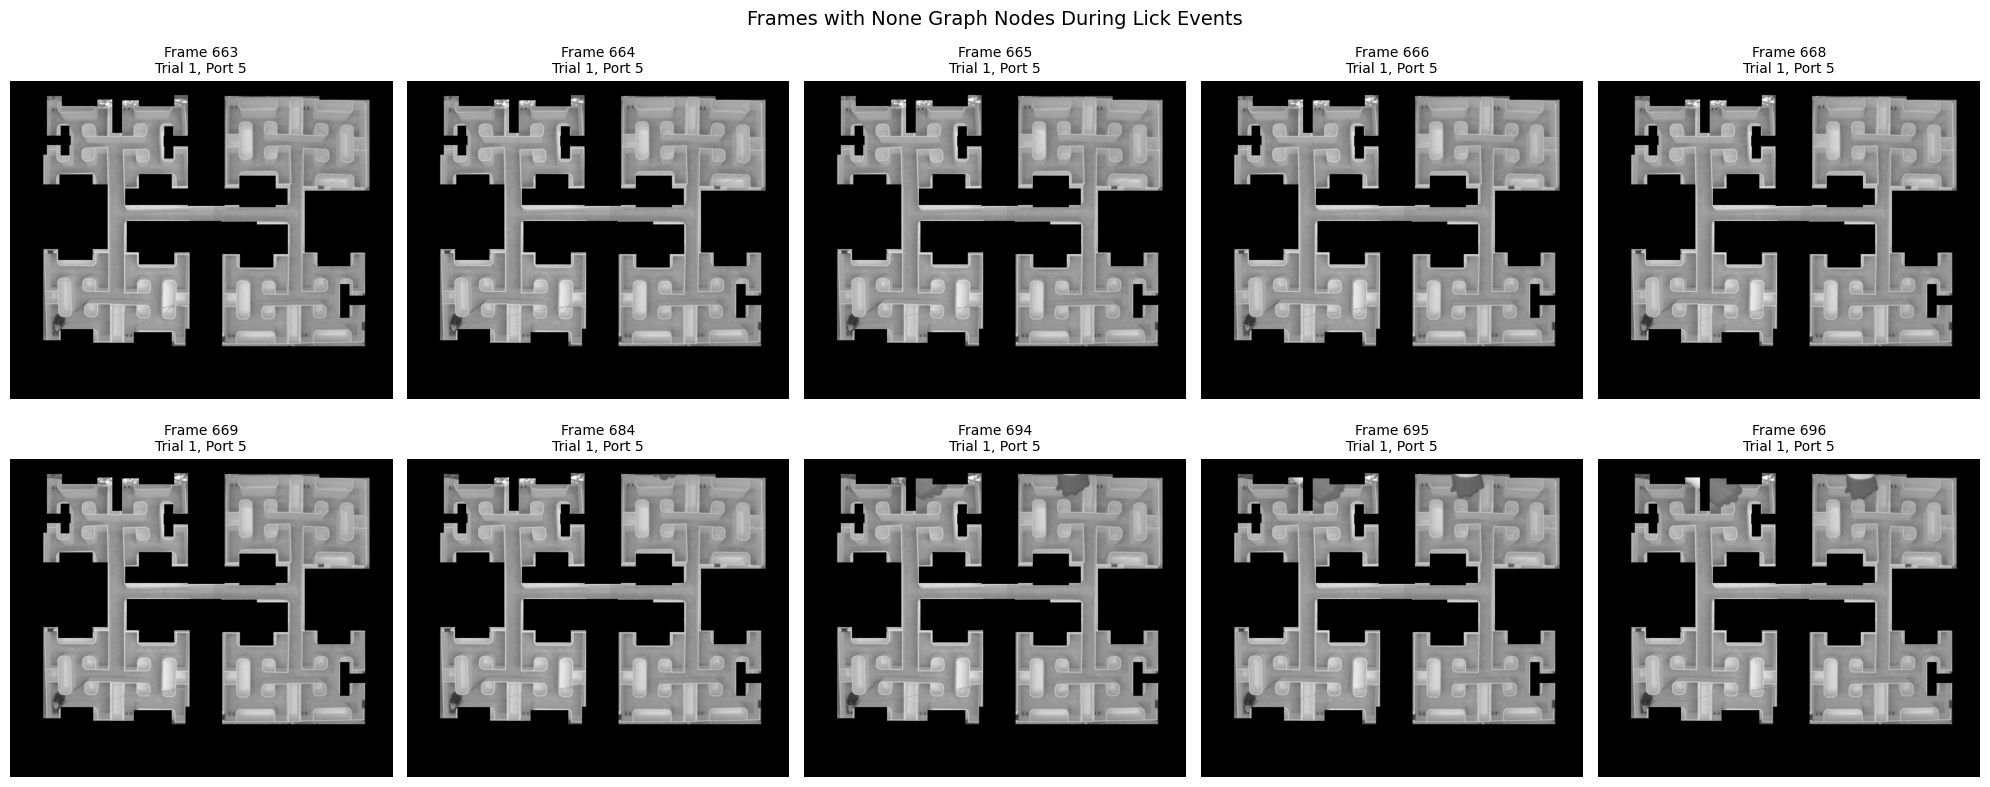

In [2209]:
# Find lick events where graph node is None and display the frames
import cv2
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("ANALYZING LICK EVENTS WITH NONE NODES")
print("="*60)

# Filter for lick events that have 'None' in their nodes
licks_with_none = lick_frames[lick_frames['all_nodes'].str.contains('None', na=False)]

print(f"\nFound {len(licks_with_none)} lick events with None nodes")

if len(licks_with_none) > 0:
    print(f"\nBreakdown by port:")
    for port in sorted(licks_with_none['lick_port'].unique()):
        port_count = len(licks_with_none[licks_with_none['lick_port'] == port])
        print(f"  Port {port}: {port_count} licks with None nodes")
    
    print(f"\n\nFirst 10 lick events with None nodes:")
    print(licks_with_none[['trial_idx', 'lick_port', 'most_common_node', 'num_frames', 'unique_nodes', 'all_nodes']].head(10))
    
    # For each lick event with None, find the specific frames where node is None
    print(f"\n\nDetailed frame-level analysis for licks with None nodes:")
    
    none_frame_details = []
    
    for idx, row in licks_with_none.head(20).iterrows():  # Limit to first 20 for analysis
        trial_idx = row['trial_idx']
        lick_port = row['lick_port']
        frame_start = row['frame_idx_start']
        frame_end = row['frame_idx_end']
        all_nodes = row['all_nodes'].split(',')
        
        # Find which specific frames had None
        frame_range = range(frame_start, frame_end + 1)
        for i, (frame_idx, node) in enumerate(zip(frame_range, all_nodes)):
            if node == 'None':
                none_frame_details.append({
                    'trial_idx': trial_idx,
                    'lick_port': lick_port,
                    'frame_idx': frame_idx,
                    'position_in_lick': i,
                    'total_frames_in_lick': len(all_nodes)
                })
    
    none_frames_df = pd.DataFrame(none_frame_details)
    print(f"\nFound {len(none_frames_df)} individual frames with None nodes")
    print(none_frames_df.head(20))
    
    # Load video and display frames with None nodes
    print(f"\n\nLoading frames from video...")
    cap = cv2.VideoCapture(maze_video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video at {maze_video_path}")
    else:
        # Display first 10 frames with None nodes
        frames_to_display = none_frames_df.head(10)
        
        if len(frames_to_display) > 0:
            fig, axes = plt.subplots(2, 5, figsize=(20, 8))
            axes = axes.flatten()
            
            for idx, (_, frame_info) in enumerate(frames_to_display.iterrows()):
                frame_idx = frame_info['frame_idx']
                trial_idx = frame_info['trial_idx']
                lick_port = frame_info['lick_port']
                
                # Seek to the specific frame
                cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
                ret, frame = cap.read()
                
                if ret:
                    # Convert BGR to RGB for matplotlib
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    axes[idx].imshow(frame_rgb)
                    axes[idx].set_title(f"Frame {frame_idx}\nTrial {trial_idx}, Port {lick_port}", fontsize=10)
                    axes[idx].axis('off')
                else:
                    axes[idx].text(0.5, 0.5, f"Could not load\nframe {frame_idx}", 
                                  ha='center', va='center')
                    axes[idx].axis('off')
            
            # Hide any unused subplots
            for idx in range(len(frames_to_display), 10):
                axes[idx].axis('off')
            
            plt.tight_layout()
            plt.suptitle("Frames with None Graph Nodes During Lick Events", fontsize=14, y=1.02)
            plt.show()
        
        cap.release()
else:
    print("\nNo lick events with None nodes found!")

## Zigzag Analysis: Leaf-Parent Node Transitions

Analyze rapid transitions between leaf reward nodes and their parent nodes to quantify tracking instability.

In [2210]:
# reward_leaf_parents is set in the "Port layout configuration" cell at the top
# of the notebook. Change the wiring there, not here.
print("Reward leaf nodes and their expected parents:")
for port, (leaf, parents) in sorted(reward_leaf_parents.items()):
    print(f"  Port {port}: {leaf} -> {parents}")


Reward leaf nodes and their expected parents:
  Port 1: R522 -> ['R411']
  Port 2: R526 -> ['R413']
  Port 3: L510 -> ['L45']
  Port 4: L56 -> ['L43']
  Port 5: L521 -> ['L410']
  Port 6: L525 -> ['L412']
  Port 7: R59 -> ['R44']
  Port 8: R55 -> ['R42']


In [2211]:
# Analyze lick events per port - how many licks in each node
print("\n" + "="*60)
print("LICK EVENTS ANALYSIS: NODE DISTRIBUTION PER PORT")
print("="*60)

# Use all lick events (lick_frames includes all matched licks now)
print(f"\nTotal lick events analyzed: {len(lick_frames)}")
print(f"Total licks in original data: {len(lick_df)}")
print(f"Match rate: {len(lick_frames)/len(lick_df)*100:.2f}%\n")

# Analyze each port
from collections import Counter

for port in sorted(lick_frames['lick_port'].unique()):
    port_licks = lick_frames[lick_frames['lick_port'] == port]
    
    # Check if this is port 9 (not a physical port)
    if port == 9:
        print(f"\n{'='*60}")
        print(f"PORT {port} - Non-physical port (no expected node)")
        print(f"{'='*60}")
        print(f"Total lick events: {len(port_licks)}")
        
        # Count nodes across all frames during all licks
        all_nodes = []
        for nodes_str in port_licks['all_nodes']:
            all_nodes.extend(nodes_str.split(','))
        
        node_counts = Counter(all_nodes)
        total_frames = len(all_nodes)
        
        print(f"Total frames during licks: {total_frames}")
        print(f"\nNode distribution (no expected node for this port):")
        
        # Sort by count descending
        for node, count in node_counts.most_common():
            pct = count / total_frames * 100
            print(f"    {node:10s}: {count:5d} frames ({pct:5.1f}%)")
        
        continue
    
    # For physical ports (1-8), check if port is defined
    if port not in reward_leaf_parents:
        print(f"\n{'='*60}")
        print(f"PORT {port} - WARNING: Not defined in reward_leaf_parents")
        print(f"{'='*60}")
        print(f"Total lick events: {len(port_licks)}")
        print(f"Skipping analysis for this port...")
        continue
    
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\n{'='*60}")
    print(f"PORT {port} - Expected Node: {expected_leaf}")
    print(f"{'='*60}")
    print(f"Total lick events: {len(port_licks)}")
    
    # Count nodes across all frames during all licks
    all_nodes = []
    for nodes_str in port_licks['all_nodes']:
        all_nodes.extend(nodes_str.split(','))
    
    node_counts = Counter(all_nodes)
    total_frames = len(all_nodes)
    
    print(f"Total frames during licks: {total_frames}")
    print(f"\nNode distribution:")
    
    # Sort by count descending
    for node, count in node_counts.most_common():
        pct = count / total_frames * 100
        marker = "✓" if node == expected_leaf else " "
        print(f"  {marker} {node:10s}: {count:5d} frames ({pct:5.1f}%)")
    
    # Calculate accuracy (frames in expected node)
    correct_frames = node_counts.get(expected_leaf, 0)
    accuracy = correct_frames / total_frames * 100 if total_frames > 0 else 0
    print(f"\nAccuracy: {correct_frames}/{total_frames} frames in correct node ({accuracy:.1f}%)")

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)


LICK EVENTS ANALYSIS: NODE DISTRIBUTION PER PORT

Total lick events analyzed: 956
Total licks in original data: 956
Match rate: 100.00%


PORT 1 - Expected Node: R522
Total lick events: 84
Total frames during licks: 543

Node distribution:
  ✓ R522      :   543 frames (100.0%)

Accuracy: 543/543 frames in correct node (100.0%)

PORT 2 - Expected Node: R526
Total lick events: 49
Total frames during licks: 163

Node distribution:
  ✓ R526      :   151 frames ( 92.6%)
    R413      :    12 frames (  7.4%)

Accuracy: 151/163 frames in correct node (92.6%)

PORT 3 - Expected Node: L510
Total lick events: 157
Total frames during licks: 840

Node distribution:
    L45       :   840 frames (100.0%)

Accuracy: 0/840 frames in correct node (0.0%)

PORT 4 - Expected Node: L56
Total lick events: 26
Total frames during licks: 542

Node distribution:
    L43       :   383 frames ( 70.7%)
  ✓ L56       :   159 frames ( 29.3%)

Accuracy: 159/542 frames in correct node (29.3%)

PORT 5 - Expected Node:

In [2212]:
# Function to detect zigzag patterns between leaf and parent nodes
def detect_zigzags(nav_df, leaf_node, parent_nodes, max_gap_frames=5, bodypart='headstage'):
    """
    Detect rapid transitions (zigzags) between a leaf node and its parent node(s).
    
    Parameters:
    - nav_df: NaviGraph DataFrame with graph locations
    - leaf_node: The leaf node name (e.g., 'R522')
    - parent_nodes: List of potential parent node names (e.g., ['R52'])
    - max_gap_frames: Maximum number of frames for a "quick" jump (threshold)
    - bodypart: Which bodypart to use for graph location
    
    Returns:
    - DataFrame with zigzag events
    """
    node_col = f'{bodypart}_graph_node'
    
    # Get graph locations for all frames
    locations = nav_df[node_col].values
    
    zigzag_events = []
    
    # Iterate through the sequence looking for patterns
    i = 0
    while i < len(locations) - max_gap_frames - 1:
        current_node = locations[i]
        
        # Check if we're starting from the leaf node
        if current_node == leaf_node:
            # Look ahead for potential zigzag
            for gap in range(1, max_gap_frames + 1):
                if i + gap >= len(locations):
                    break
                    
                middle_node = locations[i + gap]
                
                # Check if middle node is a parent
                if middle_node in parent_nodes:
                    # Check if we return to leaf within the gap threshold
                    for return_gap in range(1, gap + 1):
                        if i + gap + return_gap >= len(locations):
                            break
                        
                        return_node = locations[i + gap + return_gap]
                        
                        if return_node == leaf_node:
                            # Found a zigzag pattern!
                            # Count how long we stay in leaf before and after
                            frames_before = 1
                            for j in range(i - 1, -1, -1):
                                if locations[j] == leaf_node:
                                    frames_before += 1
                                else:
                                    break
                            
                            frames_in_parent = return_gap
                            
                            frames_after = 1
                            for j in range(i + gap + return_gap + 1, min(i + gap + return_gap + 50, len(locations))):
                                if locations[j] == leaf_node:
                                    frames_after += 1
                                else:
                                    break
                            
                            zigzag_events.append({
                                'frame_start': i,
                                'frame_parent': i + gap,
                                'frame_return': i + gap + return_gap,
                                'leaf_node': leaf_node,
                                'parent_node': middle_node,
                                'frames_before_zigzag': frames_before,
                                'frames_in_parent': frames_in_parent,
                                'frames_after_zigzag': frames_after,
                                'total_zigzag_duration': gap + return_gap
                            })
                            
                            # Skip ahead to avoid double-counting
                            i = i + gap + return_gap
                            break
                    else:
                        continue
                    break
        
        i += 1
    
    return pd.DataFrame(zigzag_events)

print("Zigzag detection function defined.")
print(f"Will analyze transitions with gaps up to 5 frames (125ms at 40 FPS)")


Zigzag detection function defined.
Will analyze transitions with gaps up to 5 frames (125ms at 40 FPS)


In [2213]:
# Analyze zigzags for all reward leaf nodes
print("="*80)
print("ZIGZAG ANALYSIS FOR ALL REWARD LEAF NODES")
print("="*80)

all_zigzags = {}
threshold_analysis = {}

for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
    print(f"\n{'='*80}")
    print(f"Port {port}: {leaf_node} <-> {parent_nodes}")
    print(f"{'='*80}")
    
    # Detect zigzags for different thresholds
    threshold_results = {}
    
    for threshold in [1, 2, 3, 5]:
        zigzags = detect_zigzags(nav_df, leaf_node, parent_nodes, max_gap_frames=threshold, bodypart='headstage')
        threshold_results[threshold] = zigzags
        
        if len(zigzags) > 0:
            print(f"\nThreshold = {threshold} frames ({threshold * 25}ms):")
            print(f"  Total zigzag events: {len(zigzags)}")
            print(f"  Avg frames in parent: {zigzags['frames_in_parent'].mean():.1f}")
            print(f"  Avg frames before zigzag: {zigzags['frames_before_zigzag'].mean():.1f}")
            print(f"  Avg frames after zigzag: {zigzags['frames_after_zigzag'].mean():.1f}")
            
            # Show distribution of parent frame durations
            parent_duration_counts = zigzags['frames_in_parent'].value_counts().sort_index()
            print(f"  Parent node duration distribution:")
            for duration, count in parent_duration_counts.items():
                print(f"    {duration} frame(s): {count} events ({count/len(zigzags)*100:.1f}%)")
        else:
            print(f"\nThreshold = {threshold} frames ({threshold * 25}ms): No zigzags detected")
    
    all_zigzags[port] = threshold_results

print(f"\n{'='*80}")
print("ANALYSIS COMPLETE")
print(f"{'='*80}")


ZIGZAG ANALYSIS FOR ALL REWARD LEAF NODES

Port 1: R522 <-> ['R411']

Threshold = 1 frames (25ms):
  Total zigzag events: 1
  Avg frames in parent: 1.0
  Avg frames before zigzag: 13.0
  Avg frames after zigzag: 50.0
  Parent node duration distribution:
    1 frame(s): 1 events (100.0%)

Threshold = 2 frames (50ms):
  Total zigzag events: 3
  Avg frames in parent: 1.7
  Avg frames before zigzag: 91.0
  Avg frames after zigzag: 21.3
  Parent node duration distribution:
    1 frame(s): 1 events (33.3%)
    2 frame(s): 2 events (66.7%)

Threshold = 3 frames (75ms):
  Total zigzag events: 3
  Avg frames in parent: 2.0
  Avg frames before zigzag: 89.7
  Avg frames after zigzag: 21.3
  Parent node duration distribution:
    1 frame(s): 1 events (33.3%)
    2 frame(s): 1 events (33.3%)
    3 frame(s): 1 events (33.3%)

Threshold = 5 frames (125ms):
  Total zigzag events: 3
  Avg frames in parent: 2.0
  Avg frames before zigzag: 87.7
  Avg frames after zigzag: 21.3
  Parent node duration distr


SUMMARY TABLE: ZIGZAG EVENTS BY PORT AND THRESHOLD
 Port Leaf Node  Threshold (frames)  Threshold (ms)  Total Zigzags  Avg Parent Frames  1-Frame Parents  Avg Before  Avg After
    1      R522                   1              25              1           1.000000                1   13.000000  50.000000
    1      R522                   2              50              3           1.666667                1   91.000000  21.333333
    1      R522                   3              75              3           2.000000                1   89.666667  21.333333
    1      R522                   5             125              3           2.000000                1   87.666667  21.333333
    2      R526                   1              25              2           1.000000                2   52.500000   9.500000
    2      R526                   2              50              4           1.500000                2   37.250000  21.250000
    2      R526                   3              75              9

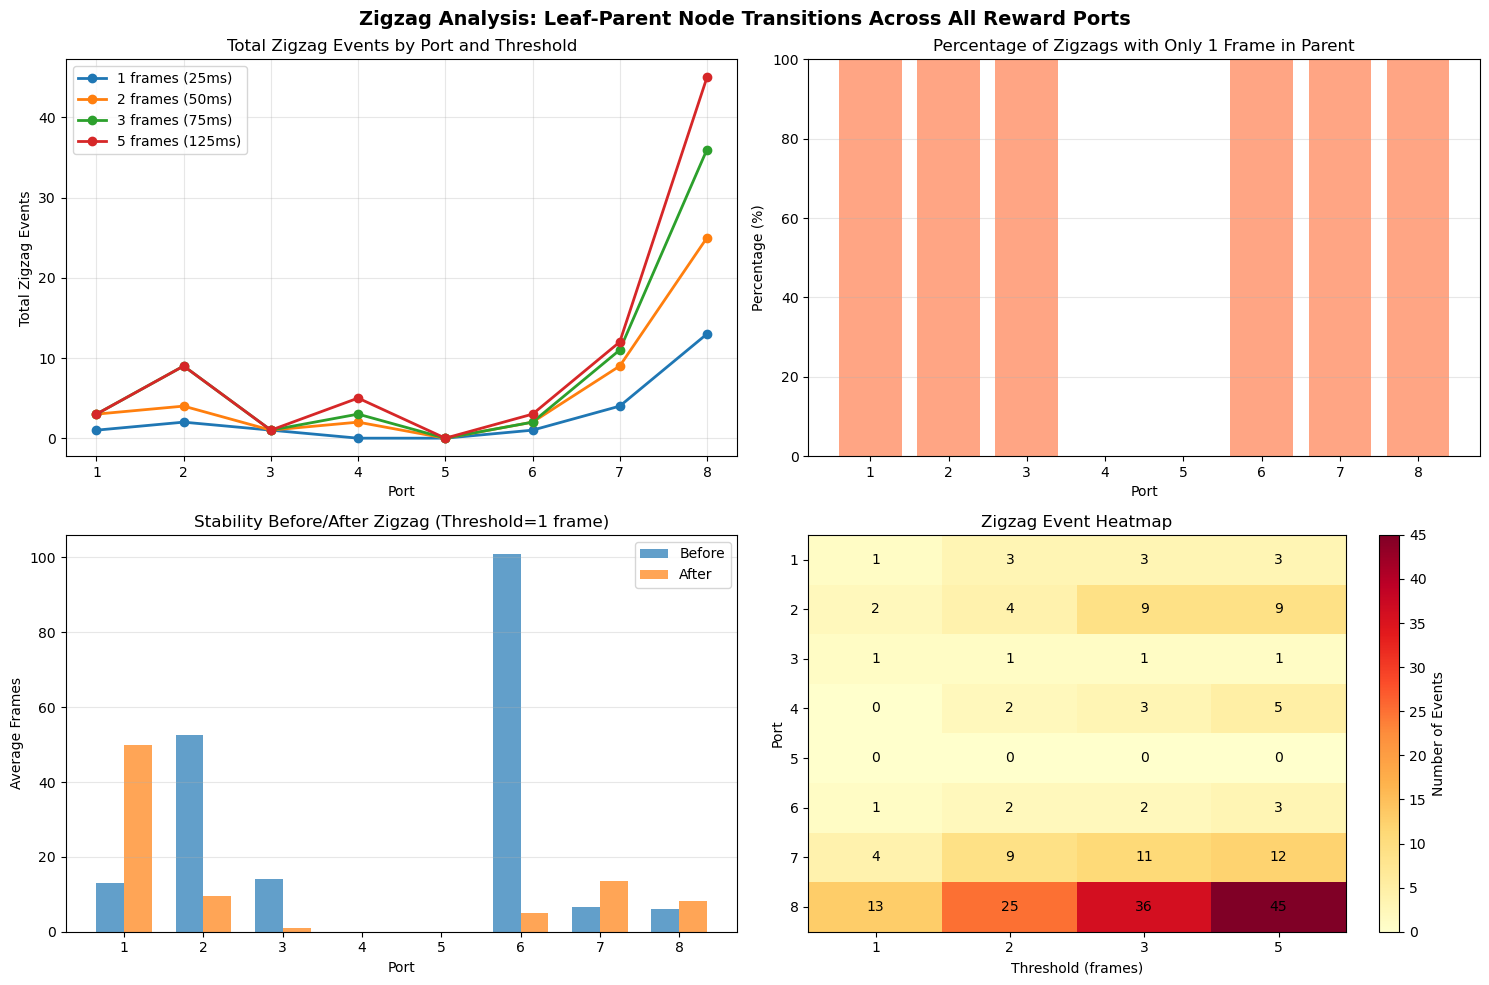


Visualization complete!


In [2214]:
# Create summary table across all ports and thresholds
import matplotlib.pyplot as plt

summary_data = []

for port in sorted(all_zigzags.keys()):
    leaf_node = reward_leaf_parents[port][0]
    for threshold in [1, 2, 3, 5]:
        zigzags = all_zigzags[port][threshold]
        summary_data.append({
            'Port': port,
            'Leaf Node': leaf_node,
            'Threshold (frames)': threshold,
            'Threshold (ms)': threshold * 25,
            'Total Zigzags': len(zigzags),
            'Avg Parent Frames': zigzags['frames_in_parent'].mean() if len(zigzags) > 0 else 0,
            '1-Frame Parents': (zigzags['frames_in_parent'] == 1).sum() if len(zigzags) > 0 else 0,
            'Avg Before': zigzags['frames_before_zigzag'].mean() if len(zigzags) > 0 else 0,
            'Avg After': zigzags['frames_after_zigzag'].mean() if len(zigzags) > 0 else 0
        })


summary_df = pd.DataFrame(summary_data)

print("\n" + "="*80)
print("SUMMARY TABLE: ZIGZAG EVENTS BY PORT AND THRESHOLD")
print("="*80)
print(summary_df.to_string(index=False))

# Plot zigzag counts by port and threshold
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Zigzag Analysis: Leaf-Parent Node Transitions Across All Reward Ports', fontsize=14, fontweight='bold')

# Plot 1: Total zigzags by port for each threshold
for threshold in [1, 2, 3, 5]:
    threshold_data = summary_df[summary_df['Threshold (frames)'] == threshold]
    axes[0, 0].plot(threshold_data['Port'], threshold_data['Total Zigzags'], 
                    marker='o', label=f'{threshold} frames ({threshold*25}ms)', linewidth=2)

axes[0, 0].set_xlabel('Port')
axes[0, 0].set_ylabel('Total Zigzag Events')
axes[0, 0].set_title('Total Zigzag Events by Port and Threshold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(1, 9))

# Plot 2: Percentage of 1-frame parent visits
threshold_1_data = summary_df[summary_df['Threshold (frames)'] >= 1].groupby('Port').first()
total_zigzags = threshold_1_data['Total Zigzags']
one_frame = threshold_1_data['1-Frame Parents']
pct_one_frame = (one_frame / total_zigzags * 100).fillna(0)

axes[0, 1].bar(range(1, 9), pct_one_frame, color='coral', alpha=0.7)
axes[0, 1].set_xlabel('Port')
axes[0, 1].set_ylabel('Percentage (%)')
axes[0, 1].set_title('Percentage of Zigzags with Only 1 Frame in Parent')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].set_xticks(range(1, 9))
axes[0, 1].set_ylim([0, 100])

# Plot 3: Average frames before/after zigzag (threshold=1)
threshold_1_only = summary_df[summary_df['Threshold (frames)'] == 1]
x = np.arange(len(threshold_1_only))
width = 0.35

axes[1, 0].bar(x - width/2, threshold_1_only['Avg Before'], width, label='Before', alpha=0.7)
axes[1, 0].bar(x + width/2, threshold_1_only['Avg After'], width, label='After', alpha=0.7)
axes[1, 0].set_xlabel('Port')
axes[1, 0].set_ylabel('Average Frames')
axes[1, 0].set_title('Stability Before/After Zigzag (Threshold=1 frame)')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(threshold_1_only['Port'])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Heatmap of zigzag counts
pivot_table = summary_df.pivot(index='Port', columns='Threshold (frames)', values='Total Zigzags')
im = axes[1, 1].imshow(pivot_table.values, cmap='YlOrRd', aspect='auto')
axes[1, 1].set_xticks(range(len(pivot_table.columns)))
axes[1, 1].set_xticklabels(pivot_table.columns)
axes[1, 1].set_yticks(range(len(pivot_table.index)))
axes[1, 1].set_yticklabels(pivot_table.index)
axes[1, 1].set_xlabel('Threshold (frames)')
axes[1, 1].set_ylabel('Port')
axes[1, 1].set_title('Zigzag Event Heatmap')

# Add text annotations
for i in range(len(pivot_table.index)):
    for j in range(len(pivot_table.columns)):
        text = axes[1, 1].text(j, i, int(pivot_table.values[i, j]),
                              ha="center", va="center", color="black", fontsize=10)

plt.colorbar(im, ax=axes[1, 1], label='Number of Events')

plt.tight_layout()
plt.show()

print("\nVisualization complete!")


In [2215]:
# Detailed example: Show specific zigzag events for one port
example_port = 2  # Port with 100% consistency (R526)
example_threshold = 1

print(f"\n{'='*80}")
print(f"DETAILED EXAMPLE: Port {example_port} ({reward_leaf_parents[example_port][0]}) with Threshold={example_threshold}")
print(f"{'='*80}\n")

example_zigzags = all_zigzags[example_port][example_threshold]

if len(example_zigzags) > 0:
    print(f"Total zigzag events found: {len(example_zigzags)}")
    print(f"\nFirst 10 zigzag events:\n")
    
    display_cols = ['frame_start', 'frame_parent', 'frame_return', 'leaf_node', 'parent_node', 
                    'frames_before_zigzag', 'frames_in_parent', 'frames_after_zigzag']
    print(example_zigzags[display_cols].head(10).to_string(index=False))
    
    # Show timing statistics
    print(f"\n\nTiming Statistics:")
    print(f"  Duration in parent node:")
    print(f"    Min: {example_zigzags['frames_in_parent'].min()} frames ({example_zigzags['frames_in_parent'].min() * 25}ms)")
    print(f"    Max: {example_zigzags['frames_in_parent'].max()} frames ({example_zigzags['frames_in_parent'].max() * 25}ms)")
    print(f"    Mean: {example_zigzags['frames_in_parent'].mean():.1f} frames ({example_zigzags['frames_in_parent'].mean() * 25:.1f}ms)")
    
    print(f"\n  Stability before zigzag:")
    print(f"    Min: {example_zigzags['frames_before_zigzag'].min()} frames")
    print(f"    Max: {example_zigzags['frames_before_zigzag'].max()} frames")
    print(f"    Mean: {example_zigzags['frames_before_zigzag'].mean():.1f} frames")
    
    print(f"\n  Stability after zigzag:")
    print(f"    Min: {example_zigzags['frames_after_zigzag'].min()} frames")
    print(f"    Max: {example_zigzags['frames_after_zigzag'].max()} frames")
    print(f"    Mean: {example_zigzags['frames_after_zigzag'].mean():.1f} frames")
    
    # Calculate zigzag rate
    leaf_node = reward_leaf_parents[example_port][0]
    total_frames_in_leaf = (nav_df['headstage_graph_node'] == leaf_node).sum()
    zigzag_rate = len(example_zigzags) / total_frames_in_leaf * 100 if total_frames_in_leaf > 0 else 0
    
    print(f"\n  Zigzag frequency:")
    print(f"    Total frames in {leaf_node}: {total_frames_in_leaf}")
    print(f"    Zigzag events: {len(example_zigzags)}")
    print(f"    Zigzag rate: {zigzag_rate:.2f}% of frames in leaf node")
else:
    
    print("No zigzag events detected for this port and threshold.")



DETAILED EXAMPLE: Port 2 (R526) with Threshold=1

Total zigzag events found: 2

First 10 zigzag events:

 frame_start  frame_parent  frame_return leaf_node parent_node  frames_before_zigzag  frames_in_parent  frames_after_zigzag
       53648         53649         53650      R526        R413                   102                 1                   15
       83938         83939         83940      R526        R413                     3                 1                    4


Timing Statistics:
  Duration in parent node:
    Min: 1 frames (25ms)
    Max: 1 frames (25ms)
    Mean: 1.0 frames (25.0ms)

  Stability before zigzag:
    Min: 3 frames
    Max: 102 frames
    Mean: 52.5 frames

  Stability after zigzag:
    Min: 4 frames
    Max: 15 frames
    Mean: 9.5 frames

  Zigzag frequency:
    Total frames in R526: 1021
    Zigzag events: 2
    Zigzag rate: 0.20% of frames in leaf node


In [2216]:
# Overall session summary
print(f"\n{'='*80}")
print("OVERALL SESSION SUMMARY")
print(f"{'='*80}\n")

# Calculate total zigzags across all ports for threshold=1
total_zigzags_t1 = sum(len(all_zigzags[port][1]) for port in all_zigzags.keys())
total_frames = len(nav_df)

print(f"Total frames in session: {total_frames:,}")
print(f"Total frames analyzed: {total_frames:,}")
print(f"\nZigzag events (threshold = 1 frame / 25ms):")
print(f"  Total across all 8 reward ports: {total_zigzags_t1}")
print(f"  Rate: {total_zigzags_t1/total_frames*100:.3f}% of all frames")
print(f"  Average per port: {total_zigzags_t1/8:.1f}")

# Count total frames spent in reward leaf nodes
total_leaf_frames = 0
for port, (leaf_node, _) in reward_leaf_parents.items():
    leaf_frames = (nav_df['headstage_graph_node'] == leaf_node).sum()
    total_leaf_frames += leaf_frames

print(f"\nTotal frames in reward leaf nodes: {total_leaf_frames:,} ({total_leaf_frames/total_frames*100:.1f}% of session)")
print(f"Zigzag rate in reward areas: {total_zigzags_t1/total_leaf_frames*100:.2f}% of frames in leaf nodes")

# Most problematic ports
print(f"\n{'='*40}")
print("Most Problematic Ports (Threshold=1):")
print(f"{'='*40}")

port_zigzag_counts = [(port, len(all_zigzags[port][1])) for port in sorted(all_zigzags.keys())]
port_zigzag_counts.sort(key=lambda x: x[1], reverse=True)

for i, (port, count) in enumerate(port_zigzag_counts[:5], 1):
    leaf_node = reward_leaf_parents[port][0]
    leaf_frames = (nav_df['headstage_graph_node'] == leaf_node).sum()
    rate = count / leaf_frames * 100 if leaf_frames > 0 else 0
    print(f"  {i}. Port {port} ({leaf_node}): {count} events ({rate:.2f}% of {leaf_frames} leaf frames)")

print(f"\n{'='*80}")
print("ZIGZAG ANALYSIS COMPLETE")
print(f"{'='*80}")
print("\nKey Findings:")
print("- Zigzag events indicate rapid transitions between leaf and parent nodes")
print("- High zigzag rates suggest tracking instability near reward locations")
print("- Threshold=1 captures single-frame jumps (most sensitive)")
print("- This data can guide post-processing or smoothing strategies")



OVERALL SESSION SUMMARY

Total frames in session: 128,489
Total frames analyzed: 128,489

Zigzag events (threshold = 1 frame / 25ms):
  Total across all 8 reward ports: 22
  Rate: 0.017% of all frames
  Average per port: 2.8

Total frames in reward leaf nodes: 10,185 (7.9% of session)
Zigzag rate in reward areas: 0.22% of frames in leaf nodes

Most Problematic Ports (Threshold=1):
  1. Port 8 (R55): 13 events (1.36% of 953 leaf frames)
  2. Port 7 (R59): 4 events (2.08% of 192 leaf frames)
  3. Port 2 (R526): 2 events (0.20% of 1021 leaf frames)
  4. Port 1 (R522): 1 events (0.06% of 1786 leaf frames)
  5. Port 3 (L510): 1 events (0.58% of 173 leaf frames)

ZIGZAG ANALYSIS COMPLETE

Key Findings:
- Zigzag events indicate rapid transitions between leaf and parent nodes
- High zigzag rates suggest tracking instability near reward locations
- Threshold=1 captures single-frame jumps (most sensitive)
- This data can guide post-processing or smoothing strategies


## Fix Graph Locations: Smoothing Leaf-Parent Zigzags

Apply correction to remove rapid single-frame transitions between leaf nodes and their parents, then re-evaluate reward location accuracy.

In [2217]:
# Create a corrected version of the graph locations
def smooth_leaf_parent_zigzags(nav_df, reward_leaf_parents, max_gap_frames=1, bodypart='headstage'):
    """
    Smooth out rapid transitions between leaf nodes and their parent nodes.
    
    Strategy: If a leaf node L appears, followed by parent P for ≤ max_gap_frames, 
    followed by leaf L again, replace the parent frames with the leaf node.
    
    Parameters:
    - nav_df: NaviGraph DataFrame with graph locations
    - reward_leaf_parents: Dictionary mapping ports to (leaf, parent_list) tuples
    - max_gap_frames: Maximum number of frames to smooth (threshold)
    - bodypart: Which bodypart to use for graph location
    
    Returns:
    - Corrected DataFrame with smoothed graph locations
    """
    node_col = f'{bodypart}_graph_node'
    
    # Create a copy of the dataframe
    corrected_df = nav_df.copy()
    locations = corrected_df[node_col].values.copy()
    
    # Build a mapping of leaf -> parents for quick lookup
    leaf_to_parents = {}
    for port, (leaf, parents) in reward_leaf_parents.items():
        leaf_to_parents[leaf] = parents
    
    corrections_made = 0
    correction_details = []
    
    # Iterate through the sequence looking for zigzag patterns
    i = 0
    while i < len(locations) - max_gap_frames - 1:
        current_node = locations[i]
        
        # Check if we're starting from a leaf node
        if current_node in leaf_to_parents:
            leaf_node = current_node
            parent_nodes = leaf_to_parents[leaf_node]
            
            # Look ahead for potential zigzag
            for gap in range(1, max_gap_frames + 1):
                if i + gap >= len(locations):
                    break
                    
                middle_node = locations[i + gap]
                
                # Check if middle node is the parent
                if middle_node in parent_nodes:
                    # Check if we return to leaf within gap frames
                    all_parent = True
                    for check_idx in range(i + gap, min(i + gap + gap, len(locations))):
                        if locations[check_idx] not in parent_nodes:
                            all_parent = False
                            break
                    
                    if all_parent:
                        # Check for return to leaf
                        for return_gap in range(1, gap + 1):
                            if i + gap + return_gap >= len(locations):
                                break
                            
                            return_node = locations[i + gap + return_gap]
                            
                            if return_node == leaf_node:
                                # Found a zigzag - correct it!
                                for fix_idx in range(i + gap, i + gap + return_gap):
                                    locations[fix_idx] = leaf_node
                                    corrections_made += 1
                                
                                correction_details.append({
                                    'frame_start': i + gap,
                                    'frame_end': i + gap + return_gap - 1,
                                    'leaf_node': leaf_node,
                                    'parent_node': middle_node,
                                    'frames_corrected': return_gap - 1
                                })
                                
                                # Skip ahead
                                i = i + gap + return_gap - 1
                                break
                        else:
                            continue
                        break
        
        i += 1
    
    # Update the corrected dataframe
    corrected_df[node_col] = locations
    
    return corrected_df, corrections_made, pd.DataFrame(correction_details)

# Apply smoothing with threshold=1 (single-frame parent visits)
print("Applying smoothing to remove single-frame parent visits...")
nav_df_corrected, total_corrections, correction_df = smooth_leaf_parent_zigzags(
    nav_df, reward_leaf_parents, max_gap_frames=1, bodypart='headstage'
)

print(f"\nCorrection complete!")
print(f"Total frames corrected: {total_corrections}")
print(f"Total correction events: {len(correction_df)}")

if len(correction_df) > 0:
    print(f"\nCorrection breakdown by leaf node:")
    for port, (leaf_node, _) in reward_leaf_parents.items():
        leaf_corrections = correction_df[correction_df['leaf_node'] == leaf_node]
        if len(leaf_corrections) > 0:
            print(f"  Port {port} ({leaf_node}): {len(leaf_corrections)} events, {leaf_corrections['frames_corrected'].sum()} frames")


Applying smoothing to remove single-frame parent visits...

Correction complete!
Total frames corrected: 22
Total correction events: 22

Correction breakdown by leaf node:
  Port 1 (R522): 1 events, 0 frames
  Port 2 (R526): 2 events, 0 frames
  Port 3 (L510): 1 events, 0 frames
  Port 6 (L525): 1 events, 0 frames
  Port 7 (R59): 4 events, 0 frames
  Port 8 (R55): 13 events, 0 frames


In [2218]:
# Re-evaluate reward locations with corrected data
print("="*80)
print("RE-EVALUATION: REWARD LOCATIONS AFTER CORRECTION")
print("="*80)

# Extract corrected graph locations for reward frames
reward_frames_corrected = reward_frames.copy()
reward_frames_corrected['graph_node_corrected'] = None
reward_frames_corrected['graph_edge_corrected'] = None
reward_frames_corrected['was_corrected'] = False

node_col = 'headstage_graph_node'
edge_col = 'headstage_graph_edge'

for idx, row in reward_frames_corrected.iterrows():
    if pd.isna(row['frame_idx_global']):
        continue
        
    frame_idx = int(row['frame_idx_global'])
    
    if frame_idx < len(nav_df_corrected):
        # Use .at for direct scalar access to avoid iterable issues
        try:
            node_corrected = nav_df_corrected.at[frame_idx, node_col]
            edge_corrected = nav_df_corrected.at[frame_idx, edge_col]
            node_original = nav_df.at[frame_idx, node_col]
        except (KeyError, ValueError):
            # Fallback for duplicate columns or non-standard index
            node_corrected = nav_df_corrected.loc[frame_idx, node_col]
            edge_corrected = nav_df_corrected.loc[frame_idx, edge_col]
            node_original = nav_df.loc[frame_idx, node_col]
            
            # Ensure scalar values
            if hasattr(node_corrected, '__iter__') and not isinstance(node_corrected, str):
                node_corrected = node_corrected.iloc[0] if hasattr(node_corrected, 'iloc') else node_corrected[0]
            if hasattr(edge_corrected, '__iter__') and not isinstance(edge_corrected, str):
                edge_corrected = edge_corrected.iloc[0] if hasattr(edge_corrected, 'iloc') else edge_corrected[0]
            if hasattr(node_original, '__iter__') and not isinstance(node_original, str):
                node_original = node_original.iloc[0] if hasattr(node_original, 'iloc') else node_original[0]
        
        reward_frames_corrected.at[idx, 'graph_node_corrected'] = node_corrected
        reward_frames_corrected.at[idx, 'graph_edge_corrected'] = edge_corrected
        
        # Check if this frame was corrected
        if node_original != node_corrected:
            reward_frames_corrected.at[idx, 'was_corrected'] = True

# Summary by port - BEFORE correction
print("\nBEFORE CORRECTION:")
print("="*80)
for port in sorted(reward_frames['reward_port'].unique()):
    port_data = reward_frames[reward_frames['reward_port'] == port]
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\nPort {port} (Expected: {expected_leaf}):")
    valid_nodes = port_data[port_data['graph_node'].notna()]
    if len(valid_nodes) > 0:
        mode_nodes = valid_nodes['graph_node'].mode()
        most_common = mode_nodes.values[0] if len(mode_nodes) > 0 else 'N/A'
        correct_count = (valid_nodes['graph_node'] == expected_leaf).sum()
        
        print(f"  Most common node: {most_common}")
        print(f"  Correct location: {correct_count}/{len(valid_nodes)} ({correct_count/len(valid_nodes)*100:.1f}%)")
        print(f"  Node distribution:")
        node_counts = valid_nodes['graph_node'].value_counts().head(3)
        for node, count in node_counts.items():
            marker = "✓" if node == expected_leaf else "✗"
            print(f"    {marker} {node}: {count} ({count/len(valid_nodes)*100:.1f}%)")

# Summary by port - AFTER correction  
print("\n\nAFTER CORRECTION:")
print("="*80)
total_corrections_at_reward = 0
total_newly_correct = 0

for port in sorted(reward_frames_corrected['reward_port'].unique()):
    port_data = reward_frames_corrected[reward_frames_corrected['reward_port'] == port]
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\nPort {port} (Expected: {expected_leaf}):")
    valid_nodes = port_data[port_data['graph_node_corrected'].notna()]
    if len(valid_nodes) > 0:
        mode_nodes = valid_nodes['graph_node_corrected'].mode()
        most_common = mode_nodes.values[0] if len(mode_nodes) > 0 else 'N/A'
        correct_count = (valid_nodes['graph_node_corrected'] == expected_leaf).sum()
        corrected_at_reward = port_data['was_corrected'].sum()
        
        # Calculate improvement
        original_correct = (port_data['graph_node'] == expected_leaf).sum()
        improvement = correct_count - original_correct
        
        print(f"  Most common node: {most_common}")
        print(f"  Correct location: {correct_count}/{len(valid_nodes)} ({correct_count/len(valid_nodes)*100:.1f}%)")
        print(f"  Frames corrected at reward: {corrected_at_reward}")
        if improvement > 0:
            print(f"  ✓ Improvement: +{improvement} correct (+{improvement/len(valid_nodes)*100:.1f}%)")
            total_newly_correct += improvement
        
        print(f"  Node distribution:")
        node_counts = valid_nodes['graph_node_corrected'].value_counts().head(3)
        for node, count in node_counts.items():
            marker = "✓" if node == expected_leaf else "✗"
            print(f"    {marker} {node}: {count} ({count/len(valid_nodes)*100:.1f}%)")
        
        total_corrections_at_reward += corrected_at_reward

print("\n" + "="*80)
print("OVERALL IMPROVEMENT SUMMARY")
print("="*80)
print(f"Total reward frames corrected: {total_corrections_at_reward}")
print(f"Total newly correct reward locations: {total_newly_correct}")
print(f"Percentage of corrections that fixed reward locations: {total_newly_correct/total_corrections_at_reward*100:.1f}%" if total_corrections_at_reward > 0 else "N/A")


RE-EVALUATION: REWARD LOCATIONS AFTER CORRECTION

BEFORE CORRECTION:

Port 1 (Expected: R522):
  Most common node: R522
  Correct location: 13/13 (100.0%)
  Node distribution:
    ✓ R522: 13 (100.0%)

Port 2 (Expected: R526):
  Most common node: R526
  Correct location: 9/12 (75.0%)
  Node distribution:
    ✓ R526: 9 (75.0%)
    ✗ R413: 3 (25.0%)

Port 3 (Expected: L510):
  Most common node: L45
  Correct location: 0/27 (0.0%)
  Node distribution:
    ✗ L45: 27 (100.0%)

Port 4 (Expected: L56):
  Most common node: L43
  Correct location: 1/16 (6.2%)
  Node distribution:
    ✗ L43: 15 (93.8%)
    ✓ L56: 1 (6.2%)

Port 5 (Expected: L521):
  Most common node: L521
  Correct location: 16/16 (100.0%)
  Node distribution:
    ✓ L521: 16 (100.0%)

Port 6 (Expected: L525):
  Most common node: L525
  Correct location: 33/33 (100.0%)
  Node distribution:
    ✓ L525: 33 (100.0%)

Port 7 (Expected: R59):
  Most common node: R44
  Correct location: 1/15 (6.7%)
  Node distribution:
    ✗ R44: 14 (93

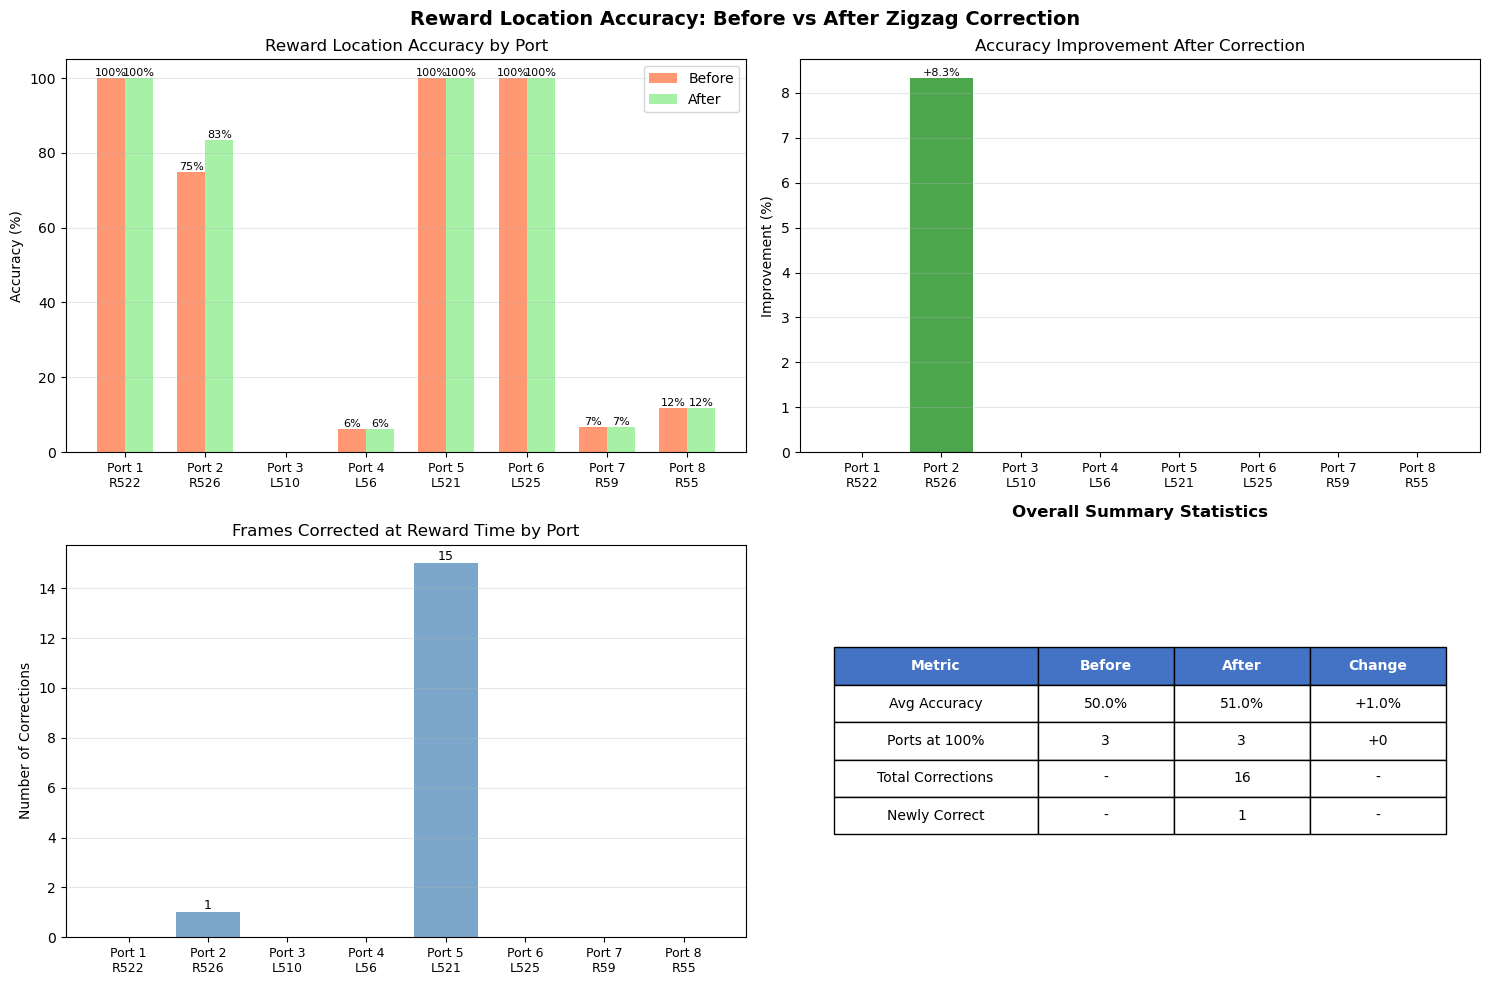


Visualization complete!


In [2219]:
# Visualize the improvement
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Reward Location Accuracy: Before vs After Zigzag Correction', fontsize=14, fontweight='bold')

# Calculate accuracy metrics for each port
reward_port_numbers = sorted(reward_frames['reward_port'].unique())
accuracy_before = []
accuracy_after = []
corrections_made = []
port_labels = []

for port in reward_port_numbers:
    expected_leaf = reward_leaf_parents[port][0]
    
    # Before
    port_data_before = reward_frames[reward_frames['reward_port'] == port]
    valid_before = port_data_before[port_data_before['graph_node'].notna()]
    correct_before = (valid_before['graph_node'] == expected_leaf).sum()
    acc_before = correct_before / len(valid_before) * 100 if len(valid_before) > 0 else 0
    
    # After
    port_data_after = reward_frames_corrected[reward_frames_corrected['reward_port'] == port]
    valid_after = port_data_after[port_data_after['graph_node_corrected'].notna()]
    correct_after = (valid_after['graph_node_corrected'] == expected_leaf).sum()
    acc_after = correct_after / len(valid_after) * 100 if len(valid_after) > 0 else 0
    
    # Corrections
    corrections = port_data_after['was_corrected'].sum()
    
    accuracy_before.append(acc_before)
    accuracy_after.append(acc_after)
    corrections_made.append(corrections)
    port_labels.append(f"Port {int(port)}\n{expected_leaf}")

# Plot 1: Accuracy comparison
x = np.arange(len(reward_port_numbers))
width = 0.35

bars1 = axes[0, 0].bar(x - width/2, accuracy_before, width, label='Before', alpha=0.8, color='coral')
bars2 = axes[0, 0].bar(x + width/2, accuracy_after, width, label='After', alpha=0.8, color='lightgreen')

axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_title('Reward Location Accuracy by Port')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(port_labels, fontsize=9)
axes[0, 0].legend()
axes[0, 0].set_ylim([0, 105])
axes[0, 0].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.0f}%', ha='center', va='bottom', fontsize=8)

# Plot 2: Improvement delta
improvement = [after - before for before, after in zip(accuracy_before, accuracy_after)]
colors = ['green' if imp > 0 else 'gray' for imp in improvement]
bars = axes[0, 1].bar(x, improvement, color=colors, alpha=0.7)
axes[0, 1].set_ylabel('Improvement (%)')
axes[0, 1].set_title('Accuracy Improvement After Correction')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(port_labels, fontsize=9)
axes[0, 1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    if abs(height) > 0.1:
        axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                      f'{height:+.1f}%', ha='center', va='bottom' if height > 0 else 'top', fontsize=8)

# Plot 3: Number of corrections per port
bars = axes[1, 0].bar(x, corrections_made, color='steelblue', alpha=0.7)
axes[1, 0].set_ylabel('Number of Corrections')
axes[1, 0].set_title('Frames Corrected at Reward Time by Port')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(port_labels, fontsize=9)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar in bars:
    height = bar.get_height()
    if height > 0:
        axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                      f'{int(height)}', ha='center', va='bottom', fontsize=9)

# Plot 4: Overall summary statistics
summary_data = {
    'Before Correction': [np.mean(accuracy_before), sum(corrections_made), 0],
    'After Correction': [np.mean(accuracy_after), 0, total_newly_correct]
}
summary_labels = ['Avg Accuracy (%)', 'Corrections Made', 'Newly Correct']

axes[1, 1].axis('off')
table_data = [
    ['Metric', 'Before', 'After', 'Change'],
    ['Avg Accuracy', f'{np.mean(accuracy_before):.1f}%', f'{np.mean(accuracy_after):.1f}%', 
     f'{np.mean(accuracy_after) - np.mean(accuracy_before):+.1f}%'],
    ['Ports at 100%', f'{sum(1 for a in accuracy_before if a == 100)}', 
     f'{sum(1 for a in accuracy_after if a == 100)}', 
     f'{sum(1 for a in accuracy_after if a == 100) - sum(1 for a in accuracy_before if a == 100):+d}'],
    ['Total Corrections', '-', f'{total_corrections_at_reward}', '-'],
    ['Newly Correct', '-', f'{total_newly_correct}', '-']
]

table = axes[1, 1].table(cellText=table_data, cellLoc='center', loc='center',
                        colWidths=[0.3, 0.2, 0.2, 0.2])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(4):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

axes[1, 1].set_title('Overall Summary Statistics', fontsize=12, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\nVisualization complete!")


## Reward-Based Correction (0.25s reward period)

Fix graph locations during reward consumption by setting reward frame + next 9 frames to correct leaf node.

In [2220]:
# Diagnostic: Check nav_df structure before applying correction
print("=== nav_df Structure Diagnostic ===")
print(f"Shape: {nav_df.shape}")
print(f"Column type: {type(nav_df.columns)}")
print(f"Is MultiIndex: {isinstance(nav_df.columns, pd.MultiIndex)}")
print(f"\nFirst 5 columns: {nav_df.columns[:5].tolist()}")
if isinstance(nav_df.columns, pd.MultiIndex):
    print("\nSearching for graph_node columns in MultiIndex:")
    graph_cols = [col for col in nav_df.columns if 'graph_node' in str(col)]
    print(f"Found {len(graph_cols)} graph_node columns: {graph_cols}")
else:
    print("\nSearching for graph_node columns in flat structure:")
    graph_cols = [col for col in nav_df.columns if 'graph_node' in col]
    print(f"Found {len(graph_cols)} graph_node columns: {graph_cols}")

=== nav_df Structure Diagnostic ===
Shape: (128489, 25)
Column type: <class 'pandas.Index'>
Is MultiIndex: False

First 5 columns: ['headstage_x', 'headstage_y', 'headstage_likelihood', 'ear_L_x', 'ear_L_y']

Searching for graph_node columns in flat structure:
Found 5 graph_node columns: ['ear_L_graph_node', 'ear_r_graph_node', 'headstage_graph_node', 'midbody_graph_node', 'tailbase_graph_node']


In [2221]:
# Define and apply reward-based correction
def apply_reward_based_correction(nav_df, reward_frames, port_to_leaf_mapping, reward_duration_frames=10, bodypart='headstage'):
    corrected_df = nav_df.copy()
    
    # Find the correct column for graph_node
    if isinstance(corrected_df.columns, pd.MultiIndex):
        # Try MultiIndex access
        node_col = (bodypart, 'graph_node')
        if node_col not in corrected_df.columns:
            # Search for any column with graph_node
            graph_cols = [col for col in corrected_df.columns if 'graph_node' in str(col)]
            if not graph_cols:
                raise ValueError(f"No graph_node column found in DataFrame")
            node_col = graph_cols[0]
            print(f"Using graph_node column: {node_col}")
    else:
        # Flat columns - look for headstage_graph_node or similar
        if f'{bodypart}_graph_node' in corrected_df.columns:
            node_col = f'{bodypart}_graph_node'
        elif 'graph_node' in corrected_df.columns:
            node_col = 'graph_node'
        else:
            raise ValueError(f"No suitable graph_node column found. Available columns: {corrected_df.columns[:10].tolist()}")
    
    corrections_made = 0
    correction_details = {port: {'frames_corrected': 0, 'changed_from': {}} 
                         for port in port_to_leaf_mapping.keys()}
    port_to_leaf = {port: info[0] for port, info in port_to_leaf_mapping.items()}
    
    print(f"Applying reward-based correction for {len(reward_frames)} reward events...")
    print(f"Each reward corrects {reward_duration_frames} frames (0.25s at 40 FPS)")
    print(f"Using column: {node_col}\n")
    
    locations = corrected_df[node_col].tolist()
    
    for idx, row in reward_frames.iterrows():
        reward_frame = int(row['frame_idx_global'])
        reward_port = int(row['reward_port'])
        expected_leaf = port_to_leaf[reward_port]
        
        start_frame = reward_frame
        end_frame = min(reward_frame + reward_duration_frames, len(locations))
        
        for frame_idx in range(start_frame, end_frame):
            current_node = locations[frame_idx]
            if pd.notna(current_node) and current_node != expected_leaf:
                if current_node not in correction_details[reward_port]['changed_from']:
                    correction_details[reward_port]['changed_from'][current_node] = 0
                correction_details[reward_port]['changed_from'][current_node] += 1
                locations[frame_idx] = expected_leaf
                corrections_made += 1
                correction_details[reward_port]['frames_corrected'] += 1
    
    corrected_df[node_col] = locations
    
    print(f"Total frames corrected: {corrections_made}")
    print(f"\nBreakdown by port:")
    for port in sorted(port_to_leaf_mapping.keys()):
        leaf = port_to_leaf[port]
        n_corrected = correction_details[port]['frames_corrected']
        print(f"  Port {port} ({leaf}): {n_corrected} frames corrected")
        if correction_details[port]['changed_from']:
            print(f"    Changed from: {correction_details[port]['changed_from']}")
    
    return corrected_df, corrections_made, correction_details

# Apply it
nav_df_reward_corrected, reward_corrections_total, reward_correction_details = apply_reward_based_correction(
    nav_df, reward_frames, reward_leaf_parents, reward_duration_frames=10, bodypart='headstage'
)

Applying reward-based correction for 164 reward events...
Each reward corrects 10 frames (0.25s at 40 FPS)
Using column: headstage_graph_node

Total frames corrected: 735

Breakdown by port:
  Port 1 (R522): 0 frames corrected
  Port 2 (R526): 24 frames corrected
    Changed from: {'R413': 24}
  Port 3 (L510): 270 frames corrected
    Changed from: {'L45': 270}
  Port 4 (L56): 148 frames corrected
    Changed from: {'L43': 148}
  Port 5 (L521): 0 frames corrected
  Port 6 (L525): 0 frames corrected
  Port 7 (R59): 142 frames corrected
    Changed from: {'R44': 142}
  Port 8 (R55): 151 frames corrected
    Changed from: {'R42': 151}


In [2222]:
reward_leaf_parents

{1: ('R522', ['R411']),
 2: ('R526', ['R413']),
 3: ('L510', ['L45']),
 4: ('L56', ['L43']),
 5: ('L521', ['L410']),
 6: ('L525', ['L412']),
 7: ('R59', ['R44']),
 8: ('R55', ['R42'])}

## Reward-Based Location Correction

We'll fix graph locations during reward consumption periods:
- Set the reward frame + next 9 frames (0.25s at 40 FPS) to the correct leaf node
- This accounts for the time the mouse is physically at the reward port drinking

In [2223]:
# Apply reward-based correction to the original nav_df
nav_df_reward_corrected, reward_corrections_total, reward_correction_details = apply_reward_based_correction(
    nav_df, 
    reward_frames, 
    reward_leaf_parents,
    reward_duration_frames=10,  # 0.25s at 40 FPS
    bodypart='headstage'
)

Applying reward-based correction for 164 reward events...
Each reward corrects 10 frames (0.25s at 40 FPS)
Using column: headstage_graph_node

Total frames corrected: 735

Breakdown by port:
  Port 1 (R522): 0 frames corrected
  Port 2 (R526): 24 frames corrected
    Changed from: {'R413': 24}
  Port 3 (L510): 270 frames corrected
    Changed from: {'L45': 270}
  Port 4 (L56): 148 frames corrected
    Changed from: {'L43': 148}
  Port 5 (L521): 0 frames corrected
  Port 6 (L525): 0 frames corrected
  Port 7 (R59): 142 frames corrected
    Changed from: {'R44': 142}
  Port 8 (R55): 151 frames corrected
    Changed from: {'R42': 151}


In [2224]:
def apply_reward_based_correction(nav_df, reward_frames, port_to_leaf_mapping, reward_duration_frames=10, bodypart='headstage'):
    """
    Fix graph locations during reward consumption periods.
    
    Parameters:
    -----------
    nav_df : pd.DataFrame
        NaviGraph DataFrame with MultiIndex columns
    reward_frames : pd.DataFrame
        DataFrame with reward information including frame_idx_global and reward_port
    port_to_leaf_mapping : dict
        Maps port number to (leaf_node, parent_nodes) tuple
    reward_duration_frames : int
        Number of frames to correct (default 10 = 0.25s at 40 FPS)
    bodypart : str
        Which bodypart's graph location to correct (default 'headstage')
    
    Returns:
    --------
    corrected_df : pd.DataFrame
        DataFrame with corrected graph locations
    corrections_made : int
        Total number of frames corrected
    correction_details : dict
        Details of corrections by port
    """
    # Make a copy to avoid modifying original
    corrected_df = nav_df.copy()
    
    # Find the correct column for graph_node
    node_col = (bodypart, 'graph_node')
    if node_col not in corrected_df.columns:
        # Try to find any column with graph_node
        graph_node_cols = [col for col in corrected_df.columns if 'graph_node' in str(col)]
        if graph_node_cols:
            node_col = graph_node_cols[0]
            print(f"Using column: {node_col}")
        else:
            raise ValueError("Could not find graph_node column")
    
    corrections_made = 0
    correction_details = {port: {'frames_corrected': 0, 'changed_from': {}} 
                         for port in port_to_leaf_mapping.keys()}
    
    # Extract leaf nodes from mapping
    port_to_leaf = {port: info[0] for port, info in port_to_leaf_mapping.items()}
    
    print(f"Applying reward-based correction for {len(reward_frames)} reward events...")
    print(f"Each reward corrects {reward_duration_frames} frames (0.25s at 40 FPS)\n")
    
    # Get the graph locations as a list for faster access
    locations = corrected_df[node_col].tolist()
    
    for idx, row in reward_frames.iterrows():
        reward_frame = int(row['frame_idx_global'])
        reward_port = int(row['reward_port'])
        expected_leaf = port_to_leaf[reward_port]
        
        # Define the range of frames to correct
        start_frame = reward_frame
        end_frame = min(reward_frame + reward_duration_frames, len(locations))
        
        # Count and track changes
        for frame_idx in range(start_frame, end_frame):
            current_node = locations[frame_idx]
            if pd.notna(current_node) and current_node != expected_leaf:
                # Track what we're changing from
                if current_node not in correction_details[reward_port]['changed_from']:
                    correction_details[reward_port]['changed_from'][current_node] = 0
                correction_details[reward_port]['changed_from'][current_node] += 1
                
                # Apply correction
                locations[frame_idx] = expected_leaf
                corrections_made += 1
                correction_details[reward_port]['frames_corrected'] += 1
    
    # Update the corrected dataframe
    corrected_df[node_col] = locations
    
    # Print summary
    print(f"Total frames corrected: {corrections_made}")
    print(f"\nBreakdown by port:")
    for port in sorted(port_to_leaf_mapping.keys()):
        leaf = port_to_leaf[port]
        n_corrected = correction_details[port]['frames_corrected']
        print(f"  Port {port} ({leaf}): {n_corrected} frames corrected")
        if correction_details[port]['changed_from']:
            print(f"    Changed from: {correction_details[port]['changed_from']}")
    
    return corrected_df, corrections_made, correction_details

In [2225]:
# Apply reward-based correction to the original nav_df
nav_df_reward_corrected, reward_corrections_total, reward_correction_details = apply_reward_based_correction(
    nav_df, 
    reward_frames, 
    reward_leaf_parents,
    reward_duration_frames=10  # 0.25s at 40 FPS
)

Using column: ear_L_graph_node
Applying reward-based correction for 164 reward events...
Each reward corrects 10 frames (0.25s at 40 FPS)

Total frames corrected: 827

Breakdown by port:
  Port 1 (R522): 0 frames corrected
  Port 2 (R526): 120 frames corrected
    Changed from: {'R413': 120}
  Port 3 (L510): 270 frames corrected
    Changed from: {'L45': 270}
  Port 4 (L56): 160 frames corrected
    Changed from: {'L43': 160}
  Port 5 (L521): 0 frames corrected
  Port 6 (L525): 69 frames corrected
    Changed from: {'L412': 69}
  Port 7 (R59): 150 frames corrected
    Changed from: {'R44': 150}
  Port 8 (R55): 58 frames corrected
    Changed from: {'R42': 58}


In [2226]:
# Check nav_df structure to understand the column access
print("nav_df columns:", nav_df.columns.tolist()[:10])
print("nav_df shape:", nav_df.shape)
print("\nChecking for graph_node column:")
if isinstance(nav_df.columns, pd.MultiIndex):
    print("MultiIndex detected")
    # Find columns with 'graph_node'
    graph_cols = [col for col in nav_df.columns if 'graph_node' in str(col)]
    print("Graph node columns:", graph_cols[:5])

nav_df columns: ['headstage_x', 'headstage_y', 'headstage_likelihood', 'ear_L_x', 'ear_L_y', 'ear_L_likelihood', 'ear_r_x', 'ear_r_y', 'ear_r_likelihood', 'midbody_x']
nav_df shape: (128489, 25)

Checking for graph_node column:


# Check Lick events based on Reward Corretions

In [2227]:
# Comprehensive comparison: Lick event analysis across all three versions
print("="*80)
print("COMPREHENSIVE LICK EVENT ANALYSIS")
print("="*80)
print("\nComparing three versions:")
print("  1. Original (nav_df)")
print("  2. Reward-Corrected (nav_df_reward_corrected)")
print("  3. Reward+Zigzag-Corrected (nav_df_reward_zigzag_corrected)")
print("\n" + "="*80)

# Define the versions dictionary
versions = {
    'Original': nav_df,
    'Reward-Corrected': nav_df_reward_corrected,
    'Reward+Zigzag': nav_df_corrected
}

# Run lick analysis on all three versions
versions_lick_analysis = {}

for version_name, df in versions.items():
    print(f"\nAnalyzing {version_name}...")
    lick_frames_version = find_lick_frames(lick_df, aligned_data, df)
    versions_lick_analysis[version_name] = lick_frames_version
    print(f"  Matched {len(lick_frames_version)} lick events")

# Compare accuracy per port across versions
print("\n" + "="*80)
print("LICK EVENT NODE ACCURACY BY PORT")
print("="*80)

lick_comparison = []

for port in sorted(reward_leaf_parents.keys()):
    if port == 9:  # Skip non-physical port
        continue
    
    expected_leaf = reward_leaf_parents[port][0]
    
    print(f"\n{'='*60}")
    print(f"PORT {port} - Expected Node: {expected_leaf}")
    print(f"{'='*60}")
    
    for version_name in ['Original', 'Reward-Corrected', 'Reward+Zigzag']:
        lick_frames_version = versions_lick_analysis[version_name]
        port_licks = lick_frames_version[lick_frames_version['lick_port'] == port]
        
        if len(port_licks) == 0:
            print(f"\n{version_name}: No licks found")
            continue
        
        # Count nodes across all frames during all licks
        all_nodes = []
        for nodes_str in port_licks['all_nodes']:
            all_nodes.extend(nodes_str.split(','))
        
        node_counts = Counter(all_nodes)
        total_frames = len(all_nodes)
        correct_frames = node_counts.get(expected_leaf, 0)
        accuracy = correct_frames / total_frames * 100 if total_frames > 0 else 0
        
        print(f"\n{version_name}:")
        print(f"  Total lick events: {len(port_licks)}")
        print(f"  Total frames: {total_frames}")
        print(f"  Accuracy: {correct_frames}/{total_frames} ({accuracy:.1f}%)")
        print(f"  Node distribution (top 3):")
        for node, count in node_counts.most_common(3):
            pct = count / total_frames * 100
            marker = "✓" if node == expected_leaf else " "
            print(f"    {marker} {node:10s}: {count:5d} frames ({pct:5.1f}%)")
        
        lick_comparison.append({
            'port': port,
            'version': version_name,
            'expected_leaf': expected_leaf,
            'total_licks': len(port_licks),
            'total_frames': total_frames,
            'correct_frames': correct_frames,
            'accuracy': accuracy
        })

# Create comparison DataFrame
lick_comparison_df = pd.DataFrame(lick_comparison)

# Calculate improvements
print("\n" + "="*80)
print("IMPROVEMENT SUMMARY")
print("="*80)

if lick_comparison_df.empty:
    raise ValueError(
        "No lick events matched any port in any version — nothing to compare.\n"
        f"  lick_df rows        : {len(lick_df)}\n"
        f"  lick ports present  : {sorted(lick_df['lick_port'].dropna().unique()) if 'lick_port' in lick_df else 'no lick_port column'}\n"
        f"  ports expected      : {sorted(reward_leaf_parents)}\n"
        "  Check the lick_events.csv path for this subject/session."
    )

ports_missing = []

for port in sorted(reward_leaf_parents.keys()):
    if port == 9:
        continue
    
    port_data = lick_comparison_df[lick_comparison_df['port'] == port]
    
    # A port with no matched licks in a given version never made it into
    # lick_comparison, so skip it rather than indexing into an empty array.
    have = set(port_data['version'])
    if not {'Original', 'Reward-Corrected', 'Reward+Zigzag'} <= have:
        ports_missing.append((port, sorted({'Original', 'Reward-Corrected', 'Reward+Zigzag'} - have)))
        continue
    
    orig = port_data[port_data['version'] == 'Original']['accuracy'].values[0]
    reward_corr = port_data[port_data['version'] == 'Reward-Corrected']['accuracy'].values[0]
    full_corr = port_data[port_data['version'] == 'Reward+Zigzag']['accuracy'].values[0]
    
    print(f"\nPort {port} ({reward_leaf_parents[port][0]}):")
    print(f"  Original → Reward-Corrected: {orig:.1f}% → {reward_corr:.1f}% ({reward_corr - orig:+.1f}%)")
    print(f"  Reward-Corrected → Full: {reward_corr:.1f}% → {full_corr:.1f}% ({full_corr - reward_corr:+.1f}%)")
    print(f"  Original → Full: {orig:.1f}% → {full_corr:.1f}% ({full_corr - orig:+.1f}%)")

if ports_missing:
    print("\n⚠️  No licks matched for these ports, skipped in the comparison above:")
    for port, missing in ports_missing:
        print(f"    Port {port} ({reward_leaf_parents[port][0]}): missing {', '.join(missing)}")

# Overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)

n_ports = len([p for p in reward_leaf_parents if p != 9])

for version_name in ['Original', 'Reward-Corrected', 'Reward+Zigzag']:
    version_data = lick_comparison_df[lick_comparison_df['version'] == version_name]
    avg_accuracy = version_data['accuracy'].mean()
    ports_above_90 = (version_data['accuracy'] >= 90).sum()
    ports_at_100 = (version_data['accuracy'] == 100).sum()
    
    print(f"\n{version_name}:")
    print(f"  Average accuracy: {avg_accuracy:.1f}%")
    print(f"  Ports ≥90% accuracy: {ports_above_90}/{n_ports}")
    print(f"  Ports at 100% accuracy: {ports_at_100}/{n_ports}")

COMPREHENSIVE LICK EVENT ANALYSIS

Comparing three versions:
  1. Original (nav_df)
  2. Reward-Corrected (nav_df_reward_corrected)
  3. Reward+Zigzag-Corrected (nav_df_reward_zigzag_corrected)


Analyzing Original...
  Matched 956 lick events

Analyzing Reward-Corrected...
  Matched 956 lick events

Analyzing Reward+Zigzag...
  Matched 956 lick events

LICK EVENT NODE ACCURACY BY PORT

PORT 1 - Expected Node: R522

Original:
  Total lick events: 84
  Total frames: 543
  Accuracy: 543/543 (100.0%)
  Node distribution (top 3):
    ✓ R522      :   543 frames (100.0%)

Reward-Corrected:
  Total lick events: 84
  Total frames: 543
  Accuracy: 543/543 (100.0%)
  Node distribution (top 3):
    ✓ R522      :   543 frames (100.0%)

Reward+Zigzag:
  Total lick events: 84
  Total frames: 543
  Accuracy: 543/543 (100.0%)
  Node distribution (top 3):
    ✓ R522      :   543 frames (100.0%)

PORT 2 - Expected Node: R526

Original:
  Total lick events: 49
  Total frames: 163
  Accuracy: 151/163 (92.

In [2228]:
# port_parent_grandparents is derived in the "Port layout configuration" cell at
# the top, from reward_leaf_parents (parents) and GRANDPARENTS (maze structure),
# so it follows the wiring automatically when ports are swapped.
print("Port-Parent-Grandparent mapping:")
for port, info in sorted(port_parent_grandparents.items()):
    leaf = reward_leaf_parents[port][0]
    print(f"  Port {port} ({leaf}): {leaf} -> {info['parent']} -> {info['grandparents']}")


Port-Parent-Grandparent mapping:
  Port 1 (R522): R522 -> R411 -> ['R523', 'R35']
  Port 2 (R526): R526 -> R413 -> ['R527', 'R36']
  Port 3 (L510): L510 -> L45 -> ['L511', 'L32']
  Port 4 (L56): L56 -> L43 -> ['L57', 'L31']
  Port 5 (L521): L521 -> L410 -> ['L520', 'L35']
  Port 6 (L525): L525 -> L412 -> ['L524', 'L36']
  Port 7 (R59): R59 -> R44 -> ['R58', 'R32']
  Port 8 (R55): R55 -> R42 -> ['R54', 'R31']


In [2229]:
def analyze_port_parent_transitions_v2(nav_df, reward_leaf_parents, port_parent_grandparents, bodypart='headstage'):
    """
    Analyze transitions between port leaf nodes and their parents.
    Skips edges and treats consecutive frames in same node as single visit.
    
    Classifies each node-to-node transition as:
    - 'port-parent-grandparent': Valid outbound (port -> parent -> grandparent)
    - 'grandparent-parent-port': Valid inbound (grandparent -> parent -> port)
    - 'port-parent-port': Zigzag (port -> parent -> port, no actual movement)
    - 'other': Other patterns
    
    Parameters:
    -----------
    nav_df : pd.DataFrame
        NaviGraph DataFrame with graph locations
    reward_leaf_parents : dict
        Maps port to (leaf_node, parent_nodes) tuple
    port_parent_grandparents : dict
        Maps port to {'parent': str, 'grandparents': list}
    bodypart : str
        Which bodypart to use for graph location
    
    Returns:
    --------
    pd.DataFrame with transition analysis
    """
    node_col = f'{bodypart}_graph_node'
    locations = nav_df[node_col].values
    
    # Extract node sequence (skip edges and compress consecutive same nodes)
    node_sequence = []
    frame_indices = []
    prev_node = None
    
    for i, loc in enumerate(locations):
        if pd.notna(loc) and loc != prev_node:  # New node (not edge, not same as previous)
            node_sequence.append(loc)
            frame_indices.append(i)
            prev_node = loc
    
    print(f"\nCompressed sequence: {len(locations)} frames -> {len(node_sequence)} unique node visits")
    print(f"Example sequence (first 20): {node_sequence[:20]}")
    
    transition_data = []
    
    for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
        if port not in port_parent_grandparents:
            print(f"\nWarning: Port {port} not in grandparent mapping, skipping...")
            continue
        
        expected_parent = port_parent_grandparents[port]['parent']
        expected_grandparents = port_parent_grandparents[port]['grandparents']
        
        print(f"\n{'='*60}")
        print(f"PORT {port}: {leaf_node} <-> {expected_parent} <-> {expected_grandparents}")
        print(f"{'='*60}")
        
        # Track transitions
        transitions = {
            'port-parent-grandparent': 0,  # Valid outbound
            'grandparent-parent-port': 0,  # Valid inbound
            'port-parent-port': 0,         # Zigzag
            'other': 0                      # Other patterns
        }
        
        examples = {
            'port-parent-grandparent': [],
            'grandparent-parent-port': [],
            'port-parent-port': [],
            'other': []
        }
        
        # Scan through node sequence looking for 3-node patterns involving parent
        for i in range(1, len(node_sequence) - 1):
            prev_node = node_sequence[i - 1]
            curr_node = node_sequence[i]
            next_node = node_sequence[i + 1]
            
            # Skip if current node is not the expected parent
            if curr_node != expected_parent:
                continue
            
            # Classify the transition pattern
            pattern = None
            
            # Check for port-parent-grandparent (outbound)
            if prev_node == leaf_node and next_node in expected_grandparents:
                pattern = 'port-parent-grandparent'
            
            # Check for grandparent-parent-port (inbound)
            elif prev_node in expected_grandparents and next_node == leaf_node:
                pattern = 'grandparent-parent-port'
            
            # Check for port-parent-port (zigzag)
            elif prev_node == leaf_node and next_node == leaf_node:
                pattern = 'port-parent-port'
            
            # Everything else is 'other'
            else:
                pattern = 'other'
            
            transitions[pattern] += 1
            
            # Store examples (limit to 5 per pattern)
            if len(examples[pattern]) < 5:
                examples[pattern].append({
                    'sequence_idx': i,
                    'frame_idx': frame_indices[i],
                    'prev_node': prev_node,
                    'curr_node': curr_node,
                    'next_node': next_node
                })
        
        # Calculate percentages
        total = sum(transitions.values())
        if total > 0:
            print(f"\nTotal node-to-node transitions through {expected_parent}: {total}")
            for pattern, count in transitions.items():
                pct = count / total * 100
                marker = "✓" if pattern in ['port-parent-grandparent', 'grandparent-parent-port'] else "⚠" if pattern == 'port-parent-port' else "?"
                print(f"  {marker} {pattern:30s}: {count:5d} ({pct:5.1f}%)")
                
                # Show examples for all patterns
                if count > 0 and len(examples[pattern]) > 0:
                    print(f"      Examples:")
                    for ex in examples[pattern]:
                        print(f"        Seq {ex['sequence_idx']}, Frame {ex['frame_idx']}: {ex['prev_node']} -> {ex['curr_node']} -> {ex['next_node']}")
        else:
            print(f"  No transitions through {expected_parent} found")
        
        # Store results
        transition_data.append({
            'port': port,
            'leaf_node': leaf_node,
            'parent_node': expected_parent,
            'grandparents': str(expected_grandparents),
            'total_transitions': total,
            'valid_outbound': transitions['port-parent-grandparent'],
            'valid_inbound': transitions['grandparent-parent-port'],
            'zigzag': transitions['port-parent-port'],
            'other': transitions['other'],
            'zigzag_pct': (transitions['port-parent-port'] / total * 100) if total > 0 else 0,
            'valid_pct': ((transitions['port-parent-grandparent'] + transitions['grandparent-parent-port']) / total * 100) if total > 0 else 0
        })
    
    return pd.DataFrame(transition_data)

print("Updated transition analysis function defined.")
print("This version skips edges and compresses consecutive same-node frames.")

Updated transition analysis function defined.
This version skips edges and compresses consecutive same-node frames.


In [2230]:
# Run the updated analysis
print("="*80)
print("ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS (V2)")
print("="*80)

transition_results_v2 = analyze_port_parent_transitions_v2(
    nav_df_corrected,
    reward_leaf_parents,
    port_parent_grandparents,
    bodypart='headstage'
)

# Display summary table
print("\n" + "="*80)
print("SUMMARY TABLE: TRANSITION PATTERNS BY PORT")
print("="*80)
print(transition_results_v2[['port', 'leaf_node', 'parent_node', 'total_transitions', 
                              'valid_outbound', 'valid_inbound', 'zigzag', 'other', 
                              'zigzag_pct', 'valid_pct']].to_string(index=False))

# Overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS")
print("="*80)
total_trans = transition_results_v2['total_transitions'].sum()
total_valid = (transition_results_v2['valid_outbound'] + transition_results_v2['valid_inbound']).sum()
total_zigzag = transition_results_v2['zigzag'].sum()
total_other = transition_results_v2['other'].sum()

if total_trans > 0:
    print(f"\nAcross all ports:")
    print(f"  Total node-to-node transitions: {total_trans}")
    print(f"  Valid transitions (through grandparent): {total_valid} ({total_valid/total_trans*100:.1f}%)")
    print(f"  Zigzag (port-parent-port): {total_zigzag} ({total_zigzag/total_trans*100:.1f}%)")
    print(f"  Other patterns: {total_other} ({total_other/total_trans*100:.1f}%)")
else:
    print("\nNo transitions found - check grandparent mapping!")

ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS (V2)

Compressed sequence: 128489 frames -> 1792 unique node visits
Example sequence (first 20): ['L23', 'L36', 'L412', 'L525', 'L412', 'L36', 'L23', 'L11', 'L35', 'L410', 'L521', 'L35', 'L11', 'L0', 'L10', 'L21', 'L511', 'L45', 'L21', 'L10']

PORT 1: R522 <-> R411 <-> ['R523', 'R35']

Total node-to-node transitions through R411: 21
  ✓ port-parent-grandparent       :     3 ( 14.3%)
      Examples:
        Seq 76, Frame 2960: R522 -> R411 -> R35
        Seq 653, Frame 53398: R522 -> R411 -> R35
        Seq 1616, Frame 100182: R522 -> R411 -> R35
  ✓ grandparent-parent-port       :     2 (  9.5%)
      Examples:
        Seq 682, Frame 54212: R35 -> R411 -> R522
        Seq 706, Frame 55270: R35 -> R411 -> R522
  ⚠ port-parent-port              :     5 ( 23.8%)
      Examples:
        Seq 72, Frame 2512: R522 -> R411 -> R522
        Seq 74, Frame 2889: R522 -> R411 -> R522
        Seq 651, Frame 53394: R522 -> R411 -> R522
        Seq 1612, F

In [2231]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import pandas as pd

def analyze_inferred_streaks(traversal_data):
    """
    Analyze streaks of consecutive inferred locations.
    
    Returns:
    --------
    pd.DataFrame with streak information
    """
    sequence = traversal_data['traversal_sequence']
    
    streaks = []
    current_streak = []
    streak_start_idx = None
    
    for i, entry in enumerate(sequence):
        if entry['transition_type'] == 'inferred':
            if not current_streak:
                streak_start_idx = i
            current_streak.append(entry)
        else:
            if current_streak:
                # Get the entry before the streak
                before_entry = sequence[streak_start_idx - 1] if streak_start_idx > 0 else None
                # Get the entry after the streak
                after_idx = streak_start_idx + len(current_streak)
                after_entry = sequence[after_idx] if after_idx < len(sequence) else None
                
                # End of streak - record it
                streaks.append({
                    'streak_idx': len(streaks),
                    'start_sequence_idx': streak_start_idx,
                    'end_sequence_idx': streak_start_idx + len(current_streak) - 1,
                    'length': len(current_streak),
                    'start_frame': current_streak[0]['start_frame'],
                    'end_frame': current_streak[-1]['end_frame'],
                    'total_frames': current_streak[-1]['end_frame'] - current_streak[0]['start_frame'] + 1,
                    'positions': [e['position'] for e in current_streak],
                    'before_position': before_entry['position'] if before_entry else None,
                    'after_position': after_entry['position'] if after_entry else None,
                    'before_start_frame': before_entry['start_frame'] if before_entry else None,
                    'before_end_frame': before_entry['end_frame'] if before_entry else None,
                    'after_start_frame': after_entry['start_frame'] if after_entry else None,
                    'after_end_frame': after_entry['end_frame'] if after_entry else None
                })
                current_streak = []
                streak_start_idx = None
    
    # Handle case where sequence ends with inferred streak
    if current_streak:
        before_entry = sequence[streak_start_idx - 1] if streak_start_idx > 0 else None
        
        streaks.append({
            'streak_idx': len(streaks),
            'start_sequence_idx': streak_start_idx,
            'end_sequence_idx': streak_start_idx + len(current_streak) - 1,
            'length': len(current_streak),
            'start_frame': current_streak[0]['start_frame'],
            'end_frame': current_streak[-1]['end_frame'],
            'total_frames': current_streak[-1]['end_frame'] - current_streak[0]['start_frame'] + 1,
            'positions': [e['position'] for e in current_streak],
            'before_position': before_entry['position'] if before_entry else None,
            'after_position': None,
            'before_start_frame': before_entry['start_frame'] if before_entry else None,
            'before_end_frame': before_entry['end_frame'] if before_entry else None,
            'after_start_frame': None,
            'after_end_frame': None
        })
    
    return pd.DataFrame(streaks)

def create_streak_video(streak_info, video_path, output_path, tracking_data, fps=40):
    """
    Create a video showing the tracked -> inferred -> tracked sequence with headstage overlay.
    
    Parameters:
    -----------
    streak_info : pd.Series
        Row from streaks DataFrame
    video_path : str
        Path to original video
    output_path : Path
        Output video path
    tracking_data : pd.DataFrame
        DLC tracking data with headstage x,y coordinates
    fps : int
        FPS of output video
    """
    cap = cv2.VideoCapture(str(video_path))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Define frame range (before tracked -> inferred -> after tracked)
    # Use the before/inferred/after frame ranges correctly
    start_frame = streak_info['before_start_frame'] if pd.notna(streak_info['before_start_frame']) else streak_info['start_frame']
    end_frame = streak_info['after_end_frame'] if pd.notna(streak_info['after_end_frame']) else streak_info['end_frame']
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    inferred_start = streak_info['start_frame']
    inferred_end = streak_info['end_frame']
    after_start = streak_info['after_start_frame']
    
    frames_written = 0
    for frame_idx in range(int(start_frame), int(end_frame) + 1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if not ret:
            break
        
        # Get headstage position for this frame
        headstage_x = np.nan
        headstage_y = np.nan
        if frame_idx < len(tracking_data):
            headstage_x = tracking_data.iloc[frame_idx]['headstage']['x']
            headstage_y = tracking_data.iloc[frame_idx]['headstage']['y']
            
            # Draw headstage position if valid (not NaN)
            if not pd.isna(headstage_x) and not pd.isna(headstage_y):
                x_pos = int(headstage_x)
                y_pos = int(headstage_y)
                # Draw circle at headstage position
                cv2.circle(frame, (x_pos, y_pos), 8, (255, 0, 255), -1)  # Magenta filled circle
                cv2.circle(frame, (x_pos, y_pos), 10, (255, 255, 255), 2)  # White outline
        
        # Determine phase and add overlay
        if frame_idx < inferred_start:
            label = f"TRACKED: {streak_info['before_position']}"
            color = (0, 255, 0)  # Green
            bg_color = (0, 180, 0)
        elif frame_idx >= inferred_start and frame_idx <= inferred_end:
            # Calculate which inferred position we're in
            positions_str = ' -> '.join(streak_info['positions'])
            label = f"INFERRED: {positions_str}"
            color = (0, 165, 255)  # Orange
            bg_color = (0, 100, 200)
        elif after_start is not None and pd.notna(after_start) and frame_idx >= after_start:
            label = f"TRACKED: {streak_info['after_position']}"
            color = (0, 255, 0)  # Green
            bg_color = (0, 180, 0)
        else:
            label = "TRANSITION"
            color = (255, 255, 255)
            bg_color = (128, 128, 128)
        
        # Draw semi-transparent background for text
        overlay = frame.copy()
        cv2.rectangle(overlay, (10, 10), (width - 10, 120), bg_color, -1)
        frame = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
        # Draw text
        cv2.putText(frame, label, (20, 45), cv2.FONT_HERSHEY_SIMPLEX, 
                   0.8, color, 2, cv2.LINE_AA)
        cv2.putText(frame, f"Frame: {frame_idx}", (20, 75), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1, cv2.LINE_AA)
        cv2.putText(frame, f"Streak #{streak_info['streak_idx']} | Length: {streak_info['length']} positions", 
                   (20, 95), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        
        headstage_str = f"({int(headstage_x)}, {int(headstage_y)})" if not pd.isna(headstage_x) and not pd.isna(headstage_y) else "N/A"
        cv2.putText(frame, f"Headstage: {headstage_str}", 
                   (20, 115), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1, cv2.LINE_AA)
        
        out.write(frame)
        frames_written += 1
    
    cap.release()
    out.release()
    
    return frames_written

# ============================================================================
# MAIN ANALYSIS
# ============================================================================

print("="*80)
print("ANALYZING INFERRED LOCATION STREAKS")
print("="*80)

# Analyze streaks
streaks_df = analyze_inferred_streaks(traversal_data)

print(f"\nTotal inferred streaks found: {len(streaks_df)}")
print(f"\nStreak length statistics:")
print(f"  Mean: {streaks_df['length'].mean():.2f} positions")
print(f"  Std:  {streaks_df['length'].std():.2f} positions")
print(f"  Min:  {streaks_df['length'].min()} positions")
print(f"  Max:  {streaks_df['length'].max()} positions")
print(f"  Median: {streaks_df['length'].median():.0f} positions")

# Get top N longest streaks
N = 10
longest_streaks = streaks_df.nlargest(N, 'length')

# Get first N streaks chronologically
first_streaks = streaks_df.head(N)

print(f"\n{'='*80}")
print(f"TOP {N} LONGEST INFERRED STREAKS:")
print(f"{'='*80}")
for idx, row in longest_streaks.iterrows():
    positions_str = ' -> '.join(row['positions'])
    print(f"\nStreak #{row['streak_idx']}:")
    print(f"  Length: {row['length']} positions ({row['total_frames']} frames)")
    print(f"  Inferred frames: {row['start_frame']} - {row['end_frame']}")
    
    # Show context frames
    context_str = f"  Context frames: "
    if pd.notna(row['before_start_frame']):
        context_str += f"BEFORE ({row['before_start_frame']}-{row['before_end_frame']}) -> "
    context_str += f"INFERRED ({row['start_frame']}-{row['end_frame']})"
    if pd.notna(row['after_start_frame']):
        context_str += f" -> AFTER ({row['after_start_frame']}-{row['after_end_frame']})"
    print(context_str)
    
    print(f"  Sequence: {row['before_position']} -> [{positions_str}] -> {row['after_position']}")

print(f"\n{'='*80}")
print(f"FIRST {N} INFERRED STREAKS (CHRONOLOGICALLY):")
print(f"{'='*80}")
for idx, row in first_streaks.iterrows():
    positions_str = ' -> '.join(row['positions'])
    print(f"\nStreak #{row['streak_idx']}:")
    print(f"  Length: {row['length']} positions ({row['total_frames']} frames)")
    print(f"  Inferred frames: {row['start_frame']} - {row['end_frame']}")
    
    # Show context frames
    context_str = f"  Context frames: "
    if pd.notna(row['before_start_frame']):
        context_str += f"BEFORE ({row['before_start_frame']}-{row['before_end_frame']}) -> "
    context_str += f"INFERRED ({row['start_frame']}-{row['end_frame']})"
    if pd.notna(row['after_start_frame']):
        context_str += f" -> AFTER ({row['after_start_frame']}-{row['after_end_frame']})"
    print(context_str)
    
    print(f"  Sequence: {row['before_position']} -> [{positions_str}] -> {row['after_position']}")

# ============================================================================
# CREATE VIDEOS FOR BOTH SETS OF STREAKS
# ============================================================================

# output_dir = Path("/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/21_08_2025/inferred_streak_videos")
# output_dir.mkdir(parents=True, exist_ok=True)

# print(f"\n{'='*80}")
# print(f"CREATING VIDEOS FOR TOP {N} LONGEST STREAKS")
# print(f"{'='*80}")
# print(f"Output directory: {output_dir}\n")

# for idx, row in longest_streaks.iterrows():
#     output_path = output_dir / f"longest_streak_{row['streak_idx']:03d}_len{row['length']}.mp4"
    
#     print(f"Creating video for Longest Streak #{row['streak_idx']} (length {row['length']})...")
#     print(f"  Frame range: {int(row['before_start_frame']) if pd.notna(row['before_start_frame']) else row['start_frame']} - {int(row['after_end_frame']) if pd.notna(row['after_end_frame']) else row['end_frame']}")
    
#     try:
#         frames_written = create_streak_video(row, maze_video_path, output_path, tracking_data, fps=40)
#         print(f"  ✓ Saved: {output_path.name} ({frames_written} frames)")
#     except Exception as e:
#         print(f"  ✗ Error: {e}")

# print(f"\n{'='*80}")
# print(f"CREATING VIDEOS FOR FIRST {N} STREAKS")
# print(f"{'='*80}")

# for idx, row in first_streaks.iterrows():
#     output_path = output_dir / f"first_streak_{row['streak_idx']:03d}_len{row['length']}.mp4"
    
#     print(f"Creating video for First Streak #{row['streak_idx']} (length {row['length']})...")
#     print(f"  Frame range: {int(row['before_start_frame']) if pd.notna(row['before_start_frame']) else row['start_frame']} - {int(row['after_end_frame']) if pd.notna(row['after_end_frame']) else row['end_frame']}")
    
#     try:
#         frames_written = create_streak_video(row, maze_video_path, output_path, tracking_data, fps=40)
#         print(f"  ✓ Saved: {output_path.name} ({frames_written} frames)")
#     except Exception as e:
#         print(f"  ✗ Error: {e}")

print(f"\n{'='*80}")
print("VIDEO CREATION COMPLETE")
print(f"{'='*80}")
# print(f"Videos saved to: {output_dir}")
print(f"\nCreated {len(longest_streaks)} videos for longest streaks")
print(f"Created {len(first_streaks)} videos for first (chronological) streaks")
print(f"\nThe magenta dots show the tracked headstage position")
print(f"White outline indicates tracking confidence")

ANALYZING INFERRED LOCATION STREAKS

Total inferred streaks found: 1564

Streak length statistics:
  Mean: 1.86 positions
  Std:  2.38 positions
  Min:  1 positions
  Max:  22 positions
  Median: 1 positions

TOP 10 LONGEST INFERRED STREAKS:

Streak #974:
  Length: 22 positions (1 frames)
  Inferred frames: 72532 - 72532
  Context frames: BEFORE (72463-72531) -> INFERRED (72532-72532) -> AFTER (72533-72699)
  Sequence: L54 -> [(L54, L42) -> L42 -> (L42, L31) -> L31 -> (L31, L20) -> L20 -> (L20, L10) -> L10 -> (L10, L0) -> L0 -> (L0, R0) -> R0 -> (R0, R10) -> R10 -> (R10, R20) -> R20 -> (R20, R31) -> R31 -> (R31, R42) -> R42 -> (R42, R55) -> R55] -> R55

Streak #975:
  Length: 22 positions (1 frames)
  Inferred frames: 72700 - 72700
  Context frames: BEFORE (72533-72699) -> INFERRED (72700-72700) -> AFTER (72701-72873)
  Sequence: R55 -> [(R55, R42) -> R42 -> (R42, R31) -> R31 -> (R31, R20) -> R20 -> (R20, R10) -> R10 -> (R10, R0) -> R0 -> (R0, L0) -> L0 -> (L0, L10) -> L10 -> (L10, L20

In [2232]:
# raw_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/experiment_2026-02-02_12-43-03/analysis/raw_session_data_20260202_124454.pkl')

# with open(results_file, 'rb') as f:
#     raw = pickle.load(f)

# load the h5 tracking file
tracking_file = Path(f'/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/prev_sessions/session_{subject}_{DD}_{MM}_{YYYY}/{subject}_{YYYY}_{MM}_{DD}_corrected.h5')
tracking_data = normalize_tracking_columns(pd.read_hdf(tracking_file))

tracking_data[1000:1020]['headstage']

  tracking: dropped leading column level ['heatmap_tracker']
  tracking: renamed bodyparts ['ear_r'] to canonical case


,x,y,likelihood
1000,150.635315,108.584427,0.952109
1001,150.499573,108.701500,0.952495
1002,150.522247,108.900566,0.948445
1003,150.163742,109.044907,0.949197
1004,149.829361,109.027534,0.953302
1005,148.763412,110.048996,0.952651
1006,147.824219,110.721985,0.975253
1007,147.384995,111.801826,0.970145
1008,147.200943,114.058769,0.980529
1009,146.118378,117.177170,0.962569


In [2233]:
# Analyze port-parent-grandparent transitions using INFERRED sequence
print("="*80)
print("ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES")
print("="*80)

# Check if we have traversal data with inferred positions
if 'traversal_sequence' in traversal_data:
    sequence = traversal_data['traversal_sequence']
    
    # Extract node sequence from traversal (includes inferred nodes)
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    print(f"\nSequence with inferred nodes:")
    print(f"  Total positions in full sequence: {len(sequence)}")
    print(f"  Total node positions: {len(node_sequence)}")
    print(f"  Tracked nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'tracked')}")
    print(f"  Inferred nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'inferred')}")
    
    # Show statistics if available
    if 'statistics' in traversal_data:
        stats = traversal_data['statistics']
        print(f"\nTraversal Statistics:")
        print(f"  Total unique positions: {stats['total_unique_positions']}")
        print(f"  Jump count: {stats['jump_count']}")
        print(f"  Inferred ratio: {stats['inferred_ratio']*100:.1f}%")
    
    # Now analyze transitions using the inferred sequence
    transition_data = []
    
    for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
        if port not in port_parent_grandparents:
            continue
        
        expected_parent = port_parent_grandparents[port]['parent']
        expected_grandparents = port_parent_grandparents[port]['grandparents']
        
        print(f"\n{'='*60}")
        print(f"PORT {port}: {leaf_node} <-> {expected_parent} <-> {expected_grandparents}")
        print(f"{'='*60}")
        
        transitions = {
            'port-parent-grandparent': 0,
            'grandparent-parent-port': 0,
            'port-parent-port': 0,
            'other': 0
        }
        
        examples = {
            'port-parent-grandparent': [],
            'grandparent-parent-port': [],
            'port-parent-port': [],
            'other': []
        }
        
        # Scan through node sequence looking for 3-node patterns
        for i in range(1, len(node_names) - 1):
            prev_node = node_names[i - 1]
            curr_node = node_names[i]
            next_node = node_names[i + 1]
            
            if curr_node != expected_parent:
                continue
            
            # Classify the pattern
            pattern = None
            
            if prev_node == leaf_node and next_node in expected_grandparents:
                pattern = 'port-parent-grandparent'
            elif prev_node in expected_grandparents and next_node == leaf_node:
                pattern = 'grandparent-parent-port'
            elif prev_node == leaf_node and next_node == leaf_node:
                pattern = 'port-parent-port'
            else:
                pattern = 'other'
            
            transitions[pattern] += 1
            
            if len(examples[pattern]) < 5:
                examples[pattern].append({
                    'sequence_idx': i,
                    'frame_idx': node_sequence[i]['start_frame'],
                    'prev_node': prev_node,
                    'curr_node': curr_node,
                    'next_node': next_node,
                    'transition_type': node_sequence[i]['transition_type']
                })
        
        # Print results
        total = sum(transitions.values())
        if total > 0:
            print(f"\nTotal transitions through {expected_parent}: {total}")
            for pattern, count in transitions.items():
                pct = count / total * 100
                marker = "✓" if pattern in ['port-parent-grandparent', 'grandparent-parent-port'] else "⚠" if pattern == 'port-parent-port' else "?"
                print(f"  {marker} {pattern:30s}: {count:5d} ({pct:5.1f}%)")
                
                if count > 0 and len(examples[pattern]) > 0:
                    print(f"      Examples:")
                    for ex in examples[pattern]:
                        tracked_marker = "[TRACKED]" if ex['transition_type'] == 'tracked' else "[INFERRED]"
                        print(f"        Frame {ex['frame_idx']}: {ex['prev_node']} -> {ex['curr_node']} -> {ex['next_node']} {tracked_marker}")
        
        transition_data.append({
            'port': port,
            'total_transitions': total,
            'valid_outbound': transitions['port-parent-grandparent'],
            'valid_inbound': transitions['grandparent-parent-port'],
            'zigzag': transitions['port-parent-port'],
            'other': transitions['other']
        })
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY WITH INFERRED NODES")
    print("="*80)
    
    transition_df = pd.DataFrame(transition_data)
    total_trans = transition_df['total_transitions'].sum()
    total_valid = (transition_df['valid_outbound'] + transition_df['valid_inbound']).sum()
    total_zigzag = transition_df['zigzag'].sum()
    total_other = transition_df['other'].sum()
    
    print(f"\nAcross all ports:")
    print(f"  Total transitions: {total_trans}")
    print(f"  Valid (through grandparent): {total_valid} ({total_valid/total_trans*100:.1f}%)")
    print(f"  Zigzag: {total_zigzag} ({total_zigzag/total_trans*100:.1f}%)")
    print(f"  Other: {total_other} ({total_other/total_trans*100:.1f}%)")
else:
    print("No traversal_sequence found in traversal_data")
    print("Please ensure you loaded the correct data structure")

ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES

Sequence with inferred nodes:
  Total positions in full sequence: 7128
  Total node positions: 4542
  Tracked nodes: 2388
  Inferred nodes: 2154

Traversal Statistics:
  Total unique positions: 7128
  Jump count: 166
  Inferred ratio: 40.7%

PORT 1: R522 <-> R411 <-> ['R523', 'R35']

Total transitions through R411: 33
  ✓ port-parent-grandparent       :     8 ( 24.2%)
      Examples:
        Frame 2960: R522 -> R411 -> R35 [TRACKED]
        Frame 27583: R522 -> R411 -> R35 [TRACKED]
        Frame 53398: R522 -> R411 -> R35 [TRACKED]
        Frame 53928: R522 -> R411 -> R35 [TRACKED]
        Frame 54307: R522 -> R411 -> R35 [TRACKED]
  ✓ grandparent-parent-port       :     8 ( 24.2%)
      Examples:
        Frame 2402: R35 -> R411 -> R522 [TRACKED]
        Frame 27384: R35 -> R411 -> R522 [TRACKED]
        Frame 53151: R35 -> R411 -> R522 [TRACKED]
        Frame 53859: R35 -> R411 -> R522 [TRACKED]
        Frame 54226: R

In [2234]:
# Analyze port-parent-grandparent transitions using INFERRED sequence
print("="*80)
print("ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES")
print("="*80)

# Check if we have traversal data with inferred positions
if 'traversal_sequence' in traversal_data:
    sequence = traversal_data['traversal_sequence']
    
    # Extract node sequence from traversal (includes inferred nodes)
    node_sequence = [pos for pos in sequence if pos['type'] == 'node']
    node_names = [pos['position'] for pos in node_sequence]
    
    print(f"\nSequence with inferred nodes:")
    print(f"  Total positions in full sequence: {len(sequence)}")
    print(f"  Total node positions: {len(node_sequence)}")
    print(f"  Tracked nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'tracked')}")
    print(f"  Inferred nodes: {sum(1 for p in node_sequence if p['transition_type'] == 'inferred')}")
    
    # Show statistics if available
    if 'statistics' in traversal_data:
        stats = traversal_data['statistics']
        print(f"\nTraversal Statistics:")
        print(f"  Total unique positions: {stats['total_unique_positions']}")
        print(f"  Jump count: {stats['jump_count']}")
        print(f"  Inferred ratio: {stats['inferred_ratio']*100:.1f}%")
    
    # Now analyze transitions using the inferred sequence
    transition_data = []
    
    for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
        if port not in port_parent_grandparents:
            continue
        
        expected_parent = port_parent_grandparents[port]['parent']
        expected_grandparents = port_parent_grandparents[port]['grandparents']
        
        print(f"\n{'='*60}")
        print(f"PORT {port}: {leaf_node} <-> {expected_parent} <-> {expected_grandparents}")
        print(f"{'='*60}")
        
        transitions = {
            'port-parent-grandparent': 0,
            'grandparent-parent-port': 0,
            'port-parent-port': 0,
            'other': 0
        }
        
        examples = {
            'port-parent-grandparent': [],
            'grandparent-parent-port': [],
            'port-parent-port': [],
            'other': []
        }
        
        # Scan through node sequence looking for 3-node patterns
        # FIXED: Only consider patterns that include the port leaf node
        for i in range(1, len(node_names) - 1):
            prev_node = node_names[i - 1]
            curr_node = node_names[i]
            next_node = node_names[i + 1]
            
            # FIXED: Skip if neither prev nor next node is the leaf port node
            if prev_node != leaf_node and next_node != leaf_node:
                continue
            
            # Also skip if current node is not the expected parent
            if curr_node != expected_parent:
                continue
            
            # Classify the pattern
            pattern = None
            
            if prev_node == leaf_node and next_node in expected_grandparents:
                pattern = 'port-parent-grandparent'
            elif prev_node in expected_grandparents and next_node == leaf_node:
                pattern = 'grandparent-parent-port'
            elif prev_node == leaf_node and next_node == leaf_node:
                pattern = 'port-parent-port'
            else:
                # This shouldn't happen anymore with the fix, but keep for safety
                pattern = 'other'
            
            transitions[pattern] += 1
            
            if len(examples[pattern]) < 5:
                examples[pattern].append({
                    'sequence_idx': i,
                    'frame_idx': node_sequence[i]['start_frame'],
                    'prev_node': prev_node,
                    'curr_node': curr_node,
                    'next_node': next_node,
                    'transition_type': node_sequence[i]['transition_type']
                })
        
        # Print results
        total = sum(transitions.values())
        if total > 0:
            print(f"\nTotal transitions through {expected_parent} involving {leaf_node}: {total}")
            for pattern, count in transitions.items():
                pct = count / total * 100
                marker = "✓" if pattern in ['port-parent-grandparent', 'grandparent-parent-port'] else "⚠" if pattern == 'port-parent-port' else "?"
                print(f"  {marker} {pattern:30s}: {count:5d} ({pct:5.1f}%)")
                
                if count > 0 and len(examples[pattern]) > 0:
                    print(f"      Examples:")
                    for ex in examples[pattern]:
                        tracked_marker = "[TRACKED]" if ex['transition_type'] == 'tracked' else "[INFERRED]"
                        print(f"        Frame {ex['frame_idx']}: {ex['prev_node']} -> {ex['curr_node']} -> {ex['next_node']} {tracked_marker}")
        else:
            print(f"\nNo transitions through {expected_parent} involving {leaf_node}")
        
        transition_data.append({
            'port': port,
            'total_transitions': total,
            'valid_outbound': transitions['port-parent-grandparent'],
            'valid_inbound': transitions['grandparent-parent-port'],
            'zigzag': transitions['port-parent-port'],
            'other': transitions['other']
        })
    
    # Summary
    print("\n" + "="*80)
    print("SUMMARY WITH INFERRED NODES")
    print("="*80)
    
    transition_df = pd.DataFrame(transition_data)
    total_trans = transition_df['total_transitions'].sum()
    total_valid = (transition_df['valid_outbound'] + transition_df['valid_inbound']).sum()
    total_zigzag = transition_df['zigzag'].sum()
    total_other = transition_df['other'].sum()
    
    print(f"\nAcross all ports:")
    print(f"  Total transitions: {total_trans}")
    print(f"  Valid (through grandparent): {total_valid} ({total_valid/total_trans*100:.1f}%)")
    print(f"  Zigzag: {total_zigzag} ({total_zigzag/total_trans*100:.1f}%)")
    print(f"  Other: {total_other} ({total_other/total_trans*100:.1f}%)")
else:
    print("No traversal_sequence found in traversal_data")
    print("Please ensure you loaded the correct data structure")

ANALYZING PORT-PARENT-GRANDPARENT TRANSITIONS WITH INFERRED NODES

Sequence with inferred nodes:
  Total positions in full sequence: 7128
  Total node positions: 4542
  Tracked nodes: 2388
  Inferred nodes: 2154

Traversal Statistics:
  Total unique positions: 7128
  Jump count: 166
  Inferred ratio: 40.7%

PORT 1: R522 <-> R411 <-> ['R523', 'R35']

Total transitions through R411 involving R522: 22
  ✓ port-parent-grandparent       :     8 ( 36.4%)
      Examples:
        Frame 2960: R522 -> R411 -> R35 [TRACKED]
        Frame 27583: R522 -> R411 -> R35 [TRACKED]
        Frame 53398: R522 -> R411 -> R35 [TRACKED]
        Frame 53928: R522 -> R411 -> R35 [TRACKED]
        Frame 54307: R522 -> R411 -> R35 [TRACKED]
  ✓ grandparent-parent-port       :     8 ( 36.4%)
      Examples:
        Frame 2402: R35 -> R411 -> R522 [TRACKED]
        Frame 27384: R35 -> R411 -> R522 [TRACKED]
        Frame 53151: R35 -> R411 -> R522 [TRACKED]
        Frame 53859: R35 -> R411 -> R522 [TRACKED]
       

# Summary df, frame based

In [2235]:
import pandas as pd
import numpy as np

# 1. Start from aligned_data
summary_df = aligned_data.copy()

# 2. Add NaviGraph columns (node, edge, tile, etc.)
for col in ['headstage_graph_node', 'headstage_graph_edge']:
    # Use frame_idx_global to map from nav_df to summary_df
    summary_df[col] = summary_df['frame_idx_global'].apply(lambda idx: nav_df.loc[idx, col] if idx in nav_df.index else np.nan)

# 3. Add fixed/inferred node column
# Assume you have traversal_data['traversal_sequence'] with start/end frames for each inferred node
fixed_node_col = np.full(len(summary_df), None)
if 'traversal_sequence' in traversal_data:
    for entry in traversal_data['traversal_sequence']:
        node = entry['position'] if entry['type'] == 'node' else None
        if node is not None:
            start, end = entry['start_frame'], entry['end_frame']
            fixed_node_col[start:end+1] = node
summary_df['fixed_node'] = fixed_node_col

# 4. Add reward_node and reward_size columns

reward_node_col = np.zeros(len(summary_df), dtype=bool)
reward_size_col = np.full(len(summary_df), np.nan)

# Map frame_idx_global to reward_size using reward_frames
reward_size_map = reward_frames.set_index('frame_idx_global')['reward_size']
reward_node_map = reward_frames.set_index('frame_idx_global')['reward_port']

for idx, row in summary_df.iterrows():
    frame_idx = row['frame_idx_global']
    if isinstance(frame_idx, pd.Series):
        frame_idx = frame_idx.item()
    # Mark as reward node if frame_idx is in reward_frames
    if frame_idx in reward_node_map.index:
        reward_node_col[idx] = True
    # Assign reward_size from reward_frames
    if frame_idx in reward_size_map.index:
        reward_size_col[idx] = reward_size_map[frame_idx]

summary_df['reward_node'] = reward_node_col
summary_df['reward_size'] = reward_size_col

# 5. Add lick column
lick_col = np.zeros(len(summary_df), dtype=bool)
# 5. Add lick column
lick_col = np.zeros(len(summary_df), dtype=bool)
lick_time_tolerance = 0.013  # Half frame interval at 40 FPS

for idx, row in summary_df.iterrows():
    trial_idx = row['trial_idx']
    # Ensure trial_idx is a scalar
    if isinstance(trial_idx, (pd.Series, np.ndarray)):
        trial_idx = trial_idx.item() if hasattr(trial_idx, 'item') else trial_idx[0]
    frame_time = row['frame_time_in_trial']
    licks_in_trial = lick_df[lick_df['trial_idx'] == trial_idx]
    if not licks_in_trial.empty:
        if np.any(np.abs(licks_in_trial['lick_time'] - frame_time) <= lick_time_tolerance):
            lick_col[idx] = True

summary_df['lick'] = lick_col

# Final summary_df now contains all requested columns per frame

In [2236]:
len(traversal_data['traversal_sequence'])

7128

In [2237]:
reward_df

,trial_idx,reward_time,reward_port,subject_id,session,session_epoch_type,session_epoch_number,reward_size,reward_relative_time,reward_abs_time,depletion_step,depletion_size
0,0,3.4399,6,108104,1,behav_only,2,0.03,3.4399,19.1740,0,1.0
1,1,1.0897,5,108104,1,behav_only,2,0.00,1.0897,32.4155,1,0.0
2,2,5.6735,3,108104,1,behav_only,2,0.03,5.6735,40.3092,1,1.0
3,3,3.2077,4,108104,1,behav_only,2,0.03,3.2077,45.7655,1,1.0
4,4,4.3811,6,108104,1,behav_only,2,0.00,4.3811,52.3964,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
159,159,273.4800,8,108104,1,behav_only,2,0.00,273.4800,2870.2009,4,0.0
160,160,194.3536,8,108104,1,behav_only,2,0.00,194.3536,3066.8037,5,0.0
161,161,52.2572,7,108104,1,behav_only,2,0.00,52.2572,3121.3164,6,0.0
162,162,94.7654,8,108104,1,behav_only,2,0.00,94.7654,3218.3307,1,0.0


In [2238]:
import os

summary_csv_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/summary_df.csv"
summary_pkl_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/summary_df.pkl"

# Ensure the folder exists before saving
for path in [summary_csv_path, summary_pkl_path]:
    folder = os.path.dirname(path)
    if not os.path.exists(folder):
        os.makedirs(folder, exist_ok=True)

# Save as CSV
summary_df.to_csv(summary_csv_path, index=False)
print(f"✓ Saved summary_df as CSV to: {summary_csv_path}")

# Save as pickle
summary_df.to_pickle(summary_pkl_path)
print(f"✓ Saved summary_df as PKL to: {summary_pkl_path}")

✓ Saved summary_df as CSV to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/summary_df.csv
✓ Saved summary_df as PKL to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/summary_df.pkl


In [2239]:
import pandas as pd
import numpy as np

# 1. Get traversal sequence (node visits)
traversal_seq = traversal_data.get('traversal_sequence', [])
node_visits = [entry for entry in traversal_seq if entry.get('type') == 'node']
lick_during = False
lick_count = 0

# 2. Prepare lists for summary (reset on each run)
node_idx_list = []
node_name_list = []
start_frame_list = []
end_frame_list = []
duration_list = []
trial_idx_list = []
reward_during_node = []
lick_during_node = []
lick_count_during_node = []
reward_size_during_node = []
orig_start_frame_list = []
orig_end_frame_list = []
node_rows = []

# 3. Build node-based summary
for i, node_entry in enumerate(node_visits):
    node_name = node_entry['position']
    orig_start_frame = node_entry['start_frame']
    orig_end_frame = node_entry['end_frame']

    # Defaults (fallback to original frames)
    start_frame = orig_start_frame
    end_frame = orig_end_frame

    # Map original -> corrected indices stored in summary_df['frame_idx_global']
    if isinstance(summary_df, pd.DataFrame) and 'frame_idx_global' in summary_df.columns:
        try:
            # A) Map start frame
            if orig_start_frame in summary_df.index:
                start_val = summary_df.loc[orig_start_frame, 'frame_idx_global']
                start_frame = start_val.iloc[0] if hasattr(start_val, 'iloc') else start_val
            else:
                for col in ['frame_idx', 'frame', 'frame_local']:
                    if col in summary_df.columns:
                        mask_start = summary_df[col] == orig_start_frame
                        if mask_start.any():
                            start_frame = summary_df.loc[mask_start, 'frame_idx_global'].iloc[0]
                            break

            # B) Map end frame (independent from start mapping)
            if orig_end_frame in summary_df.index:
                end_val = summary_df.loc[orig_end_frame, 'frame_idx_global']
                end_frame = end_val.iloc[-1] if hasattr(end_val, 'iloc') else end_val
            else:
                for col in ['frame_idx', 'frame', 'frame_local']:
                    if col in summary_df.columns:
                        mask_end = summary_df[col] == orig_end_frame
                        if mask_end.any():
                            end_frame = summary_df.loc[mask_end, 'frame_idx_global'].iloc[-1]
                            break

            # C) Fallback using range slice if either side still unmapped
            if (start_frame == orig_start_frame) or (end_frame == orig_end_frame):
                try:
                    frames_in_range = summary_df.loc[orig_start_frame:orig_end_frame]
                    if not frames_in_range.empty and 'frame_idx_global' in frames_in_range.columns:
                        if start_frame == orig_start_frame:
                            start_frame = frames_in_range['frame_idx_global'].iloc[0]
                        if end_frame == orig_end_frame:
                            end_frame = frames_in_range['frame_idx_global'].iloc[-1]
                except Exception:
                    pass
        except Exception:
            pass

    # Guard against reversed or invalid corrected ranges
    if pd.notna(start_frame) and pd.notna(end_frame) and end_frame < start_frame:
        end_frame = start_frame

    duration = end_frame - start_frame + 1

    # Find trial_idx robustly across possible aligned_data column formats
    trial_row = pd.DataFrame()
    try:
        if ('frame_idx_global', '') in aligned_data.columns:
            trial_row = aligned_data[aligned_data[('frame_idx_global', '')] == start_frame]
        elif 'frame_idx_global' in aligned_data.columns:
            trial_row = aligned_data[aligned_data['frame_idx_global'] == start_frame]
    except Exception:
        pass

    if not trial_row.empty:
        if ('trial_idx', '') in aligned_data.columns:
            trial_idx = trial_row.iloc[0][('trial_idx', '')]
        elif 'trial_idx' in aligned_data.columns:
            trial_idx = trial_row.iloc[0]['trial_idx']
        else:
            trial_idx = np.nan
    else:
        trial_idx = np.nan

    # Rewards
    rewards_in_node = reward_frames[
        (reward_frames['frame_idx_global'] >= start_frame) &
        (reward_frames['frame_idx_global'] <= end_frame)
    ]
    reward_during = not rewards_in_node.empty
    reward_size = rewards_in_node['reward_size'].sum() if reward_during else np.nan

    # Licks
    try:
        frames_in_node = summary_df.loc[start_frame:end_frame]
    except Exception:
        if 'frame_idx' in summary_df.columns:
            frames_in_node = summary_df[
                (summary_df['frame_idx'] >= start_frame) &
                (summary_df['frame_idx'] <= end_frame)
            ]
        else:
            frames_in_node = pd.DataFrame()

    # licks_in_node = frames_in_node[frames_in_node.get('lick') == True] if not frames_in_node.empty else pd.DataFrame()
    licks_in_node = frames_in_node[frames_in_node['lick']] if not frames_in_node.empty else pd.DataFrame()
    # Append to lists
    node_idx_list.append(i)
    node_name_list.append(node_name)
    orig_start_frame_list.append(orig_start_frame)
    orig_end_frame_list.append(orig_end_frame)
    start_frame_list.append(start_frame)
    end_frame_list.append(end_frame)
    duration_list.append(duration)
    trial_idx_list.append(trial_idx)
    reward_during_node.append(reward_during)
    lick_during_node.append(lick_during)
    lick_count_during_node.append(lick_count)
    reward_size_during_node.append(reward_size)

    # Row dict (guarantees same-length DataFrame inputs)
    node_rows.append({
        'node_visit_idx': i,
        'node_name': node_name,
        'orig_start_frame': orig_start_frame,
        'orig_end_frame': orig_end_frame,
        'start_frame': start_frame,
        'end_frame': end_frame,
        'duration_frames': duration,
        'trial_idx': trial_idx,
        'reward_during_node': reward_during,
        'reward_size_during_node': reward_size,
        'lick_during_node': lick_during,
        'lick_count_during_node': lick_count,
    })

In [2240]:
# ============================================================================
# Load traversal_df — single source of truth for traversal sequences
# ============================================================================
# node_summary_df and node_edge_df are built by the builder cell below
# (requires port_map, which is defined further down).
# ============================================================================
import os
import pandas as pd
import numpy as np

traversal_csv_path = (
    f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/"
    f"resources/outputs/{subject}/{DD}_{MM}_{YYYY}/traversal_df.csv"
)
traversal_df = pd.read_csv(traversal_csv_path)
print(f"✓ Loaded traversal_df: {len(traversal_df)} rows")
print(f"  Columns: {traversal_df.columns.tolist()}")


✓ Loaded traversal_df: 4918 rows
  Columns: ['headstage_graph_node', 'headstage_graph_edge', 'location_type', 'start_frame_global', 'end_frame_global', 'start_frame_in_trial', 'end_frame_in_trial', 'trial_idx', 'duration', 'is_inferred']


In [2241]:
# ============================================================================
# Load maze graph G — needed by the traversal builder below.
# (Also loaded again at cell 73 for downstream visualisation cells.)
# ============================================================================
import networkx as nx
from pathlib import Path
import pickle as _pickle

_mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
with open(_mapping_file, 'rb') as _f:
    mapping_data = _pickle.load(_f)

nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    if polygon and len(polygon) >= 2:
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        node_positions[node_id] = (sum(xs)/len(xs), sum(ys)/len(ys))

G = nx.DiGraph()
G.add_nodes_from(node_positions.keys())
for edge_key in edges_dict:
    a, b = edge_key.split('_')
    if a in node_positions and b in node_positions:
        G.add_edge(a, b)
        G.add_edge(b, a)

print(f"✓ Graph loaded: {len(G.nodes)} nodes, {G.number_of_edges()} edges (bidirectional)")


✓ Graph loaded: 126 nodes, 250 edges (bidirectional)


In [2242]:
# ============================================================================
# IMPORTANT: Safeguard to preserve corrected frame indices throughout pipeline
# ============================================================================
# This function ensures that any operations that only ADD columns (not restructure rows)
# preserve the corrected frame indices. Call this before saving to ensure consistency.

def restore_corrected_frames_if_needed(df_to_check, backup_df):
    """
    Verify and restore corrected frame indices if they're missing or incorrect.
    Only works if df_to_check has the same nodes in the same order as backup_df.
    """
    # Check if corrected frame columns exist
    corrected_cols = ['orig_start_frame', 'orig_end_frame', 'start_frame', 'end_frame']
    missing_cols = [c for c in corrected_cols if c not in df_to_check.columns]
    
    if missing_cols:
        print(f"⚠️  Missing corrected frame columns: {missing_cols}")
        if 'node_visit_idx' in df_to_check.columns and 'node_visit_idx' in backup_df.columns:
            # Try to restore by merging on node_visit_idx
            try:
                restore_cols = [c for c in corrected_cols if c in backup_df.columns]
                for col in restore_cols:
                    if col not in df_to_check.columns:
                        merged = df_to_check.merge(
                            backup_df[['node_visit_idx', col]], 
                            on='node_visit_idx',
                            how='left'
                        )
                        if col in merged.columns and merged[col].notna().any():
                            df_to_check[col] = merged[col]
                            print(f"  ✓ Restored column: {col}")
            except Exception as e:
                print(f"  ✗ Could not restore frames: {e}")
    else:
        print(f"✓ All corrected frame columns present: {corrected_cols}")
    
    return df_to_check

print("✓ Safeguard function registered: restore_corrected_frames_if_needed()")

✓ Safeguard function registered: restore_corrected_frames_if_needed()


In [2243]:
# ============================================================================
# port_map / inv_port_map / pairs_to_check come from the "Port layout
# configuration" cell at the top of the notebook — needed by the traversal
# builder below.
# ============================================================================
print(f"✓ port_map in use: {port_map}")
print(f"✓ pairs_to_check:  {pairs_to_check}")


✓ port_map in use: {'R522': 'Target1', 'R526': 'Target2', 'L510': 'Target3', 'L56': 'Target4', 'L521': 'Target5', 'L525': 'Target6', 'R59': 'Target7', 'R55': 'Target8'}
✓ pairs_to_check:  [('R522', 'R526'), ('L510', 'L56'), ('L521', 'L525'), ('R59', 'R55')]


In [2244]:
# ============================================================================
# Build canonical traversal DataFrames using traversal_builder
# ============================================================================
# Requires: traversal_df, summary_df, port_map, G  (all defined above)
#
# node_df      — node-only, consecutive-visit merged, reward/lick lookup,
#                port-to-port path-type annotated (direct / indirect)
# node_edge_df — full node+edge traversal, short edge-bounce collapsed,
#                port-to-port path-type annotated
# ============================================================================
from navigraph.analysis.traversal_builder import build_node_df, build_node_edge_df

BOUNCE_THRESHOLD = 5   # frames; matches NOISE_THRESHOLD in traversal_pipeline

node_df = build_node_df(
    traversal_df, summary_df, port_map, G,
    fps=FPS, bounce_threshold=BOUNCE_THRESHOLD,
)
node_edge_df = build_node_edge_df(
    traversal_df, port_map, G,
    fps=FPS, bounce_threshold=BOUNCE_THRESHOLD,
)

# Backward-compat alias used by downstream cells in this notebook
node_summary_df = node_df

print(f"✓ node_df:      {len(node_df)} node visits")
print(f"  Columns: {node_df.columns.tolist()}")
print()
print(f"✓ node_edge_df: {len(node_edge_df)} rows (nodes + edges)")
print(f"  Bounces collapsed with threshold={BOUNCE_THRESHOLD} frames")
print()
direct_pct = (node_df['port_to_port_path_type'] == 'direct').sum()
indirect_pct = (node_df['port_to_port_path_type'] == 'indirect').sum()
print(f"  Path-type annotation: {direct_pct} direct, {indirect_pct} indirect, "
      f"{node_df['port_to_port_path_type'].isna().sum()} unclassified")


✓ node_df:      2243 node visits
  Columns: ['node_visit_idx', 'node_name', 'start_frame', 'end_frame', 'duration_frames', 'trial_idx', 'is_inferred', 'reward_during_node', 'reward_size_during_node', 'lick_during_node', 'lick_count_during_node', 'is_port_node', 'port_to_port_path_type', 'path_pair_label', 'path_seq_length_unique', 'path_shortest_length', 'path_start_time']

✓ node_edge_df: 4302 rows (nodes + edges)
  Bounces collapsed with threshold=5 frames

  Path-type annotation: 438 direct, 1213 indirect, 592 unclassified


In [2245]:
# Analyze reward-frame node alignment before applying the fix to node_summary_df


def _resolve_column(df, candidates):
    """Return the first matching column name from a DataFrame."""
    if isinstance(df.columns, pd.MultiIndex):
        for candidate in candidates:
            if candidate in df.columns:
                return candidate
        for col in df.columns:
            col_str = " | ".join(str(part) for part in col)
            if any(candidate in col_str for candidate in candidates):
                return col
    else:
        for candidate in candidates:
            if candidate in df.columns:
                return candidate
    raise KeyError(f"Could not find any of {candidates} in columns: {df.columns.tolist()[:20]}")


reward_trial_col = _resolve_column(reward_frames, ['trial_idx'])
reward_port_col = _resolve_column(reward_frames, ['reward_port'])
reward_frame_col = _resolve_column(reward_frames, ['frame_idx_global'])
reward_graph_col = _resolve_column(reward_frames, ['graph_node'])

node_trial_col = _resolve_column(node_summary_df, ['trial_idx'])
node_name_col = _resolve_column(node_summary_df, ['node_name', 'location', 'graph_node'])
node_start_col = _resolve_column(node_summary_df, ['start_frame'])
node_end_col = _resolve_column(node_summary_df, ['end_frame'])

analysis_rows = []
frames_to_check = 6  # reward frame + the next 5 frames

for reward_row in reward_frames.itertuples(index=False):
    reward_row_series = pd.Series(reward_row._asdict())

    trial_idx = reward_row_series[reward_trial_col]
    reward_port = reward_row_series[reward_port_col]
    reward_frame_idx = int(reward_row_series[reward_frame_col])
    reward_graph_node = reward_row_series[reward_graph_col]

    port_key = int(reward_port) if pd.notna(reward_port) else reward_port
    expected_leaf, parent_info = reward_leaf_parents.get(port_key, (None, []))
    if isinstance(parent_info, (list, tuple, set, np.ndarray)):
        expected_parents = list(parent_info)
    elif pd.isna(parent_info):
        expected_parents = []
    else:
        expected_parents = [parent_info]

    for offset in range(frames_to_check):
        frame_idx = reward_frame_idx + offset

        frame_mask = node_summary_df[node_start_col].le(frame_idx) & node_summary_df[node_end_col].ge(frame_idx)
        if pd.notna(trial_idx):
            frame_mask = frame_mask & (node_summary_df[node_trial_col] == trial_idx)

        matching_nodes = node_summary_df.loc[frame_mask, node_name_col]
        actual_node = matching_nodes.iloc[0] if len(matching_nodes) > 0 else None
        if pd.isna(actual_node):
            actual_node = None

        if actual_node is None:
            status = 'None'
        elif actual_node == expected_leaf:
            status = 'expected_leaf'
        elif actual_node in expected_parents:
            status = 'expected_parent'
        else:
            status = 'other'

        analysis_rows.append({
            'trial_idx': trial_idx,
            'reward_port': reward_port,
            'reward_frame_idx': reward_frame_idx,
            'reward_graph_node': reward_graph_node,
            'frame_idx': frame_idx,
            'offset_from_reward': offset,
            'expected_leaf': expected_leaf,
            'expected_parents': expected_parents,
            'actual_node': actual_node,
            'status': status,
        })

reward_frame_node_analysis_df = pd.DataFrame(analysis_rows)
reward_frame_node_mismatch_df = reward_frame_node_analysis_df[
    reward_frame_node_analysis_df['status'] != 'expected_leaf'
].copy()

print('=== Reward-frame node alignment analysis ===')
print(f'Analyzed {len(reward_frame_node_analysis_df)} frames from {len(reward_frames)} reward events (reward frame + {frames_to_check - 1} frames after).')
print(f"Frames in the expected leaf node: {(reward_frame_node_analysis_df['status'] == 'expected_leaf').sum()}")
print(f"Frames not in the expected leaf node: {len(reward_frame_node_mismatch_df)}")
print()

print('Status breakdown:')
print(reward_frame_node_analysis_df['status'].value_counts(dropna=False).to_string())
print()

print('Mismatch breakdown:')
if len(reward_frame_node_mismatch_df) > 0:
    print(reward_frame_node_mismatch_df['status'].value_counts(dropna=False).to_string())
else:
    print('No mismatches found.')
print()

print('Most common actual nodes among mismatches:')
if len(reward_frame_node_mismatch_df) > 0:
    print(reward_frame_node_mismatch_df['actual_node'].value_counts(dropna=False).to_string())
else:
    print('No mismatches found.')
print()

print('Mismatch counts by offset from reward frame:')
print(
    reward_frame_node_analysis_df
    .pivot_table(index='offset_from_reward', columns='status', values='frame_idx', aggfunc='count', fill_value=0)
    .reindex(range(frames_to_check), fill_value=0)
    .to_string()
)
print()

print('Sample mismatches:')
if len(reward_frame_node_mismatch_df) > 0:
    display_cols = [
        'trial_idx', 'reward_port', 'reward_frame_idx', 'frame_idx', 'offset_from_reward',
        'expected_leaf', 'expected_parents', 'actual_node', 'status'
    ]
    print(reward_frame_node_mismatch_df[display_cols].head(25).to_string(index=False))
else:
    print('No mismatches to display.')

=== Reward-frame node alignment analysis ===
Analyzed 984 frames from 164 reward events (reward frame + 5 frames after).
Frames in the expected leaf node: 396
Frames not in the expected leaf node: 588

Status breakdown:
status
expected_parent    432
expected_leaf      396
None               156

Mismatch breakdown:
status
expected_parent    432
None               156

Most common actual nodes among mismatches:
actual_node
NaN     156
L45     144
L43      92
R42      91
R44      86
R413     13
L410      6

Mismatch counts by offset from reward frame:
status              None  expected_leaf  expected_parent
offset_from_reward                                      
0                     26             66               72
1                     26             65               73
2                     26             66               72
3                     26             66               72
4                     26             66               72
5                     26             67      

In [2246]:
# Apply reward-based fix directly to node_summary_df while preserving traversal consistency

_required_vars = ['node_summary_df', 'reward_frames', 'reward_leaf_parents', 'summary_df', 'pd', 'np']
_missing_vars = [name for name in _required_vars if name not in globals()]
if _missing_vars:
    raise RuntimeError(
        'Missing required notebook variables: ' + ', '.join(_missing_vars) +
        '. Run the upstream setup/data-loading cells (including creation of node_summary_df, reward_frames, reward_leaf_parents, and summary_df) and then rerun this cell.'
    )

node_summary_df_before_reward_fix = node_summary_df.copy()


def _normalize_trial_idx(v):
    if pd.isna(v):
        return np.nan
    try:
        f = float(v)
        if f.is_integer():
            return int(f)
        return f
    except Exception:
        return v


def _as_int_frame(v):
    if pd.isna(v):
        return None
    return int(v)


if '_resolve_column' not in globals():
    def _resolve_column(df, candidates):
        if isinstance(df.columns, pd.MultiIndex):
            for candidate in candidates:
                if candidate in df.columns:
                    return candidate
            for col in df.columns:
                col_str = ' | '.join(str(part) for part in col)
                if any(str(candidate) in col_str for candidate in candidates):
                    return col
        else:
            for candidate in candidates:
                if candidate in df.columns:
                    return candidate
        raise KeyError(f"Could not find any of {candidates} in columns")


def _resolve_summary_column(df, base_name):
    if isinstance(df.columns, pd.MultiIndex):
        exact = (base_name, '')
        if exact in df.columns:
            return exact
        for col in df.columns:
            if isinstance(col, tuple) and len(col) > 0 and str(col[0]) == base_name:
                return col
            col_str = ' | '.join(str(part) for part in col)
            if base_name in col_str:
                return col
    else:
        if base_name in df.columns:
            return base_name
        for col in df.columns:
            if base_name in str(col):
                return col
    raise KeyError(f"Could not resolve summary_df column for '{base_name}'")


reward_trial_col = _resolve_column(reward_frames, ['trial_idx'])
reward_port_col = _resolve_column(reward_frames, ['reward_port'])
reward_frame_col = _resolve_column(reward_frames, ['frame_idx_global'])

node_trial_col = _resolve_column(node_summary_df, ['trial_idx'])
node_name_col = _resolve_column(node_summary_df, ['node_name'])
node_start_col = _resolve_column(node_summary_df, ['start_frame'])
node_end_col = _resolve_column(node_summary_df, ['end_frame'])

# Build frame-level node map from node_summary_df
frame_to_node = {}
trial_bounds = {}
for row in node_summary_df.itertuples(index=False):
    trial_raw = getattr(row, node_trial_col)
    trial_idx = _normalize_trial_idx(trial_raw)
    if pd.isna(trial_idx):
        continue

    node_name = getattr(row, node_name_col)
    start_frame = _as_int_frame(getattr(row, node_start_col))
    end_frame = _as_int_frame(getattr(row, node_end_col))
    if start_frame is None or end_frame is None:
        continue

    if trial_idx not in trial_bounds:
        trial_bounds[trial_idx] = [start_frame, end_frame]
    else:
        trial_bounds[trial_idx][0] = min(trial_bounds[trial_idx][0], start_frame)
        trial_bounds[trial_idx][1] = max(trial_bounds[trial_idx][1], end_frame)

    for f_idx in range(start_frame, end_frame + 1):
        frame_to_node[(trial_idx, f_idx)] = node_name


def _get_node(trial_idx, frame_idx):
    return frame_to_node.get((trial_idx, frame_idx), None)


def _set_node(trial_idx, frame_idx, node_name):
    frame_to_node[(trial_idx, frame_idx)] = node_name


none_filled_frames = set()
parent_to_leaf_frames = set()
skipped_parent_cases = []

for reward_row in reward_frames.itertuples(index=False):
    reward_trial_raw = getattr(reward_row, reward_trial_col)
    reward_port_raw = getattr(reward_row, reward_port_col)
    reward_frame_raw = getattr(reward_row, reward_frame_col)

    trial_idx = _normalize_trial_idx(reward_trial_raw)
    if pd.isna(trial_idx):
        continue
    if trial_idx not in trial_bounds:
        continue

    reward_frame = _as_int_frame(reward_frame_raw)
    if reward_frame is None:
        continue

    try:
        port_key = int(float(reward_port_raw))
    except Exception:
        continue

    if port_key not in reward_leaf_parents:
        continue

    expected_leaf, parent_nodes = reward_leaf_parents[port_key]
    expected_parents = list(parent_nodes) if isinstance(parent_nodes, (list, tuple, set, np.ndarray)) else [parent_nodes]

    trial_min, trial_max = trial_bounds[trial_idx]
    window_start = reward_frame
    window_end = min(reward_frame + 5, trial_max)
    if window_end < window_start:
        continue

    # 1) Fill full None sequence(s) that touch the reward window
    none_frames = [f for f in range(window_start, window_end + 1) if _get_node(trial_idx, f) is None]
    if len(none_frames) > 0:
        runs = []
        run_start = none_frames[0]
        prev = none_frames[0]
        for curr in none_frames[1:]:
            if curr == prev + 1:
                prev = curr
            else:
                runs.append((run_start, prev))
                run_start = curr
                prev = curr
        runs.append((run_start, prev))

        for start_none, end_none in runs:
            left = start_none
            right = end_none
            while left - 1 >= trial_min and _get_node(trial_idx, left - 1) is None:
                left -= 1
            while right + 1 <= trial_max and _get_node(trial_idx, right + 1) is None:
                right += 1

            for f in range(left, right + 1):
                _set_node(trial_idx, f, expected_leaf)
                none_filled_frames.add((trial_idx, f))

    # 2) Parent -> port conversion (up to 6 frames), while preserving parent before and after
    reward_node = _get_node(trial_idx, reward_frame)
    if reward_node in expected_parents:
        # Require parent frame before reward for traversal consistency
        if _get_node(trial_idx, reward_frame - 1) != reward_node:
            skipped_parent_cases.append({
                'trial_idx': trial_idx,
                'reward_frame': reward_frame,
                'reward_port': port_key,
                'reason': 'no_parent_before_reward_frame'
            })
            continue

        # Find contiguous parent run around reward frame
        run_left = reward_frame
        while run_left - 1 >= trial_min and _get_node(trial_idx, run_left - 1) == reward_node:
            run_left -= 1

        run_right = reward_frame
        while run_right + 1 <= trial_max and _get_node(trial_idx, run_right + 1) == reward_node:
            run_right += 1

        # Keep at least one parent frame AFTER inserted port segment
        candidate_end = min(reward_frame + 5, run_right - 1)
        if candidate_end < reward_frame:
            skipped_parent_cases.append({
                'trial_idx': trial_idx,
                'reward_frame': reward_frame,
                'reward_port': port_key,
                'reason': 'cannot_preserve_parent_after'
            })
            continue

        for f in range(reward_frame, candidate_end + 1):
            _set_node(trial_idx, f, expected_leaf)
            parent_to_leaf_frames.add((trial_idx, f))

# Rebuild node visits from corrected frame map
corrected_rows = []
for trial_idx in sorted(trial_bounds.keys(), key=lambda x: float(x)):
    trial_frames = sorted([f for (t, f) in frame_to_node.keys() if t == trial_idx])
    if len(trial_frames) == 0:
        continue

    seg_start = trial_frames[0]
    seg_prev = trial_frames[0]
    seg_node = frame_to_node[(trial_idx, seg_start)]

    for f in trial_frames[1:]:
        node_now = frame_to_node[(trial_idx, f)]
        if f == seg_prev + 1 and node_now == seg_node:
            seg_prev = f
            continue

        corrected_rows.append({
            'trial_idx': trial_idx,
            'node_name': seg_node,
            'start_frame': seg_start,
            'end_frame': seg_prev,
            'duration_frames': seg_prev - seg_start + 1,
        })

        seg_start = f
        seg_prev = f
        seg_node = node_now

    corrected_rows.append({
        'trial_idx': trial_idx,
        'node_name': seg_node,
        'start_frame': seg_start,
        'end_frame': seg_prev,
        'duration_frames': seg_prev - seg_start + 1,
    })

corrected_node_df = pd.DataFrame(corrected_rows)

# Recompute reward/lick metadata for compatibility with downstream cells
summary_frame_col = _resolve_summary_column(summary_df, 'frame_idx_global')
summary_trial_col = _resolve_summary_column(summary_df, 'trial_idx')
summary_reward_col = _resolve_summary_column(summary_df, 'reward')
summary_reward_size_col = _resolve_summary_column(summary_df, 'reward_size')
summary_lick_col = _resolve_summary_column(summary_df, 'lick')

meta_rows = []
for i, r in corrected_node_df.reset_index(drop=True).iterrows():
    trial_idx = r['trial_idx']
    start_frame = int(r['start_frame'])
    end_frame = int(r['end_frame'])

    overlap_mask = (
        (summary_df[summary_trial_col] == trial_idx) &
        (summary_df[summary_frame_col] >= start_frame) &
        (summary_df[summary_frame_col] <= end_frame)
    )
    overlap = summary_df.loc[overlap_mask]

    reward_during = np.nan
    reward_size_during = np.nan
    lick_during = False
    lick_count = 0

    if len(overlap) > 0:
        rewards = overlap[summary_reward_col]
        if rewards.notna().any():
            reward_during = rewards[rewards.notna()].iloc[0]

        reward_sizes = overlap[summary_reward_size_col]
        if reward_sizes.notna().any():
            reward_size_during = reward_sizes[reward_sizes.notna()].iloc[0]

        licks = overlap[summary_lick_col]
        lick_during = bool(licks.any())
        lick_count = int(licks.sum()) if lick_during else 0

    meta_rows.append({
        'node_visit_idx': i,
        'node_name': r['node_name'],
        'orig_start_frame': np.nan,
        'orig_end_frame': np.nan,
        'start_frame': start_frame,
        'end_frame': end_frame,
        'duration_frames': end_frame - start_frame + 1,
        'trial_idx': trial_idx,
        'reward_during_node': reward_during,
        'reward_size_during_node': reward_size_during,
        'lick_during_node': lick_during,
        'lick_count_during_node': lick_count,
    })

node_summary_df = pd.DataFrame(meta_rows)

# Quick post-fix alignment check
post_status_rows = []
for reward_row in reward_frames.itertuples(index=False):
    reward_trial_raw = getattr(reward_row, reward_trial_col)
    reward_port_raw = getattr(reward_row, reward_port_col)
    reward_frame_raw = getattr(reward_row, reward_frame_col)

    trial_idx = _normalize_trial_idx(reward_trial_raw)
    if pd.isna(trial_idx):
        continue

    try:
        port_key = int(float(reward_port_raw))
    except Exception:
        continue

    if port_key not in reward_leaf_parents:
        continue

    expected_leaf, parent_nodes = reward_leaf_parents[port_key]
    expected_parents = list(parent_nodes) if isinstance(parent_nodes, (list, tuple, set, np.ndarray)) else [parent_nodes]

    reward_frame = _as_int_frame(reward_frame_raw)
    if reward_frame is None:
        continue

    for offset in range(6):
        f = reward_frame + offset
        mask = (
            node_summary_df['trial_idx'].eq(trial_idx) &
            node_summary_df['start_frame'].le(f) &
            node_summary_df['end_frame'].ge(f)
        )
        m = node_summary_df.loc[mask, 'node_name']
        actual = m.iloc[0] if len(m) > 0 else None
        if pd.isna(actual):
            actual = None

        if actual is None:
            status = 'None'
        elif actual == expected_leaf:
            status = 'expected_leaf'
        elif actual in expected_parents:
            status = 'expected_parent'
        else:
            status = 'other'

        post_status_rows.append(status)

print('=== node_summary_df reward fix complete ===')
print(f"Rows before fix: {len(node_summary_df_before_reward_fix)}")
print(f"Rows after fix:  {len(node_summary_df)}")
print(f"Frames filled from None -> port: {len(none_filled_frames)}")
print(f"Frames moved from parent -> port: {len(parent_to_leaf_frames)}")
print(f"Skipped parent cases (strict traversal constraints): {len(skipped_parent_cases)}")
if len(skipped_parent_cases) > 0:
    print(pd.DataFrame(skipped_parent_cases).head(10).to_string(index=False))
print()

post_status = pd.Series(post_status_rows, name='status').value_counts(dropna=False)
print('Post-fix status counts (reward frame + 5):')
print(post_status.to_string())

=== node_summary_df reward fix complete ===
Rows before fix: 2243
Rows after fix:  2403
Frames filled from None -> port: 940
Frames moved from parent -> port: 414
Skipped parent cases (strict traversal constraints): 1
 trial_idx  reward_frame  reward_port                        reason
        97         83939            2 no_parent_before_reward_frame

Post-fix status counts (reward frame + 5):
status
expected_leaf      918
None                48
expected_parent     18


In [2247]:
# Re-add path-type annotations and is_port_node after the reward-frame fix.
# Cell above rebuilds node_summary_df from a corrected frame map (strips all annotation columns).
from navigraph.analysis.traversal_builder import _annotate_path_types

node_summary_df['is_port_node'] = node_summary_df['node_name'].isin(port_map)
node_summary_df = _annotate_path_types(
    node_summary_df, port_map, G, FPS,
    node_name_col='node_name',
    start_frame_col='start_frame',
    visit_idx_col='node_visit_idx',
)
node_df = node_summary_df  # keep node_df alias in sync with the corrected version

direct_n  = (node_summary_df['port_to_port_path_type'] == 'direct').sum()
indirect_n = (node_summary_df['port_to_port_path_type'] == 'indirect').sum()
print(f"✓ Path annotations restored after reward fix: "
      f"{direct_n} direct, {indirect_n} indirect, "
      f"{node_summary_df['port_to_port_path_type'].isna().sum()} unclassified")


✓ Path annotations restored after reward fix: 714 direct, 1152 indirect, 537 unclassified


In [2248]:
node_visits = [entry for entry in traversal_seq if entry.get('type') == 'node']

start_frame = node_visits[18]['start_frame']
end_frame = node_visits[18]['end_frame']


rewards_in_node = reward_frames[
    (reward_frames['frame_idx_global'] >= start_frame) &
    (reward_frames['frame_idx_global'] <= end_frame)
]

start_frame, end_frame

(627, 627)

In [2249]:
reward_frames

,trial_idx,reward_time,reward_port,reward_size,frame_idx_global,frame_time_in_trial,time_diff_ms,graph_node,graph_edge,graph_location_bodypart
0,0,3.4399,6,0.03,138,3.450,10.1,L525,None,headstage
1,1,1.0897,5,0.00,663,1.100,10.3,None,None,headstage
2,2,5.6735,3,0.03,974,5.675,1.5,L45,None,headstage
3,3,3.2077,4,0.03,1188,3.200,7.7,L43,None,headstage
4,4,4.3811,6,0.00,1449,4.375,6.1,L525,None,headstage
...,...,...,...,...,...,...,...,...,...,...
159,159,273.4800,8,0.00,113410,273.475,5.0,R55,None,headstage
160,160,194.3536,8,0.00,121269,194.350,3.6,R42,None,headstage
161,161,52.2572,7,0.00,123444,52.250,7.2,R44,None,headstage
162,162,94.7654,8,0.00,127320,94.775,9.6,R42,None,headstage


In [2250]:
import networkx as nx
# Load the mapping file to get node positions
mapping_file = Path('/var/home/almogmeir/Documents/GitHub/NaviGraph/FullMazeGrid.pkl')
with open(mapping_file, 'rb') as f:
    mapping_data = pickle.load(f)

# Extract node and edge definitions
nodes_dict = mapping_data['mappings']['nodes']
edges_dict = mapping_data['mappings']['edges']

print(f"Found {len(nodes_dict)} nodes in mapping")
print(f"Found {len(edges_dict)} edge definitions")

# Convert node polygons to center positions
node_positions = {}
for node_id, polygon_list in nodes_dict.items():
    polygon = polygon_list[0] if polygon_list else []
    
    if polygon and len(polygon) >= 2:
        # Calculate center of bounding box
        xs = [p[0] for p in polygon]
        ys = [p[1] for p in polygon]
        center_x = sum(xs) / len(xs)
        center_y = sum(ys) / len(ys)
        node_positions[node_id] = (center_x, center_y)

print(f"Converted {len(node_positions)} node positions")

# Build graph structure from edges_dict
G = nx.DiGraph()

# Add all nodes
G.add_nodes_from(node_positions.keys())

# Add edges from edges_dict (bidirectional)
edges_added = 0
for edge_key, polygon_list in edges_dict.items():
    nodes = edge_key.split('_')
    if len(nodes) == 2:
        from_node, to_node = nodes
        if from_node in node_positions and to_node in node_positions:
            G.add_edge(from_node, to_node)
            G.add_edge(to_node, from_node)
            edges_added += 2

print(f"\nGraph loaded: {len(G.nodes)} nodes, {edges_added} edges (bidirectional)")
print(f"Graph ready for visualizations!")

Found 126 nodes in mapping
Found 125 edge definitions
Converted 126 node positions

Graph loaded: 126 nodes, 250 edges (bidirectional)
Graph ready for visualizations!


In [2251]:
G.nodes, G.edges

(NodeView(('L34', 'L530', 'L52', 'L21', 'L30', 'R531', 'L56', 'R518', 'L517', 'R37', 'L510', 'R36', 'R530', 'L412', 'R525', 'R527', 'R57', 'L43', 'L41', 'L522', 'R45', 'R42', 'R512', 'L42', 'R46', 'R411', 'R32', 'R413', 'L525', 'R54', 'L527', 'R516', 'L529', 'R415', 'R517', 'R0', 'R23', 'R11', 'L58', 'R56', 'R514', 'R510', 'L48', 'L40', 'R48', 'L528', 'L526', 'R55', 'L513', 'L47', 'R43', 'R58', 'R21', 'R22', 'R50', 'L37', 'L36', 'R49', 'L515', 'L45', 'L51', 'L414', 'R414', 'L410', 'L23', 'L10', 'L514', 'R523', 'R526', 'L31', 'R33', 'L50', 'R519', 'L518', 'L22', 'L54', 'R515', 'R520', 'L0', 'L512', 'L49', 'L55', 'R10', 'R44', 'L516', 'R53', 'L531', 'R34', 'R511', 'R522', 'L519', 'L411', 'L523', 'L32', 'L53', 'L33', 'R524', 'R529', 'R528', 'L20', 'R20', 'R59', 'L511', 'L35', 'R40', 'R31', 'R410', 'L520', 'R51', 'R513', 'R412', 'L59', 'L11', 'L57', 'R47', 'L413', 'R521', 'R35', 'L524', 'L46', 'L44', 'L521', 'R41', 'L415', 'R52', 'R30')),
 OutEdgeView([('L34', 'L48'), ('L34', 'L22'), ('L34

# Add features to the node based data

'R522'  # Port 1
'R526'  # Port 2
'L56'   # Port 3
'L510'  # Port 4
'L521'  # Port 5
'L525'  # Port 6
'R55'   # Port 7
'R59'   # Port 8

In [2252]:
import os

final_node_summary_csv = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/final_node_summary_df.csv"
final_node_summary_pkl = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/final_node_summary_df.pkl"

os.makedirs(os.path.dirname(final_node_summary_csv), exist_ok=True)
node_summary_df.to_csv(final_node_summary_csv, index=False)
node_summary_df.to_pickle(final_node_summary_pkl)
print(f"✓ Saved final_node_summary_df as CSV: {final_node_summary_csv}")
print(f"✓ Saved final_node_summary_df as PKL: {final_node_summary_pkl}")


✓ Saved final_node_summary_df as CSV: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/final_node_summary_df.csv
✓ Saved final_node_summary_df as PKL: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/final_node_summary_df.pkl


In [2253]:
def handle_reward_nans(df, port_node_names):
    """
    df: your dataframe
    port_node_names: list of node names that actually contain water ports
    """
    # 1. Create a binary indicator for whether the node is even CAPABLE of reward
    df['is_port_node'] = df['node_name'].isin(port_node_names)
    
    # 2. Fill the actual reward size NaNs with 0
    # This is safe now because 'is_port_node' provides the context
    df['reward_size_during_node'] = df['reward_size_during_node'].fillna(0)
    
    # 3. Differentiate "Rule-based 0" vs "Depletion/Probability 0"
    # We track how many times the mouse has visited THIS port since it last got a reward there.
    # If the count is high, it's likely a depletion/probability issue.
    df['visits_to_this_port_since_reward'] = 0
    
    port_counters = {name: 0 for name in port_node_names}
    visits_since = []
    
    for i, row in df.iterrows():
        node = row['node_name']
        if node in port_node_names:
            if row['reward_during_node'] > 0:
                port_counters[node] = 0 # Reset on success
            else:
                port_counters[node] += 1 # Increment on fail
            visits_since.append(port_counters[node])
        else:
            visits_since.append(0) # Non-port nodes stay 0
            
    df['visits_to_this_port_since_reward'] = visits_since
    
    return df

# Example usage:
# `port_nodes` (leaf nodes in port order) comes from the "Port layout
# configuration" cell at the top of the notebook.
print(f"Using port list: {port_nodes}")

node_summary_df = handle_reward_nans(node_summary_df, port_nodes)

Using port list: ['R522', 'R526', 'L510', 'L56', 'L521', 'L525', 'R59', 'R55']


In [2254]:
node_name_to_id = {name: idx for idx, name in enumerate(sorted(node_summary_df['node_name'].unique()))}
node_summary_df['node_name_numeric'] = node_summary_df['node_name'].map(node_name_to_id)

In [2255]:
import pandas as pd
import numpy as np
from scipy.stats import entropy

def extract_behavioral_states(df):
    """
    df: Your existing dataframe with columns:
    ['node_visit_idx', 'node_name', 'start_frame', 'end_frame', 'duration_frames', 
     'reward_during_node', 'node_name_numeric']
    """
    # 1. Ensure time ordering
    df = df.sort_values('node_visit_idx').reset_index(drop=True)
    
    # --- REWARD HISTORY ---
    # Cumulative rewards (Satiety proxy)
    df['cumulative_rewards'] = df['reward_during_node'].cumsum()
    
    # Nodes since last reward (Frustration/Persistence proxy)
    reward_indices = df.index[df['reward_during_node'] > 0].tolist()
    def get_nodes_since_reward(idx):
        past_rewards = [i for i in reward_indices if i < idx]
        return idx - past_rewards[-1] if past_rewards else idx
    df['nodes_since_last_reward'] = df.index.map(get_nodes_since_reward)

    # --- SPATIAL NAVIGATION PATTERNS ---
    # Backtracking (A -> B -> A). High backtracking = Exploration/Uncertainty
    # df['is_backtracking'] = (df['node_name'] == df['node_name'].shift(2)).astype(int)
    
    # Node Recency (How many nodes ago did I visit this exact node?)
    # Small numbers indicate the mouse is "looping" in a small area.
    def calculate_recency(series):
        last_seen = {}
        recency = []
        for i, val in enumerate(series):
            if val in last_seen:
                recency.append(i - last_seen[val])
            else:
                recency.append(50) # Max value for 'never seen' or 'long ago'
            last_seen[val] = i
        return recency
    df['node_recency'] = calculate_recency(df['node_name'])

    # --- SEQUENCE COMPLEXITY ---
    # Path Entropy (Sliding window of 10 nodes)
    # 0 = repeating the same node (highly exploitative), High = varied path (exploratory)
    def sliding_entropy(window):
        return entropy(pd.Series(window).value_counts(normalize=True))
    
    df['path_entropy'] = df['node_name_numeric'].rolling(window=20).apply(sliding_entropy, raw=False).fillna(0)

    # Sequence Repetition (N-grams)
    # Did the mouse just repeat a 3-node sequence it has done before?
    df['triplet'] = (df['node_name'].astype(str) + "-" + 
                     df['node_name'].shift(1).astype(str) + "-" + 
                     df['node_name'].shift(2).astype(str))
    df['sequence_repeat_count'] = df.groupby('triplet').cumcount()

    # --- TEMPORAL DYNAMICS ---
    # Z-scored stay duration (is the mouse staying longer than usual for THIS specific node?)
    df['node_duration_zscore'] = df.groupby('node_name')['duration_frames'].transform(
        lambda x: (x - x.mean()) / (x.std() + 1e-6)
    )

    return df

# Apply the function
processed_df = extract_behavioral_states(node_summary_df)

In [2256]:
processed_df['duration_frames'].hasnans
# node_summary_df['visits_to_this_port_since_reward'].unique()
# node_summary_df['lick_count_during_node'].unique()

False

In [2257]:
processed_df

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,...,path_shortest_length,visits_to_this_port_since_reward,node_name_numeric,cumulative_rewards,nodes_since_last_reward,node_recency,path_entropy,triplet,sequence_repeat_count,node_duration_zscore
0,0,L23,NaN,NaN,8,17,10,0,False,0.00,...,<NA>,0,6,0,0,50,0.000000,NaN,NaN,-0.283082
1,1,L36,NaN,NaN,29,45,17,0,False,0.00,...,<NA>,0,13,0,1,50,0.000000,NaN,NaN,0.783296
2,2,L412,NaN,NaN,53,82,30,0,False,0.00,...,<NA>,0,19,0,2,50,0.000000,L412-L36-L23,0.0,0.496132
3,3,L525,NaN,NaN,83,215,133,0,False,0.03,...,8,1,46,0,3,50,0.000000,L525-L412-L36,0.0,0.141003
4,4,L412,NaN,NaN,216,224,9,0,False,0.00,...,8,0,19,0,4,2,0.000000,L412-L525-L412,0.0,-0.141506
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398,2398,R20,NaN,NaN,128259,128278,20,164,False,0.00,...,<NA>,0,60,90,5,10,2.154783,R20-R10-R21,9.0,-0.397263
2399,2399,R31,NaN,NaN,128299,128303,5,164,False,0.00,...,<NA>,0,65,90,6,12,2.154783,R31-R20-R10,15.0,-0.630109
2400,2400,R20,NaN,NaN,128325,128331,7,164,False,0.00,...,<NA>,0,60,90,7,2,2.154783,R20-R31-R20,5.0,-0.627258
2401,2401,R10,NaN,NaN,128387,128403,17,164,False,0.00,...,<NA>,0,58,90,8,4,2.154783,R10-R20-R31,15.0,0.142318


In [2258]:
import networkx as nx
import pandas as pd
import numpy as np

def add_port_distances_to_df(df, G, port_map):
    port_node_ids = list(port_map.keys())
    
    distance_cols = []
    
    for port_id in port_node_ids:
        port_label = port_map[port_id]
        
        # FIX: Wrap the generator in dict() so pandas can use it as a map
        lengths = dict(nx.single_target_shortest_path_length(G, port_id))
        
        col_name = f'dist_to_{port_label}'
        df[col_name] = df['node_name'].map(lengths)
        
        # Fill unreachable nodes (e.g. if the graph is disconnected)
        df[col_name] = df[col_name].fillna(999)
        distance_cols.append(col_name)

    # Calculate distance to the closest port across the 8 columns
    df['dist_to_closest_port'] = df[distance_cols].min(axis=1)
    
    # Identify which port is the closest
    # We use .idxmin to find the column name, then clean it up to just the Port label
    df['closest_port_id'] = df[distance_cols].idxmin(axis=1).str.replace('dist_to_', '')
    
    return df

# Usage: port_map comes from the "Port layout configuration" cell at the top.
processed_df = add_port_distances_to_df(processed_df, G, port_map)

In [2259]:
def aggregate_node_visits(df):
    """Merge consecutive same-node visits in a node-only DataFrame.

    Used for processed_df (legacy). node_summary_df / node_df are already
    aggregated by build_node_df() and should not be passed here.
    """
    agg_cols = {
        'node_name': 'first',
        'start_frame': 'min',
        'end_frame': 'max',
        'duration_frames': 'sum',
        'reward_during_node': 'max',
        'reward_size_during_node': 'sum',
        'lick_during_node': 'max',
        'lick_count_during_node': 'sum',
        'is_port_node': 'first',
        'trial_idx': 'first',
    }
    # Include node_name_numeric only when present
    if 'node_name_numeric' in df.columns:
        agg_cols['node_name_numeric'] = 'first'

    df = df.copy()
    df['stay_id'] = (df['node_name'] != df['node_name'].shift(1)).cumsum()
    df_clean = df.groupby('stay_id').agg(
        {k: v for k, v in agg_cols.items() if k in df.columns}
    ).reset_index(drop=True)
    df_clean['node_visit_idx'] = range(len(df_clean))
    return df_clean


In [2260]:
port_map

{'R522': 'Target1',
 'R526': 'Target2',
 'L510': 'Target3',
 'L56': 'Target4',
 'L521': 'Target5',
 'L525': 'Target6',
 'R59': 'Target7',
 'R55': 'Target8'}

In [2261]:
node_summary_df[100:120]

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,path_start_time,port_to_port_path_type,path_pair_label,path_seq_length_unique,path_shortest_length,visits_to_this_port_since_reward,node_name_numeric
100,100,R522,NaN,NaN,2514,2526,13,7,False,0.0,False,0,True,<NA>,None,None,<NA>,<NA>,2,85
101,101,R411,NaN,NaN,2527,2527,1,7,False,0.0,False,0,False,<NA>,None,None,<NA>,<NA>,0,72
102,102,R522,NaN,NaN,2528,2888,361,7,False,0.0,False,0,True,<NA>,None,None,<NA>,<NA>,3,85
103,103,R411,NaN,NaN,2889,2918,30,8,False,0.0,False,0,False,<NA>,None,None,<NA>,<NA>,0,72
104,104,R522,NaN,NaN,2919,2959,41,8,False,0.0,False,0,True,72.975,direct,"(Target1, Target2)",8,8,4,85
105,105,R411,NaN,NaN,2960,2998,39,8,False,0.0,False,0,False,72.975,direct,"(Target1, Target2)",8,8,0,72
106,106,R35,NaN,NaN,3030,3032,3,9,False,0.0,False,0,False,72.975,direct,"(Target1, Target2)",8,8,0,68
107,107,R22,NaN,NaN,3040,3050,11,9,False,0.0,False,0,False,72.975,direct,"(Target1, Target2)",8,8,0,62
108,108,R11,NaN,NaN,3060,3064,5,9,False,0.0,False,0,False,72.975,direct,"(Target1, Target2)",8,8,0,59
109,109,R23,NaN,NaN,3075,3081,7,9,False,0.0,False,0,False,72.975,direct,"(Target1, Target2)",8,8,0,63


In [2262]:
processed_df[100:120]

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,...,dist_to_Target1,dist_to_Target2,dist_to_Target3,dist_to_Target4,dist_to_Target5,dist_to_Target6,dist_to_Target7,dist_to_Target8,dist_to_closest_port,closest_port_id
100,100,R522,NaN,NaN,2514,2526,13,7,False,0.0,...,0,8,11,11,11,11,10,10,0,Target1
101,101,R411,NaN,NaN,2527,2527,1,7,False,0.0,...,1,7,10,10,10,10,9,9,1,Target1
102,102,R522,NaN,NaN,2528,2888,361,7,False,0.0,...,0,8,11,11,11,11,10,10,0,Target1
103,103,R411,NaN,NaN,2889,2918,30,8,False,0.0,...,1,7,10,10,10,10,9,9,1,Target1
104,104,R522,NaN,NaN,2919,2959,41,8,False,0.0,...,0,8,11,11,11,11,10,10,0,Target1
105,105,R411,NaN,NaN,2960,2998,39,8,False,0.0,...,1,7,10,10,10,10,9,9,1,Target1
106,106,R35,NaN,NaN,3030,3032,3,9,False,0.0,...,2,6,9,9,9,9,8,8,2,Target1
107,107,R22,NaN,NaN,3040,3050,11,9,False,0.0,...,3,5,8,8,8,8,7,7,3,Target1
108,108,R11,NaN,NaN,3060,3064,5,9,False,0.0,...,4,4,7,7,7,7,6,6,4,Target1
109,109,R23,NaN,NaN,3075,3081,7,9,False,0.0,...,5,3,8,8,8,8,7,7,3,Target2


In [2263]:
reward_df

,trial_idx,reward_time,reward_port,subject_id,session,session_epoch_type,session_epoch_number,reward_size,reward_relative_time,reward_abs_time,depletion_step,depletion_size
0,0,3.4399,6,108104,1,behav_only,2,0.03,3.4399,19.1740,0,1.0
1,1,1.0897,5,108104,1,behav_only,2,0.00,1.0897,32.4155,1,0.0
2,2,5.6735,3,108104,1,behav_only,2,0.03,5.6735,40.3092,1,1.0
3,3,3.2077,4,108104,1,behav_only,2,0.03,3.2077,45.7655,1,1.0
4,4,4.3811,6,108104,1,behav_only,2,0.00,4.3811,52.3964,1,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
159,159,273.4800,8,108104,1,behav_only,2,0.00,273.4800,2870.2009,4,0.0
160,160,194.3536,8,108104,1,behav_only,2,0.00,194.3536,3066.8037,5,0.0
161,161,52.2572,7,108104,1,behav_only,2,0.00,52.2572,3121.3164,6,0.0
162,162,94.7654,8,108104,1,behav_only,2,0.00,94.7654,3218.3307,1,0.0


# Port-to-Port analysis

# Extract Trial Videos

In [2264]:
df = node_summary_df.copy()

In [2265]:
def get_reward_sequence_stats(df):
    # Filter for nodes where a reward was actually received
    reward_visits = df[df['reward_during_node'] > 0].copy()
    
    # Calculate the length of the sequence (number of nodes visited between rewards)
    # We subtract the previous reward's index from the current reward's index
    reward_visits['seq_length_nodes'] = reward_visits['node_visit_idx'].diff()
    
    # Calculate the time duration between rewards
    reward_visits['seq_duration_frames'] = reward_visits['start_frame'].diff()
    
    # Define the "Transition" (e.g., "Port 1 to Port 2")
    reward_visits['prev_node'] = reward_visits['node_name'].shift(1)
    reward_visits['transition'] = reward_visits['prev_node'] + " -> " + reward_visits['node_name']
    
    return reward_visits

# Run extraction
reward_data = get_reward_sequence_stats(node_summary_df)

In [2266]:
reward_data

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,...,port_to_port_path_type,path_pair_label,path_seq_length_unique,path_shortest_length,visits_to_this_port_since_reward,node_name_numeric,seq_length_nodes,seq_duration_frames,prev_node,transition
25,25,L510,NaN,NaN,974,979,6,2,True,0.03,...,indirect,"(Target3, Target4)",10,8,0,32,NaN,NaN,NaN,NaN
41,41,L56,NaN,NaN,1188,1193,6,3,True,0.03,...,direct,"(Target4, Target6)",10,10,0,53,16.0,214.0,L510,L510 -> L56
61,61,L510,NaN,NaN,1649,1654,6,5,True,0.03,...,direct,"(Target3, Target2)",11,11,0,32,20.0,461.0,L56,L56 -> L510
74,74,R526,NaN,NaN,1920,1923,4,6,True,0.00,...,None,None,<NA>,<NA>,0,88,13.0,271.0,L510,L510 -> R526
114,114,R526,NaN,NaN,3131,3136,6,9,True,0.00,...,None,None,<NA>,<NA>,0,88,40.0,1211.0,R526,R526 -> R526
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2269,2269,R55,NaN,NaN,102387,102387,1,158,True,0.00,...,None,None,<NA>,<NA>,0,96,32.0,915.0,R55,R55 -> R55
2353,2353,R55,NaN,NaN,121269,121274,6,160,True,0.00,...,None,None,<NA>,<NA>,0,96,84.0,18882.0,R55,R55 -> R55
2363,2363,R59,NaN,NaN,123444,123449,6,161,True,0.00,...,direct,"(Target8, Target7)",8,8,0,100,10.0,2175.0,R55,R55 -> R59
2383,2383,R55,NaN,NaN,127320,127325,6,162,True,0.00,...,indirect,"(Target7, Target8)",18,8,0,96,20.0,3876.0,R59,R59 -> R55


In [2267]:
# port_map / inv_port_map / pairs_to_check come from the "Port layout
# configuration" cell at the top of the notebook.
print(f"port_map: {port_map}")
print(f"pairs_to_check: {pairs_to_check}")

# Apply to your dataframe
df['port_label'] = df['node_name'].map(port_map).fillna('Non-Port')


port_map: {'R522': 'Target1', 'R526': 'Target2', 'L510': 'Target3', 'L56': 'Target4', 'L521': 'Target5', 'L525': 'Target6', 'R59': 'Target7', 'R55': 'Target8'}
pairs_to_check: [('R522', 'R526'), ('L510', 'L56'), ('L521', 'L525'), ('R59', 'R55')]


In [2268]:
# Update graph labels for plotting
labels = {node: port_map.get(node, node) for node in G.nodes()}

# # When calling nx.draw_networkx_labels, use these:
# nx.draw_networkx_labels(G, node_positions, labels=labels, font_size=7)

In [2269]:
import pandas as pd
import numpy as np

def get_continuous_reward_stats(df, pairs, port_map):
    # 1. Identify all reward events
    reward_visits = df[df['reward_during_node'] > 0].copy()
    
    # 2. Calculate distance between rewards across the whole session
    # This measures how many nodes the mouse visited between port A and port B
    reward_visits['seq_length_nodes'] = reward_visits['node_visit_idx'].diff()
    
    # 3. Label the ports
    reward_visits['current_port_label'] = reward_visits['node_name'].map(port_map)
    reward_visits['prev_port_label'] = reward_visits['current_port_label'].shift(1)
    
    # 4. Filter and aggregate
    results = []
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        # Check for the pair in both directions
        mask = (
            ((reward_visits['prev_port_label'] == p_a) & (reward_visits['current_port_label'] == p_b)) |
            ((reward_visits['prev_port_label'] == p_b) & (reward_visits['current_port_label'] == p_a))
        )
        
        subset = reward_visits[mask]
        
        if not subset.empty:
            # We explicitly drop NaNs to ensure the first transition of the session is ignored
            clean_lengths = subset['seq_length_nodes'].dropna()
            
            stats = {
                'pair': f"{p_a} <-> {p_b}",
                'count': len(clean_lengths),
                'mean': clean_lengths.mean(),
                'std': clean_lengths.std(),
                'min': clean_lengths.min(),
                'max': clean_lengths.max()
            }
            results.append(stats)
            
    return pd.DataFrame(results)

# Run the analysis
# pairs_to_check = [('R522', 'R526'), ('L56', 'L510'), ('L521', 'L525'), ('R55', 'R59')]
stats_df = get_continuous_reward_stats(df, pairs_to_check, port_map)

print("Final Reward-to-Reward Statistics:")
print(stats_df)

Final Reward-to-Reward Statistics:
                  pair  count       mean        std  min   max
0  Target3 <-> Target4     29  20.310345  17.025408  8.0  87.0
1  Target5 <-> Target6     13   9.000000   0.000000  9.0   9.0
2  Target7 <-> Target8     13  21.076923  14.273878  8.0  56.0


In [2270]:
import pandas as pd
import numpy as np

def get_port_to_port_stats(df, pairs, port_map):
    # 1. Filter for all visits to port nodes (regardless of reward)
    # We use a copy to avoid SettingWithCopy warnings
    port_visits = df[df['is_port_node'] == True].copy()
    
    # 2. Calculate sequence length (nodes) and duration (frames) between port visits
    # This captures the 'effort' or 'path length' between any two port checks
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['seq_duration_frames'] = port_visits['start_frame'].diff()
    
    # 3. Label the ports for easy reading
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    # 4. Aggregate stats for the specific pairs
    results = []
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        # Filter for transitions between these two specific ports
        mask = (
            ((port_visits['prev_port_label'] == p_a) & (port_visits['current_port_label'] == p_b)) |
            ((port_visits['prev_port_label'] == p_b) & (port_visits['current_port_label'] == p_a))
        )
        
        subset = port_visits[mask]
        
        if not subset.empty:
            # Drop the first row if it's a NaN from the diff()
            clean_lengths = subset['seq_length_nodes'].dropna()
            
            stats = {
                'pair': f"{p_a} <-> {p_b}",
                'count': len(clean_lengths),
                'mean_nodes': clean_lengths.mean(),
                'std_nodes': clean_lengths.std(),
                'min_nodes': clean_lengths.min(),
                'max_nodes': clean_lengths.max(),
                'mean_duration_frames': subset['seq_duration_frames'].mean()
            }
            results.append(stats)
            
    return pd.DataFrame(results)

# Execute with your graph node pairs and port map
# pairs_to_check = [('R522', 'R526'), ('L56', 'L510'), ('L521', 'L525'), ('R55', 'R59')]
port_stats_df = get_port_to_port_stats(df, pairs_to_check, port_map)

print("Port-to-Port Sequence Statistics (All Visits):")
print(port_stats_df)

Port-to-Port Sequence Statistics (All Visits):
                  pair  count  mean_nodes  std_nodes  min_nodes  max_nodes  \
0  Target1 <-> Target2     13    9.692308   3.449266        8.0       18.0   
1  Target3 <-> Target4     27   16.481481  11.022252        7.0       42.0   
2  Target5 <-> Target6     35    9.142857   4.634543        8.0       34.0   
3  Target7 <-> Target8     12   11.500000   5.664884        8.0       26.0   

   mean_duration_frames  
0            265.461538  
1            501.851852  
2            300.400000  
3           1099.416667  


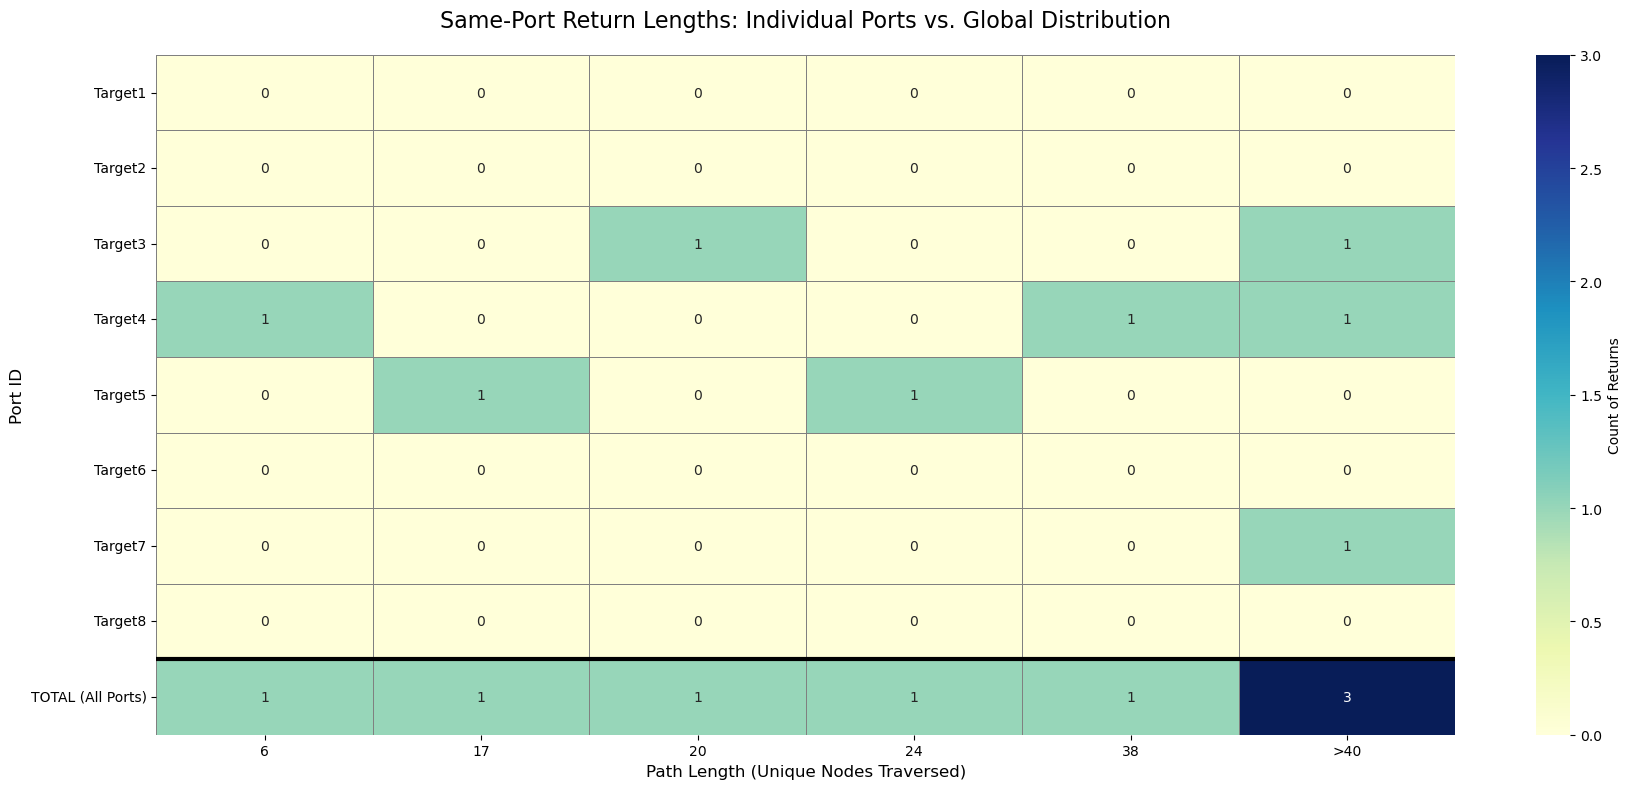

In [2271]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_same_port_returns_with_total(df_clean, port_map, exclude_length=2, max_length=40):
    # 1. Extraction and Sequence Calculation
    port_nodes = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits = port_nodes[port_nodes['reward_size_during_node'] > 0].copy()
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    # Filter for same-port returns and exclude noise
    same_port_mask = (port_visits['current_port_label'] == port_visits['prev_port_label'])
    same_port_df = port_visits[same_port_mask].copy()
    returns_df = same_port_df[same_port_df['seq_length_nodes'] > exclude_length]
    
    # Nothing to plot — say where the funnel emptied out instead of letting
    # seaborn fail on a zero-column frame.
    if returns_df.empty:
        print("No same-port returns to plot. Rows surviving each filter:")
        print(f"  df_clean                              : {len(df_clean)}")
        print(f"  is_port_node == True                  : {len(port_nodes)}")
        print(f"  reward_size_during_node > 0           : {len(port_visits)}")
        print(f"  same port as previous visit           : {len(same_port_df)}")
        print(f"  seq_length_nodes > {exclude_length:<18}: {len(returns_df)}")
        if port_nodes.empty:
            present = set(df_clean['node_name'].dropna().unique())
            print("\n  ⚠️  No port nodes at all — port_map does not match this session's nodes.")
            print(f"  port_map nodes : {sorted(port_map)}")
            print(f"  overlap        : {sorted(set(port_map) & present) or 'none'}")
            print("  Check the subject's entry in PORT_LAYOUTS at the top of the notebook.")
        return
    
    # Clip lengths for readability
    returns_df['length_clipped'] = returns_df['seq_length_nodes'].clip(upper=max_length)
    
    # 2. Build the Heatmap Data
    # Create the contingency table for individual ports
    heatmap_data = pd.crosstab(returns_df['current_port_label'], returns_df['length_clipped'])
    
    # Ensure every configured port is present and sorted by port number
    all_ports = sorted(port_map.values(), key=lambda lbl: int(lbl.replace('Target', '')))
    heatmap_data = heatmap_data.reindex(all_ports).fillna(0)
    
    # 3. Add the "TOTAL" Row
    total_row = heatmap_data.sum(axis=0).to_frame().T
    total_row.index = ['TOTAL (All Ports)']
    heatmap_data = pd.concat([heatmap_data, total_row])

    # 4. Visualization
    plt.figure(figsize=(18, 8))
    
    # Use a diverging or sequential map; 'YlGnBu' is great for counts
    sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", 
                cbar_kws={'label': 'Count of Returns'},
                linewidths=.5, linecolor='gray')

    # Formatting X-axis labels
    cols = heatmap_data.columns.astype(int)
    xtick_labels = [str(c) if c < max_length else f">{max_length}" for c in cols]
    
    plt.xticks(np.arange(len(xtick_labels)) + 0.5, xtick_labels)
    plt.title(f"Same-Port Return Lengths: Individual Ports vs. Global Distribution", fontsize=16, pad=20)
    plt.xlabel("Path Length (Unique Nodes Traversed)", fontsize=12)
    plt.ylabel("Port ID", fontsize=12)
    
    # Draw a visual separator for the Total row
    plt.axhline(y=len(all_ports), color='black', linewidth=3)
    
    plt.tight_layout()
    plt.show()

# Usage:
plot_same_port_returns_with_total(node_summary_df, port_map)

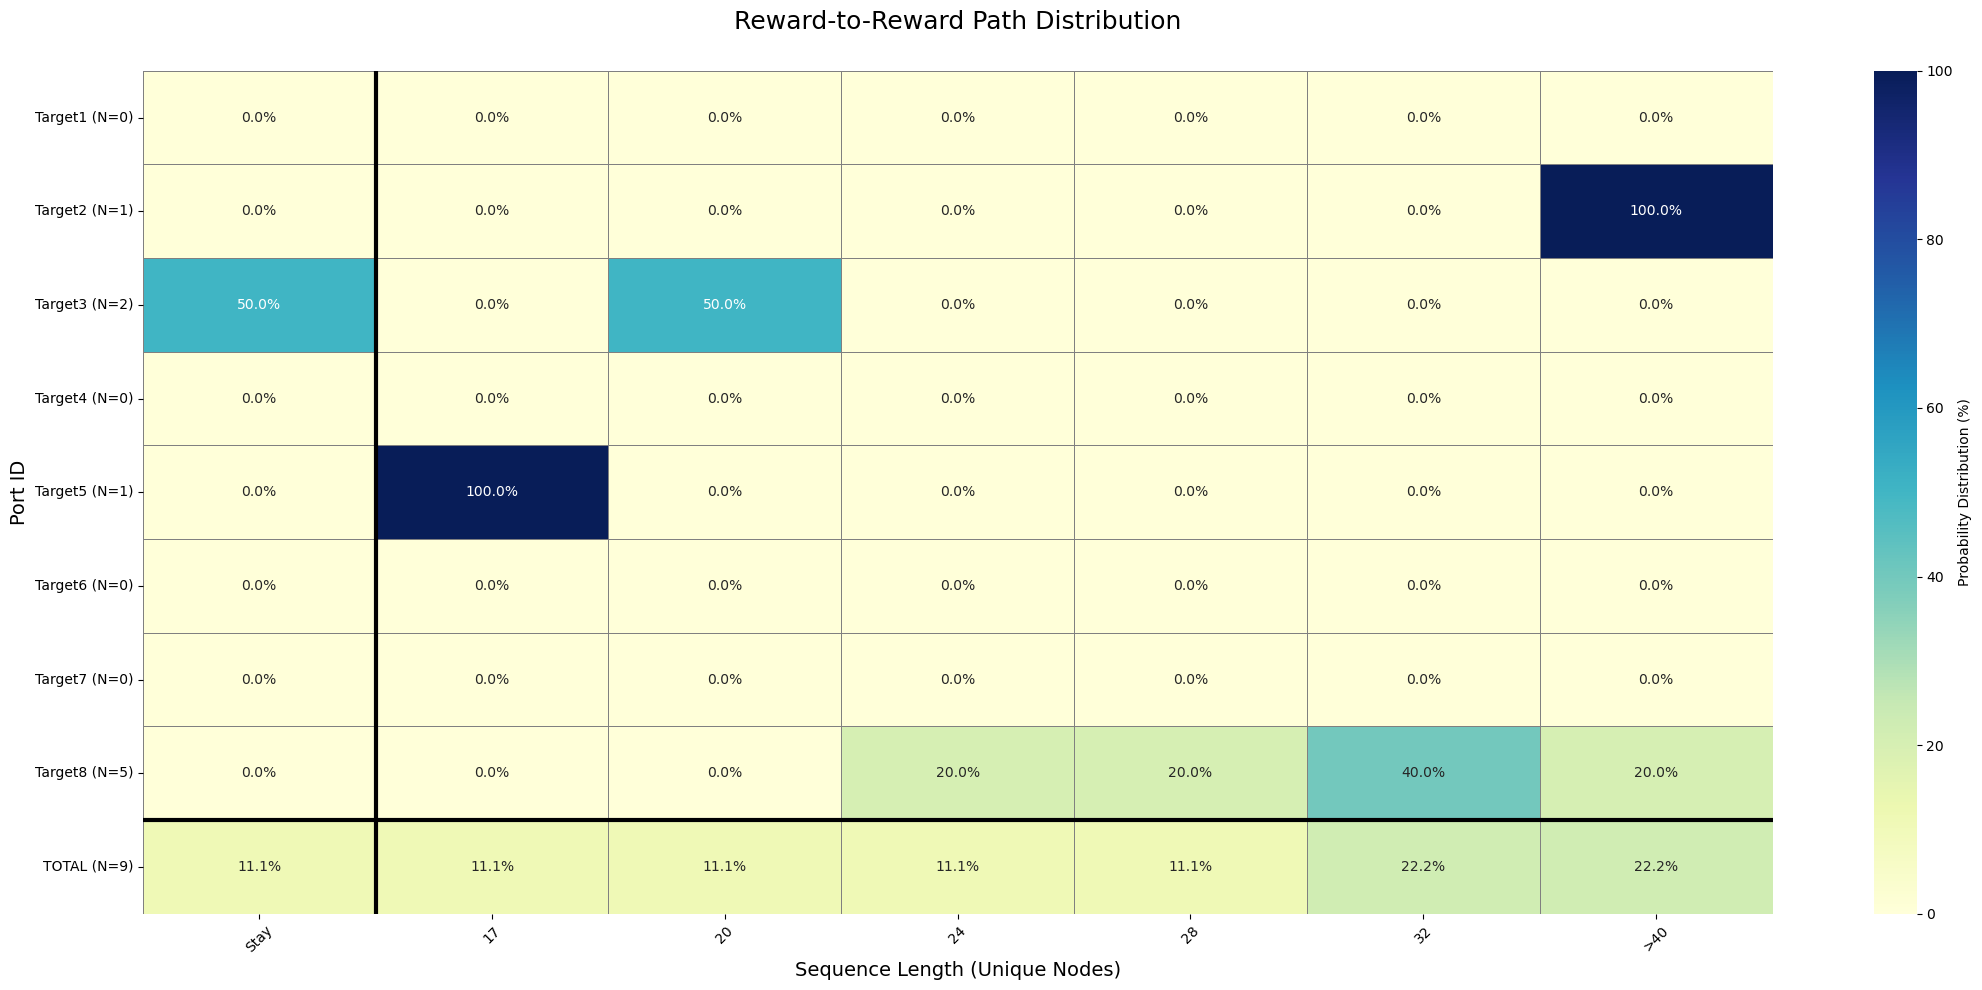

In [2272]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def plot_same_port_returns_with_N(df_clean, port_map, exclude_length=2, max_length=40):
    # 1. Extraction and Sequence Calculation
    port_visits = df_clean[df_clean['reward_during_node'] > 0].copy()
    
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['frame_diff'] = port_visits['start_frame'].diff()
    
    same_port_mask = (port_visits['current_port_label'] == port_visits['prev_port_label']) & \
                     (port_visits['frame_diff'] > 0)
    
    same_port_df = port_visits[same_port_mask].copy()
    returns_df = same_port_df.copy()
    
    # 2. Categorize: "Stays" vs "Returns"
    def categorize_length(l):
        if l <= 3: return -1 
        if l <= exclude_length: return 0 
        return min(l, max_length)

    returns_df['length_cat'] = returns_df['seq_length_nodes'].apply(categorize_length)
    returns_df = returns_df[returns_df['length_cat'] != 0]
    
    # Nothing to plot — say where the funnel emptied out instead of letting
    # seaborn fail on a zero-column frame.
    if returns_df.empty:
        print("No same-port returns to plot. Rows surviving each filter:")
        print(f"  df_clean                              : {len(df_clean)}")
        print(f"  reward_during_node > 0                : {len(port_visits)}")
        print(f"  same port as previous, frame_diff > 0 : {len(same_port_df)}")
        print(f"  length_cat != 0 (exclude_length={exclude_length:<5}) : {len(returns_df)}")
        if len(port_visits) and port_visits['current_port_label'].notna().sum() == 0:
            present = set(df_clean['node_name'].dropna().unique())
            print("\n  ⚠️  No visit mapped to a port label — port_map does not match this session's nodes.")
            print(f"  port_map nodes : {sorted(port_map)}")
            print(f"  overlap        : {sorted(set(port_map) & present) or 'none'}")
            print("  Check the subject's entry in PORT_LAYOUTS at the top of the notebook.")
        return
    
    # 3. Build Heatmap Data (Counts)
    heatmap_counts = pd.crosstab(returns_df['current_port_label'], returns_df['length_cat'])
    all_ports = sorted(port_map.values(), key=lambda lbl: int(lbl.replace('Target', '')))
    heatmap_counts = heatmap_counts.reindex(all_ports).fillna(0)
    
    # Calculate totals for Y-axis labels before adding the TOTAL row
    row_totals = heatmap_counts.sum(axis=1).astype(int)
    y_labels = [f"{port} (N={row_totals[port]})" for port in all_ports]
    
    # Add TOTAL Row
    total_count_val = int(heatmap_counts.values.sum())
    total_row = heatmap_counts.sum(axis=0).to_frame().T
    total_row.index = [f'TOTAL (N={total_count_val})']
    heatmap_data_counts = pd.concat([heatmap_counts, total_row])
    
    # Update y_labels to include the Total row label
    y_labels.append(f'TOTAL (N={total_count_val})')

    # 4. Convert to Percentage
    heatmap_data_pct = (heatmap_data_counts.div(heatmap_data_counts.sum(axis=1), axis=0) * 100).fillna(0)

    # 5. Create Annotation Labels (with % sign)
    annot_labels = heatmap_data_pct.map(lambda x: f"{x:.1f}%")

    # 6. Visualization
    plt.figure(figsize=(22, 10))
    
    ax = sns.heatmap(heatmap_data_pct, 
                     annot=annot_labels, 
                     fmt="", 
                     cmap="YlGnBu", 
                     vmin=0, vmax=100,
                     cbar_kws={'label': 'Probability Distribution (%)'},
                     linewidths=.5, 
                     linecolor='gray')

    # Formatting X-axis labels
    cols = heatmap_data_pct.columns.tolist()
    xtick_labels = ["Stay" if c == -1 else (f">{int(max_length)}" if c >= max_length else str(int(c))) for c in cols]
    
    plt.xticks(np.arange(len(xtick_labels)) + 0.5, xtick_labels, rotation=45)
    plt.yticks(np.arange(len(y_labels)) + 0.5, y_labels, rotation=0) # Add N to Y-axis
    
    plt.title("Reward-to-Reward Path Distribution", fontsize=18, pad=30)
    plt.xlabel("Sequence Length (Unique Nodes)", fontsize=14)
    plt.ylabel("Port ID", fontsize=14)
    
    # Visual cues
    plt.axvline(x=1, color='black', linewidth=3)
    plt.axhline(y=len(all_ports), color='black', linewidth=3)
    
    plt.tight_layout()
    plt.show()

plot_same_port_returns_with_N(node_summary_df, port_map, exclude_length=-1)

In [2273]:
node_summary_df['reward_during_node']

0       False
1       False
2       False
3       False
4       False
        ...  
2398    False
2399    False
2400    False
2401    False
2402    False
Name: reward_during_node, Length: 2403, dtype: bool

In [2274]:
port_visits = node_summary_df[node_summary_df['is_port_node'] == True].copy()
port_visits

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,path_start_time,port_to_port_path_type,path_pair_label,path_seq_length_unique,path_shortest_length,visits_to_this_port_since_reward,node_name_numeric
3,3,L525,NaN,NaN,83,215,133,0,False,0.03,False,0,True,2.075,direct,"(Target6, Target5)",8,8,1,46
11,11,L521,NaN,NaN,370,576,207,0,False,0.00,False,0,True,2.075,direct,"(Target6, Target5)",8,8,1,42
13,13,L521,NaN,NaN,627,714,88,1,False,0.00,False,0,True,15.675,indirect,"(Target5, Target3)",12,10,2,42
25,25,L510,NaN,NaN,974,979,6,2,True,0.03,False,0,True,24.35,indirect,"(Target3, Target4)",10,8,0,32
35,35,L56,NaN,NaN,1144,1144,1,3,False,0.00,False,0,True,24.35,indirect,"(Target3, Target4)",10,8,1,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2363,2363,R59,NaN,NaN,123444,123449,6,161,True,0.00,False,0,True,3032.3,direct,"(Target8, Target7)",8,8,0,100
2365,2365,R59,NaN,NaN,123543,123550,8,162,False,0.00,False,0,True,3088.575,indirect,"(Target7, Target8)",18,8,1,100
2383,2383,R55,NaN,NaN,127320,127325,6,162,True,0.00,False,0,True,3088.575,indirect,"(Target7, Target8)",18,8,0,96
2385,2385,R55,NaN,NaN,127337,127347,11,162,False,0.00,False,0,True,3183.425,direct,"(Target8, Target7)",8,8,1,96


In [2275]:
node_summary_df

,node_visit_idx,node_name,orig_start_frame,orig_end_frame,start_frame,end_frame,duration_frames,trial_idx,reward_during_node,reward_size_during_node,lick_during_node,lick_count_during_node,is_port_node,path_start_time,port_to_port_path_type,path_pair_label,path_seq_length_unique,path_shortest_length,visits_to_this_port_since_reward,node_name_numeric
0,0,L23,NaN,NaN,8,17,10,0,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,6
1,1,L36,NaN,NaN,29,45,17,0,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,13
2,2,L412,NaN,NaN,53,82,30,0,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,19
3,3,L525,NaN,NaN,83,215,133,0,False,0.03,False,0,True,2.075,direct,"(Target6, Target5)",8,8,1,46
4,4,L412,NaN,NaN,216,224,9,0,False,0.00,False,0,False,2.075,direct,"(Target6, Target5)",8,8,0,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2398,2398,R20,NaN,NaN,128259,128278,20,164,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,60
2399,2399,R31,NaN,NaN,128299,128303,5,164,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,65
2400,2400,R20,NaN,NaN,128325,128331,7,164,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,60
2401,2401,R10,NaN,NaN,128387,128403,17,164,False,0.00,False,0,False,<NA>,None,None,<NA>,<NA>,0,58


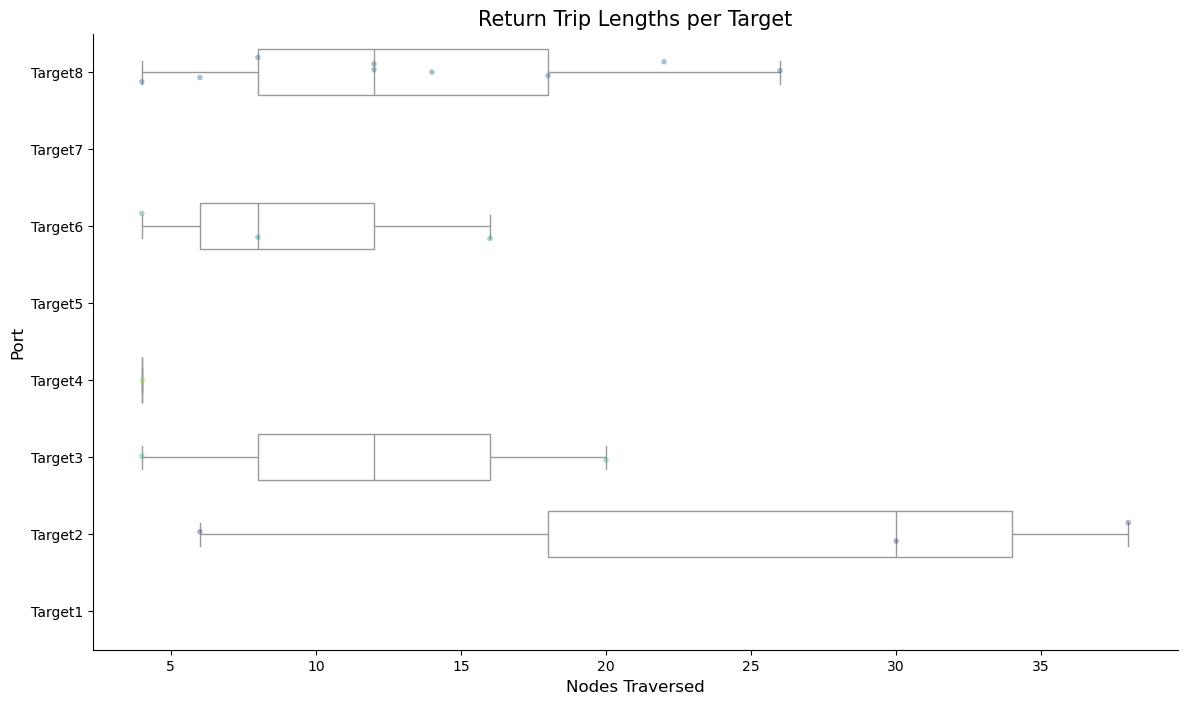

In [2276]:
def plot_same_port_returns_boxplot(df, port_map, exclude_length=2):
    # 1. Extraction (Same logic as yours)
    port_visits = df[df['is_port_node'] == True].copy()
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    same_port_mask = (port_visits['current_port_label'] == port_visits['prev_port_label'])
    same_port_df = port_visits[same_port_mask].copy()
    returns_df = same_port_df[same_port_df['seq_length_nodes'] > exclude_length]
    
    # Nothing to plot — say where the funnel emptied out instead of drawing
    # empty axes.
    if returns_df.empty:
        print("No same-port returns to plot. Rows surviving each filter:")
        print(f"  df                                    : {len(df)}")
        print(f"  is_port_node == True                  : {len(port_visits)}")
        print(f"  same port as previous visit           : {len(same_port_df)}")
        print(f"  seq_length_nodes > {exclude_length:<18}: {len(returns_df)}")
        if port_visits.empty:
            present = set(df['node_name'].dropna().unique())
            print("\n  ⚠️  No port nodes at all — port_map does not match this session's nodes.")
            print(f"  port_map nodes : {sorted(port_map)}")
            print(f"  overlap        : {sorted(set(port_map) & present) or 'none'}")
            print("  Check the subject's entry in PORT_LAYOUTS at the top of the notebook.")
        return
    
    plt.figure(figsize=(14, 8))
    # Reverse port order for the Y-axis
    order = sorted(port_map.values(),
                   key=lambda lbl: int(lbl.replace('Target', '')), reverse=True)
    
    # Boxplot shows quartiles without smoothing the data
    sns.boxplot(data=returns_df, y='current_port_label', x='seq_length_nodes', 
                order=order, color="white", width=0.6, fliersize=0)
    
    # Stripplot shows every single discrete event
    sns.stripplot(data=returns_df, y='current_port_label', x='seq_length_nodes', 
                  order=order, size=4, hue='current_port_label', palette="viridis", 
                  alpha=0.4, jitter=0.2, legend=False)

    plt.title("Return Trip Lengths per Target", fontsize=15)
    plt.ylabel("Port", fontsize=12)
    plt.xlabel("Nodes Traversed", fontsize=12)
    sns.despine()
    plt.show()

plot_same_port_returns_boxplot(node_summary_df, port_map)

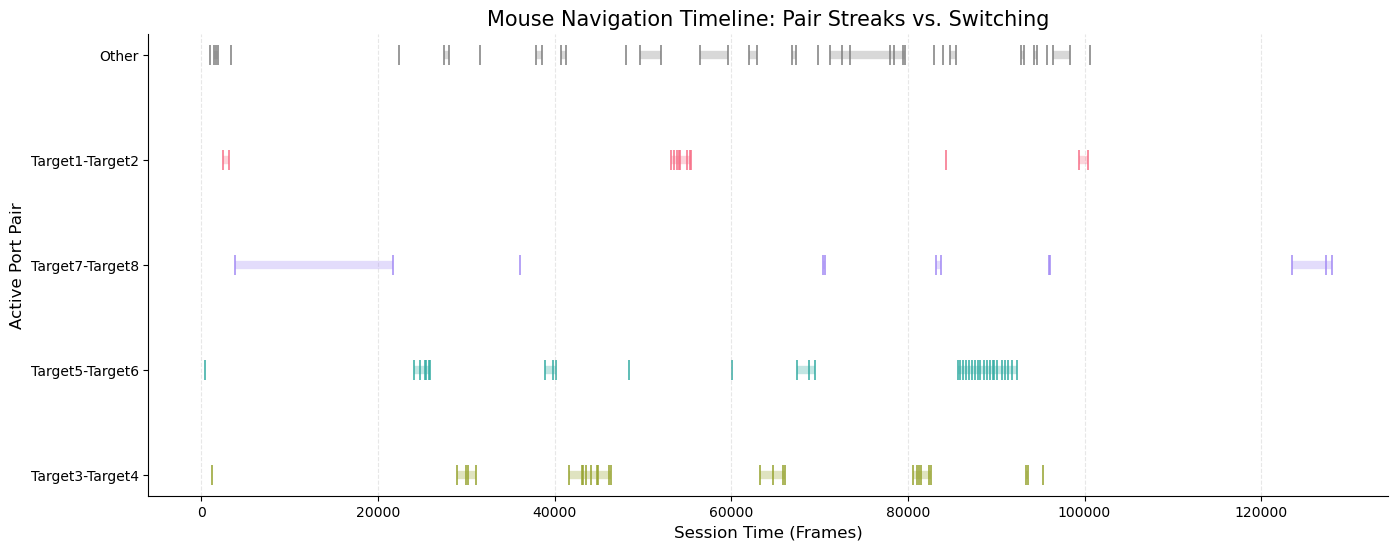

                 count      mean   max
active_pair                           
Other             23.0  1.826087   7.0
Target1-Target2    4.0  3.250000   8.0
Target3-Target4    7.0  3.857143   9.0
Target5-Target6    7.0  5.000000  20.0
Target7-Target8    6.0  2.000000   3.0


In [2277]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_pair_alternation_timeline(df, pairs_to_check, port_map):
    # 1. Filter for all port visits and label them
    port_visits = df[df['is_port_node'] == True].copy()
    port_visits['current_port'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port'] = port_visits['current_port'].shift(1)
    
    # Define labels for our 4 pairs
    pair_labels = {tuple(sorted([p1, p2])): f"{p1}-{p2}" for p1, p2 in [
        ('Target1', 'Target2'), ('Target3', 'Target4'), ('Target5', 'Target6'), ('Target7', 'Target8')
    ]}
    
    def get_pair_name(row):
        if pd.isna(row['prev_port']) or pd.isna(row['current_port']): return "Start"
        if row['prev_port'] == row['current_port']: return "Self" # Ignored later
        sorted_pair = tuple(sorted([row['prev_port'], row['current_port']]))
        return pair_labels.get(sorted_pair, "Other")

    port_visits['active_pair'] = port_visits.apply(get_pair_name, axis=1)
    
    # 2. Filter: Keep transitions between different ports and exclude noise (length > 2)
    mask = (port_visits['active_pair'] != "Self") & (port_visits['node_visit_idx'].diff() > 2)
    valid_tx = port_visits[mask].copy()
    
    # 3. Calculate "Streaks" (how many sequences in a row for the same pair)
    valid_tx['pair_changed'] = valid_tx['active_pair'] != valid_tx['active_pair'].shift(1)
    valid_tx['streak_id'] = valid_tx['pair_changed'].cumsum()
    
    # Plotting
    plt.figure(figsize=(16, 6))
    pair_order = ["Target1-Target2", "Target3-Target4", "Target5-Target6", "Target7-Target8", "Other"]
    colors = sns.color_palette("husl", 4) + ["#808080"]
    color_map = dict(zip(pair_order, colors))

    # Draw streaks as horizontal lines
    for _, group in valid_tx.groupby('streak_id'):
        if len(group) > 1:
            p_name = group['active_pair'].iloc[0]
            if p_name in color_map:
                plt.hlines(y=p_name, xmin=group['start_frame'].min(), 
                           xmax=group['start_frame'].max(), 
                           color=color_map[p_name], linewidth=6, alpha=0.3)

    # Individual transitions as markers
    sns.scatterplot(data=valid_tx, x='start_frame', y='active_pair', hue='active_pair',
                    palette=color_map, hue_order=pair_order, marker='|', s=200, legend=False)

    plt.title("Mouse Navigation Timeline: Pair Streaks vs. Switching", fontsize=15)
    plt.xlabel("Session Time (Frames)", fontsize=12)
    plt.ylabel("Active Port Pair", fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.3)
    sns.despine()
    plt.show()

    # 4. Streak Statistics Summary
    streak_summary = valid_tx.groupby('streak_id').agg({
        'active_pair': 'first',
        'node_visit_idx': 'count'
    }).rename(columns={'node_visit_idx': 'streak_length'})
    
    return streak_summary.groupby('active_pair')['streak_length'].describe()[['count', 'mean', 'max']]

# Run:
streak_stats = plot_pair_alternation_timeline(node_summary_df, pairs_to_check, port_map)
print(streak_stats)

In [2278]:
import pandas as pd
import numpy as np

def calculate_path_directness(df, pairs, port_map, G):
    # 1. Get all port-to-port transitions (same logic as before)
    port_visits = df[df['is_port_node'] == True].copy()
    port_visits['seq_length_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        # Calculate the theoretical shortest path for this specific pair
        # If your maze is perfectly symmetrical, this will be 8 for all.
        try:
            shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)
            print(f"Shortest path between {node_a} and {node_b}: {shortest_dist} nodes")
        except nx.NetworkXNoPath:
            shortest_dist = 8 # Fallback to your stated distance
            
        # Filter for transitions between these two specific ports
        mask = (
            ((port_visits['prev_node_name'] == node_a) & (port_visits['node_name'] == node_b)) |
            ((port_visits['prev_node_name'] == node_b) & (port_visits['node_name'] == node_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length_nodes'])
        
        if not subset.empty:
            # Define 'Direct' as exactly the shortest distance (or your specific threshold of 8)
            # You can change '== shortest_dist' to '<= 8' if you prefer a hard cutoff
            n_direct = (subset['seq_length_nodes'] <= 8).sum()
            n_total = len(subset)
            
            perc_direct = (n_direct / n_total) * 100
            perc_non_direct = 100 - perc_direct
            
            results.append({
                'Pair': f"{p_a} <-> {p_b}",
                'Total Transitions': n_total,
                'Direct (≤8 nodes) %': round(perc_direct, 2),
                'Non-Direct (>8 nodes) %': round(perc_non_direct, 2),
                'Mean Nodes': round(subset['seq_length_nodes'].mean(), 2)
            })
            
    return pd.DataFrame(results)

# Usage:
directness_df = calculate_path_directness(node_summary_df, pairs_to_check, port_map, G)
print(directness_df)

Shortest path between R522 and R526: 8 nodes
Shortest path between L510 and L56: 8 nodes
Shortest path between L521 and L525: 8 nodes
Shortest path between R59 and R55: 8 nodes
                  Pair  Total Transitions  Direct (≤8 nodes) %  \
0  Target1 <-> Target2                 13                76.92   
1  Target3 <-> Target4                 27                29.63   
2  Target5 <-> Target6                 35                91.43   
3  Target7 <-> Target8                 12                58.33   

   Non-Direct (>8 nodes) %  Mean Nodes  
0                    23.08        9.69  
1                    70.37       16.48  
2                     8.57        9.14  
3                    41.67       11.50  


In [2279]:
def calculate_path_directness_fixed(df_clean, pairs, port_map):
    # Filter for all visits to port nodes
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    
    # Calculate unique node distance
    port_visits['seq_length_unique_nodes'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    for node_a, node_b in pairs:
        # SAFETY CHECK: If node_a is already 'Target1', don't look it up in the map
        p_a = port_map[node_a] if node_a in port_map else node_a
        p_b = port_map[node_b] if node_b in port_map else node_b
        
        shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)

        # We filter based on the raw node names (Graph IDs) to be safe
        mask = (
            ((port_visits['prev_node_name'] == node_a) & (port_visits['node_name'] == node_b)) |
            ((port_visits['prev_node_name'] == node_b) & (port_visits['node_name'] == node_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length_unique_nodes'])
        
        if not subset.empty:
            # Here we use the threshold 8
            n_direct = (subset['seq_length_unique_nodes'] <= shortest_dist).sum()
            n_total = len(subset)
            
            results.append({
                'Pair': f"{p_a} <-> {p_b}",
                'Total Transitions': n_total,
                f'Direct (={shortest_dist} unique) %': round((n_direct / n_total) * 100, 2),
                f'Non-Direct (>{shortest_dist} unique) %': round((1 - n_direct / n_total) * 100, 2),
                'Mean Unique Nodes': round(subset['seq_length_unique_nodes'].mean(), 2),
                # We use the summed duration from the aggregated dataframe
                'Mean Duration (Frames)': round(subset['duration_frames'].mean(), 2) 
            })
            
    return pd.DataFrame(results)

# Run the function
directness_df = calculate_path_directness_fixed(node_summary_df, pairs_to_check, port_map)
print(directness_df)

                  Pair  Total Transitions  Direct (=8 unique) %  \
0  Target1 <-> Target2                 13                 76.92   
1  Target3 <-> Target4                 27                 29.63   
2  Target5 <-> Target6                 35                 91.43   
3  Target7 <-> Target8                 12                 58.33   

   Non-Direct (>8 unique) %  Mean Unique Nodes  Mean Duration (Frames)  
0                     23.08               9.69                  113.85  
1                     70.37              16.48                    5.41  
2                      8.57               9.14                  166.31  
3                     41.67              11.50                    5.17  


In [2280]:
def get_unified_port_stats(df_clean, pairs, port_map, G):
    """
    df_clean: The aggregated dataframe (node_name != node_name.shift(1))
    """
    # 1. Filter for port visits
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    
    # 2. Calculate unique node distance and time
    port_visits['seq_length_unique'] = port_visits['node_visit_idx'].diff()
    port_visits['seq_duration_frames'] = port_visits['start_frame'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    
    results = []
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        
        shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)
        # Identify transitions between these ports
        mask = (
            ((port_visits['prev_node_name'] == node_a) & (port_visits['node_name'] == node_b)) |
            ((port_visits['prev_node_name'] == node_b) & (port_visits['node_name'] == node_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length_unique'])
        
        if not subset.empty:
            lengths = subset['seq_length_unique']
            n_total = len(subset)
            # Standardizing 'Direct' as <= shortest_dist unique nodes
            n_direct = (lengths <= shortest_dist).sum() 
            
            results.append({
                'Pair': f"{p_a} <-> {p_b}",
                'Count': n_total,
                'Min Nodes': lengths.min(), # This should now be shortest_dist for direct paths
                'Max Nodes': lengths.max(),
                'Mean Nodes': round(lengths.mean(), 2),
                'Direct %': round((n_direct / n_total) * 100, 2),
                'Non-Direct %': round((1 - n_direct / n_total) * 100, 2)
            })
            
    return pd.DataFrame(results)

# PRE-REQUISITE: You must aggregate first!
final_stats = get_unified_port_stats(node_summary_df, pairs_to_check, port_map, G)
print(final_stats)

                  Pair  Count  Min Nodes  Max Nodes  Mean Nodes  Direct %  \
0  Target1 <-> Target2     13        8.0       18.0        9.69     76.92   
1  Target3 <-> Target4     27        7.0       42.0       16.48     29.63   
2  Target5 <-> Target6     35        8.0       34.0        9.14     91.43   
3  Target7 <-> Target8     12        8.0       26.0       11.50     58.33   

   Non-Direct %  
0         23.08  
1         70.37  
2          8.57  
3         41.67  


Target1 <-> Target2: Overflow count (> 25): 0
Target3 <-> Target4: Overflow count (> 25): 7
Target5 <-> Target6: Overflow count (> 25): 1
Target7 <-> Target8: Overflow count (> 25): 1


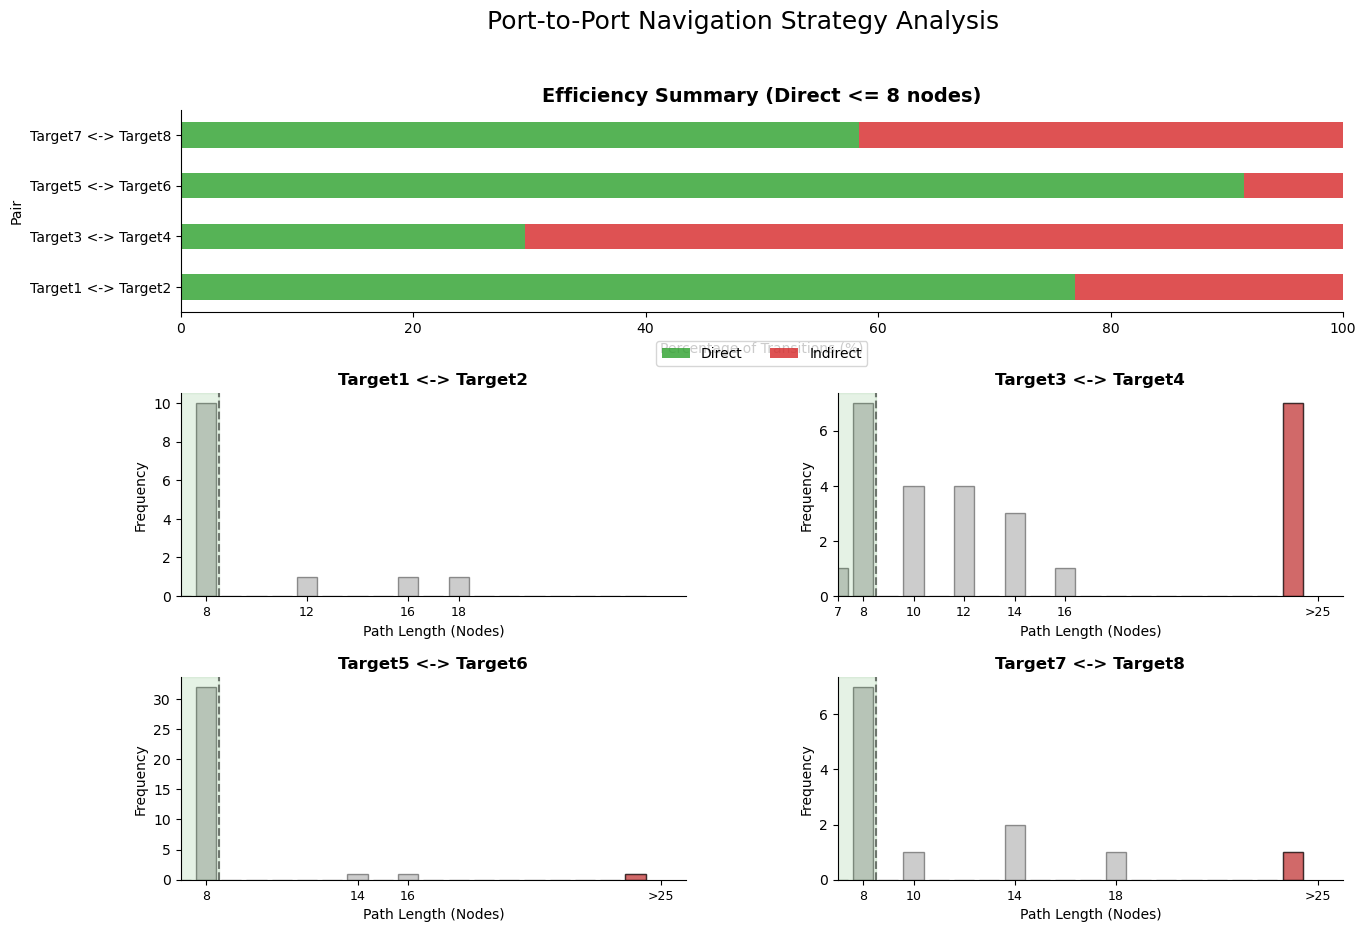

In [2281]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_behavioral_summary(df_clean, pairs, port_map, direct_threshold=8, x_max=25):
    # 1. Prepare Data
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['seq_length'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    # Store data for plotting
    plot_data = []
    summary_list = []
    
    for node_a, node_b in pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        pair_label = f"{p_a} <-> {p_b}"
        
        mask = (
            ((port_visits['prev_port_label'] == p_a) & (port_visits['current_port_label'] == p_b)) |
            ((port_visits['prev_port_label'] == p_b) & (port_visits['current_port_label'] == p_a))
        )
        
        subset = port_visits[mask].dropna(subset=['seq_length']).copy()
        subset['pair_label'] = pair_label
        plot_data.append(subset)
        
        # Calculate summary stats
        n_total = len(subset)
        n_direct = (subset['seq_length'] <= direct_threshold).sum()
        summary_list.append({
            'Pair': pair_label,
            'Direct': (n_direct / n_total) * 100,
            'Indirect': (1 - n_direct / n_total) * 100
        })

    full_plot_df = pd.concat(plot_data)
    summary_df = pd.DataFrame(summary_list)

    # 2. Setup Figure Layout (GridSpec)
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3)
    
    # --- TOP: Stacked Bar Chart ---
    ax_bar = fig.add_subplot(gs[0, :])
    summary_df.set_index('Pair').plot(kind='barh', stacked=True, 
                                      color=['#2ca02c', '#d62728'], alpha=0.8, ax=ax_bar)
    ax_bar.set_title(f"Efficiency Summary (Direct <= {direct_threshold} nodes)", fontsize=14, fontweight='bold')
    ax_bar.set_xlabel("Percentage of Transitions (%)")
    ax_bar.set_xlim(0, 100)
    ax_bar.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), ncol=2)

    # --- BOTTOM: Histograms for each Pair ---
    # We iterate through the 4 pairs and create a histogram for each
    pair_labels = summary_df['Pair'].tolist()
    axes_hist = [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]), 
                 fig.add_subplot(gs[2, 0]), fig.add_subplot(gs[2, 1])]
        
    for i, pair_name in enumerate(pair_labels):
            ax = axes_hist[i]
            data_subset = full_plot_df[full_plot_df['pair_label'] == pair_name]
            data = data_subset['seq_length'].values
            
            # Create bins up to x_max
            bins = np.arange(0, x_max + 2) 
            counts, _ = np.histogram(data, bins=bins)
            
            # Handle Overflow (> x_max)
            overflow_count = np.sum(data > x_max)
            print(f"{pair_name}: Overflow count (> {x_max}): {overflow_count}")
            counts[-1] = overflow_count
            
            # Plot bars manually for fixed width (0.8)
            bin_centers = bins[:-1]
            ax.bar(bin_centers, counts, width=0.8, color='gray', alpha=0.4, edgecolor='black')
            
            # Highlight Overflow bin in red if it exists
            if overflow_count > 0:
                ax.bar(bin_centers[-1], overflow_count, width=0.8, color='#d62728', alpha=0.6, edgecolor='black')

            # Highlight Direct Zone
            ax.axvspan(-0.5, direct_threshold + 0.5, color='green', alpha=0.1)
            ax.axvline(direct_threshold + 0.5, color='black', linestyle='--', alpha=0.5)
            
            # DYNAMIC TICKS: Only where data actually exists
            unique_vals = sorted([v for v in np.unique(data) if v <= x_max])
            tick_labels = [str(int(v)) for v in unique_vals]
            if overflow_count > 0:
                unique_vals.append(x_max + 1)
                tick_labels.append(f">{x_max}")
            
            ax.set_xticks(unique_vals)
            ax.set_xticklabels(tick_labels, fontsize=9)
            
            ax.set_title(pair_name, fontsize=12, fontweight='semibold')
            ax.set_xlabel("Path Length (Nodes)")
            ax.set_ylabel("Frequency")
            ax.set_xlim(7, x_max + 2)

    plt.suptitle("Port-to-Port Navigation Strategy Analysis", fontsize=18, y=0.98)
    sns.despine()
    plt.show()

# Usage:
plot_behavioral_summary(node_summary_df, pairs_to_check, port_map)

In [2282]:
import pandas as pd
import networkx as nx
from itertools import combinations

# NOTE: port-to-port path-type annotation is now done inside build_node_df()
# (via navigraph.analysis.traversal_builder).  node_summary_df already has
# port_to_port_path_type, path_pair_label, path_seq_length_unique,
# path_shortest_length, and path_start_time columns.
#
# annotate_port_to_port_path_type is kept here as a reference / legacy helper.

def annotate_port_to_port_path_type(df_clean, pairs_priority, remaining_pairs, port_map, G, fps=FPS):
    """Legacy annotation helper (annotation is now done by build_node_df)."""
    from navigraph.analysis.traversal_builder import _annotate_path_types
    return _annotate_path_types(
        df_clean, port_map, G, fps,
        node_name_col='node_name',
        start_frame_col='start_frame',
        visit_idx_col='node_visit_idx',
    )


def get_directional_port_stats(df_clean, pairs, port_map, G):
    """Analyzes port-to-port transitions separately for each direction."""
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['seq_length_unique'] = port_visits['node_visit_idx'].diff()
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)

    results = []
    for node_start, node_end in pairs:
        for src, dest in [(node_start, node_end), (node_end, node_start)]:
            p_src, p_dest = port_map[src], port_map[dest]
            try:
                shortest_dist = nx.shortest_path_length(G, source=src, target=dest)
            except nx.NetworkXNoPath:
                shortest_dist = 8
            mask = (port_visits['prev_node_name'] == src) & (port_visits['node_name'] == dest)
            subset = port_visits[mask].dropna(subset=['seq_length_unique'])
            if not subset.empty:
                lengths = subset['seq_length_unique']
                n_total = len(subset)
                n_direct = (lengths <= shortest_dist).sum()
                results.append({
                    'Transition': f"{p_src} -> {p_dest}",
                    'Count': n_total,
                    'Shortest Possible': shortest_dist,
                    'Min Observed': int(lengths.min()),
                    'Max Observed': int(lengths.max()),
                    'Mean Nodes': round(lengths.mean(), 2),
                    'Direct %': round((n_direct / n_total) * 100, 2),
                    'Indirect %': round((1 - n_direct / n_total) * 100, 2),
                })
    return pd.DataFrame(results)


# Run directional stats on already-annotated node_summary_df
directional_stats = get_directional_port_stats(node_summary_df, pairs_to_check, port_map, G)
print(directional_stats)
node_summary_df[['node_name', 'path_start_time', 'port_to_port_path_type', 'path_pair_label']].head(10)


           Transition  Count  Shortest Possible  Min Observed  Max Observed  \
0  Target1 -> Target2      6                  8             8            18   
1  Target2 -> Target1      7                  8             8            16   
2  Target3 -> Target4     13                  8             7            42   
3  Target4 -> Target3     14                  8             8            32   
4  Target5 -> Target6     18                  8             8            34   
5  Target6 -> Target5     17                  8             8             8   
6  Target7 -> Target8      6                  8             8            26   
7  Target8 -> Target7      6                  8             8            14   

   Mean Nodes  Direct %  Indirect %  
0        9.67     83.33       16.67  
1        9.71     71.43       28.57  
2       19.31     15.38       84.62  
3       13.86     42.86       57.14  
4       10.22     83.33       16.67  
5        8.00    100.00        0.00  
6       14.00     33.3

,node_name,path_start_time,port_to_port_path_type,path_pair_label
0,L23,<NA>,None,None
1,L36,<NA>,None,None
2,L412,<NA>,None,None
3,L525,2.075,direct,"(Target6, Target5)"
4,L412,2.075,direct,"(Target6, Target5)"
5,L36,2.075,direct,"(Target6, Target5)"
6,L23,2.075,direct,"(Target6, Target5)"
7,L11,2.075,direct,"(Target6, Target5)"
8,L22,2.075,direct,"(Target6, Target5)"
9,L35,2.075,direct,"(Target6, Target5)"


In [2283]:
# Verify the new none values count
print("Distribution of port_to_port_path_type:")
print(node_summary_df['port_to_port_path_type'].value_counts(dropna=False))
print()

# Breakdown
none_count = node_summary_df['port_to_port_path_type'].isna().sum()
direct_count = (node_summary_df['port_to_port_path_type'] == 'direct').sum()
indirect_count = (node_summary_df['port_to_port_path_type'] == 'indirect').sum()

print(f"Total nodes: {len(node_summary_df)}")
print(f"  Direct path nodes: {direct_count}")
print(f"  Indirect path nodes: {indirect_count}")
print(f"  Unclassified (None): {none_count}")
print(f"  ➜ Reduction from 2,323 to {none_count} (removed {2323 - none_count} nodes)")

# Show composition of None values
none_at_port_nodes = node_summary_df[node_summary_df['is_port_node'] == True]['port_to_port_path_type'].isna().sum()
print(f"\nNone values at port nodes: {none_at_port_nodes}")

# Show first example of a classified cross-visit transition using tuple labels
priority_port_pairs = set()
for node_a, node_b in pairs_to_check:
    pair_tuple = (port_map[node_a], port_map[node_b])
    priority_port_pairs.add(pair_tuple)
    priority_port_pairs.add((pair_tuple[1], pair_tuple[0]))

cross_visit_example = node_summary_df[
    (node_summary_df['port_to_port_path_type'].notna()) &
    (node_summary_df['path_pair_label'].apply(lambda x: isinstance(x, tuple) and x not in priority_port_pairs))
]

if len(cross_visit_example) > 0:
    print(f"\nExample cross-visit transition (not in priority pairs):")
    sample = cross_visit_example.iloc[0]
    print(f"  Transition tuple: {sample['path_pair_label']}")
    print(f"  Path Type: {sample['port_to_port_path_type']}")
    print(f"  Seq Length: {sample['path_seq_length_unique']}, Shortest: {sample['path_shortest_length']}")
    print(f"  Start Time (s): {sample['path_start_time']:.3f}")

Distribution of port_to_port_path_type:
port_to_port_path_type
indirect    1152
direct       714
None         537
Name: count, dtype: int64

Total nodes: 2403
  Direct path nodes: 714
  Indirect path nodes: 1152
  Unclassified (None): 537
  ➜ Reduction from 2,323 to 537 (removed 1786 nodes)

None values at port nodes: 136

Example cross-visit transition (not in priority pairs):
  Transition tuple: ('Target5', 'Target3')
  Path Type: indirect
  Seq Length: 12, Shortest: 10
  Start Time (s): 15.675


In [2284]:
# Diagnose remaining None values
none_nodes = node_summary_df[node_summary_df['port_to_port_path_type'].isna()]

# Check pre/post session
first_port_idx = node_summary_df[node_summary_df['is_port_node'] == True].index.min()
last_port_idx = node_summary_df[node_summary_df['is_port_node'] == True].index.max()

before_first = none_nodes[none_nodes.index < first_port_idx]
after_last = none_nodes[none_nodes.index > last_port_idx]
in_between = none_nodes[(none_nodes.index >= first_port_idx) & (none_nodes.index <= last_port_idx)]

print("Remaining None values breakdown:")
print(f"  Before first port visit: {len(before_first)}")
print(f"  After last port visit: {len(after_last)}")
print(f"  Within session but unclassified: {len(in_between)}")
print()

# Check if any same-port transitions exist in the in_between None values by looking at port visits
if len(in_between) > 0:
    port_transitions = []
    port_visits_list = node_summary_df[node_summary_df['is_port_node'] == True]
    for i in range(1, len(port_visits_list)):
        src = port_visits_list.iloc[i-1]['node_name']
        dest = port_visits_list.iloc[i]['node_name']
        src_port = port_map[src]
        dest_port = port_map[dest]
        if src_port == dest_port:  # Same-port transition
            port_transitions.append((src_port, src_port, src, dest))
    
    if port_transitions:
        print(f"  Same-port transitions (intentionally excluded): {len(port_transitions)}")
        for src_port, dest_port, src_node, dest_node in port_transitions[:3]:
            print(f"    • {src_port} -> {dest_port} ({src_node} -> {dest_node})")
        if len(port_transitions) > 3:
            print(f"    ... and {len(port_transitions)-3} more")

Remaining None values breakdown:
  Before first port visit: 3
  After last port visit: 9
  Within session but unclassified: 525

  Same-port transitions (intentionally excluded): 190
    • Target5 -> Target5 (L521 -> L521)
    • Target4 -> Target4 (L56 -> L56)
    • Target4 -> Target4 (L56 -> L56)
    ... and 187 more


In [2285]:
# Verification: how many node visits were labeled by path type
print(node_summary_df['port_to_port_path_type'].value_counts(dropna=False))

# Preview labeled rows
node_summary_df[node_summary_df['port_to_port_path_type'].notna()][
    ['node_name', 'node_visit_idx', 'port_to_port_path_type', 'path_pair_label', 'path_seq_length_unique', 'path_shortest_length']
].head(15)

port_to_port_path_type
indirect    1152
direct       714
None         537
Name: count, dtype: int64


,node_name,node_visit_idx,port_to_port_path_type,path_pair_label,path_seq_length_unique,path_shortest_length
3,L525,3,direct,"(Target6, Target5)",8,8
4,L412,4,direct,"(Target6, Target5)",8,8
5,L36,5,direct,"(Target6, Target5)",8,8
6,L23,6,direct,"(Target6, Target5)",8,8
7,L11,7,direct,"(Target6, Target5)",8,8
8,L22,8,direct,"(Target6, Target5)",8,8
9,L35,9,direct,"(Target6, Target5)",8,8
10,L410,10,direct,"(Target6, Target5)",8,8
11,L521,11,direct,"(Target6, Target5)",8,8
13,L521,13,indirect,"(Target5, Target3)",12,10


In [2286]:
# Investigate where None values come from

port_node_rows = node_summary_df[node_summary_df['is_port_node'] == True]
if port_node_rows.empty:
    present = set(node_summary_df['node_name'].dropna().unique())
    raise ValueError(
        f"No row in node_summary_df ({len(node_summary_df)} rows) is flagged "
        f"is_port_node — nothing to analyse.\n"
        f"  port_map nodes        : {sorted(port_map)}\n"
        f"  of those, visited     : {sorted(set(port_map) & present) or 'none'}\n"
        f"  is_port_node == True  : 0\n"
        f"  A session need not visit every port, but if some port nodes were "
        f"visited and none are flagged, is_port_node was computed against the "
        f"wrong node list — re-run the cells that set it (build_node_df / "
        f"handle_reward_nans) after the port-layout cell."
    )

# 1. Nodes before first port
first_port_idx = port_node_rows.index[0]
nodes_before_first_port = len(node_summary_df.loc[:first_port_idx-1])
print(f"Nodes BEFORE first port: {nodes_before_first_port}")

# 2. Nodes after last port
last_port_idx = port_node_rows.index[-1]
nodes_after_last_port = len(node_summary_df.loc[last_port_idx+1:])
print(f"Nodes AFTER last port: {nodes_after_last_port}")

# 3. Identify all actual port-to-port transitions (consecutive port visits)
port_visits = port_node_rows.copy()
port_visits['prev_node'] = port_visits['node_name'].shift(1)
actual_transitions = port_visits[['prev_node', 'node_name']].dropna().drop_duplicates().values

print(f"\nActual port-to-port transitions occurring: {len(actual_transitions)}")
for prev_node, curr_node in actual_transitions[:10]:  # Show first 10
    print(f"  {port_map.get(prev_node, prev_node)} -> {port_map.get(curr_node, curr_node)}", end="")
    # Check if tracked
    is_tracked = (prev_node, curr_node) in pairs_to_check or (curr_node, prev_node) in pairs_to_check
    print(f"  {'✓ TRACKED' if is_tracked else '✗ NOT TRACKED'}")

# 4. Count nodes in untracked transitions
valid_pairs = set()
for node_a, node_b in pairs_to_check:
    valid_pairs.add((node_a, node_b))
    valid_pairs.add((node_b, node_a))

untracked_counts = 0
port_indices = port_visits.index.tolist()
for i in range(1, len(port_indices)):
    src = node_summary_df.loc[port_indices[i-1], 'node_name']
    dest = node_summary_df.loc[port_indices[i], 'node_name']
    if (src, dest) not in valid_pairs:
        segment_len = port_indices[i] - port_indices[i-1]
        untracked_counts += segment_len

print(f"\nNodes in UNTRACKED port-to-port transitions: {untracked_counts}")
print(f"Nodes before first port + after last port + in untracked transitions: {nodes_before_first_port + nodes_after_last_port + untracked_counts}")
print(f"Total None values: {(node_summary_df['port_to_port_path_type'].isna()).sum()}")

print(f"\nSummary breakdown of {(node_summary_df['port_to_port_path_type'].isna()).sum()} None values:")
print(f"  - Before first port visit: {nodes_before_first_port}")
print(f"  - After last port visit: {nodes_after_last_port}")
print(f"  - In untracked port transitions: {untracked_counts}")

Nodes BEFORE first port: 3
Nodes AFTER last port: 9

Actual port-to-port transitions occurring: 44
  Target6 -> Target5  ✓ TRACKED
  Target5 -> Target5  ✗ NOT TRACKED
  Target5 -> Target3  ✗ NOT TRACKED
  Target3 -> Target4  ✓ TRACKED
  Target4 -> Target4  ✗ NOT TRACKED
  Target4 -> Target6  ✗ NOT TRACKED
  Target6 -> Target3  ✗ NOT TRACKED
  Target3 -> Target2  ✗ NOT TRACKED
  Target2 -> Target2  ✗ NOT TRACKED
  Target2 -> Target1  ✓ TRACKED

Nodes in UNTRACKED port-to-port transitions: 1361
Nodes before first port + after last port + in untracked transitions: 1373
Total None values: 537

Summary breakdown of 537 None values:
  - Before first port visit: 3
  - After last port visit: 9
  - In untracked port transitions: 1361


In [2287]:
import os

out_dir = (
    f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/"
    f"resources/outputs/{subject}/{DD}_{MM}_{YYYY}"
)
os.makedirs(out_dir, exist_ok=True)

# ── node_df (canonical node-only) ─────────────────────────────────────────
node_df.to_csv(f"{out_dir}/node_df.csv", index=False)
node_df.to_pickle(f"{out_dir}/node_df.pkl")
print(f"✓ Saved node_df          → {out_dir}/node_df.csv / .pkl")

# ── node_summary_df (backward-compat alias for node_df) ───────────────────
node_df.to_csv(f"{out_dir}/node_summary_df.csv", index=False)
node_df.to_pickle(f"{out_dir}/node_summary_df.pkl")
print(f"✓ Saved node_summary_df  → {out_dir}/node_summary_df.csv / .pkl")

# ── node_edge_df (canonical node+edge with bounce fix) ────────────────────
node_edge_df.to_csv(f"{out_dir}/node_edge_df.csv", index=False)
node_edge_df.to_pickle(f"{out_dir}/node_edge_df.pkl")
print(f"✓ Saved node_edge_df     → {out_dir}/node_edge_df.csv / .pkl")


✓ Saved node_df          → /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/node_df.csv / .pkl
✓ Saved node_summary_df  → /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/node_summary_df.csv / .pkl
✓ Saved node_edge_df     → /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/node_edge_df.csv / .pkl


In [2288]:
def build_port_transition_segments(node_summary_df):
    """Return one row per port-to-port transition segment, including seq lengths."""
    required_cols = {'trial_idx', 'start_frame', 'path_pair_label', 'port_to_port_path_type', 'path_seq_length_unique'}
    missing_cols = required_cols - set(node_summary_df.columns)
    if missing_cols:
        raise ValueError(f"node_summary_df is missing required columns: {sorted(missing_cols)}")

    segments = node_summary_df[
        node_summary_df['port_to_port_path_type'].notna()
    ][['trial_idx', 'start_frame', 'path_pair_label', 'port_to_port_path_type', 'path_seq_length_unique']].copy()

    if segments.empty:
        raise ValueError(
            "No port-to-port segments: every row of node_summary_df has "
            "port_to_port_path_type = NaN, so there is nothing to annotate.\n"
            f"  rows                        : {len(node_summary_df)}\n"
            f"  is_port_node == True        : "
            f"{int(node_summary_df['is_port_node'].sum()) if 'is_port_node' in node_summary_df else 'column missing'}\n"
            f"  distinct port nodes visited : "
            f"{sorted(set(node_summary_df.loc[node_summary_df.get('is_port_node', False) == True, 'node_name'].unique()))}\n"
            "  A path type is only assigned between two CONSECUTIVE visits to "
            "ports with different Target labels, so this is empty when the "
            "mapping/port_map do not match the session, or when the mouse "
            "never moved between two different ports. Re-run the cells that "
            "build node_summary_df after the port-layout cell."
        )

    segments = segments.sort_values(['trial_idx', 'start_frame'])
    segments = segments.groupby(
        ['trial_idx', 'start_frame', 'path_pair_label', 'port_to_port_path_type'],
        as_index=False
    ).first()

    segments['source_port'] = segments['path_pair_label'].apply(
        lambda x: x[0] if isinstance(x, tuple) and len(x) == 2 else pd.NA
    )
    segments['dest_port'] = segments['path_pair_label'].apply(
        lambda x: x[1] if isinstance(x, tuple) and len(x) == 2 else pd.NA
    )
    # Ensure seq length is integer
    segments['path_seq_length_unique'] = segments['path_seq_length_unique'].astype('Int64')
    return segments.sort_values(['trial_idx', 'start_frame']).reset_index(drop=True)

In [2289]:
def annotate_reward_port_transition_types(reward_df, node_summary_df, trial_offset=1):
    """Annotate each reward trial with the direct/indirect chain to the next port and lengths."""
    rewards = reward_df.copy()
    segments = build_port_transition_segments(node_summary_df)

    rewards['next_reward_port'] = rewards['reward_port'].shift(-1)
    rewards['next_reward_port_label'] = rewards['next_reward_port'].apply(
        lambda x: f"Target{int(x)}" if pd.notna(x) else pd.NA
    )
    # ... [keep your existing pd.NA initializations here] ...
    rewards['reward_port_transition_type_chain'] = pd.NA
    rewards['reward_port_transition_pairs'] = pd.NA
    rewards['reward_port_transition_lengths'] = pd.NA
    rewards['reward_port_transition_length_sum'] = pd.NA
    rewards['reward_port_transition_start_frame'] = pd.NA
    rewards['reward_port_transition_start_time'] = pd.NA
    rewards['reward_port_transition_match_trial_idx'] = pd.NA
    rewards['reward_port_transition_match_offset'] = pd.NA
    rewards['reward_port_expected_shortest_length'] = pd.NA

    if segments.empty:
        return rewards

    labeled_count = 0
    skipped_same_port = 0
    unmatched_count = 0
    
    used_segments = set()
    
    # NEW TIME CONSTRAINT: Track the timeline so the algorithm cannot look backward
    last_valid_start_frame = -1 

    for idx, row in rewards.iterrows():
        current_port_num = row['reward_port']
        next_port_num = row['next_reward_port']

        if pd.isna(next_port_num):
            continue

        if int(current_port_num) == int(next_port_num):
            skipped_same_port += 1
            continue

        current_port = f"Target{int(current_port_num)}"
        next_port = f"Target{int(next_port_num)}"
        reward_trial_idx = int(row['trial_idx'])
        candidate_trials = {reward_trial_idx + delta for delta in range(-trial_offset, trial_offset + 1)}

        candidate_segments = segments[segments['trial_idx'].isin(candidate_trials)].sort_values([
            'trial_idx', 'start_frame'
        ])
        
        # NEW TIME CONSTRAINT: Completely eliminate any segments from the past.
        # Trial N can only use video data that occurs AFTER the paths found for Trial N-1.
        candidate_segments = candidate_segments[candidate_segments['start_frame'] >= last_valid_start_frame]

        # Filter out consumed segments (exact matches we've already used)
        keys = list(zip(candidate_segments['trial_idx'], candidate_segments['start_frame']))
        mask = [k not in used_segments for k in keys]
        candidate_segments = candidate_segments[mask]

        start_candidates = candidate_segments[candidate_segments['source_port'] == current_port]

        best_match = None

        for _, start_seg in start_candidates.iterrows():
            chain_types = [start_seg['port_to_port_path_type']]
            chain_pairs = [start_seg['path_pair_label']]
            chain_lengths = [int(start_seg['path_seq_length_unique']) if not pd.isna(start_seg['path_seq_length_unique']) else 0]
            cursor_port = start_seg['dest_port']
            last_start_frame = start_seg['start_frame']
            last_trial_idx = int(start_seg['trial_idx'])
            
            current_chain_keys = [(last_trial_idx, last_start_frame)]

            if cursor_port == next_port:
                best_match = (chain_types, chain_pairs, chain_lengths, start_seg['start_frame'], int(start_seg['trial_idx']), current_chain_keys)
                break

            later_segments = candidate_segments[candidate_segments['start_frame'] > last_start_frame]
            for _, seg in later_segments.iterrows():
                if seg['source_port'] != cursor_port:
                    continue

                chain_types.append(seg['port_to_port_path_type'])
                chain_pairs.append(seg['path_pair_label'])
                chain_lengths.append(int(seg['path_seq_length_unique']) if not pd.isna(seg['path_seq_length_unique']) else 0)
                cursor_port = seg['dest_port']
                last_start_frame = seg['start_frame']
                last_trial_idx = int(seg['trial_idx'])
                
                current_chain_keys.append((last_trial_idx, last_start_frame))

                if cursor_port == next_port:
                    best_match = (chain_types, chain_pairs, chain_lengths, start_seg['start_frame'], int(start_seg['trial_idx']), current_chain_keys)
                    break

            if best_match is not None:
                break

        if best_match is None:
            unmatched_count += 1
            continue

        # Unpack the current_chain_keys from best_match
        chain_types, chain_pairs, chain_lengths, start_frame, match_trial_idx, chain_keys = best_match
        
        used_segments.update(chain_keys)
        
        # NEW TIME CONSTRAINT: Update the global time clock.
        # We find the highest frame number used in the current path chain,
        # so the next trial is forced to look only at frames occurring after this point.
        max_frame_in_chain = max(frame for _, frame in chain_keys)
        last_valid_start_frame = max_frame_in_chain

        rewards.at[idx, 'reward_port_transition_type_chain'] = ' + '.join(chain_types)
        rewards.at[idx, 'reward_port_transition_pairs'] = tuple(chain_pairs)
        # ... [keep your existing assignment block here] ...
        rewards.at[idx, 'reward_port_transition_lengths'] = tuple(chain_lengths)
        rewards.at[idx, 'reward_port_transition_length_sum'] = sum(chain_lengths)
        rewards.at[idx, 'reward_port_transition_start_frame'] = start_frame
        rewards.at[idx, 'reward_port_transition_start_time'] = start_frame / 40.0  # Assuming FPS is 40, replace with your FPS var
        rewards.at[idx, 'reward_port_transition_match_trial_idx'] = match_trial_idx
        rewards.at[idx, 'reward_port_transition_match_offset'] = match_trial_idx - reward_trial_idx

        try:
            src_node = inv_port_map[current_port]
            dst_node = inv_port_map[next_port]
            expected_len = nx.shortest_path_length(G, source=src_node, target=dst_node)
        except Exception:
            expected_len = pd.NA
        rewards.at[idx, 'reward_port_expected_shortest_length'] = expected_len

        labeled_count += 1

    print(f"Reward transitions labeled: {labeled_count}")
    print(f"Reward transitions skipped because of same-port consecutive rewards: {skipped_same_port}")
    print(f"Reward transitions not matched within ±{trial_offset} trial offset: {unmatched_count}")

    return rewards

In [2290]:
# Annotate reward_df with the path-type chain to the next port (including lengths)
reward_df = annotate_reward_port_transition_types(reward_df, node_summary_df, trial_offset=1)
reward_df_valid = reward_df[reward_df['reward_time'].notna()].copy()

print("\nReward path-type chain preview with lengths:")
preview_cols = [
    'trial_idx', 'reward_port', 'next_reward_port', 'reward_port_transition_type_chain',
    'reward_port_transition_pairs', 'reward_port_transition_lengths', 'reward_port_transition_length_sum',
    'reward_port_expected_shortest_length'
]
print(reward_df[preview_cols].head(20))

Reward transitions labeled: 124
Reward transitions skipped because of same-port consecutive rewards: 39
Reward transitions not matched within ±1 trial offset: 0

Reward path-type chain preview with lengths:
    trial_idx  reward_port  next_reward_port  \
0           0            6               5.0   
1           1            5               3.0   
2           2            3               4.0   
3           3            4               6.0   
4           4            6               3.0   
5           5            3               2.0   
6           6            2               1.0   
7           7            1               1.0   
8           8            1               2.0   
9           9            2               7.0   
10         10            7               8.0   
11         11            8               8.0   
12         12            8               8.0   
13         13            8               7.0   
14         14            7               5.0   
15         15            

In [2291]:
# Summary of reward trial direct/indirect classification (robust chain parsing)
df_rewards = reward_df.copy()
total_trials = len(df_rewards)
labeled_series = df_rewards['reward_port_transition_type_chain'].dropna()
labeled_count = len(labeled_series)

def classify_chain(chain):
    if pd.isna(chain):
        return 'Unlabeled'
    # split on '+' and strip whitespace, normalize to lowercase
    parts = [p.strip().lower() for p in str(chain).split('+') if p.strip()]
    parts_set = set(parts)
    allowed = {'direct','indirect'}
    if parts_set == {'direct'}:
        return 'Direct Only'
    if parts_set == {'indirect'}:
        return 'Indirect Only'
    if parts_set.issubset(allowed) and len(parts_set) > 1:
        return 'Mixed (Direct+Indirect)'
    if parts:
        return 'Other/Unknown'
    return 'Unlabeled'

df_rewards['reward_transition_category'] = df_rewards['reward_port_transition_type_chain'].apply(classify_chain)

counts = df_rewards['reward_transition_category'].value_counts(dropna=False)

direct_only = counts.get('Direct Only', 0)
indirect_only = counts.get('Indirect Only', 0)
mixed = counts.get('Mixed (Direct+Indirect)', 0)
others = counts.get('Other/Unknown', 0)
unlabeled = counts.get('Unlabeled', 0)

def pct(part, whole):
    return round(100 * part / whole, 2) if whole > 0 else 0.0

summary = {
    'Category': ['Direct Only', 'Indirect Only', 'Mixed (Direct+Indirect)', 'Other/Unknown', 'Unlabeled', 'Labeled Total', 'Total Trials'],
    'Count': [direct_only, indirect_only, mixed, others, unlabeled, labeled_count, total_trials],
    'Pct_of_Labeled': [pct(direct_only, labeled_count), pct(indirect_only, labeled_count), pct(mixed, labeled_count), pct(others, labeled_count), pct(unlabeled, labeled_count), pct(labeled_count, labeled_count), pct(total_trials, labeled_count)],
    'Pct_of_Total': [pct(direct_only, total_trials), pct(indirect_only, total_trials), pct(mixed, total_trials), pct(others, total_trials), pct(unlabeled, total_trials), pct(labeled_count, total_trials), 100.0]
}

import pandas as pd
summary_table = pd.DataFrame(summary)
print('Reward Trial Direct/Indirect Summary (exact-chain parsing)')
print(summary_table.to_string(index=False) )

Reward Trial Direct/Indirect Summary (exact-chain parsing)
               Category  Count  Pct_of_Labeled  Pct_of_Total
            Direct Only     78           62.90         47.56
          Indirect Only     46           37.10         28.05
Mixed (Direct+Indirect)      0            0.00          0.00
          Other/Unknown      0            0.00          0.00
              Unlabeled     40           32.26         24.39
          Labeled Total    124          100.00         75.61
           Total Trials    164          132.26        100.00


In [2292]:
# Inspect why reward trials are unlabeled (same-port, no-next, or other/unmatched)
unlabeled_mask = reward_df['reward_port_transition_type_chain'].isna()

total_unlabeled = int(unlabeled_mask.sum())

same_port_mask = unlabeled_mask & (reward_df['next_reward_port'] == reward_df['reward_port'])
no_next_mask = unlabeled_mask & reward_df['next_reward_port'].isna()
other_mask = unlabeled_mask & (~same_port_mask) & (~no_next_mask)

other_unmatched_mask = other_mask & reward_df['reward_port_transition_start_frame'].isna()
other_matched_mask = other_mask & reward_df['reward_port_transition_start_frame'].notna()

print(f"Total unlabeled reward trials: {total_unlabeled}")
print(f"  - Same-port consecutive rewards: {int(same_port_mask.sum())}")
print(f"  - No next reward (last trial): {int(no_next_mask.sum())}")
print(f"  - Other unlabeled: {int(other_mask.sum())}")
print(f"      - Other but unmatched (no matching segment found): {int(other_unmatched_mask.sum())}")
print(f"      - Other with start frame present (partial match present): {int(other_matched_mask.sum())}")

# Show examples of 'other' cases for debugging
n_examples = 10
print("\nExamples of 'other' unlabeled trials (first rows):")
cols = ['trial_idx', 'reward_port', 'next_reward_port', 'reward_port_transition_start_frame',
    'reward_port_transition_match_trial_idx', 'reward_port_transition_type_chain',
    'reward_port_transition_pairs', 'reward_port_transition_lengths']
display_df = reward_df.loc[other_mask, cols].head(n_examples)
print(display_df.to_string(index=False))

Total unlabeled reward trials: 40
  - Same-port consecutive rewards: 39
  - No next reward (last trial): 1
  - Other unlabeled: 0
      - Other but unmatched (no matching segment found): 0
      - Other with start frame present (partial match present): 0

Examples of 'other' unlabeled trials (first rows):
Empty DataFrame
Columns: [trial_idx, reward_port, next_reward_port, reward_port_transition_start_frame, reward_port_transition_match_trial_idx, reward_port_transition_type_chain, reward_port_transition_pairs, reward_port_transition_lengths]
Index: []


In [2293]:
reward_df.to_csv(f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/reward_df_annotated.csv", index=False)

✓ Graph saved to: /var/home/almogmeir/Documents/M.Sc/Project/Graphs/NPC4/exploration_within_alternation/05_19_2026_exploration_within_alternation.png


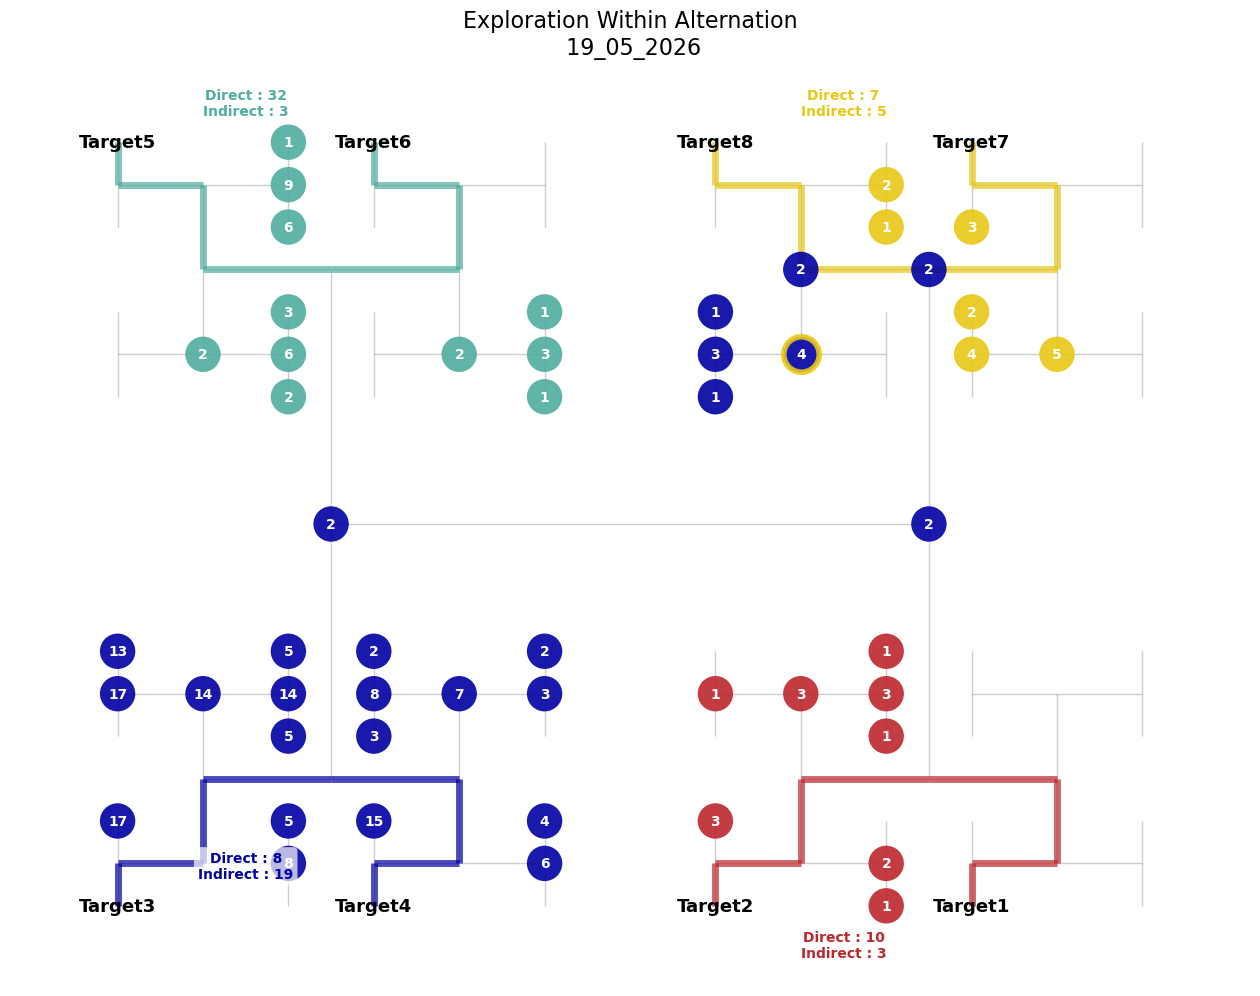

In [2294]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_strict_error_heatmap_with_stats(G, node_positions, df_clean, pairs, port_map, save_path=None):
    base_colors = {
        'Target1-Target2': '#bc272d', 
        'Target3-Target4': '#0000a2', 
        'Target5-Target6': '#50ad9f', 
        'Target7-Target8': '#e9c716'
    }

    # 1. DETERMINE THEORETICAL DIRECT PATHS & INIT STATS
    pair_direct_nodes = {}
    pair_direct_edges = {}
    pair_stats = {f"{port_map[a]}-{port_map[b]}": {'direct': 0, 'indirect': 0} for a, b in pairs}
    
    for a, b in pairs:
        pair_key = f"{port_map[a]}-{port_map[b]}"
        try:
            shortest_path = nx.shortest_path(G, a, b)
            shortest_len = len(shortest_path)
            intermediate_nodes = set(shortest_path[1:-1]) if len(shortest_path) > 2 else set()
            pair_direct_nodes[pair_key] = (intermediate_nodes, shortest_len)
            
            edges = set()
            for i in range(len(shortest_path) - 1):
                edges.add(tuple(sorted((shortest_path[i], shortest_path[i+1]))))
            pair_direct_edges[pair_key] = edges
            
        except nx.NetworkXNoPath:
            pair_direct_nodes[pair_key] = (set(), 0)
            pair_direct_edges[pair_key] = set()
    
    # 2. COUNT DETOUR NODES AND PATH EFFICIENCY
    pair_error_counts = {p: Counter() for p in pair_direct_edges.keys()}
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    for i in range(1, len(indices)):
        p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
        for a, b in pairs:
            if {p1, p2} == {a, b}:
                pair_key = f"{port_map[a]}-{port_map[b]}"
                path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                
                # Efficiency Check
                direct_intermediate, ideal_len = pair_direct_nodes[pair_key]
                if len(path) <= ideal_len:
                    pair_stats[pair_key]['direct'] += 1
                else:
                    pair_stats[pair_key]['indirect'] += 1
                
                # Detour Node Counting
                intermediate_nodes = path[1:-1] if len(path) > 2 else []
                detour_nodes = [n for n in intermediate_nodes if n not in direct_intermediate]
                pair_error_counts[pair_key].update(detour_nodes)

    # 3. PLOTTING
    plt.figure(figsize=(16, 12))
    ax = plt.gca()

    # Maze skeleton
    nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.1, edge_color='black', arrows=False)

    # Draw Colored Direct Edges (The Backbone)
    for pair_name, edges in pair_direct_edges.items():
        if edges:
            nx.draw_networkx_edges(G, node_positions, edgelist=list(edges), 
                                   edge_color=base_colors[pair_name], width=5, alpha=0.7, arrows=False)

    # 4. ANNOTATE PAIR STATS (Midway between ports)
    for a, b in pairs:
        pair_key = f"{port_map[a]}-{port_map[b]}"
        pos_a = node_positions[a]
        pos_b = node_positions[b]
        # Calculate midpoint
        mid_x, mid_y = (pos_a[0] + pos_b[0]) / 2, (pos_a[1] + pos_b[1]) / 2
        # offset of 30 pixels on the y scale, for pairs (1,2) and (3,4) it is down, for the others up
        if (a,b) == ('R522','R526') or (a,b) == ('L56','L510'):
            mid_y -= 30
        else:
            mid_y += 30
        
        stats_text = f"Direct : {pair_stats[pair_key]['direct']}\nIndirect : {pair_stats[pair_key]['indirect']}"
        ax.text(mid_x, mid_y, stats_text, color=base_colors[pair_key], 
                fontweight='bold', fontsize=10, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    # 5. CONFLICT RESOLUTION & CUSTOM NODE DRAWING
    all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
    for node in all_error_nodes:
        node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
        contributing_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total_visits = sum(node_stats.values())
        num_pairs = len(contributing_pairs)
        
        # Style logic
        fill_color = 'gray'
        edge_color = 'black'
        text_color = 'black'
        lw = 1

        if num_pairs == 1:
            fill_color = base_colors[contributing_pairs[0]]
            edge_color = 'none'; text_color = 'white'; lw = 0
        elif num_pairs >= 2:
            fill_color = base_colors[contributing_pairs[0]]
            edge_color = base_colors[contributing_pairs[1]]
            text_color = 'white'; lw = 4
        
        nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=[fill_color], 
                               edgecolors=edge_color, linewidths=lw, node_size=650, alpha=0.9, ax=ax)
        nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
                                font_size=10, font_color=text_color, font_weight='bold', ax=ax)

    # Ports
    port_labels = {k: v for k, v in port_map.items()}
    nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=13, font_weight='bold')
 
    plt.title(f"Exploration Within Alternation\n {DD_MM_YYYY}", fontsize=16)
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ Graph saved to: {save_path}")
    plt.show()



plot_strict_error_heatmap_with_stats(G, node_positions, node_summary_df, pairs_to_check, port_map, save_path=ensure_dir(rf"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/exploration_within_alternation/{MM_DD_YYYY}_exploration_within_alternation.png"))

✓ Graph saved to: /var/home/almogmeir/Documents/M.Sc/Project/Graphs/NPC4/exploration_within_alternation/Apex/05_19_2026_exploration_within_alternation_apex.png


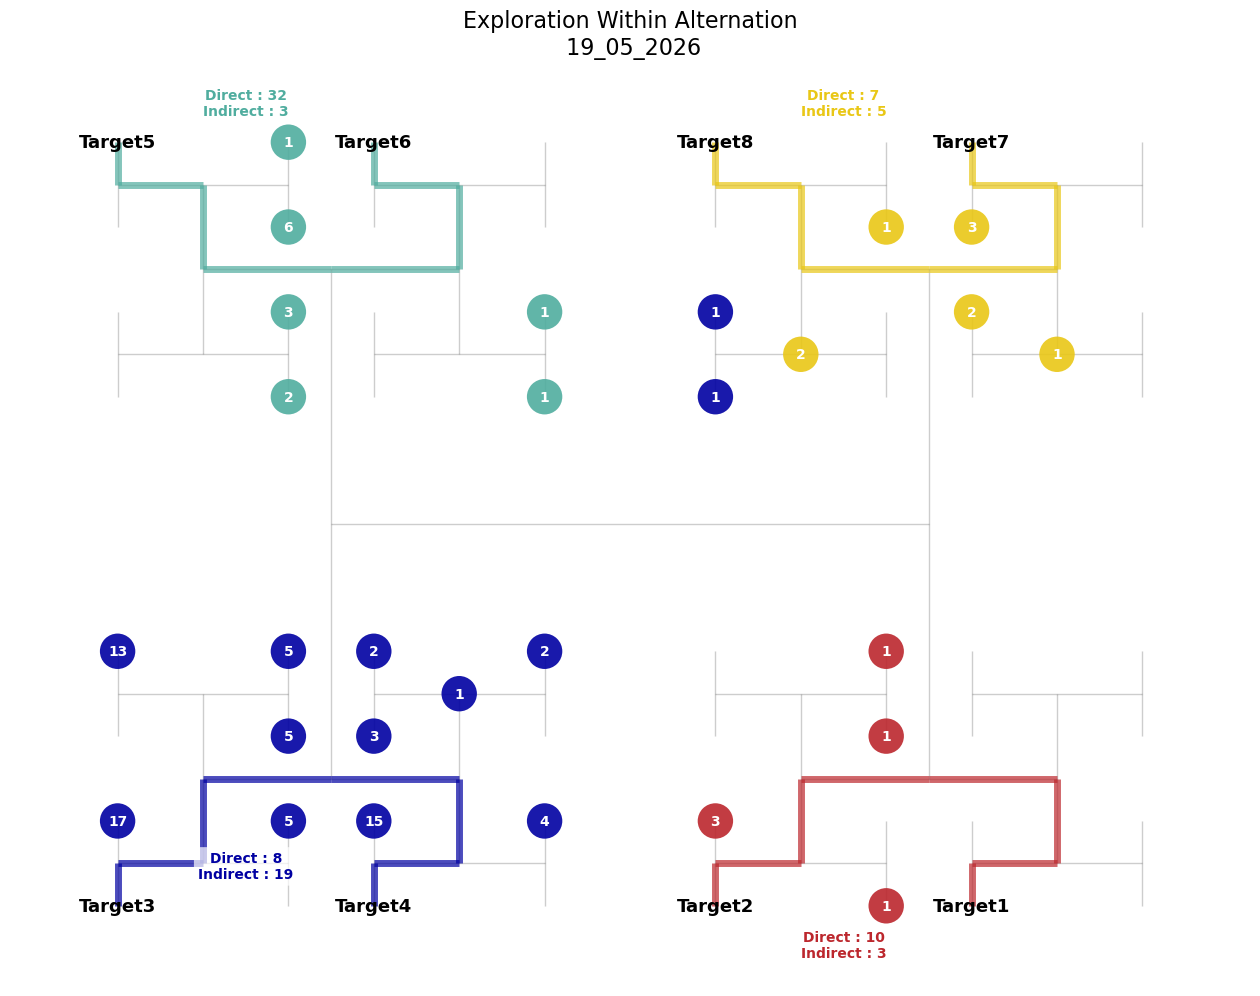

In [2295]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

def plot_strict_error_heatmap_with_stats(G, node_positions, df_clean, pairs, port_map, save_path=None):
    base_colors = {
        'Target1-Target2': '#bc272d', 
        'Target3-Target4': '#0000a2', 
        'Target5-Target6': '#50ad9f', 
        'Target7-Target8': '#e9c716'
    }

    # 1. DETERMINE THEORETICAL DIRECT PATHS & INIT STATS
    pair_direct_nodes = {}
    pair_direct_edges = {}
    pair_stats = {f"{port_map[a]}-{port_map[b]}": {'direct': 0, 'indirect': 0} for a, b in pairs}
    
    for a, b in pairs:
        pair_key = f"{port_map[a]}-{port_map[b]}"
        try:
            shortest_path = nx.shortest_path(G, a, b)
            shortest_len = len(shortest_path)
            intermediate_nodes = set(shortest_path[1:-1]) if len(shortest_path) > 2 else set()
            pair_direct_nodes[pair_key] = (intermediate_nodes, shortest_len)
            
            edges = set()
            for i in range(len(shortest_path) - 1):
                edges.add(tuple(sorted((shortest_path[i], shortest_path[i+1]))))
            pair_direct_edges[pair_key] = edges
            
        except nx.NetworkXNoPath:
            pair_direct_nodes[pair_key] = (set(), 0)
            pair_direct_edges[pair_key] = set()
    
    # 2. COUNT DETOUR NODES AND PATH EFFICIENCY
    # For each detour excursion, count only the furthest node(s) once; ties count to all tied nodes
    pair_error_counts = {p: Counter() for p in pair_direct_edges.keys()}
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    for i in range(1, len(indices)):
        p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
        for a, b in pairs:
            if {p1, p2} == {a, b}:
                pair_key = f"{port_map[a]}-{port_map[b]}"
                path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                
                # Efficiency Check
                direct_intermediate, ideal_len = pair_direct_nodes[pair_key]
                if len(path) <= ideal_len:
                    pair_stats[pair_key]['direct'] += 1
                else:
                    pair_stats[pair_key]['indirect'] += 1
                
                # Detour apex counting: count only one or more tied furthest nodes per excursion
                if len(path) > 2 and direct_intermediate:
                    intermediate_nodes = path[1:-1]
                    detour_run = []
                    detour_runs = []
                    for node in intermediate_nodes:
                        if node in direct_intermediate:
                            if detour_run:
                                detour_runs.append(detour_run)
                                detour_run = []
                        else:
                            detour_run.append(node)
                    if detour_run:
                        detour_runs.append(detour_run)
                    
                    for run in detour_runs:
                        if not run:
                            continue
                        if len(run) == 1:
                            apex_nodes = run
                        else:
                            # Apex = all nodes tied for the maximum distance from any direct-path intermediate node
                            scored_nodes = []
                            for node in run:
                                try:
                                    score = min(
                                        nx.shortest_path_length(G, node, direct_node)
                                        for direct_node in direct_intermediate
                                    )
                                except Exception:
                                    score = 0
                                scored_nodes.append((score, node))
                            max_score = max(score for score, _ in scored_nodes)
                            apex_nodes = [node for score, node in scored_nodes if score == max_score]
                        for apex_node in apex_nodes:
                            pair_error_counts[pair_key][apex_node] += 1

    # 3. PLOTTING
    plt.figure(figsize=(16, 12))
    ax = plt.gca()

    # Maze skeleton
    nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.1, edge_color='black', arrows=False)

    # Draw Colored Direct Edges (The Backbone)
    for pair_name, edges in pair_direct_edges.items():
        if edges:
            nx.draw_networkx_edges(G, node_positions, edgelist=list(edges), 
                                   edge_color=base_colors[pair_name], width=5, alpha=0.7, arrows=False)

    # 4. ANNOTATE PAIR STATS (Midway between ports)
    for a, b in pairs:
        pair_key = f"{port_map[a]}-{port_map[b]}"
        pos_a = node_positions[a]
        pos_b = node_positions[b]
        # Calculate midpoint
        mid_x, mid_y = (pos_a[0] + pos_b[0]) / 2, (pos_a[1] + pos_b[1]) / 2
        # offset of 30 pixels on the y scale, for pairs (1,2) and (3,4) it is down, for the others up
        if (a,b) == ('R522','R526') or (a,b) == ('L56','L510'):
            mid_y -= 30
        else:
            mid_y += 30
        
        stats_text = f"Direct : {pair_stats[pair_key]['direct']}\nIndirect : {pair_stats[pair_key]['indirect']}"
        ax.text(mid_x, mid_y, stats_text, color=base_colors[pair_key], 
                fontweight='bold', fontsize=10, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    # 5. CONFLICT RESOLUTION & CUSTOM NODE DRAWING
    all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
    for node in all_error_nodes:
        node_stats = {p: counts[node] for p, counts in pair_error_counts.items() if node in counts}
        contributing_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total_visits = sum(node_stats.values())
        num_pairs = len(contributing_pairs)
        
        # Style logic
        fill_color = 'gray'
        edge_color = 'black'
        text_color = 'black'
        lw = 1

        if num_pairs == 1:
            fill_color = base_colors[contributing_pairs[0]]
            edge_color = 'none'; text_color = 'white'; lw = 0
        elif num_pairs >= 2:
            fill_color = base_colors[contributing_pairs[0]]
            edge_color = base_colors[contributing_pairs[1]]
            text_color = 'white'; lw = 4
        
        nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=[fill_color], 
                               edgecolors=edge_color, linewidths=lw, node_size=650, alpha=0.9, ax=ax)
        nx.draw_networkx_labels(G, node_positions, labels={node: str(total_visits)}, 
                                font_size=10, font_color=text_color, font_weight='bold', ax=ax)

    # Ports
    port_labels = {k: v for k, v in port_map.items()}
    nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=13, font_weight='bold')
 
    plt.title(f"Exploration Within Alternation\n {DD_MM_YYYY}", fontsize=16)
    plt.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ Graph saved to: {save_path}")
    plt.show()



plot_strict_error_heatmap_with_stats(G, node_positions, node_summary_df, pairs_to_check, port_map, save_path=ensure_dir(rf"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/exploration_within_alternation/Apex/{MM_DD_YYYY}_exploration_within_alternation_apex.png"))

In [2296]:
# Generate all possible pairs of ports
from itertools import combinations
all_pairs = list(combinations(port_map.keys(), 2))

# Remove from all_pairs the pairs already in pairs_to_check
remaining_pairs = [pair for pair in all_pairs if pair not in pairs_to_check and (pair[1], pair[0]) not in pairs_to_check]

final_stats_all = get_unified_port_stats(node_summary_df, remaining_pairs, port_map, G)

final_stats_all

,Pair,Count,Min Nodes,Max Nodes,Mean Nodes,Direct %,Non-Direct %
0,Target1 <-> Target3,1,11.0,11.0,11.00,100.00,0.00
1,Target1 <-> Target5,1,37.0,37.0,37.00,0.00,100.00
2,Target1 <-> Target8,1,10.0,10.0,10.00,100.00,0.00
3,Target2 <-> Target3,4,11.0,73.0,27.50,50.00,50.00
4,Target2 <-> Target5,2,11.0,11.0,11.00,100.00,0.00
5,Target2 <-> Target7,2,10.0,10.0,10.00,100.00,0.00
6,Target2 <-> Target8,3,10.0,16.0,12.67,33.33,66.67
7,Target3 <-> Target5,2,12.0,30.0,21.00,0.00,100.00
8,Target3 <-> Target6,2,10.0,16.0,13.00,50.00,50.00
9,Target3 <-> Target7,7,11.0,23.0,13.00,71.43,28.57


✓ Graph saved to: /var/home/almogmeir/Documents/M.Sc/Project/Graphs/NPC4/switch_patch_directness/05_19_2026_switch_patch_directness


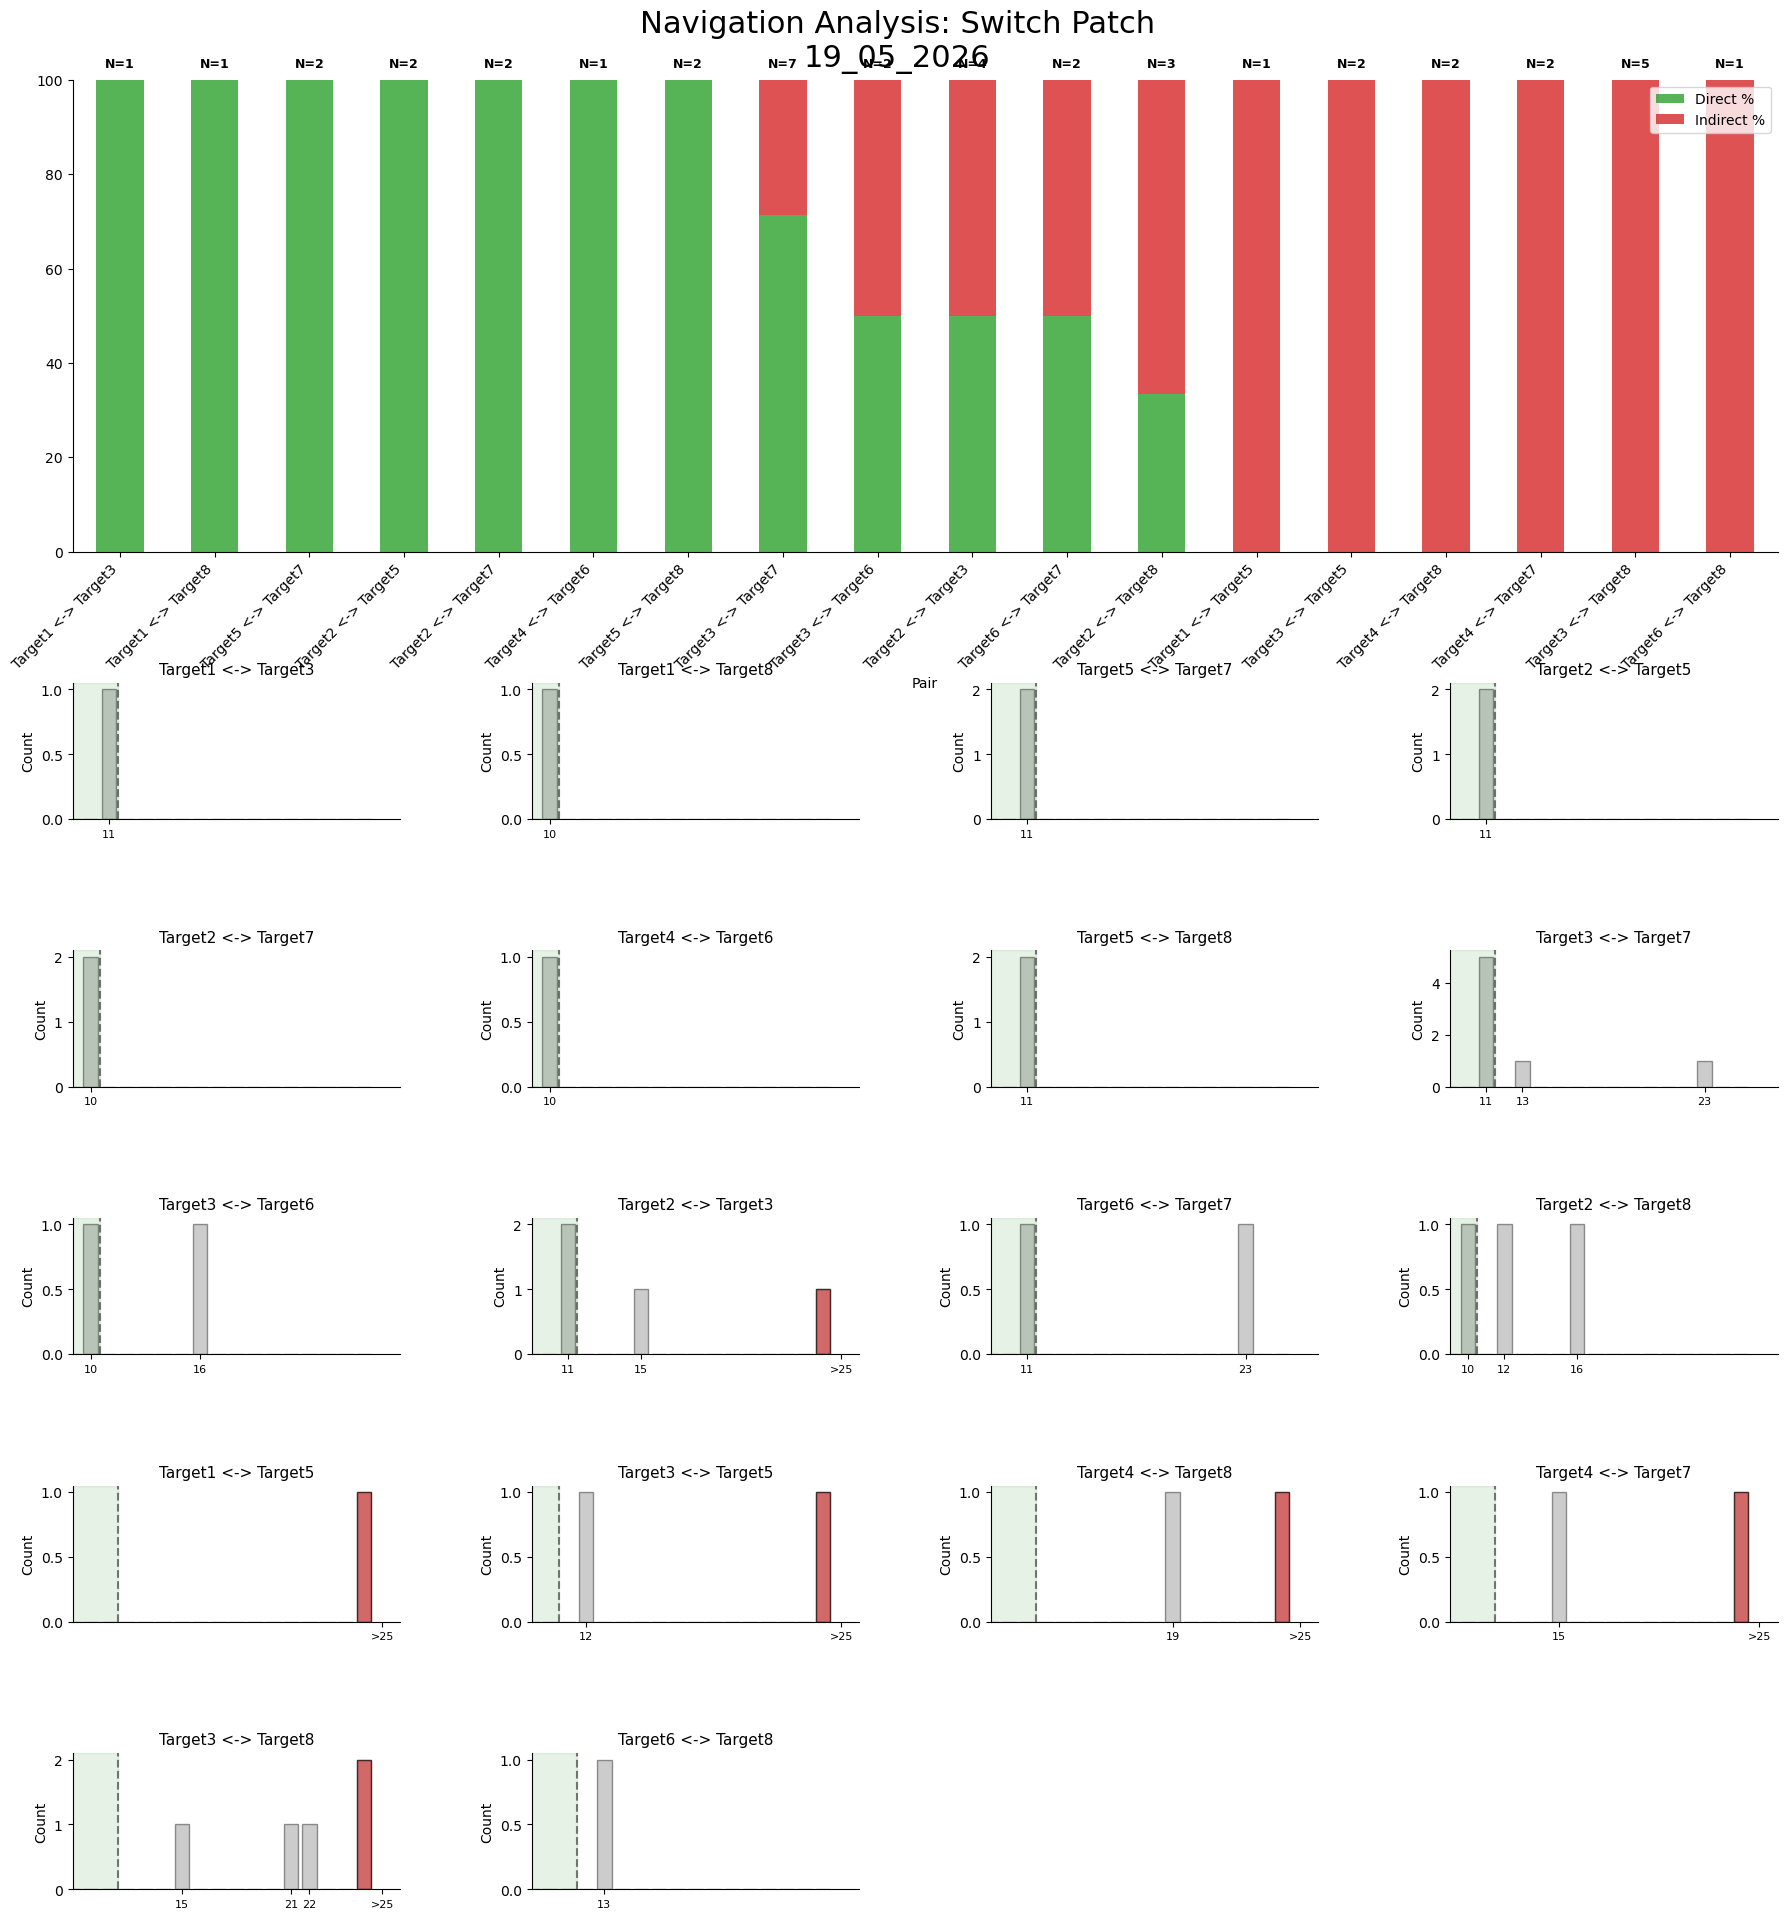

In [2297]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import networkx as nx

def plot_large_scale_behavioral_summary_overflow(df_clean, all_pairs, port_map, G, x_max=25, save_path=None):
    # 1. Prepare Data
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['seq_length'] = port_visits['node_visit_idx'].diff()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    plot_data = []
    summary_list = []
    
    for node_a, node_b in all_pairs:
        p_a, p_b = port_map[node_a], port_map[node_b]
        pair_label = f"{p_a} <-> {p_b}"
        try:
            shortest_dist = nx.shortest_path_length(G, source=node_a, target=node_b)
        except:
            shortest_dist = 8 
        
        mask = (
            ((port_visits['prev_port_label'] == p_a) & (port_visits['current_port_label'] == p_b)) |
            ((port_visits['prev_port_label'] == p_b) & (port_visits['current_port_label'] == p_a))
        )
        subset = port_visits[mask].dropna(subset=['seq_length']).copy()
        if subset.empty: continue
            
        subset['pair_label'] = pair_label
        subset['shortest_dist'] = shortest_dist
        plot_data.append(subset)
        
        n_total = len(subset)
        n_direct = (subset['seq_length'] <= shortest_dist).sum()
        summary_list.append({'Pair': pair_label, 'Direct %': (n_direct/n_total)*100, 
                             'Indirect %': (1-n_direct/n_total)*100, 'Shortest': shortest_dist, 'Count': n_total})

    full_plot_df = pd.concat(plot_data)
    summary_df = pd.DataFrame(summary_list).sort_values('Direct %', ascending=False)

    # 2. Setup Figure
    num_pairs = len(summary_df)
    cols = 4
    rows = int(np.ceil(num_pairs / cols))
    h_ratios = [1.5, 1.0] + [1.0] * rows 
    fig = plt.figure(figsize=(22, 6 + (rows * 3.5)))
    gs = fig.add_gridspec(rows + 2, cols, height_ratios=h_ratios, hspace=0.9, wspace=0.4)
    
    ax_bar = fig.add_subplot(gs[0:2, :])
    for i, (index, row) in enumerate(summary_df.iterrows()):
        ax_bar.text(i, 102, f"N={int(row['Count'])}", 
                    ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)
    summary_df.set_index('Pair')[['Direct %', 'Indirect %']].plot(kind='bar', stacked=True, 
                                                                  color=['#2ca02c', '#d62728'], alpha=0.8, ax=ax_bar)
    # ax_bar.set_title("Navigation Efficiency", fontsize=18, fontweight='bold', pad=20)
    plt.xticks(rotation=45, ha='right')

    # 3. Histograms with Overflow Bin
    pair_labels = summary_df['Pair'].tolist()
    for i, pair_name in enumerate(pair_labels):
        r, c = (i // cols) + 2, i % cols
        ax = fig.add_subplot(gs[r, c])
        
        data_subset = full_plot_df[full_plot_df['pair_label'] == pair_name]
        data = data_subset['seq_length'].values
        threshold = data_subset['shortest_dist'].iloc[0]
        
        # Binning logic: 0 to x_max, plus one bin for overflow
        bins = np.arange(0, x_max + 2) 
        counts, _ = np.histogram(data, bins=bins)
        
        # Add all counts > x_max to the last bin (overflow)
        overflow_count = np.sum(data > x_max)
        counts[-1] = overflow_count
        
        # Plotting manually using bar to ensure fixed width
        bin_centers = bins[:-1]
        ax.bar(bin_centers, counts, width=0.8, color='gray', alpha=0.4, edgecolor='black')
        
        # Color the overflow bin differently to stand out
        if overflow_count > 0:
            ax.bar(bin_centers[-1], overflow_count, width=0.8, color='#d62728', alpha=0.6, edgecolor='black')

        # Formatting
        ax.axvspan(-0.5, threshold + 0.5, color='green', alpha=0.1)
        ax.axvline(threshold + 0.5, color='black', linestyle='--', alpha=0.5)
        
        # Tick Management
        unique_vals = sorted([v for v in np.unique(data) if v <= x_max])
        tick_labels = [str(int(v)) for v in unique_vals]
        if overflow_count > 0:
            unique_vals.append(x_max + 1)
            tick_labels.append(f">{x_max}")
        
        ax.set_xticks(unique_vals)
        ax.set_xticklabels(tick_labels, fontsize=8)
        ax.set_title(f"{pair_name}", fontsize=11)
        ax.set_xlim(9, x_max + 2)
        ax.set_ylabel("Count")

    plt.suptitle(f"Navigation Analysis: Switch Patch\n{DD_MM_YYYY}", fontsize=22, y=0.91)
    sns.despine()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
        print(f"✓ Graph saved to: {save_path}")
    plt.show()

plot_large_scale_behavioral_summary_overflow(node_summary_df, remaining_pairs, port_map, G, x_max=25, save_path=ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/switch_patch_directness/{MM_DD_YYYY}_switch_patch_directness"))

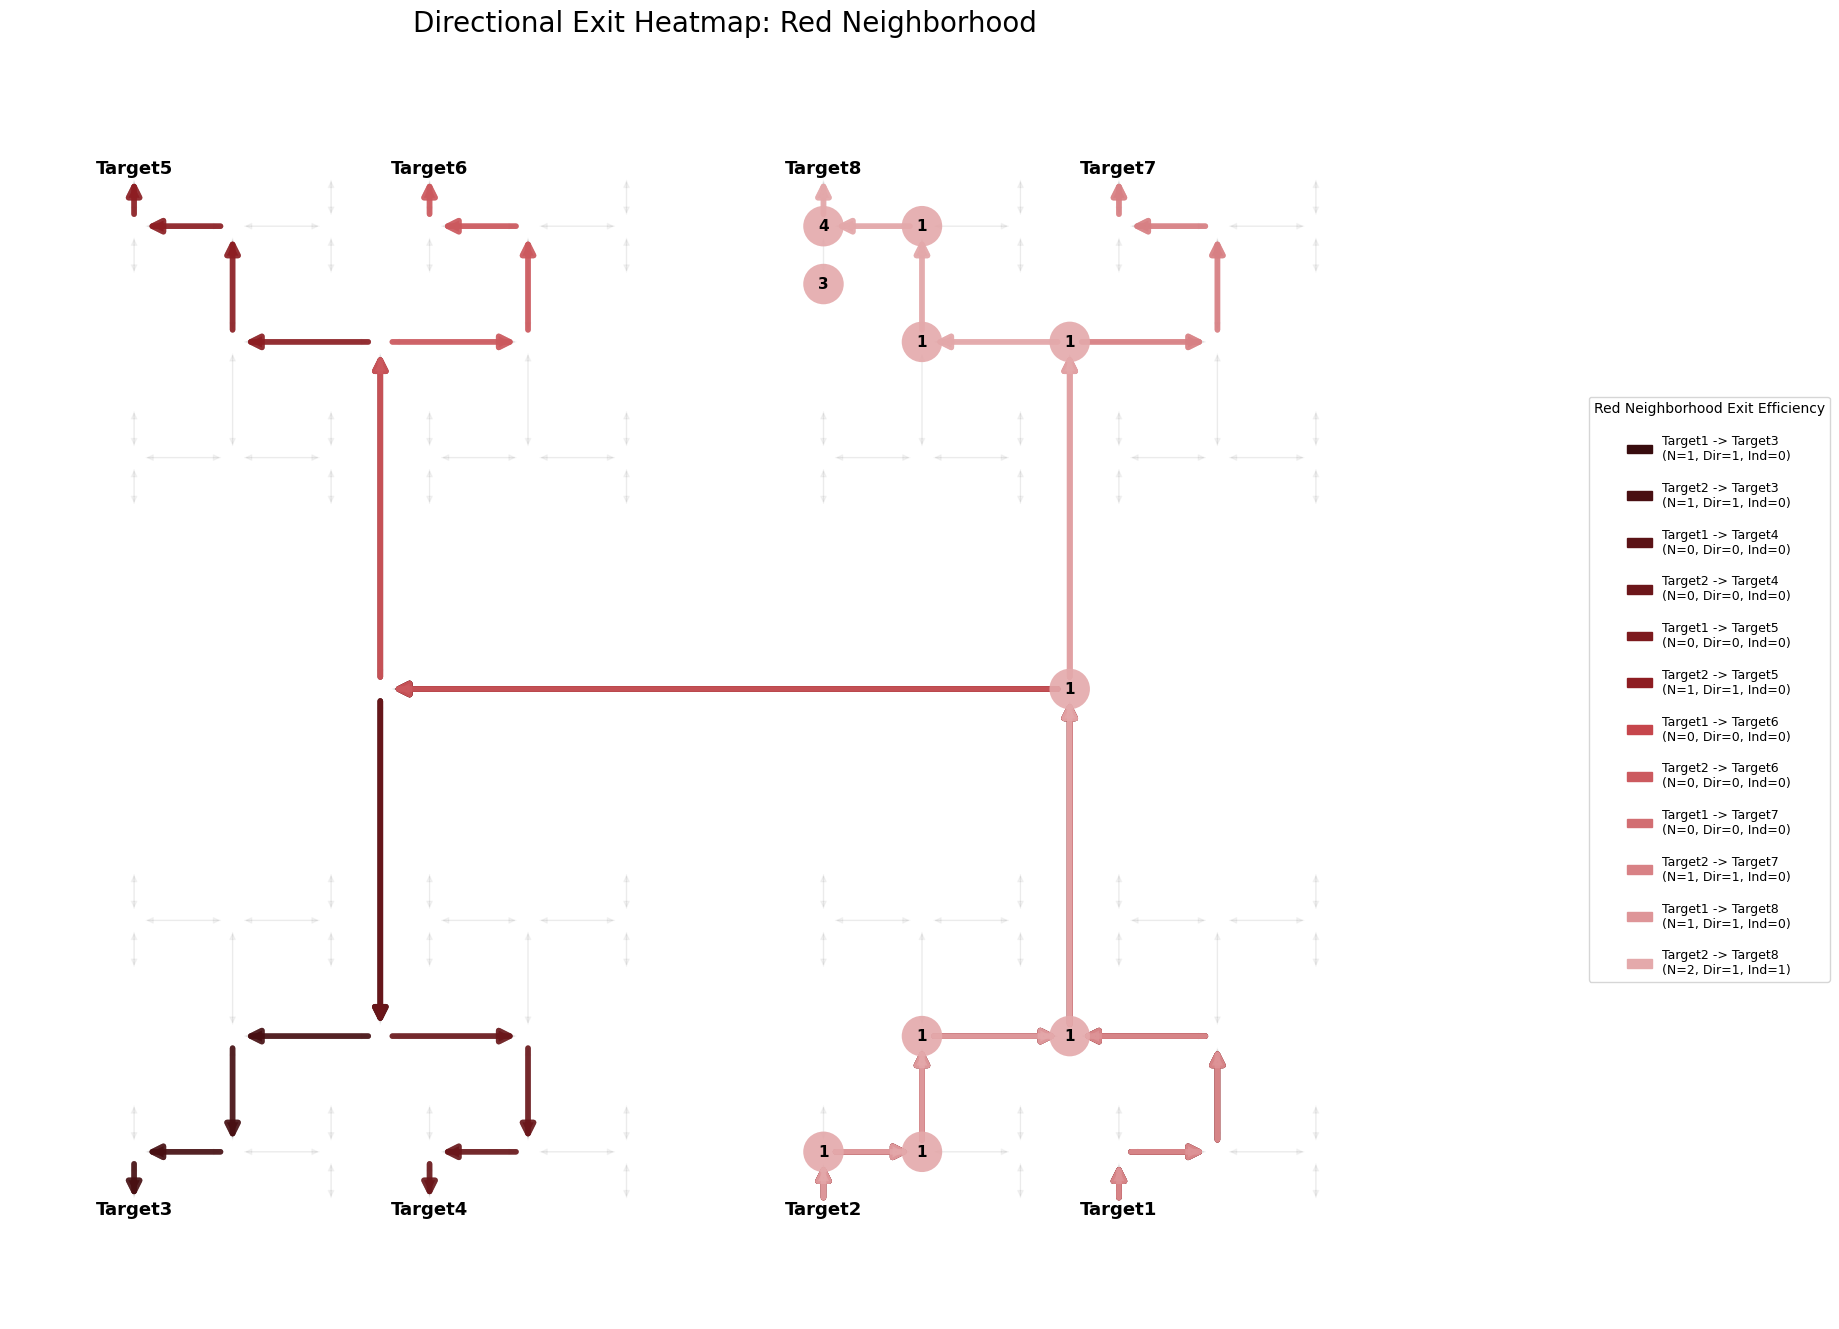

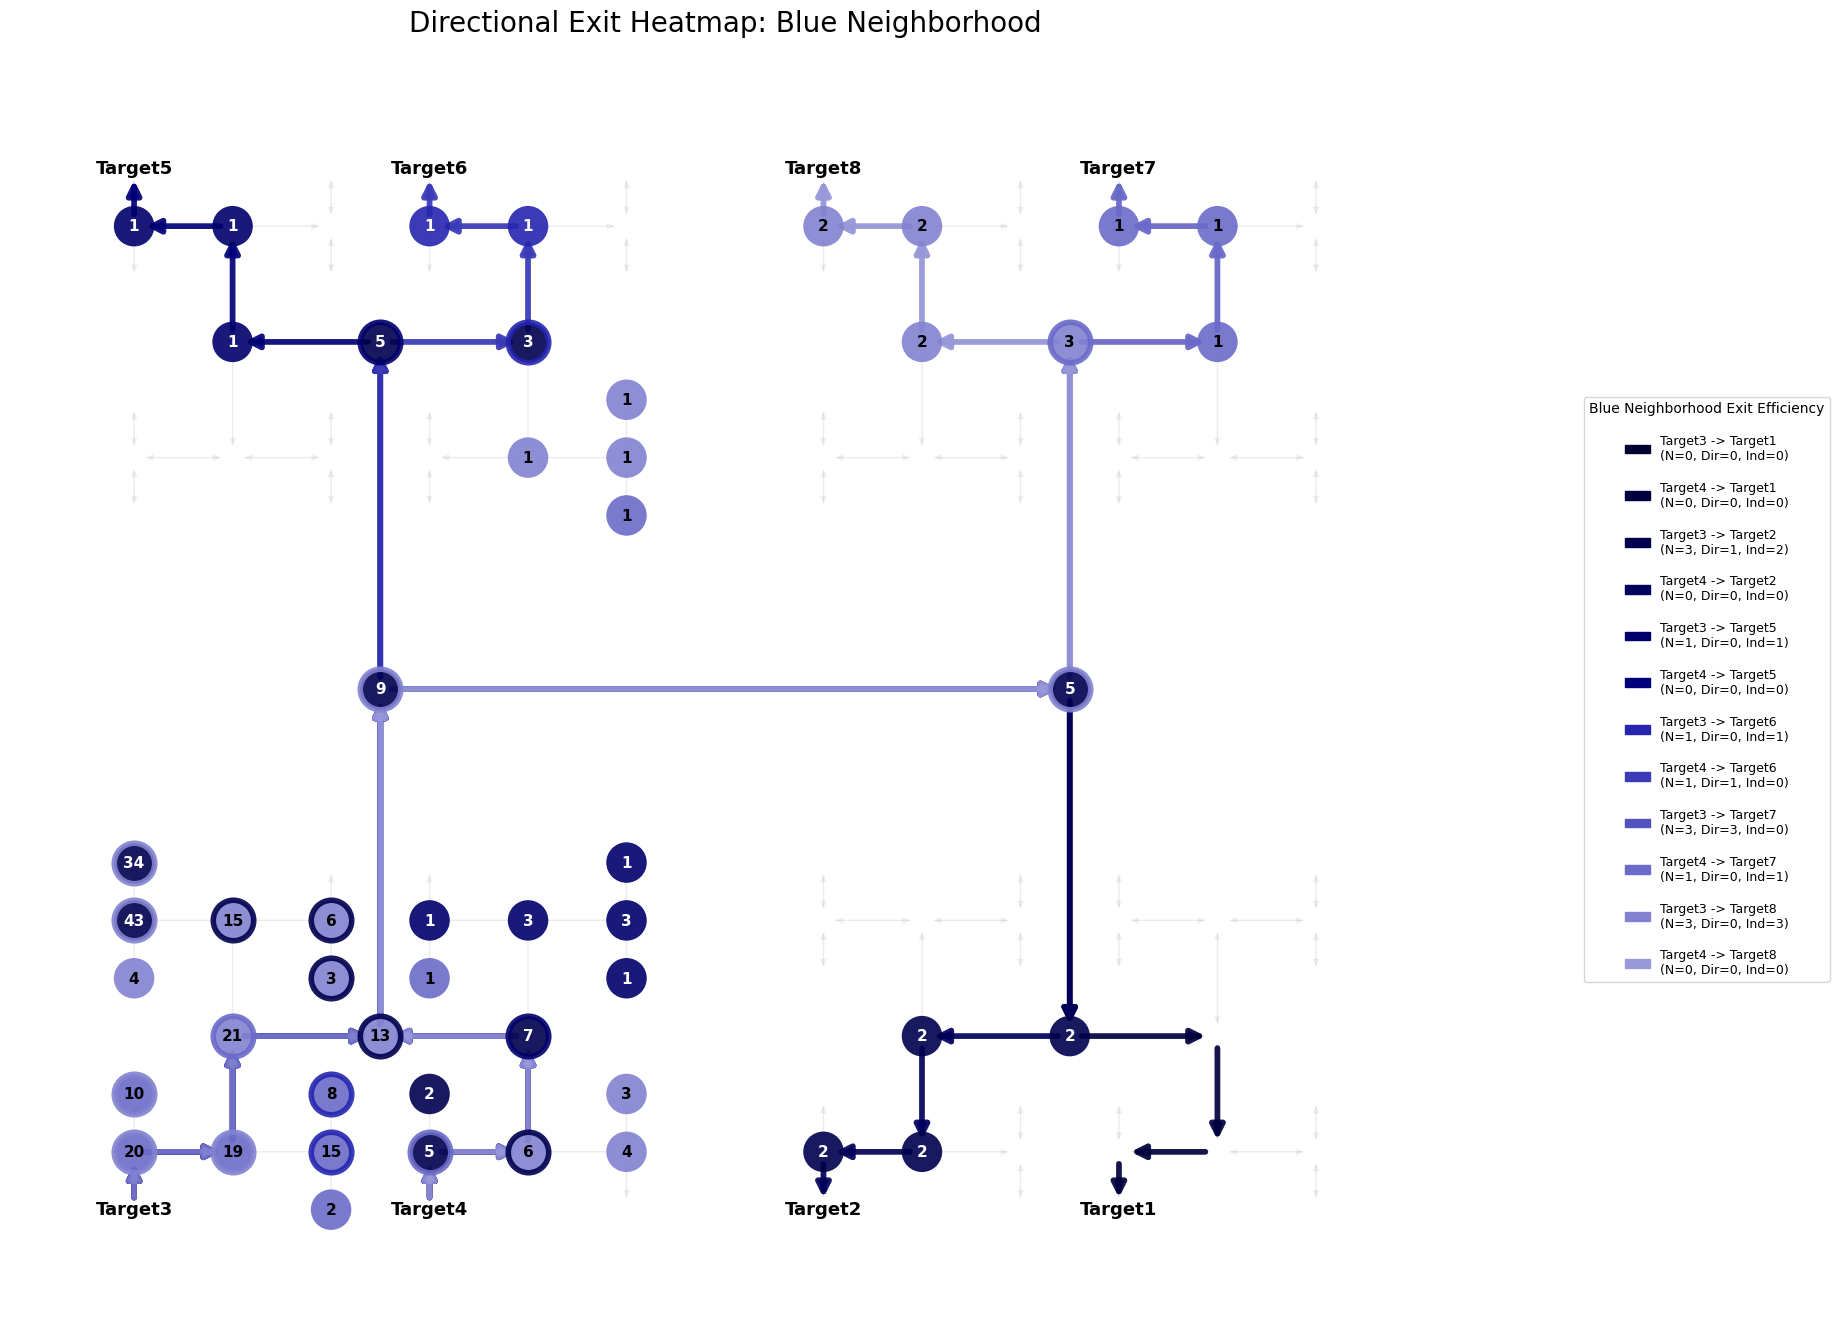

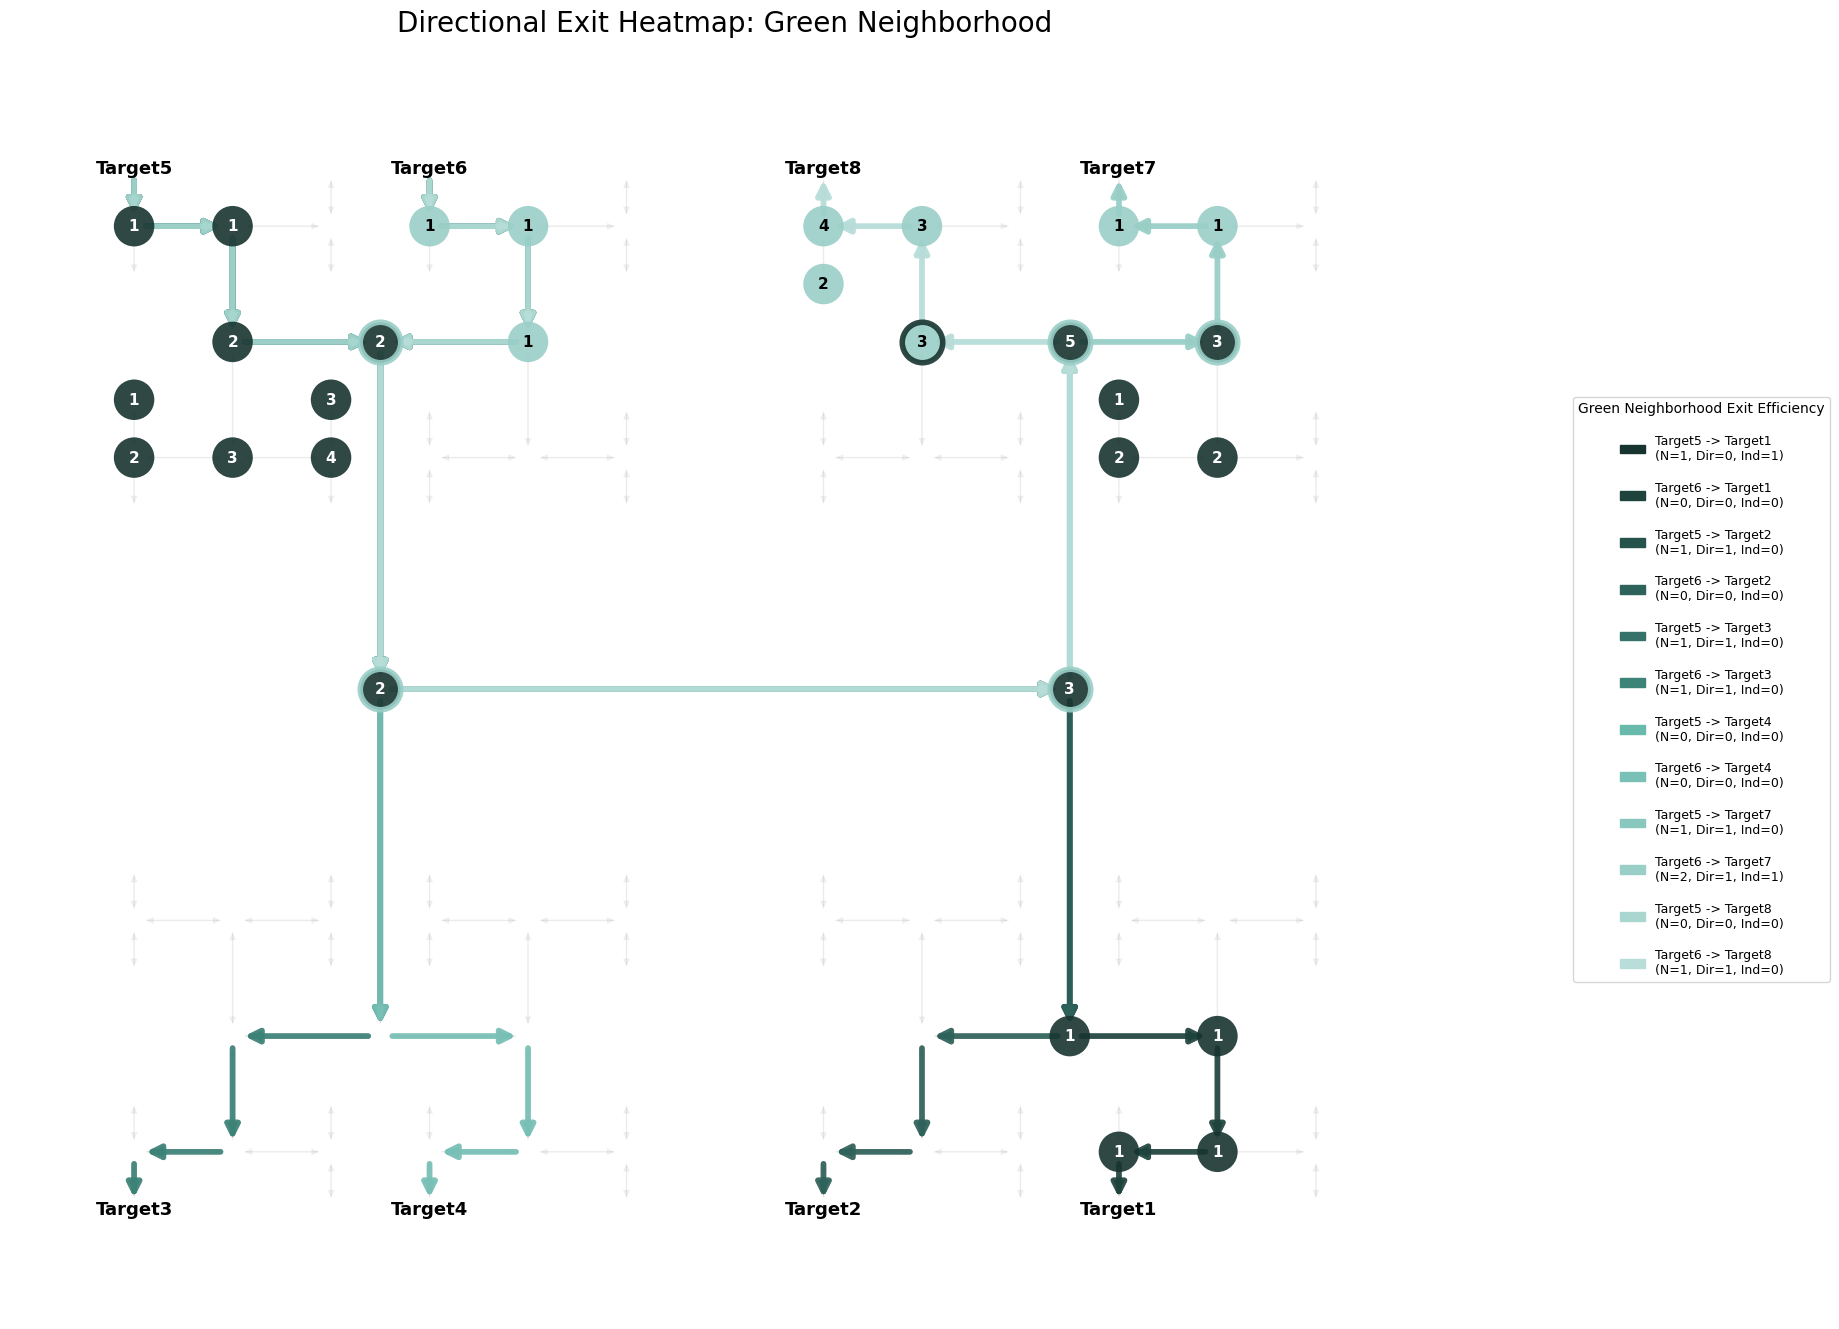

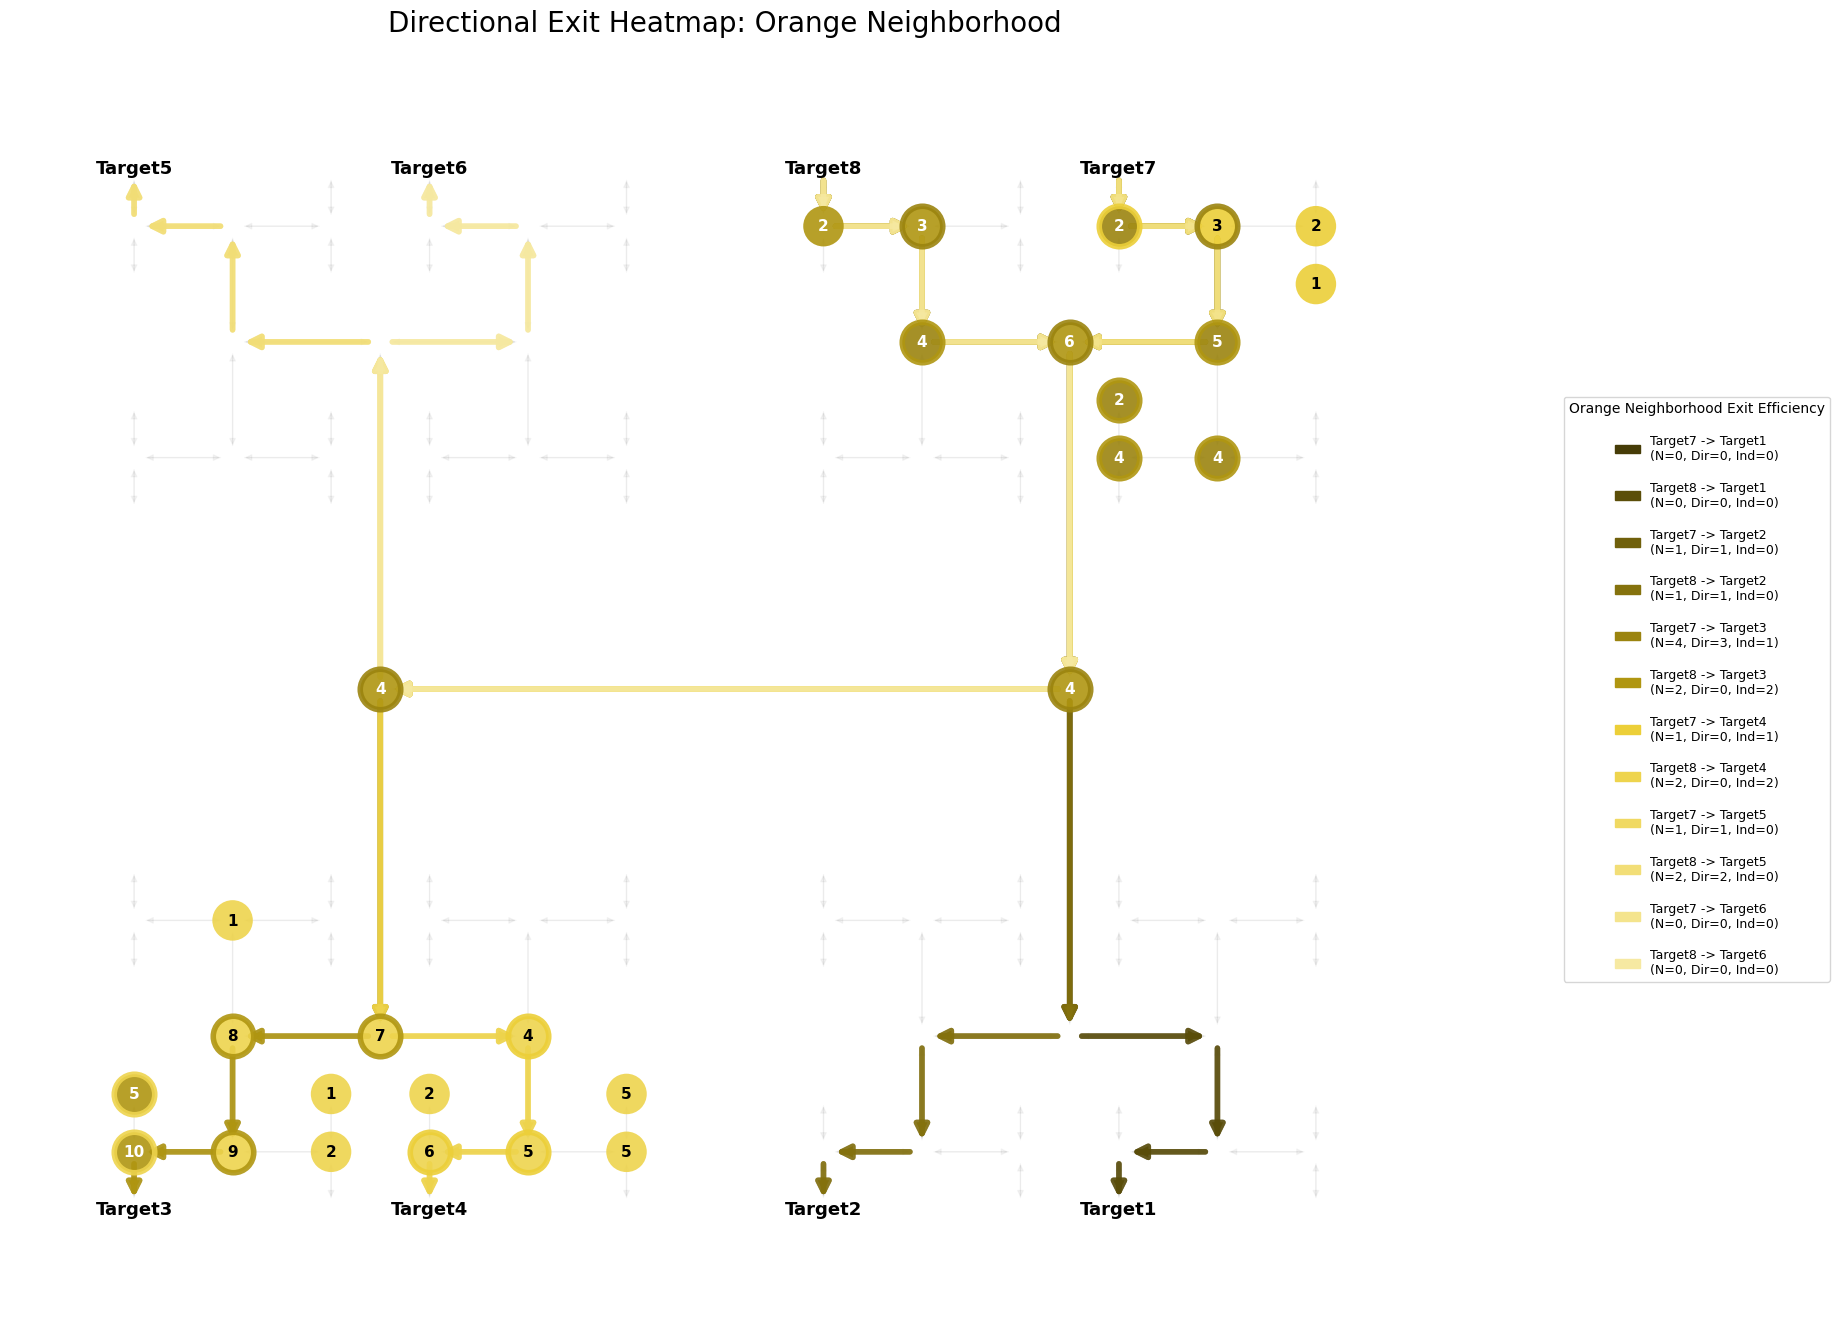

In [2298]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np

def plot_gradient_exit_heatmaps_original_with_efficiency(G, node_positions, df_clean, all_pairs, port_map):
    base_colors = {
        'Red Neighborhood': '#bc272d', 
        'Blue Neighborhood': '#0000a2', 
        'Green Neighborhood': '#50ad9f', 
        'Orange Neighborhood': '#e9c716'
    }

    neighborhoods = {
        'Red Neighborhood': ['Target1', 'Target2'],
        'Blue Neighborhood': ['Target3', 'Target4'],
        'Green Neighborhood': ['Target5', 'Target6'],
        'Orange Neighborhood': ['Target7', 'Target8']
    }

    def get_distinct_colors(hex_color, n):
        if n == 0: return []
        base_rgb = np.array(mcolors.to_rgb(hex_color))
        colors = []
        for i in range(n):
            scale = (i / (n - 1)) if n > 1 else 0.5
            if scale < 0.5:
                color = base_rgb * (0.3 + scale) 
            else:
                color = base_rgb + (np.array([1, 1, 1]) - base_rgb) * (scale - 0.4)
            colors.append(mcolors.to_hex(np.clip(color, 0, 1)))
        return colors

    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()

    for title, focus_ports in neighborhoods.items():
        base_hex = base_colors[title]
        
        # 1. Gather the 12 exit directions
        directional_exits = []
        for src, dest in [(a, b) for a, b in all_pairs] + [(b, a) for a, b in all_pairs]:
            if port_map[src] in focus_ports:
                directional_exits.append((src, dest))

        directional_exits.sort(key=lambda x: port_map[x[1]])
        path_colors = get_distinct_colors(base_hex, len(directional_exits))
        pair_to_color = {f"{port_map[src]} -> {port_map[dest]}": path_colors[i] 
                         for i, (src, dest) in enumerate(directional_exits)}

        # 2. Prep Counters, Backbones, and SHORT PATH LENGTHS
        pair_error_counts = {pk: Counter() for pk in pair_to_color}
        pair_stats = {pk: {'total': 0, 'direct': 0, 'indirect': 0} for pk in pair_to_color}
        pair_shortest_len = {}
        pair_direct_edges = {}

        for src, dest in directional_exits:
            p_key = f"{port_map[src]} -> {port_map[dest]}"
            try:
                path = nx.shortest_path(G, src, dest)
                pair_shortest_len[p_key] = len(path) # Number of nodes in shortest path
                pair_direct_edges[p_key] = [(path[i], path[i+1]) for i in range(len(path)-1)]
            except: 
                pair_shortest_len[p_key] = 999
                pair_direct_edges[p_key] = []

        # 3. Analyze DataFrame
        port_visits = df_clean[df_clean['is_port_node'] == True].copy()
        indices = port_visits.index.tolist()
        
        for i in range(1, len(indices)):
            p_start_node = port_visits.iloc[i-1]['node_name']
            p_end_node = port_visits.iloc[i]['node_name']
            
            if port_map[p_start_node] in focus_ports:
                p_key = f"{port_map[p_start_node]} -> {port_map[p_end_node]}"
                
                if p_key in pair_stats:
                    pair_stats[p_key]['total'] += 1
                    # Extract the actual sequence of nodes the mouse took
                    path_nodes = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                    
                    # ADAPTIVE THRESHOLD: 
                    # We allow a small buffer (e.g., +2 nodes) for the mouse to "turn around" 
                    # at the port or for minor sampling jitter.
                    if len(path_nodes) > (pair_shortest_len[p_key] + 2):
                        pair_stats[p_key]['indirect'] += 1
                        pair_error_counts[p_key].update(path_nodes[1:-1])
                    else:
                        pair_stats[p_key]['direct'] += 1

        # 4. PLOTTING
        fig = plt.figure(figsize=(22, 14))
        ax = fig.add_axes([0.05, 0.05, 0.65, 0.9])
        nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.04, edge_color='black')

        # Draw Backbones
        for p_key, edges in pair_direct_edges.items():
            nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
                                   edge_color=pair_to_color[p_key], 
                                   width=4.0, alpha=0.7, ax=ax, 
                                   arrows=True, arrowsize=20, arrowstyle='-|>')

        # Draw Detour Nodes
        all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
        for node in all_error_nodes:
            node_stats = {pk: pair_error_counts[pk][node] for pk in pair_error_counts if node in pair_error_counts[pk]}
            top_pk = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
            total = sum(node_stats.values())
            
            f_color = pair_to_color[top_pk[0]]
            e_color = pair_to_color[top_pk[1]] if len(top_pk) > 1 else 'none'
            lw = 4 if len(top_pk) > 1 else 0
            
            lum = np.mean(mcolors.to_rgb(f_color))
            nx.draw_networkx_nodes(G, node_positions, nodelist=[node], 
                                   node_color=[f_color], edgecolors=e_color,
                                   linewidths=lw, node_size=850, alpha=0.9, ax=ax)
            nx.draw_networkx_labels(G, node_positions, labels={node: str(total)}, 
                                    font_size=11, font_color='white' if lum < 0.5 else 'black', font_weight='bold', ax=ax)

        # Labels
        nx.draw_networkx_labels(G, node_positions, labels=port_map, font_size=13, font_weight='bold', ax=ax)

        # 5. LEGEND with Direct/Indirect breakdown
        legend_patches = []
        for pk in pair_to_color:
            s = pair_stats[pk]
            label_text = f"{pk}\n(N={s['total']}, Dir={s['direct']}, Ind={s['indirect']})"
            legend_patches.append(mpatches.Patch(color=pair_to_color[pk], label=label_text))
        
        fig.legend(handles=legend_patches, loc='center right', title=f"{title} Exit Efficiency", 
                   ncol=1, fontsize=9, bbox_to_anchor=(0.88, 0.5), frameon=True, labelspacing=1.5)

        ax.set_title(f"Directional Exit Heatmap: {title}", fontsize=20, pad=20)
        ax.axis('off')
        plt.show()

# Run
plot_gradient_exit_heatmaps_original_with_efficiency(G, node_positions, node_summary_df, remaining_pairs, port_map)

In [2299]:
from collections import deque

def generate_mirror_symmetrical_mapping(G, sub_roots):
    # node_to_key: Original Node -> Generic Key (e.g., 'K05')
    # key_to_nodes: Generic Key -> [Red_Node, Blue_Node, Green_Node, Orange_Node]
    node_to_key = {}
    key_to_nodes = {}
    
    # Initialize queues for each patch
    queues = [deque([root]) for root in sub_roots]
    visited = set(sub_roots) | {'L0', 'R0'} # Don't go back to center
    
    key_counter = 1
    
    while any(queues):
        current_gen_nodes = []
        
        # Pull the next "breadth" from each patch simultaneously
        for q in queues:
            if q:
                current_node = q.popleft()
                current_gen_nodes.append(current_node)
            else:
                current_gen_nodes.append(None)
        
        # Assign a key to this structural position
        key = f"K{key_counter:02d}"
        key_to_nodes[key] = current_gen_nodes
        for node in current_gen_nodes:
            if node:
                node_to_key[node] = key
        
        # Find neighbors for the NEXT generation
        # We must sort neighbors to ensure "Left" and "Right" branches align across patches
        for i, q in enumerate(queues):
            # print(f"i: {i}, q:{len(q)}")
            if current_gen_nodes[i]:
                if i == 3 or i == 2: # Flip for 2 top patches to get mirror
                    # Get neighbors not yet visited
                    neighbors = sorted([n for n in G.neighbors(current_gen_nodes[i]) if n not in visited], reverse=True)
                    for n in neighbors:
                        q.append(n)
                        visited.add(n)
                else:
                    # Get neighbors not yet visited
                    neighbors = sorted([n for n in G.neighbors(current_gen_nodes[i]) if n not in visited])
                    for n in neighbors:
                        q.append(n)
                        visited.add(n)
        
        key_counter += 1
        
    return node_to_key, key_to_nodes

# Define the sub-roots in order: Red, Blue, Green, Orange
sub_roots = ['L10', 'R11', 'R10', 'L11']
node_to_key, key_to_nodes = generate_mirror_symmetrical_mapping(G, sub_roots)

# Print verification for the first 10 keys
import pandas as pd
df_map = pd.DataFrame(key_to_nodes).T
df_map.columns = ['Red', 'Blue', 'Green', 'Orange']
print(df_map.head(10))

     Red  Blue Green Orange
K01  L10   R11   R10    L11
K02  L20   R22   R21    L23
K03  L21   R23   R20    L22
K04  L30   R34   R33    L37
K05  L31   R35   R32    L36
K06  L32   R36   R31    L35
K07  L33   R37   R30    L34
K08  L40   R48   R47   L415
K09  L41   R49   R46   L414
K10  L42  R410   R45   L413


In [2300]:
def create_valid_global_reflection_maps(key_to_nodes):
    # Perspectives: 0:Red(L10), 1:Blue(L11), 2:Green(R10), 3:Orange(R11)
    reflection_maps = []
    
    # Define how the "Roots" of the maze swap globally for each perspective
    # We must ensure L0 and R0 swap when we move from L-side to R-side
    for i in range(4):
        # Initial patch-to-patch relationship logic
        if i == 0:   # Red (L10) -> Identity
            rel = {0:0, 1:1, 2:2, 3:3}; center_map = {'L0': 'L0', 'R0': 'R0'}
        elif i == 1: # Blue (L11) -> Vertical Flip
            rel = {1:0, 0:1, 3:2, 2:3}; center_map = {'L0': 'L0', 'R0': 'R0'}
        elif i == 2: # Green (R10) -> Horizontal Flip
            rel = {2:0, 3:1, 0:2, 1:3}; center_map = {'L0': 'R0', 'R0': 'L0'}
        elif i == 3: # Orange (R11) -> Both Flips
            rel = {3:0, 2:1, 1:2, 0:3}; center_map = {'L0': 'R0', 'R0': 'L0'}
            
        full_mapping = center_map.copy()
        
        # Map the 124 patch nodes using the functional 'rel' indices
        for key, nodes in key_to_nodes.items():
            for orig_idx, target_idx in rel.items():
                full_mapping[nodes[orig_idx]] = nodes[target_idx]
                
        reflection_maps.append(full_mapping)
        
    return reflection_maps

# Regenerate maps
valid_reflection_maps = create_valid_global_reflection_maps(key_to_nodes)

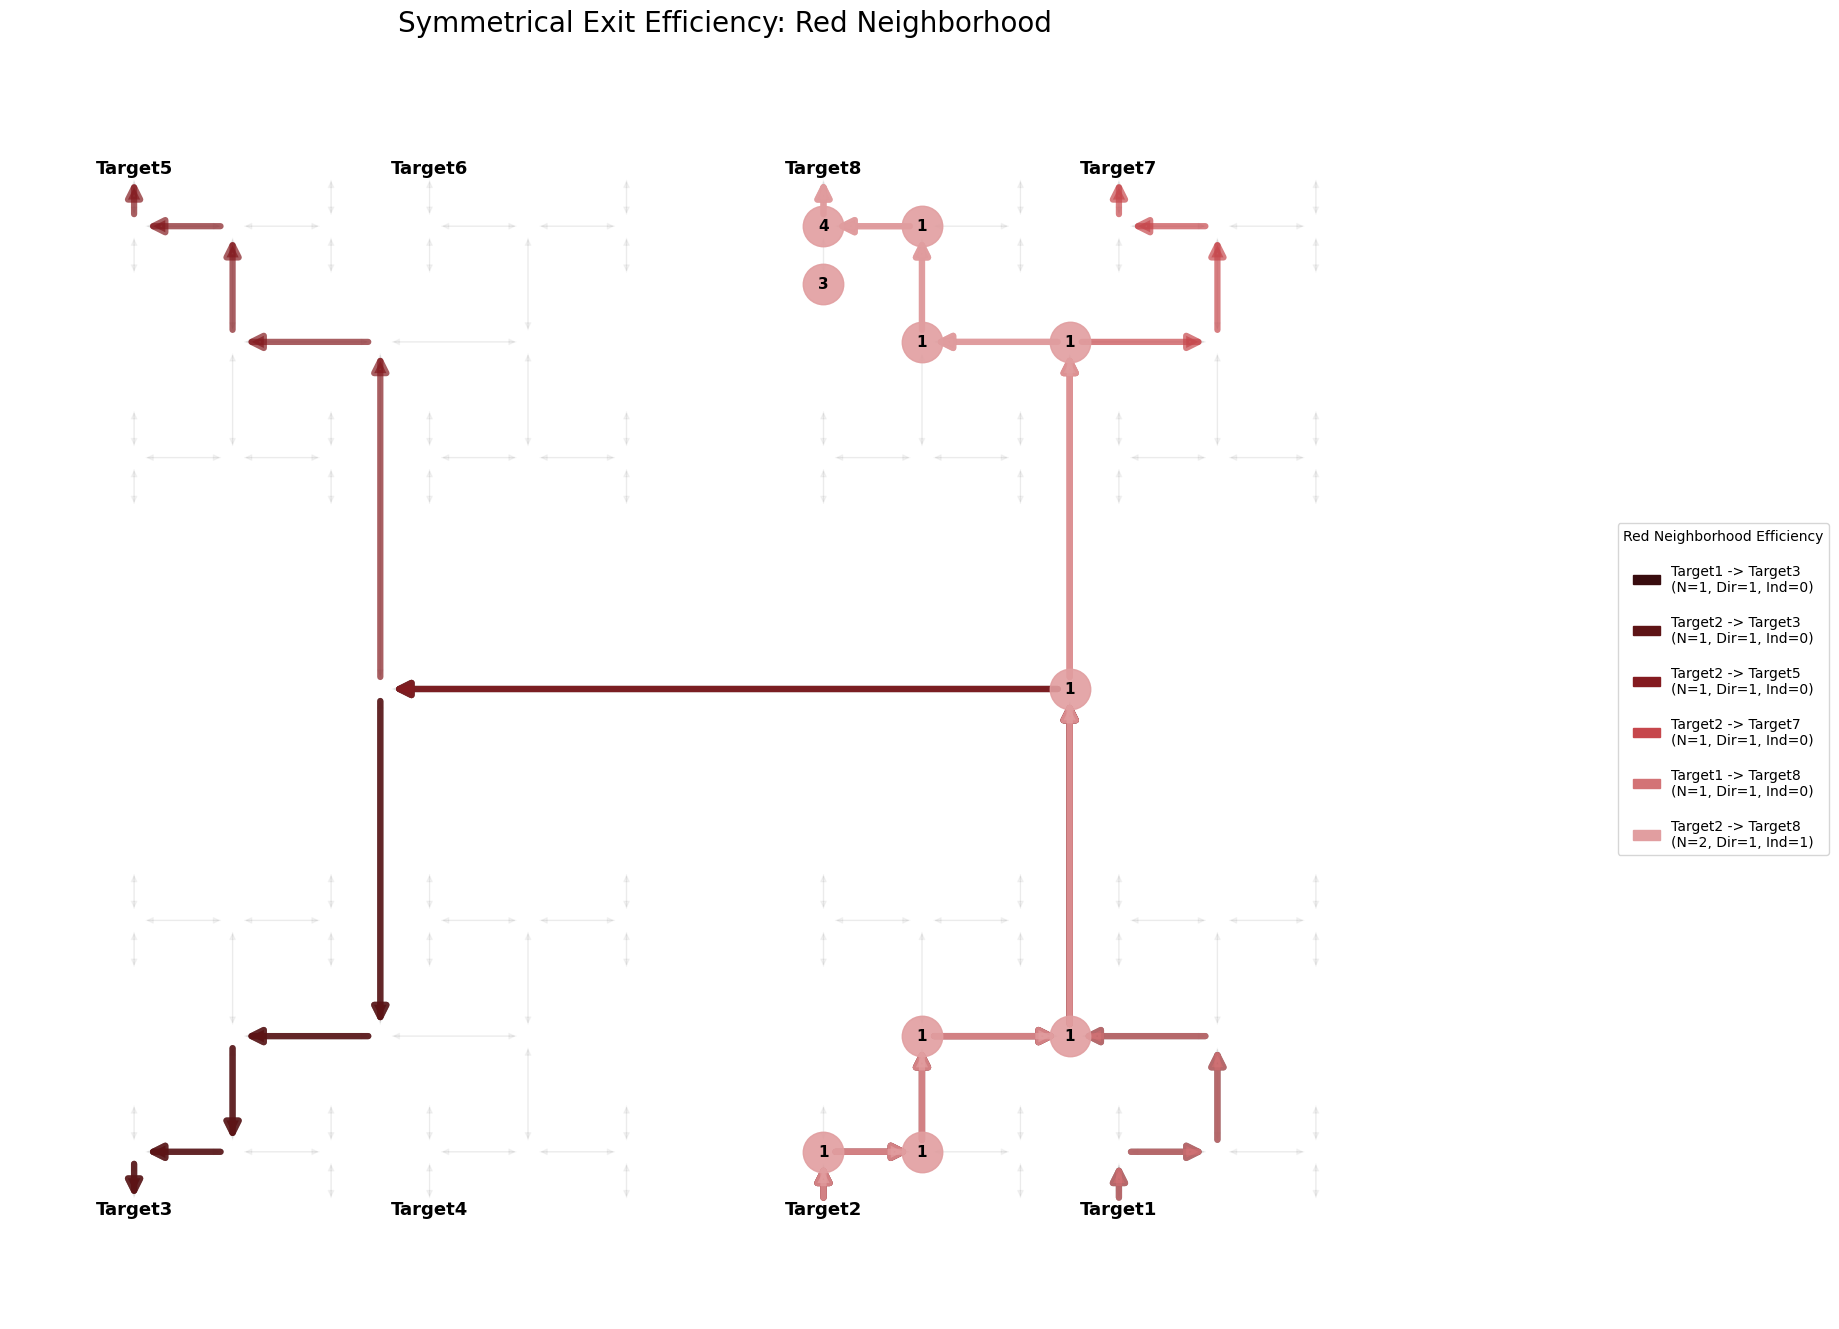

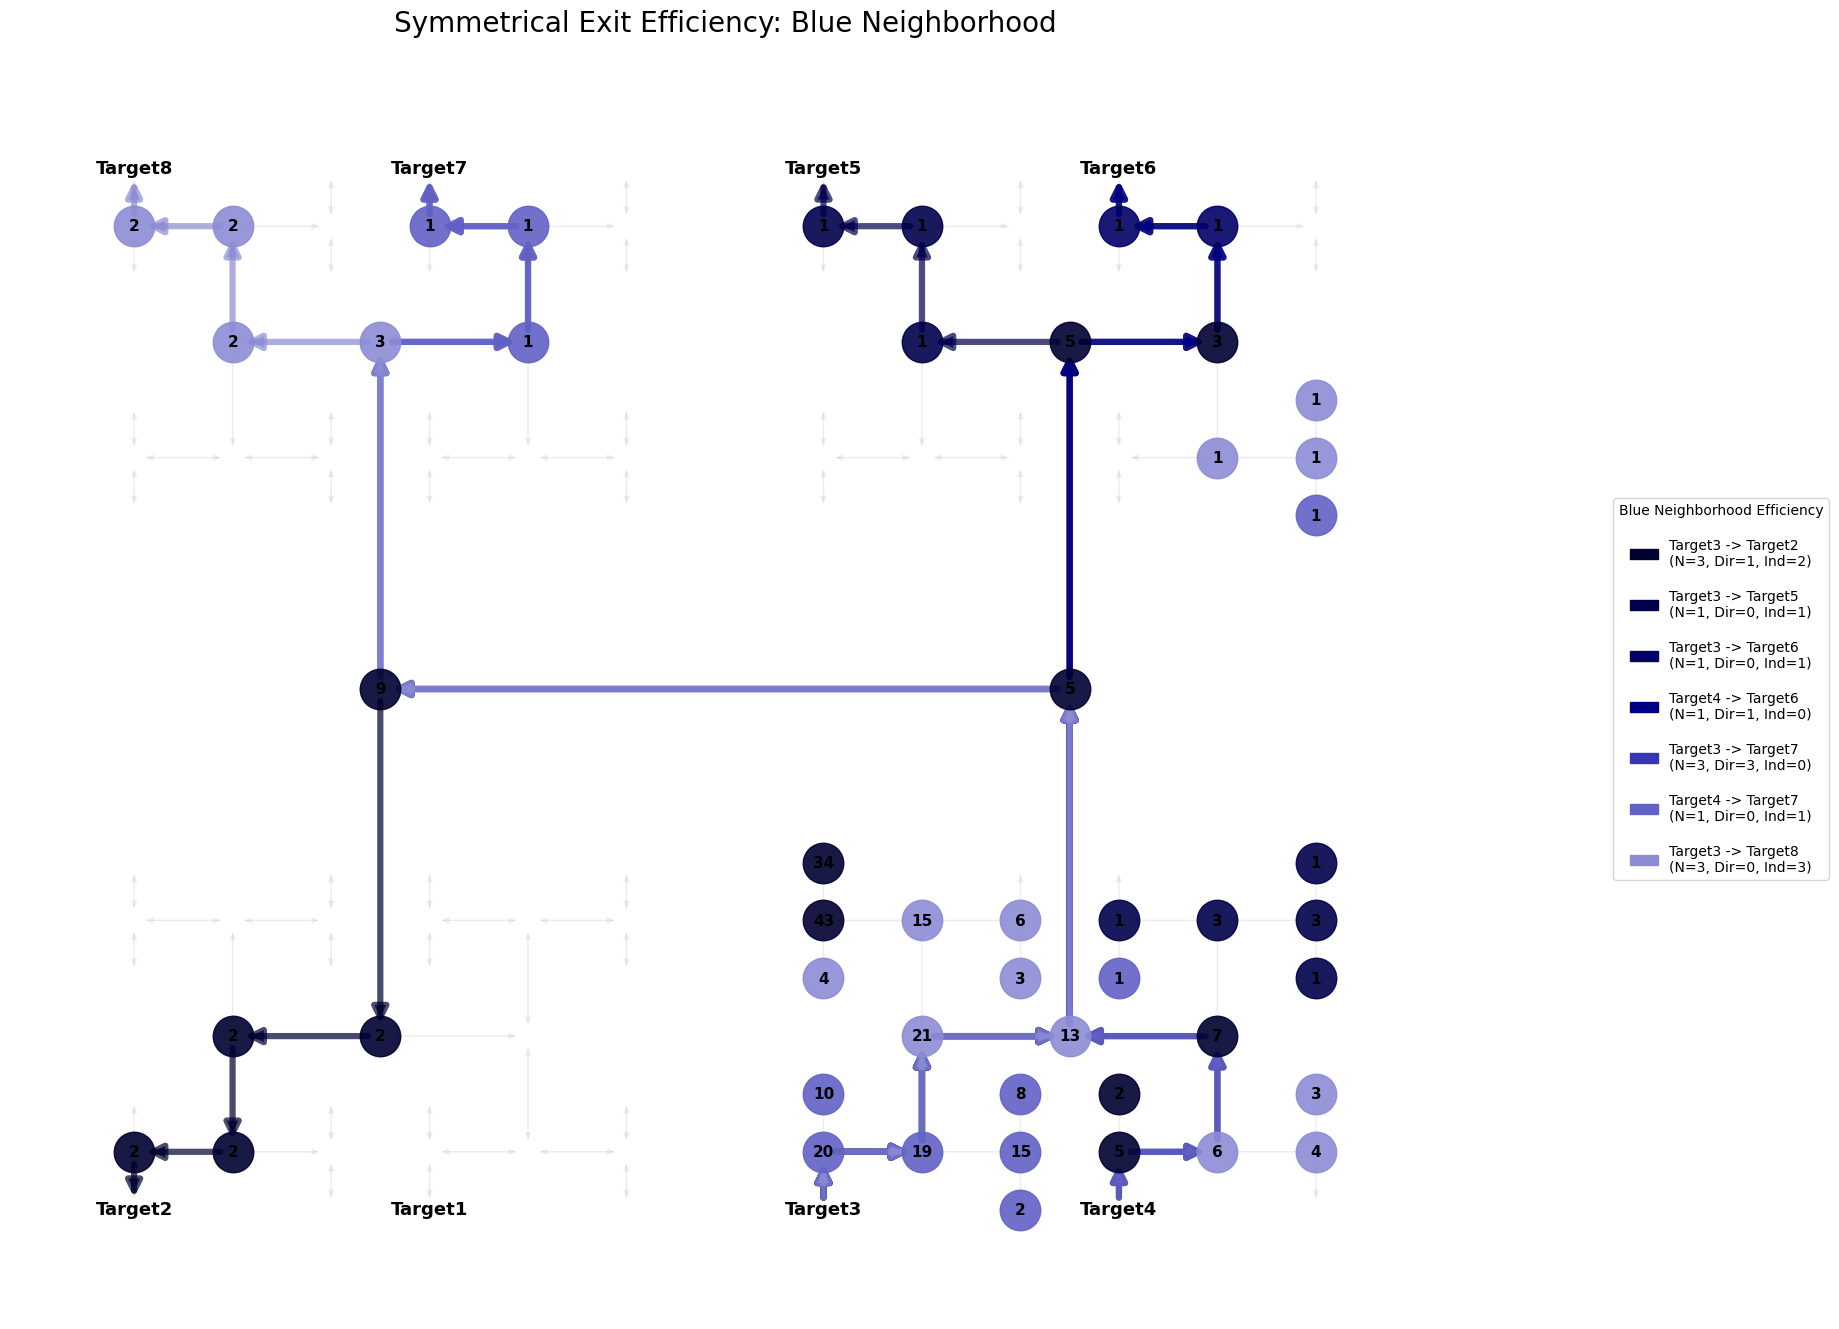

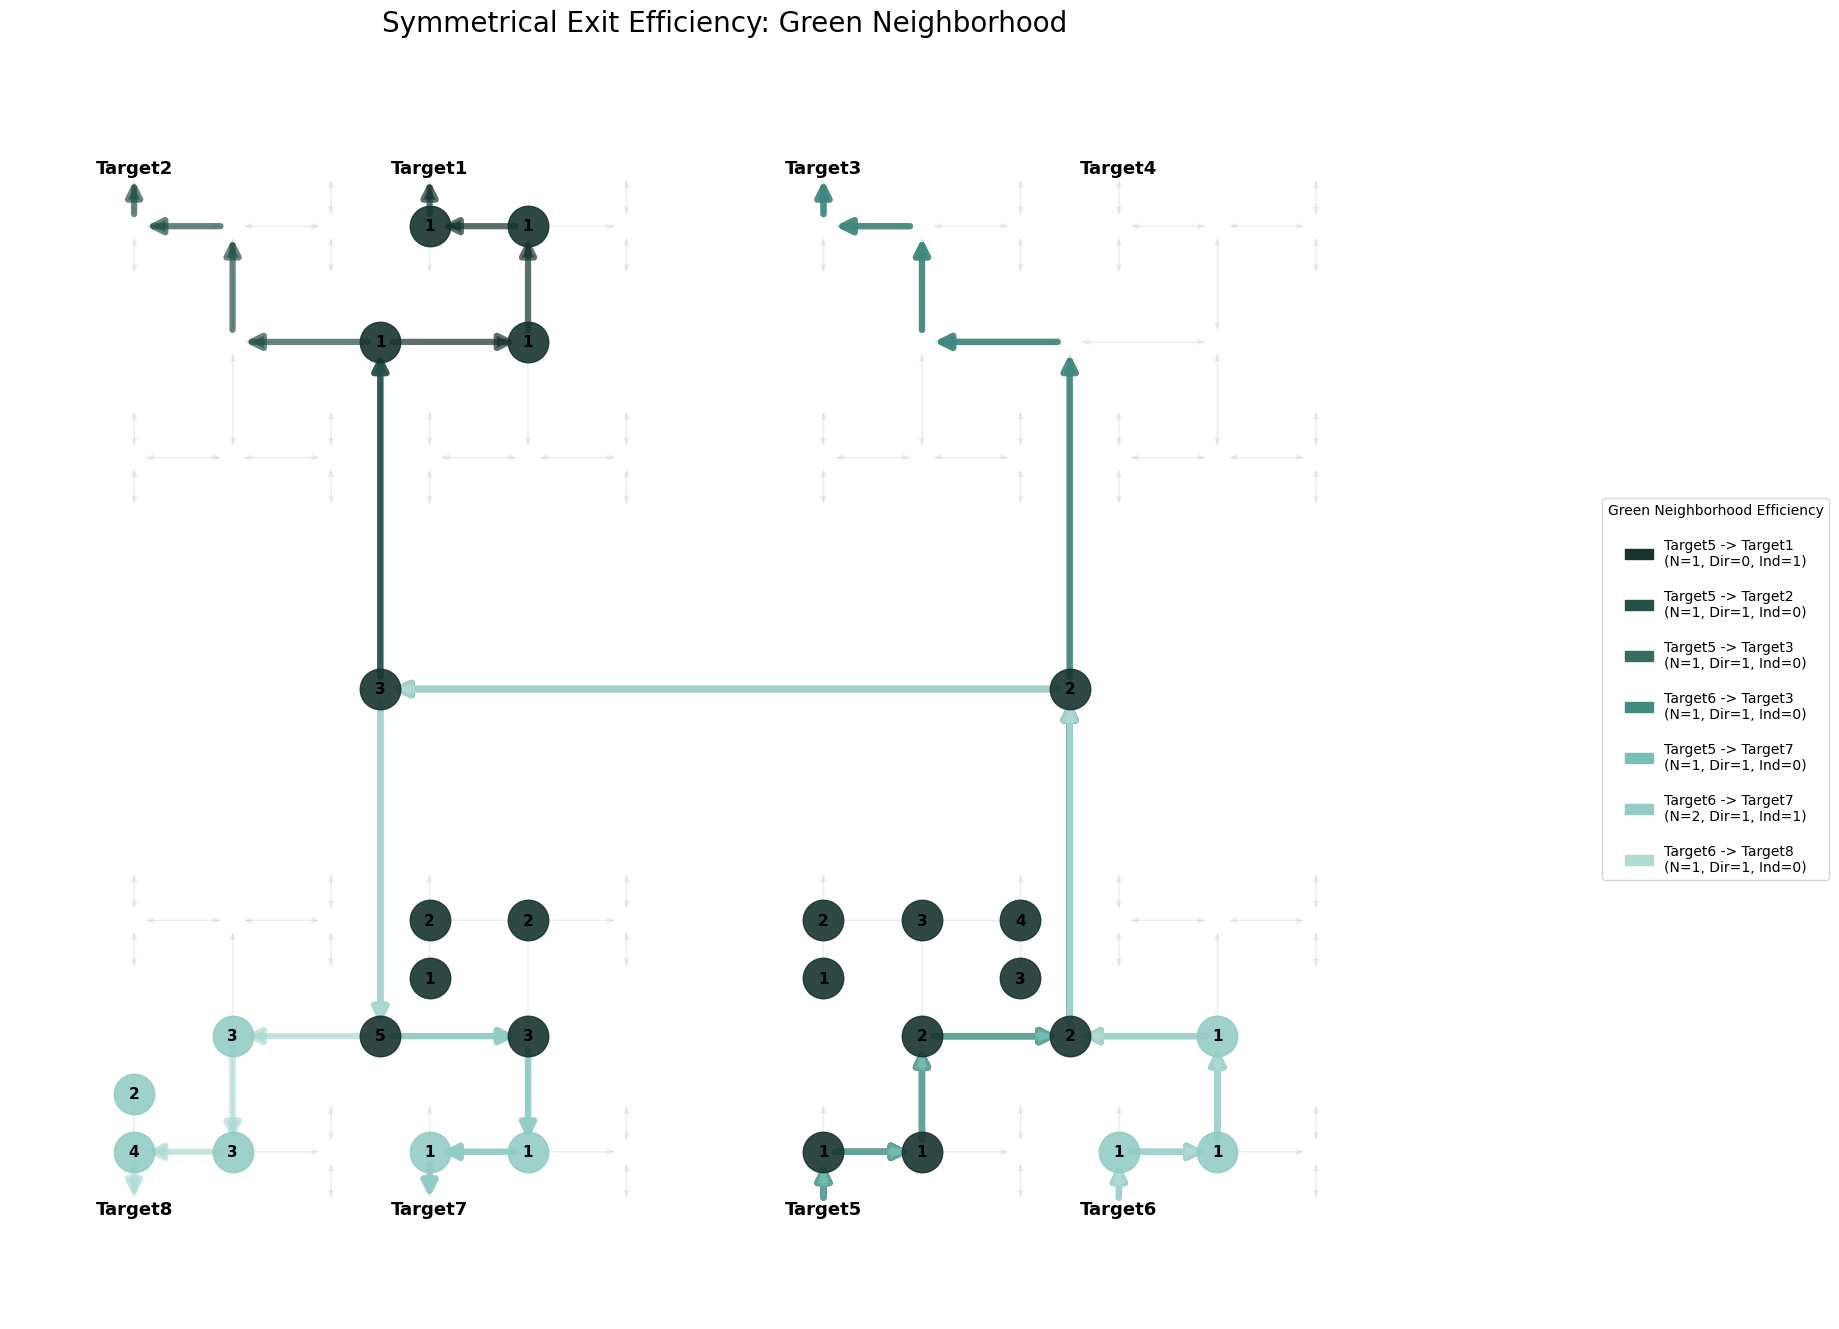

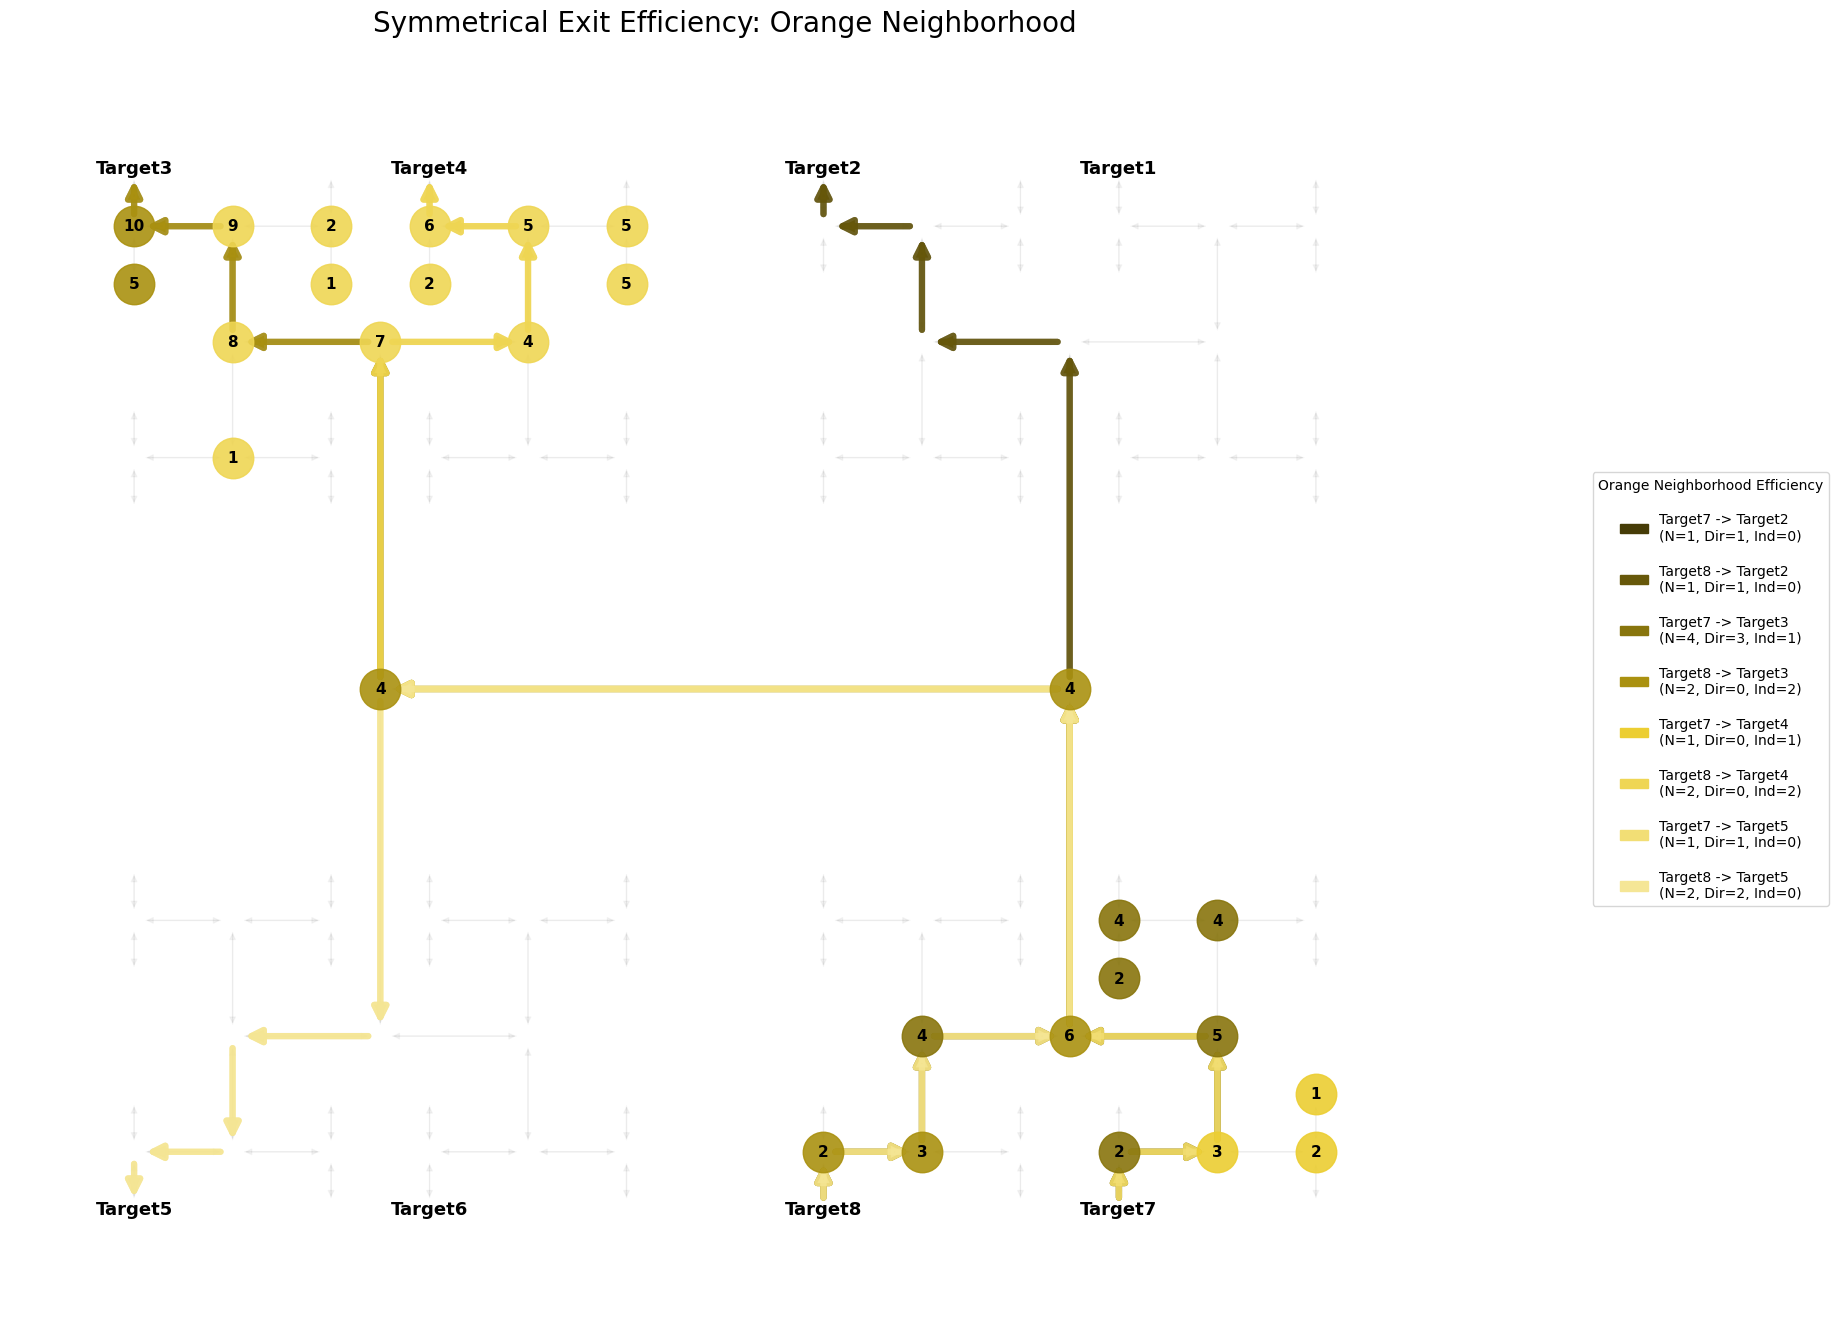

In [2301]:
from itertools import groupby

def plot_symmetrical_exit_heatmaps_efficiency_fixed(G, node_positions, df_clean, all_pairs, port_map, reflection_maps):
    neighborhood_configs = [
        {'name': 'Red Neighborhood', 'ports': ['Target1', 'Target2'], 'color': '#bc272d', 'map_idx': 0},
        {'name': 'Blue Neighborhood', 'ports': ['Target3', 'Target4'], 'color': '#0000a2', 'map_idx': 1},
        {'name': 'Green Neighborhood', 'ports': ['Target5', 'Target6'], 'color': '#50ad9f', 'map_idx': 2},
        {'name': 'Orange Neighborhood', 'ports': ['Target7', 'Target8'], 'color': '#e9c716', 'map_idx': 3}
    ]

    def get_distinct_colors(hex_color, n):
        if n == 0: return []
        if n == 1: return [hex_color]
        base_rgb = np.array(mcolors.to_rgb(hex_color))
        return [mcolors.to_hex(np.clip(base_rgb * (0.3 + (i/(n-1))) if i/n < 0.5 
                                      else base_rgb + (np.array([1,1,1])-base_rgb)*(i/(n-1) - 0.45), 0, 1)) 
                for i in range(n)]

    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    port_visits['prev_node_name'] = port_visits['node_name'].shift(1)
    transition_counts = port_visits.groupby(['prev_node_name', 'node_name']).size().to_dict()

    for config in neighborhood_configs:
        title = config['name']
        focus_ports = config['ports']
        base_hex = config['color']
        ref_map = reflection_maps[config['map_idx']]
        
        active_exits = []
        for src, dest in [(a, b) for a, b in all_pairs] + [(b, a) for a, b in all_pairs]:
            if port_map[src] in focus_ports:
                count = transition_counts.get((src, dest), 0)
                if count > 0:
                    active_exits.append(((src, dest), count))

        if not active_exits: continue
        active_exits.sort(key=lambda x: port_map[x[0][1]])
        path_colors = get_distinct_colors(base_hex, len(active_exits))
        
        pair_to_color = {}
        pair_stats = {} 
        pair_direct_edges = {}
        pair_error_counts = {}
        pair_shortest_len = {}

        # 1. Setup Backbones and calculate Shortest Path Lengths for thresholding
        for i, ((src, dest), count) in enumerate(active_exits):
            p_key = f"{port_map[src]} -> {port_map[dest]}"
            pair_to_color[p_key] = path_colors[i]
            pair_stats[p_key] = {'total': 0, 'direct': 0, 'indirect': 0}
            pair_error_counts[p_key] = Counter()
            
            try:
                # Store the length of the ideal path in G
                path_in_G = nx.shortest_path(G, src, dest)
                pair_shortest_len[p_key] = len(path_in_G)
                
                # Reflect for plotting
                ref_src, ref_dest = ref_map.get(src, src), ref_map.get(dest, dest)
                final_path = nx.shortest_path(G, ref_src, ref_dest)
                pair_direct_edges[p_key] = [(final_path[j], final_path[j+1]) for j in range(len(final_path)-1)]
            except: pair_shortest_len[p_key] = 999

        # 2. Analyze DataFrame with Deduping and Adaptive Thresholds
        for i in range(1, len(indices)):
            p_start, p_end = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
            if port_map[p_start] in focus_ports:
                p_key = f"{port_map[p_start]} -> {port_map[p_end]}"
                
                if p_key in pair_stats:
                    pair_stats[p_key]['total'] += 1
                    raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                    
                    # DEDUPE: Convert [A, A, A, B, B, C] to [A, B, C]
                    deduped_path = [k for k, g in groupby(raw_path)]
                    
                    # ADAPTIVE CHECK: If path is longer than shortest + 2 nodes, it's indirect
                    if len(deduped_path) > (pair_shortest_len[p_key] + 2):
                        pair_stats[p_key]['indirect'] += 1
                        reflected_detours = [ref_map.get(n, n) for n in deduped_path[1:-1]]
                        pair_error_counts[p_key].update(reflected_detours)
                    else:
                        pair_stats[p_key]['direct'] += 1

        # 3. PLOTTING
        fig = plt.figure(figsize=(22, 14))
        ax = fig.add_axes([0.05, 0.05, 0.65, 0.9])
        nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.04, edge_color='black')

        for p_key, edges in pair_direct_edges.items():
            nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
                                   edge_color=pair_to_color[p_key], 
                                   width=4.5, alpha=0.7, ax=ax, arrows=True, arrowsize=22)

        all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
        for node in all_error_nodes:
            node_stats = {pk: pair_error_counts[pk][node] for pk in pair_error_counts if node in pair_error_counts[pk]}
            top_pk = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
            total = sum(node_stats.values())
            f_color = pair_to_color[top_pk[0]]
            nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=[f_color], node_size=850, alpha=0.9, ax=ax)
            nx.draw_networkx_labels(G, node_positions, labels={node: str(total)}, font_size=11, font_weight='bold')

        # Perspective labels
        inv_map = {v: k for k, v in ref_map.items()}
        ref_labels = {n: port_map[inv_map[n]] for n in G.nodes() if n in inv_map and inv_map[n] in port_map}
        nx.draw_networkx_labels(G, node_positions, labels=ref_labels, font_size=13, font_weight='bold', ax=ax)

        legend_patches = [mpatches.Patch(color=pair_to_color[pk], 
                          label=f"{pk}\n(N={pair_stats[pk]['total']}, Dir={pair_stats[pk]['direct']}, Ind={pair_stats[pk]['indirect']})") 
                          for pk in pair_to_color]
        
        fig.legend(handles=legend_patches, loc='center right', title=f"{title} Efficiency", ncol=1, bbox_to_anchor=(0.88, 0.5), labelspacing=1.5)
        ax.set_title(f"Symmetrical Exit Efficiency: {title}", fontsize=20, pad=20)
        ax.axis('off')
        plt.show()

# Run
plot_symmetrical_exit_heatmaps_efficiency_fixed(G, node_positions, node_summary_df, remaining_pairs, port_map, valid_reflection_maps)

In [2302]:
port_visits = node_summary_df[node_summary_df['is_port_node'] == True].copy()
reward_visits = node_summary_df[node_summary_df['reward_during_node'] == True].copy()
pos_reward_visits = node_summary_df[node_summary_df['reward_size_during_node'] > 0].copy()

len(node_summary_df[node_summary_df['reward_during_node'] == True])

90

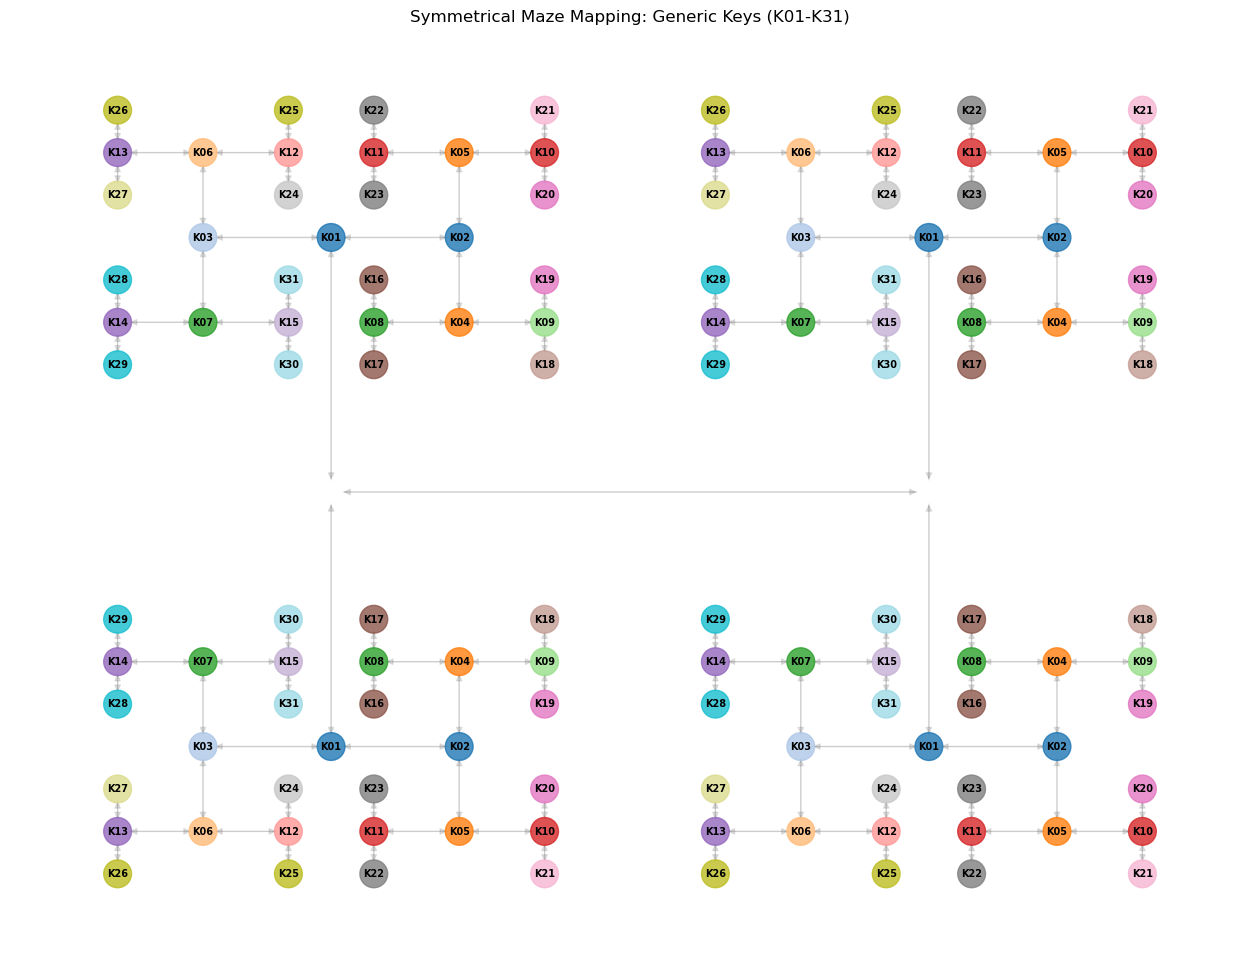

In [2303]:
def plot_generic_mapping(G, node_positions, node_to_key):
    plt.figure(figsize=(16, 12))
    ax = plt.gca()
    
    # Draw faint maze skeleton
    nx.draw_networkx_edges(G, node_positions, alpha=0.1, edge_color='black')
    
    # Filter for nodes that are part of the mapping (the 124 patch nodes)
    mapped_nodes = [n for n in G.nodes() if n in node_to_key]
    
    # Color nodes by their Key index to show the "Tree" progression
    key_indices = [int(node_to_key[n][1:]) for n in mapped_nodes]
    
    scatter = nx.draw_networkx_nodes(G, node_positions, nodelist=mapped_nodes, 
                                     node_color=key_indices, cmap='tab20', 
                                     node_size=400, alpha=0.8)
    
    # Label nodes with their Generic Key (e.g., K05)
    labels = {n: node_to_key[n] for n in mapped_nodes}
    nx.draw_networkx_labels(G, node_positions, labels=labels, font_size=7, font_weight='bold')
    
    plt.title("Symmetrical Maze Mapping: Generic Keys (K01-K31)")
    plt.axis('off')
    plt.show()

plot_generic_mapping(G, node_positions, node_to_key)

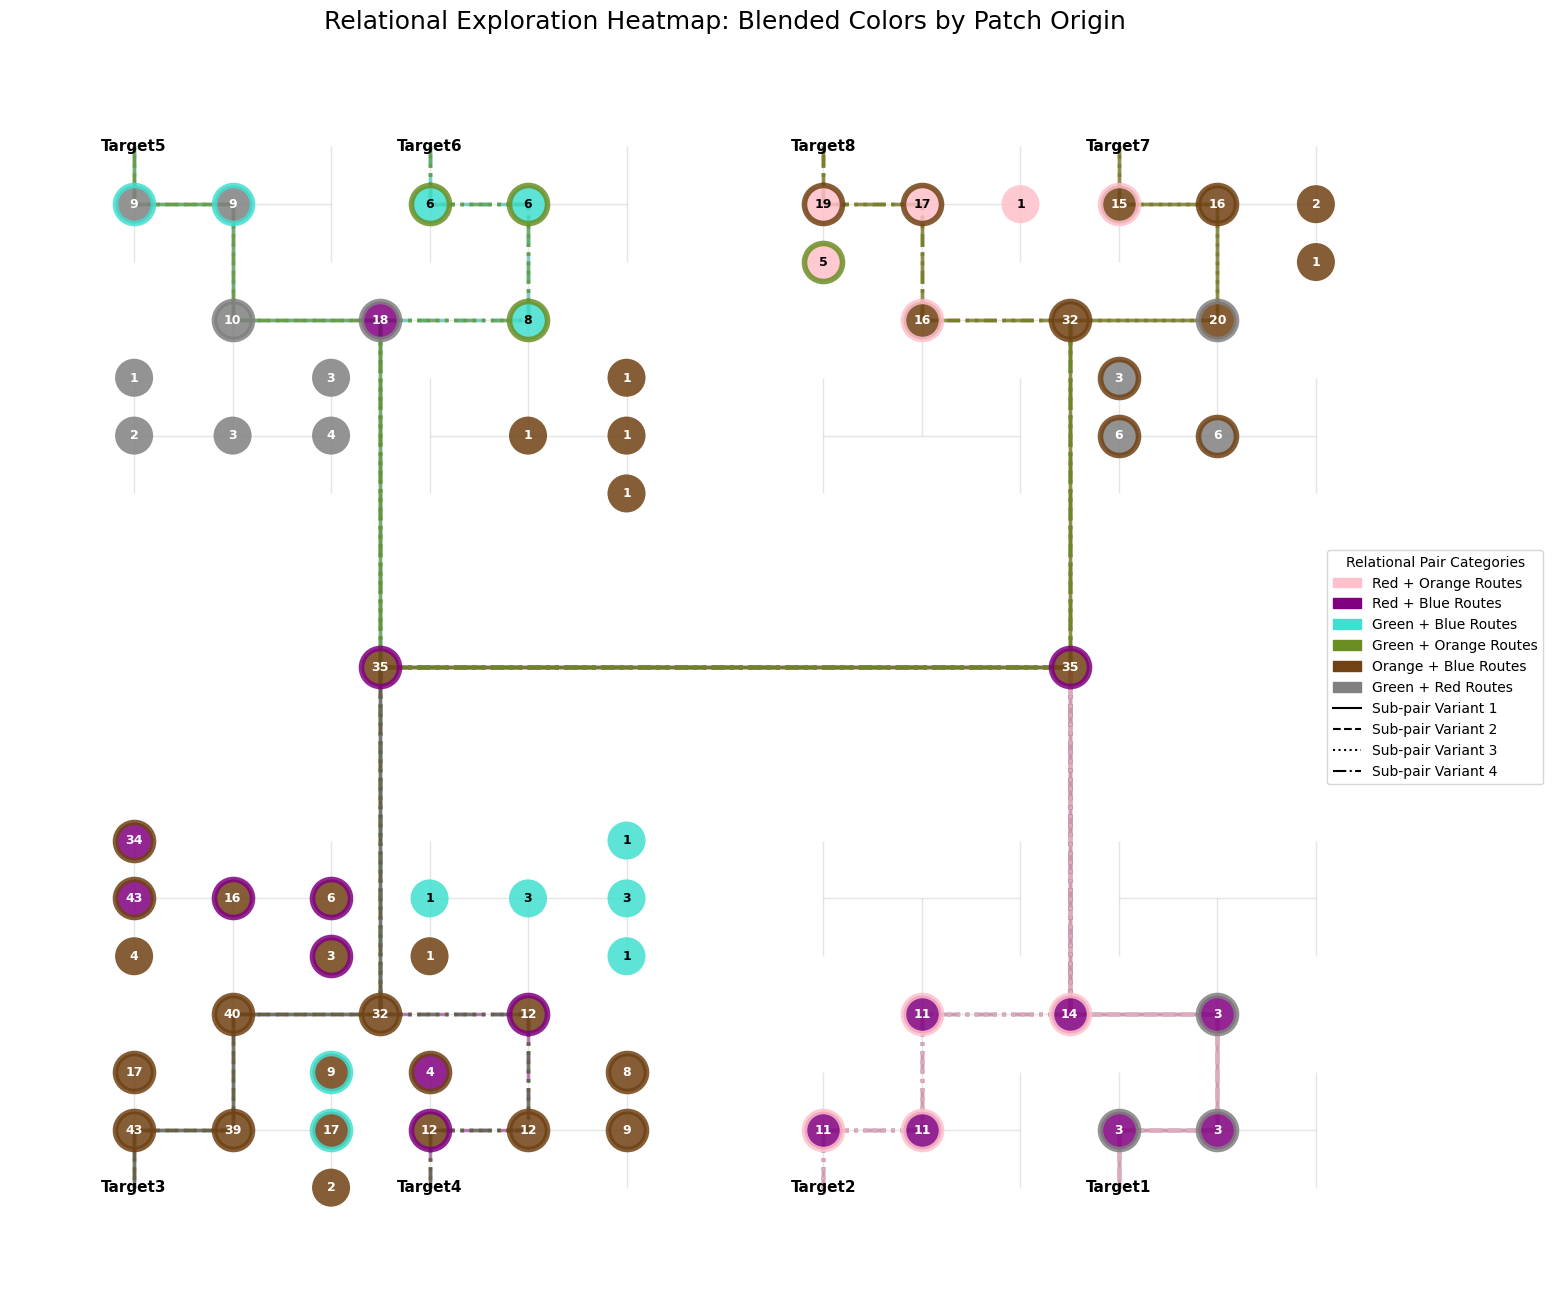

In [2304]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.patches as mpatches

def plot_relational_heatmap(G, node_positions, df_clean, remaining_pairs, port_map):
    # 1. Define Group Mapping
    group_map = {
        'Target1': 'Red', 'Target2': 'Red',
        'Target3': 'Blue', 'Target4': 'Blue',
        'Target5': 'Green', 'Target6': 'Green',
        'Target7': 'Orange', 'Target8': 'Orange'
    }

    # Define the Blend Logic
    blend_colors = {
        frozenset(['Red', 'Orange']): 'pink',
        frozenset(['Blue', 'Red']): 'purple',
        frozenset(['Blue', 'Green']): 'turquoise',
        frozenset(['Green', 'Orange']): '#6b8e23', # Greenish brown (OliveDrab)
        frozenset(['Orange', 'Blue']): '#704214', # Mud brown (Sepia)
        frozenset(['Green', 'Red']): 'gray'
    }

    # 2. Assign Color and Linestyle to each remaining pair
    pair_styles = {}
    category_counts = Counter()
    linestyles = ['-', '--', ':', '-.']

    for a, b in remaining_pairs:
        p_a, p_b = port_map[a], port_map[b]
        g_a, g_b = group_map[p_a], group_map[p_b]
        
        pair_key = f"{p_a}-{p_b}"
        category = frozenset([g_a, g_b])
        color = blend_colors.get(category, 'lightgray')
        
        # Assign linestyle based on how many pairs are already in this color category
        style_idx = category_counts[category] % len(linestyles)
        pair_styles[pair_key] = {'color': color, 'linestyle': linestyles[style_idx]}
        category_counts[category] += 1

    # 3. Calculate Paths and Errors (Same logic as before)
    pair_direct_edges = {}
    pair_error_counts = {f"{port_map[a]}-{port_map[b]}": Counter() for a, b in remaining_pairs}
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()

    for a, b in remaining_pairs:
        p_key = f"{port_map[a]}-{port_map[b]}"
        try:
            path = nx.shortest_path(G, a, b)
            pair_direct_edges[p_key] = [tuple(sorted((path[i], path[i+1]))) for i in range(len(path)-1)]
        except: pair_direct_edges[p_key] = []

    for i in range(1, len(indices)):
        p1, p2 = port_visits.iloc[i-1]['node_name'], port_visits.iloc[i]['node_name']
        for a, b in remaining_pairs:
            if {p1, p2} == {a, b}:
                p_key = f"{port_map[a]}-{port_map[b]}"
                path_nodes = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
                if len(path_nodes) > 8:
                    pair_error_counts[p_key].update(path_nodes[1:-1])

    # 4. Plotting
    fig = plt.figure(figsize=(22, 14))
    ax = fig.add_axes([0.05, 0.05, 0.65, 0.9])
    nx.draw_networkx_edges(G, node_positions, ax=ax, alpha=0.05, edge_color='black', arrows=False)

    # Draw Backbones with Relational Colors and Line Styles
    for p_key, edges in pair_direct_edges.items():
        style = pair_styles[p_key]
        nx.draw_networkx_edges(G, node_positions, edgelist=edges, 
                               edge_color=style['color'], width=2.5, 
                               style=style['linestyle'], alpha=0.5, ax=ax, arrows=False)

    # Draw Nodes (Multi-pair logic using the new relational colors)
    all_error_nodes = set().union(*(c.keys() for c in pair_error_counts.values()))
    for node in all_error_nodes:
        node_stats = {pk: pair_error_counts[pk][node] for pk in pair_error_counts if node in pair_error_counts[pk]}
        top_pairs = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total = sum(node_stats.values())
        
        f_color = pair_styles[top_pairs[0]]['color']
        e_color = pair_styles[top_pairs[1]]['color'] if len(top_pairs) > 1 else 'none'
        t_color = 'white' if f_color not in ['pink', 'turquoise'] else 'black'

        nx.draw_networkx_nodes(G, node_positions, nodelist=[node], node_color=f_color,
                               edgecolors=e_color, linewidths=4 if e_color != 'none' else 0,
                               node_size=750, alpha=0.85, ax=ax)
        nx.draw_networkx_labels(G, node_positions, labels={node: str(total)}, 
                                font_size=9, font_color=t_color, font_weight='bold', ax=ax)

    # 5. Legend Construction
    legend_elements = []
    for cat, color in blend_colors.items():
        names = list(cat)
        legend_elements.append(mpatches.Patch(color=color, label=f"{names[0]} + {names[1]} Routes"))

    # Port Labels
    port_labels = {k: v for k, v in port_map.items()}
    nx.draw_networkx_labels(G, node_positions, labels=port_labels, font_size=11, font_weight='bold', ax=ax)
    
    # Add linestyle guide
    from matplotlib.lines import Line2D
    for i, style in enumerate(linestyles):
        legend_elements.append(Line2D([0], [0], color='black', linestyle=style, label=f"Sub-pair Variant {i+1}"))

    fig.legend(handles=legend_elements, loc='center right', title="Relational Pair Categories", 
               ncol=1, fontsize=10, bbox_to_anchor=(0.75, 0.5))

    ax.set_title("Relational Exploration Heatmap: Blended Colors by Patch Origin", fontsize=18)
    ax.axis('off')
    plt.show()

# Run
plot_relational_heatmap(G, node_positions, node_summary_df, remaining_pairs, port_map)

In [2305]:
# Patch Definitions (0: Red, 1: Blue, 2: Green, 3: Orange)
patch_ports = {
    0: {'Easy': 'Target4', 'Hard': 'Target3'}, # Red
    1: {'Easy': 'Target2', 'Hard': 'Target1'}, # Blue (Across from Red)
    2: {'Easy': 'Target7', 'Hard': 'Target8'}, # Green (Diagonal from Red)
    3: {'Easy': 'Target5', 'Hard': 'Target6'}  # Orange (Nearest to Red)
}

# Relationship Look-up (Source_Patch_Index -> Target_Patch_Index)
# Based on your definition: Across is Blue(1), Diagonal is Green(2), Nearest is Orange(3)
rel_matrix = {
    (0,0): 'Self', (1,1): 'Self', (2,2): 'Self', (3,3): 'Self',
    (0,1): 'Across', (1,0): 'Across', (2,3): 'Across', (3,2): 'Across',
    (0,2): 'Diagonal', (2,0): 'Diagonal', (1,3): 'Diagonal', (3,1): 'Diagonal',
    (0,3): 'Nearest', (3,0): 'Nearest', (1,2): 'Nearest', (2,1): 'Nearest'
}

# Helper to find Port Metadata
port_meta = {}
for p_idx, roles in patch_ports.items():
    for role, p_name in roles.items():
        port_meta[p_name] = {'patch': p_idx, 'role': role}

In [2306]:
from itertools import groupby
import pandas as pd

def analyze_functional_paths(G, df_clean, port_meta, rel_matrix):
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    indices = port_visits.index.tolist()
    
    # Storage for the full list of transitions
    all_transitions_list = []

    for i in range(1, len(indices)):
        src_node = port_visits.iloc[i-1]['node_name']
        dest_node = port_visits.iloc[i]['node_name']
        
        src_label = port_map.get(src_node)
        dest_label = port_map.get(dest_node)
        
        if src_label in port_meta and dest_label in port_meta:
            # Get Metadata
            src_info = port_meta[src_label]
            dest_info = port_meta[dest_label]
            
            # Determine Relationship and Roles
            relationship = rel_matrix[(src_info['patch'], dest_info['patch'])]
            group_label = f"{src_info['role']} to {relationship} {dest_info['role']}"
            
            # Path Analysis (Deduping + Efficiency)
            raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
            deduped_path = [k for k, g in groupby(raw_path)]
            
            # Distance Logic
            # Add tolerance of 2 and 4 nodes to count as direct
            shortest_dist = len(nx.shortest_path(G, src_node, dest_node))
            is_direct = len(deduped_path) <= (shortest_dist)
            is_direct_tol2 = len(deduped_path) <= (shortest_dist) + 2
            is_direct_tol4 = len(deduped_path) <= (shortest_dist) + 4
            
            # Store full data
            all_transitions_list.append({
                'source_port': src_label,
                'dest_port': dest_label,
                'relationship': relationship,
                'group': group_label,
                'is_direct': is_direct,
                'is_direct_tol2': is_direct_tol2,
                'is_direct_tol4': is_direct_tol4,
                'path_nodes': deduped_path
            })

    # Create the Master DataFrame
    df_results = pd.DataFrame(all_transitions_list)
    
    # Generate Summary Statistics
    summary = df_results.groupby('group').agg(
        Total_Paths=('group', 'count'),
        Direct_Paths=('is_direct', lambda x: x.sum()),
        Indirect_Paths=('is_direct', lambda x: (~x).sum()),
        Direct_Paths_Tol2=('is_direct_tol2', lambda x: x.sum()),
        Indirect_Paths_Tol2=('is_direct_tol2', lambda x: (~x).sum()),
        Direct_Paths_Tol4=('is_direct_tol4', lambda x: x.sum()),
        Indirect_Paths_Tol4=('is_direct_tol4', lambda x: (~x).sum())
    ).reset_index()
    
    return df_results, summary

# Run the analysis
df_all_paths, df_summary = analyze_functional_paths(G, node_summary_df, port_meta, rel_matrix)

In [2307]:
((node_summary_df['is_port_node'] == True) & (node_summary_df['reward_during_node'] == True)).sum()

np.int64(89)

In [2308]:
node_summary_df['reward_during_node'].sum()

np.int64(90)

In [2309]:
from itertools import groupby
import pandas as pd
import networkx as nx

def analyze_functional_paths(G, df_clean, port_meta, rel_matrix, only_reward_paths=False):
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    if only_reward_paths:
        port_visits = port_visits[port_visits['reward_during_node'] == True]
    indices = port_visits.index.tolist()
    
    # Define levels to be skipped: L4, L5, R4, R5
    leaf_prefixes = ('L4', 'L5', 'R4', 'R5')
    
    all_transitions_list = []

    for i in range(1, len(indices)):
        src_node = port_visits.iloc[i-1]['node_name']
        dest_node = port_visits.iloc[i]['node_name']
        
        src_label = port_map.get(src_node)
        dest_label = port_map.get(dest_node)
        
        if src_label in port_meta and dest_label in port_meta:
            src_info = port_meta[src_label]
            dest_info = port_meta[dest_label]
            
            relationship = rel_matrix[(src_info['patch'], dest_info['patch'])]
            group_label = f"{src_info['role']} to {relationship} {dest_info['role']}"
            
            raw_path = df_clean.loc[indices[i-1]:indices[i], 'node_name'].tolist()
            deduped_path = [k for k, g in groupby(raw_path)]
            
            # 1. Isolate the internal path (exclude start/end port nodes)
            # Internal path starts at node index 1 and ends at -2
            internal_path = deduped_path[1:-1]
            
            if len(internal_path) >= 1:
                # The anchors are the first and last L4/R4 nodes visited
                core_start_node = internal_path[0]
                core_end_node = internal_path[-1]
                
                # Calculate Shortest Path between these two specific L4/R4 nodes
                shortest_core_dist = len(nx.shortest_path(G, core_start_node, core_end_node))
                
                # Count actual core length, skipping L4/R4 <-> L5/R5 transitions
                filtered_core_len = 1 # Starting node
                for j in range(len(internal_path) - 1):
                    n1, n2 = internal_path[j], internal_path[j+1]
                    
                    n1_is_leaf = n1.startswith(leaf_prefixes)
                    n2_is_leaf = n2.startswith(leaf_prefixes)
                    
                    # Transition counts UNLESS it is between two leaf nodes
                    if not (n1_is_leaf and n2_is_leaf):
                        filtered_core_len += 1
                
                is_direct_skip_leaves = filtered_core_len <= shortest_core_dist
            else:
                # This covers paths where ports are adjacent (Target1 to Target2 in same patch)
                filtered_core_len = 0
                shortest_core_dist = 0
                is_direct_skip_leaves = True
            
            # Distance Logic
            shortest_path = nx.shortest_path(G, src_node, dest_node)
            shortest_dist = len(shortest_path)
            actual_len = len(deduped_path)
            
            # Store results
            all_transitions_list.append({
                'source_port': src_label,
                'dest_port': dest_label,
                'relationship': relationship,
                'group': group_label,
                'actual_length': actual_len,
                'filtered_length': filtered_core_len + 2,
                'shortest_dist': shortest_dist,
                'is_direct': actual_len <= shortest_dist,
                'is_direct_tol2': actual_len <= (shortest_dist + 2),
                'is_direct_tol4': actual_len <= (shortest_dist + 4),
                'is_direct_skip_leaves': is_direct_skip_leaves,
                'path_nodes': deduped_path
            })

    df_results = pd.DataFrame(all_transitions_list)
    
    # Updated Summary Statistics
    summary = df_results.groupby('group').agg(
        Total_Paths=('group', 'count'),
        Direct_Strict=('is_direct', 'sum'),
        Direct_Tol2=('is_direct_tol2', 'sum'),
        Direct_Tol4=('is_direct_tol4', 'sum'),
        Direct_Skip_Leaves=('is_direct_skip_leaves', 'sum'),
        Avg_Actual_Len=('actual_length', 'mean'),
        Avg_Filtered_Len=('filtered_length', 'mean'),
        Avg_Shortest_Dist=('shortest_dist', 'mean')
    ).reset_index()
    
    return df_results, summary

# Run the analysis
df_all_paths, df_summary = analyze_functional_paths(G, node_summary_df, port_meta, rel_matrix)

In [2310]:
# all paths in df_all_paths that are not port to same port
all_paths_without_repeat = df_all_paths[df_all_paths['source_port'] != df_all_paths['dest_port']]
# all_paths_without_repeat.groupby('is_direct').count()
all_paths_without_repeat

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
0,Target6,Target5,Self,Hard to Self Easy,9,9,9,True,True,True,True,"[L525, L412, L36, L23, L11, L22, L35, L410, L521]"
2,Target5,Target3,Nearest,Easy to Nearest Hard,13,11,11,False,True,True,True,"[L521, L410, L35, L22, L11, L0, L10, L21, L32,..."
3,Target3,Target4,Self,Hard to Self Easy,11,9,9,False,True,True,True,"[L510, L45, L32, L21, L10, L20, L31, L43, L57,..."
7,Target4,Target6,Nearest,Easy to Nearest Hard,11,11,11,True,True,True,True,"[L56, L43, L31, L20, L10, L0, L11, L23, L36, L..."
8,Target6,Target3,Nearest,Hard to Nearest Hard,11,11,11,True,True,True,True,"[L525, L412, L36, L23, L11, L0, L10, L21, L32,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
270,Target1,Target2,Self,Hard to Self Easy,9,9,9,True,True,True,True,"[R522, R411, R35, R22, R11, R23, R36, R413, R526]"
271,Target2,Target8,Nearest,Easy to Nearest Hard,11,11,11,True,True,True,True,"[R526, R413, R36, R23, R11, R0, R10, R20, R31,..."
314,Target8,Target7,Self,Hard to Self Easy,9,9,9,True,True,True,True,"[R55, R42, R31, R20, R10, R21, R32, R44, R59]"
316,Target7,Target8,Self,Easy to Self Hard,19,19,9,False,False,False,False,"[R59, R44, R32, R21, R10, R20, R31, R20, R10, ..."


In [2311]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Use the cleaned data without repeats
df = all_paths_without_repeat.copy()
df['src_role'] = df['group'].apply(lambda x: x.split(' to ')[0])
df['dest_role'] = df['group'].apply(lambda x: x.split(' ')[-1])
df['role_trans'] = df['src_role'] + " to " + df['dest_role']

# Filter out the Identical-Role Self-Moves
plot_df = df[~df['group'].isin(['Easy to Self Easy', 'Hard to Self Hard'])].copy()

def get_tol_stats(data, column):
    stats = data.groupby(column).agg(
        total=('is_direct', 'count'),
        direct=('is_direct', 'sum'),
        tol2=('is_direct_tol2', 'sum'),
        tol4=('is_direct_tol4', 'sum')
    ).reset_index()
    print(f"\n--- Statistics by {column} ---")
    print(stats)
    # Calculate percentages for layering
    stats['strict_pct'] = (stats['direct'] / stats['total']) * 100
    stats['tol2_extra_pct'] = ((stats['tol2'] - stats['direct']) / stats['total']) * 100
    stats['tol4_extra_pct'] = ((stats['tol4'] - stats['tol2']) / stats['total']) * 100
    stats['indirect_pct'] = 100 - (stats['tol4'] / stats['total']) * 100
    return stats

detailed_stats = get_tol_stats(plot_df, 'group')
role_stats = get_tol_stats(plot_df, 'role_trans')
spatial_stats = get_tol_stats(plot_df, 'relationship')


--- Statistics by group ---
                    group  total  direct  tol2  tol4
0     Easy to Across Easy      2       2     2     2
1     Easy to Across Hard      1       1     1     1
2   Easy to Diagonal Easy      4       2     2     3
3   Easy to Diagonal Hard      5       3     3     3
4    Easy to Nearest Easy      2       2     2     2
5    Easy to Nearest Hard      4       2     3     3
6       Easy to Self Hard     45      28    32    34
7     Hard to Across Easy      7       4     4     5
8     Hard to Across Hard      2       1     2     2
9   Hard to Diagonal Easy      5       2     3     3
10  Hard to Diagonal Hard      5       0     0     1
11   Hard to Nearest Easy      2       0     1     1
12   Hard to Nearest Hard      3       2     2     2
13      Hard to Self Easy     42      29    30    33

--- Statistics by role_trans ---
     role_trans  total  direct  tol2  tol4
0  Easy to Easy      8       6     6     7
1  Easy to Hard     55      34    39    41
2  Hard to Ea

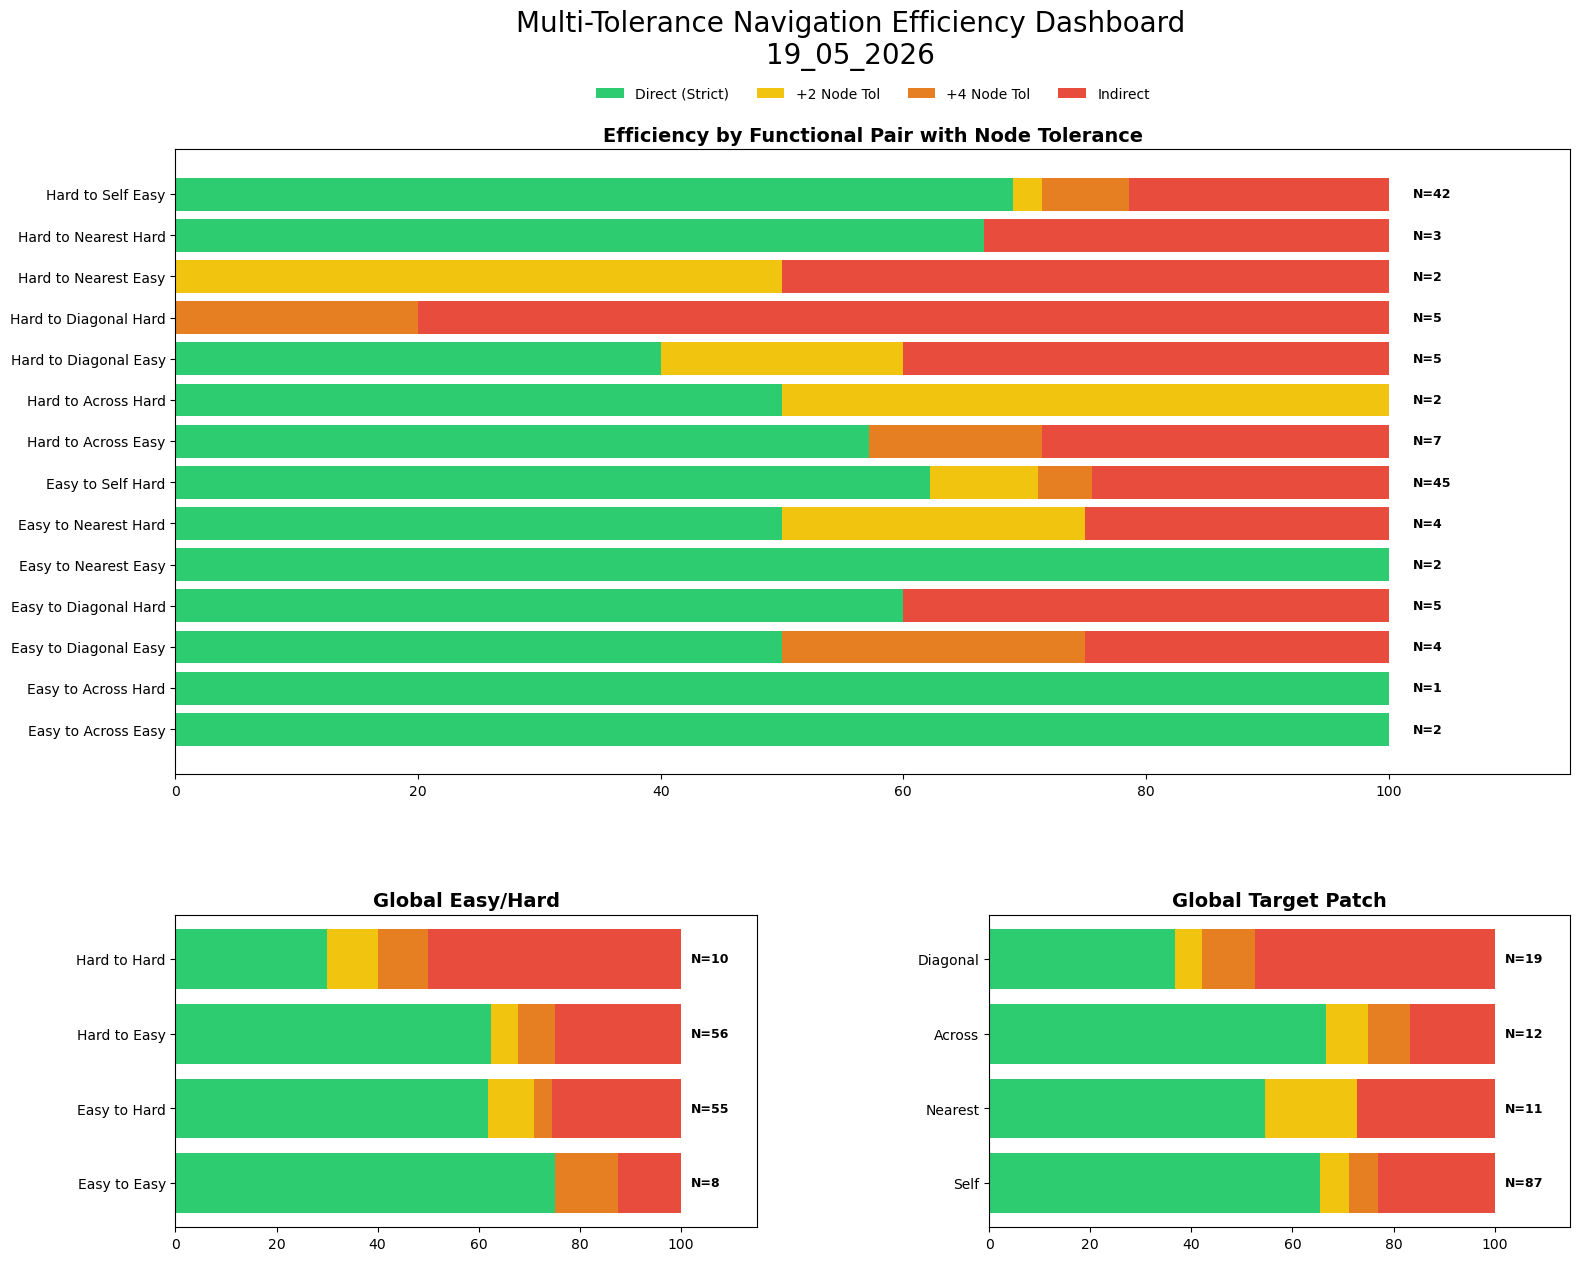

In [2312]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.3, wspace=0.4)

def draw_layered_bars(ax, stats, label_col, title):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['strict_pct'], color='#2ecc71', label='Direct (Strict)')
    
    # Layer 2: Tol 2 Extra (Yellow)
    ax.barh(y_pos, stats['tol2_extra_pct'], left=stats['strict_pct'], 
            color='#f1c40f', label='+2 Node Tol')
    
    # Layer 3: Tol 4 Extra (Orange)
    ax.barh(y_pos, stats['tol4_extra_pct'], left=stats['strict_pct'] + stats['tol2_extra_pct'], 
            color='#e67e22', label='+4 Node Tol')
    
    # Layer 4: Remaining Indirect (Red)
    ax.barh(y_pos, stats['indirect_pct'], left=stats['strict_pct'] + stats['tol2_extra_pct'] + stats['tol4_extra_pct'], 
            color='#e74c3c', label='Indirect')

    # N counts
    for i, total in enumerate(stats['total']):
        ax.text(102, i, f"N={total}", va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col])
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlim(0, 115)

# Panel 1: Detailed
ax1 = fig.add_subplot(gs[0, :])
draw_layered_bars(ax1, detailed_stats, 'group', 'Efficiency by Functional Pair with Node Tolerance')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

# Panel 2: Role Switch
ax2 = fig.add_subplot(gs[1, 0])
draw_layered_bars(ax2, role_stats, 'role_trans', 'Global Easy/Hard')

# Panel 3: Spatial
ax3 = fig.add_subplot(gs[1, 1])
spatial_stats['rel_order'] = spatial_stats['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats = spatial_stats.sort_values('rel_order')
draw_layered_bars(ax3, spatial_stats, 'relationship', 'Global Target Patch')

plt.suptitle(f"Multi-Tolerance Navigation Efficiency Dashboard\n{DD_MM_YYYY}", fontsize=20, y=0.98)
plt.savefig(ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/directness/Tolerance Percentage/{MM_DD_YYYY}_relative_patch_directness_tolerance_perct.png"), bbox_inches='tight')
plt.show()

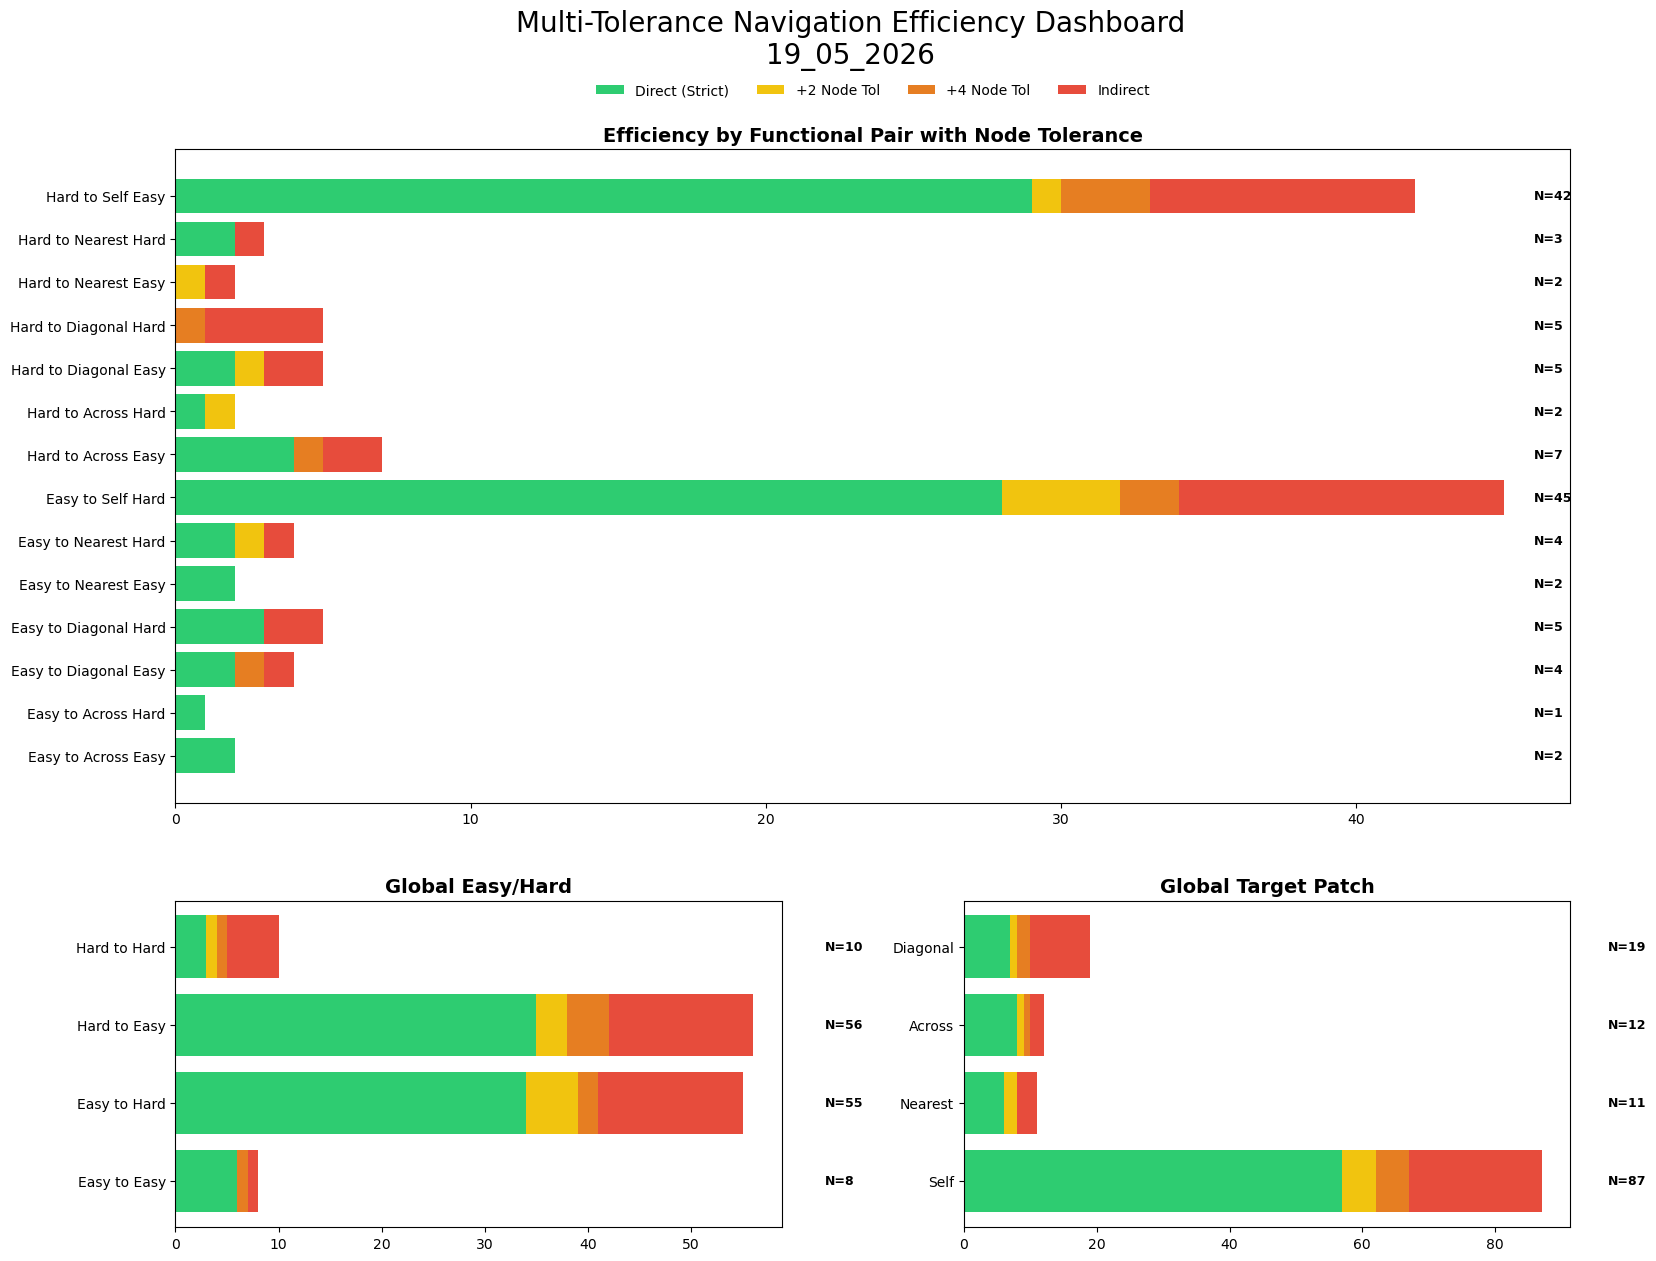

In [2313]:
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.2, wspace=0.3)

def draw_layered_bars(ax, stats, label_col, title, N_offset=1):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['direct'], color='#2ecc71', label='Direct (Strict)')
    
    # Layer 2: Tol 2 Extra (Yellow)
    ax.barh(y_pos, (stats['tol2'] - stats['direct']), left=stats['direct'], 
            color='#f1c40f', label='+2 Node Tol')
    
    # Layer 3: Tol 4 Extra (Orange)
    ax.barh(y_pos, (stats['tol4'] - stats['tol2']), left=stats['tol2'], 
            color='#e67e22', label='+4 Node Tol')
    
    # Layer 4: Remaining Indirect (Red)
    ax.barh(y_pos, (stats['total'] - stats['tol4']), left=stats['tol4'], 
            color='#e74c3c', label='Indirect')

    # N counts
    for i, total in enumerate(stats['total']):
        ax.text(stats['total'].max() + N_offset, i, f"N={total}", va='center', fontsize=9, fontweight='bold')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col])
    ax.set_title(title, fontsize=14, fontweight='bold')

# Panel 1: Detailed
ax1 = fig.add_subplot(gs[0, :])
draw_layered_bars(ax1, detailed_stats, 'group', 'Efficiency by Functional Pair with Node Tolerance')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=4, frameon=False)

# Panel 2: Role Switch
ax2 = fig.add_subplot(gs[1, 0])
draw_layered_bars(ax2, role_stats, 'role_trans', 'Global Easy/Hard', N_offset = 7)

# Panel 3: Spatial
ax3 = fig.add_subplot(gs[1, 1])
spatial_stats['rel_order'] = spatial_stats['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats = spatial_stats.sort_values('rel_order')
draw_layered_bars(ax3, spatial_stats, 'relationship', 'Global Target Patch', N_offset = 10)

plt.suptitle(f"Multi-Tolerance Navigation Efficiency Dashboard\n{DD_MM_YYYY}", fontsize=20, y=0.98)
plt.savefig(ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/directness/Tolerance Totals/{MM_DD_YYYY}_relative_patch_directness_tolerance_totals.png"), bbox_inches='tight')
plt.show()

In [2314]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Data Preparation ---
# Use the cleaned data without repeats
df = all_paths_without_repeat.copy()
df['src_role'] = df['group'].apply(lambda x: x.split(' to ')[0])
df['dest_role'] = df['group'].apply(lambda x: x.split(' ')[-1])
df['role_trans'] = df['src_role'] + " to " + df['dest_role']

# Filter out the Identical-Role Self-Moves (Easy->Easy Self, Hard->Hard Self)
plot_df = df[~df['group'].isin(['Easy to Self Easy', 'Hard to Self Hard'])].copy()

def get_skip_leaves_stats(data, column):
    # Aggregate raw counts
    stats = data.groupby(column).agg(
        total=('is_direct', 'count'),
        direct=('is_direct', 'sum'),
        skip_leaves=('is_direct_skip_leaves', 'sum')
    ).reset_index()
    
    # Calculate percentages for non-overlapping layers
    # Segment 1: Physical perfection
    stats['strict_pct'] = (stats['direct'] / stats['total']) * 100
    
    # Segment 2: The 'Extra' paths caught only by skip_leaves logic
    stats['skip_extra_pct'] = ((stats['skip_leaves'] - stats['direct']) / stats['total'] * 100).clip(lower=0)
    
    # Segment 3: Paths that are still indirect (The failure rate)
    stats['indirect_pct'] = (100 - (stats['skip_leaves'] / stats['total'] * 100)).clip(lower=0)
    
    return stats

# Generate the three data levels
detailed_stats_leaves = get_skip_leaves_stats(plot_df, 'group')
role_stats_leaves = get_skip_leaves_stats(plot_df, 'role_trans')
spatial_stats_leaves = get_skip_leaves_stats(plot_df, 'relationship')

/tmp/ipykernel_827484/2184105690.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


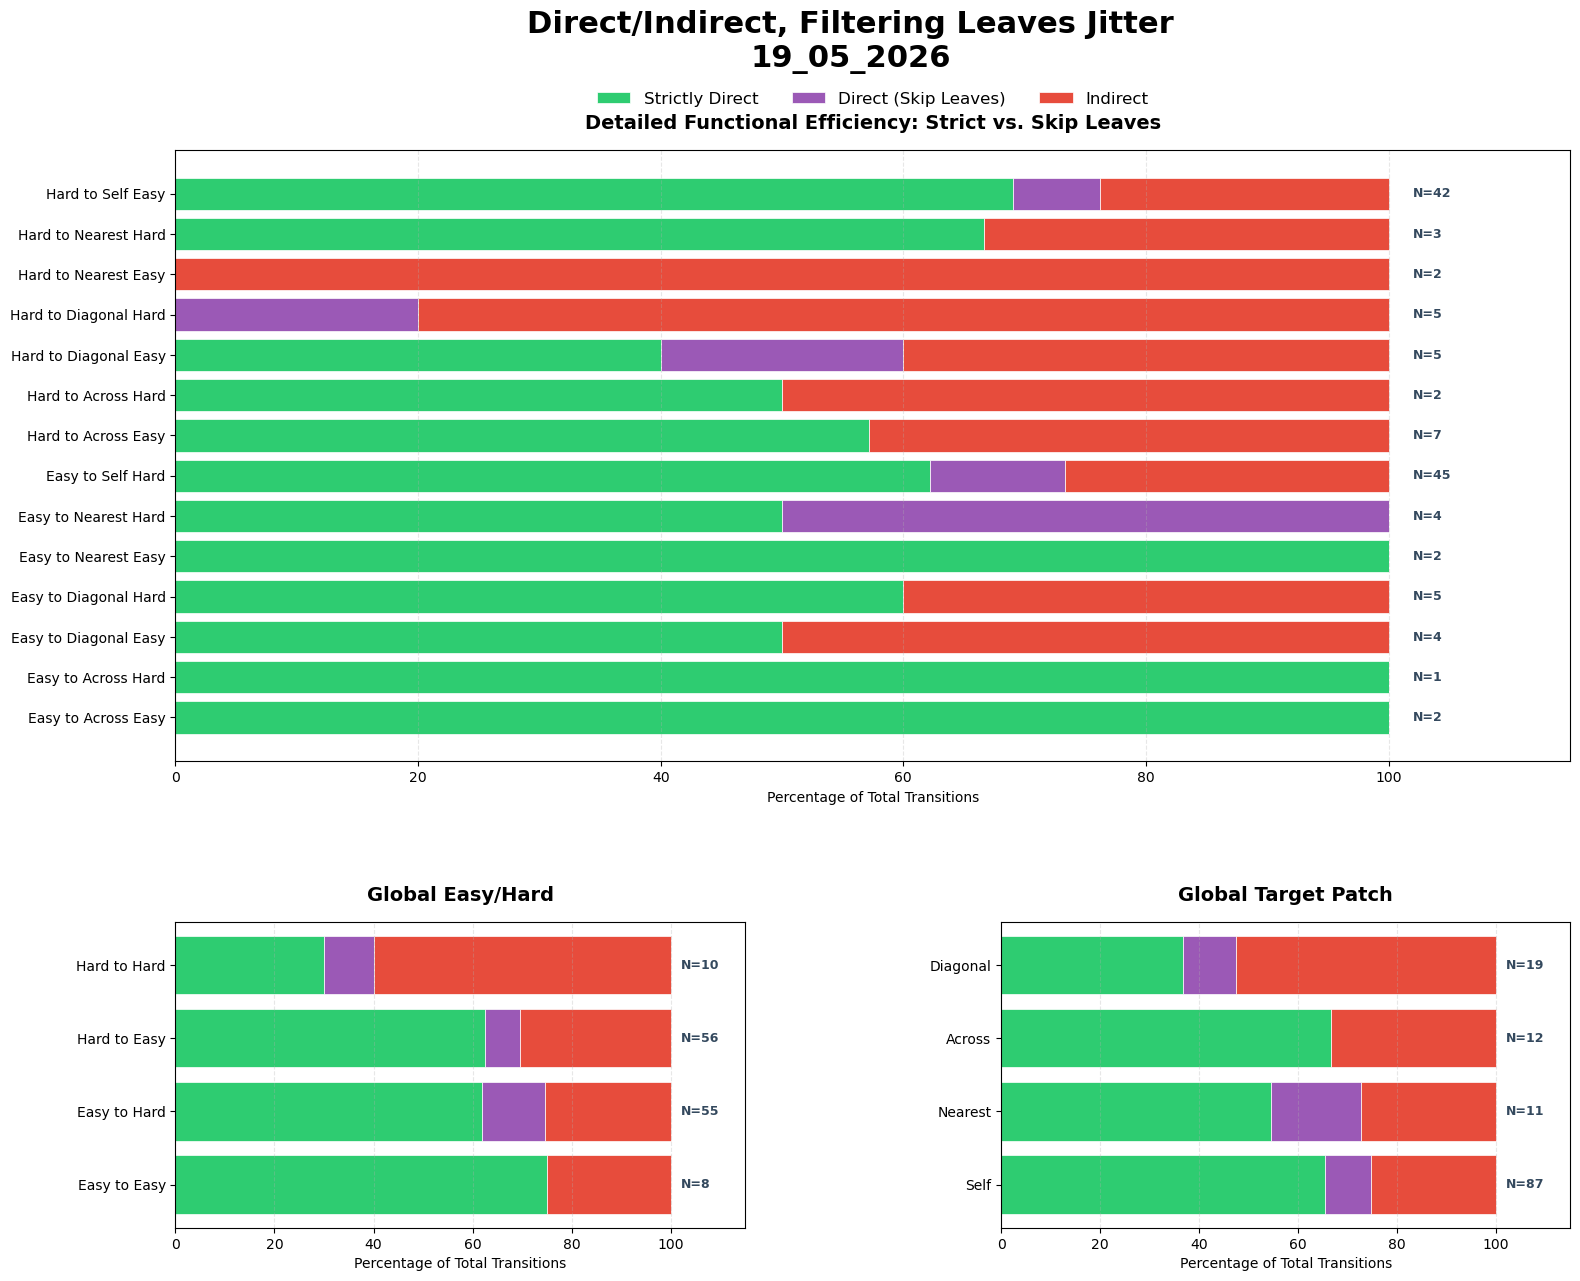

In [2315]:
def draw_skip_leaves_bars(ax, stats, label_col, title):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['strict_pct'], color='#2ecc71', 
            label='Strictly Direct', edgecolor='white', linewidth=0.5)
    
    # Layer 2: Skip Leaves Gain (Purple/Amethyst)
    # Represents paths that are globally direct but locally noisy at leaves
    ax.barh(y_pos, stats['skip_extra_pct'], left=stats['strict_pct'], 
            color='#9b59b6', label='Direct (Skip Leaves)', edgecolor='white', linewidth=0.5)
    
    # Layer 3: True Indirect (Red/Alizarin)
    # Represents actual navigational errors in the maze core (Levels 1, 2, 3)
    ax.barh(y_pos, stats['indirect_pct'], left=stats['strict_pct'] + stats['skip_extra_pct'], 
            color='#e74c3c', label='Indirect', edgecolor='white', linewidth=0.5)

    # N counts on the right side
    for i, total in enumerate(stats['total']):
        ax.text(102, i, f"N={total}", va='center', fontsize=9, fontweight='bold', color='#34495e')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlim(0, 115)
    ax.set_xlabel('Percentage of Total Transitions')
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# --- Execute Plotting ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.35, wspace=0.45)

# Panel 1: Detailed (Full Width Top)
ax1 = fig.add_subplot(gs[0, :])
draw_skip_leaves_bars(ax1, detailed_stats_leaves, 'group', 'Detailed Functional Efficiency: Strict vs. Skip Leaves')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=12)

# Panel 2: Role Switch (Bottom Left)
ax2 = fig.add_subplot(gs[1, 0])
draw_skip_leaves_bars(ax2, role_stats_leaves, 'role_trans', 'Global Easy/Hard')

# Panel 3: Spatial (Bottom Right)
ax3 = fig.add_subplot(gs[1, 1])
# Sort spatially: Self -> Near -> Across -> Diag
spatial_stats_leaves['rel_order'] = spatial_stats_leaves['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats_leaves = spatial_stats_leaves.sort_values('rel_order')
draw_skip_leaves_bars(ax3, spatial_stats_leaves, 'relationship', 'Global Target Patch')

plt.suptitle(f"Direct/Indirect, Filtering Leaves Jitter\n{DD_MM_YYYY}", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/directness/Leaves Filter Percentage/{MM_DD_YYYY}_relative_patch_directness_leaves_filter_perct.png"), bbox_inches='tight')
plt.show()

/tmp/ipykernel_827484/2644890181.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


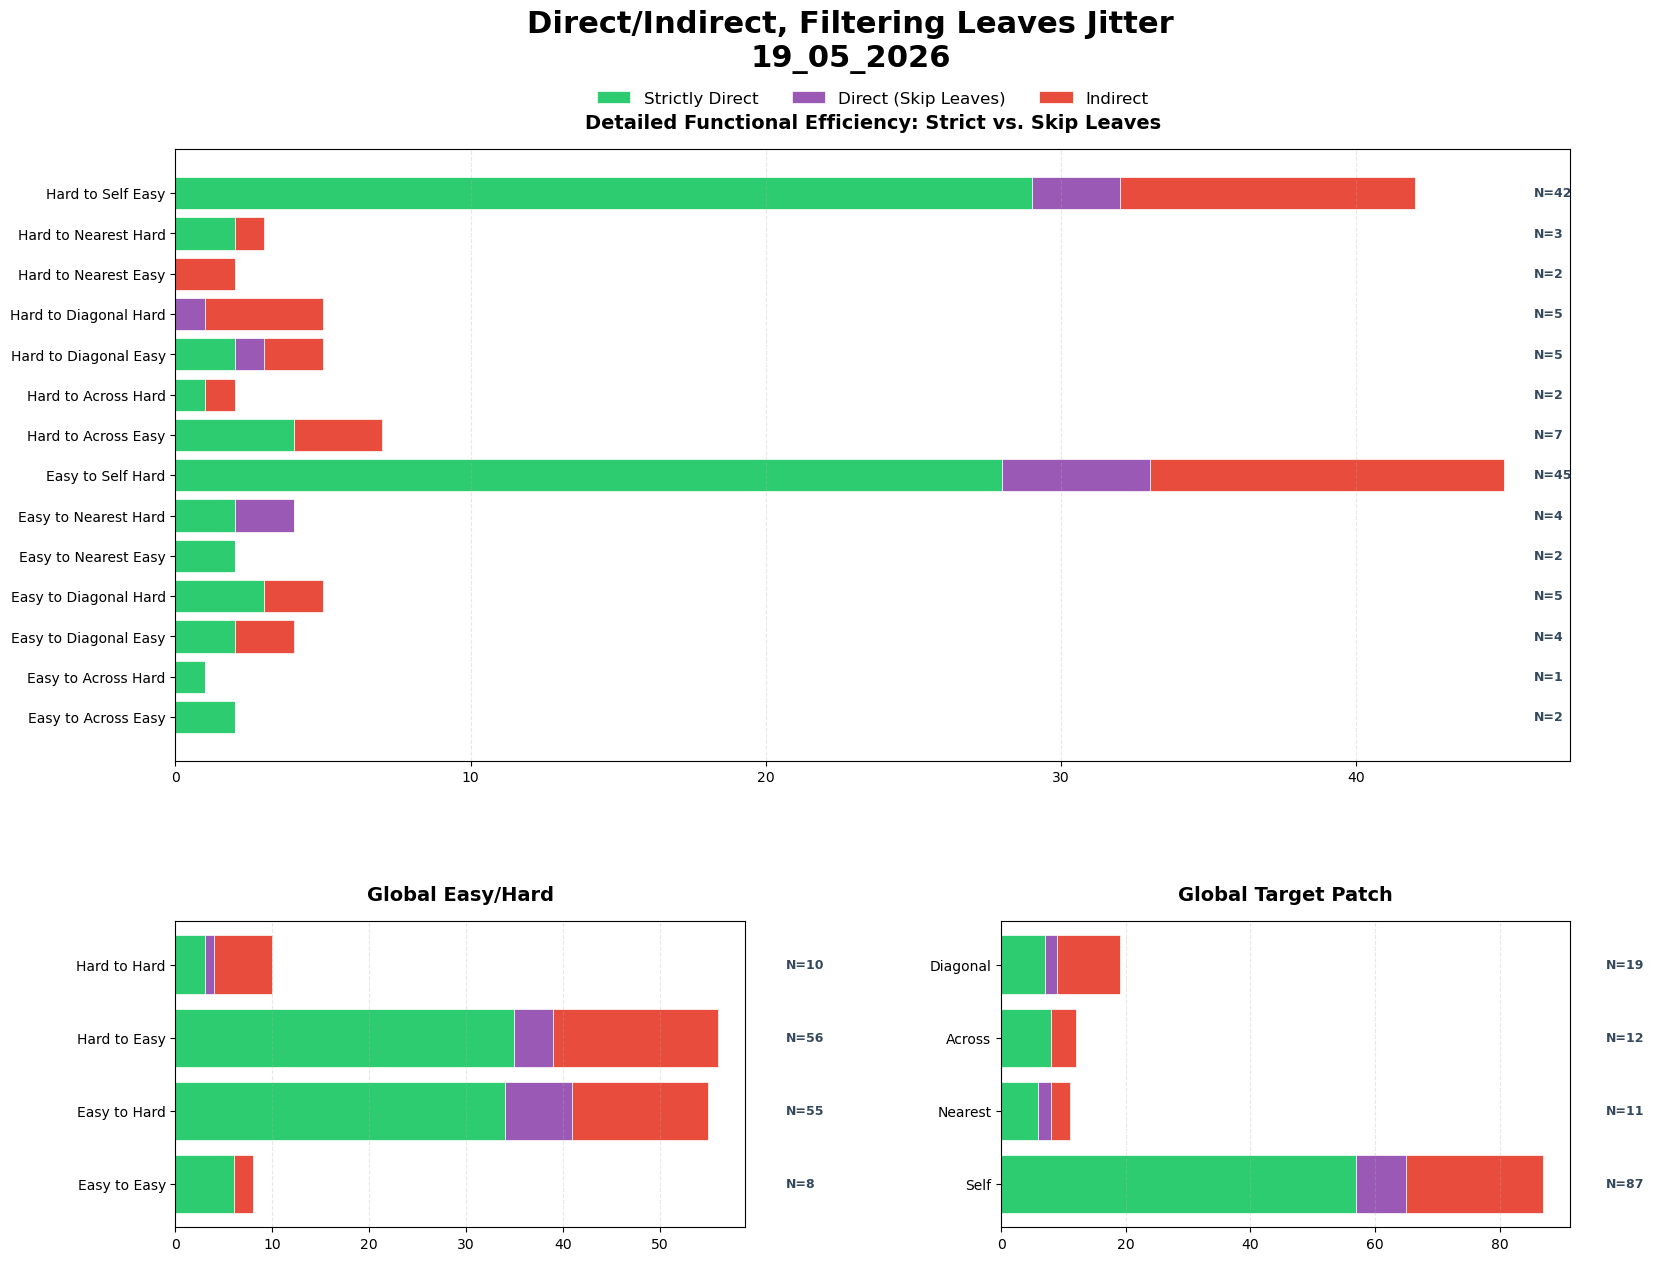

In [2316]:
def draw_skip_leaves_bars_abs(ax, stats, label_col, title, N_offset=1):
    y_pos = np.arange(len(stats))
    
    # Layer 1: Strict Direct (Green)
    ax.barh(y_pos, stats['direct'], color='#2ecc71', 
            label='Strictly Direct', edgecolor='white', linewidth=0.5)
    
    # Layer 2: Skip Leaves Gain (Purple/Amethyst)
    # Represents paths that are globally direct but locally noisy at leaves
    ax.barh(y_pos, stats['skip_leaves'] - stats['direct'], left=stats['direct'], 
            color='#9b59b6', label='Direct (Skip Leaves)', edgecolor='white', linewidth=0.5)
    
    # Layer 3: True Indirect (Red/Alizarin)
    # Represents actual navigational errors in the maze core (Levels 1, 2, 3)
    ax.barh(y_pos, stats['total'] - stats['skip_leaves'], left=stats['skip_leaves'], 
            color='#e74c3c', label='Indirect', edgecolor='white', linewidth=0.5)

    # N counts on the right side
    for i, total in enumerate(stats['total']):
        ax.text(stats['total'].max() + N_offset, i, f"N={total}", va='center', fontsize=9, fontweight='bold', color='#34495e')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(stats[label_col], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# --- Execute Plotting ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(2, 2, height_ratios=[2, 1], hspace=0.35, wspace=0.45)

# Panel 1: Detailed (Full Width Top)
ax1 = fig.add_subplot(gs[0, :])
draw_skip_leaves_bars_abs(ax1, detailed_stats_leaves, 'group', 'Detailed Functional Efficiency: Strict vs. Skip Leaves')
ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=3, frameon=False, fontsize=12)

# Panel 2: Role Switch (Bottom Left)
ax2 = fig.add_subplot(gs[1, 0])
draw_skip_leaves_bars_abs(ax2, role_stats_leaves, 'role_trans', 'Global Easy/Hard', N_offset=7)

# Panel 3: Spatial (Bottom Right)
ax3 = fig.add_subplot(gs[1, 1])
# Sort spatially: Self -> Near -> Across -> Diag
spatial_stats_leaves['rel_order'] = spatial_stats_leaves['relationship'].map({'Self':0, 'Nearest':1, 'Across':2, 'Diagonal':3})
spatial_stats_leaves = spatial_stats_leaves.sort_values('rel_order')
draw_skip_leaves_bars_abs(ax3, spatial_stats_leaves, 'relationship', 'Global Target Patch', N_offset=10)

plt.suptitle(f"Direct/Indirect, Filtering Leaves Jitter\n{DD_MM_YYYY}", fontsize=22, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig(ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/directness/Leaves Filter Totals/{MM_DD_YYYY}_relative_patch_directness_leaves_filter_totals.png"), bbox_inches='tight')
plt.show()

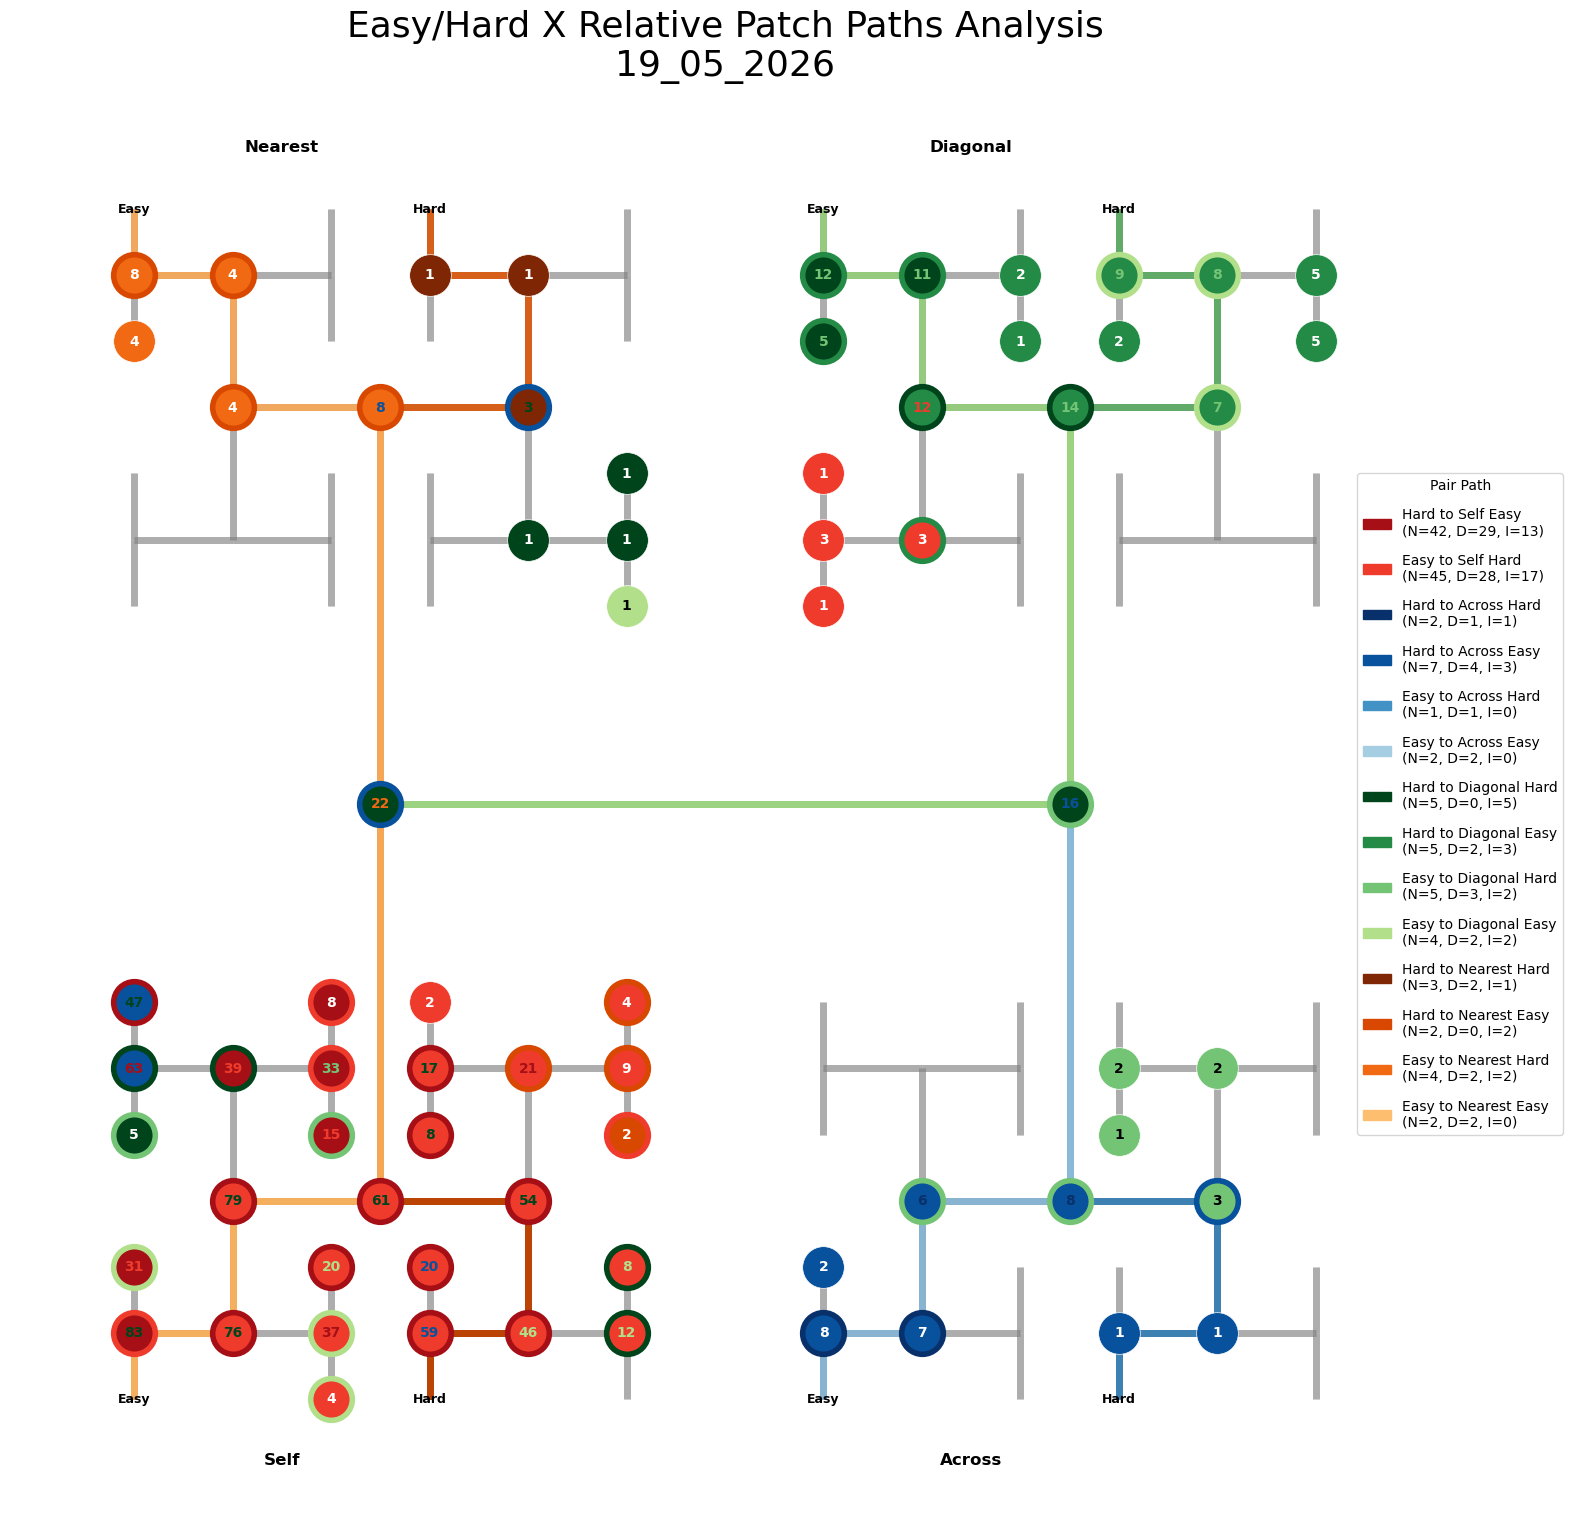

In [2317]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import Counter
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import numpy as np
from itertools import groupby

# 1. High Contrast 16-Color Map
color_map_16 = {
    # SELF (RED SPECTRUM)
    'Hard to Self Hard':   '#67000d', # Deep Burgundy (Darkest)
    'Hard to Self Easy':   '#a50f15', # Blood Red
    'Easy to Self Hard':   '#ef3b2c', # Bright Red
    'Easy to Self Easy':   '#fb9a99', # Soft Coral

    # ACROSS (BLUE SPECTRUM)
    'Hard to Across Hard': '#08306b', # Navy (Darkest)
    'Hard to Across Easy': '#08519c', # Royal Blue
    'Easy to Across Hard': '#4292c6', # Sky Blue
    'Easy to Across Easy': '#a6cee3', # Pale Azure

    # DIAGONAL (GREEN SPECTRUM)
    'Hard to Diagonal Hard':'#00441b', # Forest Green (Darkest)
    'Hard to Diagonal Easy':'#238b45', # Kelly Green
    'Easy to Diagonal Hard':'#74c476', # Sage Green
    'Easy to Diagonal Easy':'#b2df8a', # Mint Green

    # NEAREST (GOLD/ORANGE SPECTRUM)
    'Hard to Nearest Hard': '#7f2704', # Burnt Umber (Darkest)
    'Hard to Nearest Easy': '#d94801', # Deep Orange
    'Easy to Nearest Hard': '#f16913', # Vivid Orange (Fixing naming consistency)
    'Easy to Nearest Easy': '#fdbf6f'  # Apricot Gold
}

def plot_universal_16_path_projector_complete(G, node_positions, df_all_paths, key_to_nodes, node_to_key, port_meta, colormap=color_map_16, save_path=None):
    
    rel_to_template_idx = {'Self': 0, 'Across': 1, 'Diagonal': 2, 'Nearest': 3}
    universal_detours = Counter()

    # 2. Process Detours and Backbones
    for _, row in df_all_paths.iterrows():
        path = row['path_nodes']
        group = row['group']
        relationship = row['relationship']
        src_patch_idx = port_meta[row['source_port']]['patch']
        
        # Bridge-Flip logic for Patches 1 and 2
        needs_bridge_flip = src_patch_idx in [1, 2]

        if not row['is_direct']:
            for node in path[1:-1]:
                if node in node_to_key:
                    key = node_to_key[node]
                    curr_phys_patch = next((i for i in range(4) if node in [nodes[i] for nodes in key_to_nodes.values()]), None)
                    if curr_phys_patch is not None:
                        rel_to_source = rel_matrix[(src_patch_idx, curr_phys_patch)]
                        proj_idx = rel_to_template_idx[rel_to_source]
                        universal_detours[(group, key_to_nodes[key][proj_idx])] += 1
                elif node in ['L0', 'R0']:
                    target_node = ('R0' if node == 'L0' else 'L0') if needs_bridge_flip else node
                    universal_detours[(group, target_node)] += 1
        # for node in path[1:-1]:
        #     if node in node_to_key:
        #         key = node_to_key[node]
        #         curr_phys_patch = next((i for i in range(4) if node in [nodes[i] for nodes in key_to_nodes.values()]), None)
        #         if curr_phys_patch is not None:
        #             rel_to_source = rel_matrix[(src_patch_idx, curr_phys_patch)]
        #             proj_idx = rel_to_template_idx[rel_to_source]
        #             universal_detours[(group, key_to_nodes[key][proj_idx])] += 1
        #     elif node in ['L0', 'R0']:
        #         target_node = ('R0' if node == 'L0' else 'L0') if needs_bridge_flip else node
        #         universal_detours[(group, target_node)] += 1

    # 3. Setup Plot
    fig = plt.figure(figsize=(26, 16))
    ax = fig.add_axes([0.05, 0.05, 0.55, 0.9])
    nx.draw_networkx_edges(G, node_positions, alpha=0.4, edge_color='gray', arrows=False, width=5)

    # 4. Draw Direct Path "Flow" Edges
    for group_name, color in color_map_16.items():
        if group_name in df_all_paths['group'].values:
            parts = group_name.split(' to ')
            src_role = parts[0]
            rel_parts = parts[1].split(' ')
            rel, dest_role = rel_parts[0], rel_parts[1]
            
            src_key = 'K26' if src_role == 'Easy' else 'K22'
            dest_key = 'K26' if dest_role == 'Easy' else 'K22'
            
            u_src = key_to_nodes[src_key][0] 
            u_dest = key_to_nodes[dest_key][rel_to_template_idx[rel]]
            
            try:
                backbone = nx.shortest_path(G, u_src, u_dest)
                edge_list = [(backbone[i], backbone[i+1]) for i in range(len(backbone)-1)]
                nx.draw_networkx_edges(G, node_positions, edgelist=edge_list, 
                                       edge_color=color, width=5, alpha=0.75, arrows=False)
            except: pass

    # 5. Draw Detour Nodes with Triple-Color Logic
    all_detour_nodes = sorted(list(set([n for (g, n) in universal_detours.keys()])))
    for phys_node in all_detour_nodes:
        # Get counts for all groups at this node, sorted descending
        node_stats = {g: universal_detours[(g, phys_node)] for g, n in universal_detours.keys() if n == phys_node}
        sorted_groups = sorted(node_stats.keys(), key=lambda x: node_stats[x], reverse=True)
        total_count = sum(node_stats.values())
        
        # Assign colors for Top 1, 2, and 3
        fill_color = color_map_16.get(sorted_groups[0], 'gray')
        border_color = color_map_16.get(sorted_groups[1], 'white') if len(sorted_groups) > 1 else 'white'
        text_color = color_map_16.get(sorted_groups[2], None) if len(sorted_groups) > 2 else None
        
        # If no 3rd color, use contrast logic for text
        if text_color is None:
            lum = np.mean(mcolors.to_rgb(fill_color))
            text_color = 'white' if lum < 0.5 else 'black'
            
        # Draw the node (Top 1 = Fill, Top 2 = Border)
        nx.draw_networkx_nodes(G, node_positions, nodelist=[phys_node], 
                               node_color=[fill_color], 
                               edgecolors=border_color,
                               linewidths=4 if len(sorted_groups) > 1 else 0.5,
                               node_size=900, alpha=1, ax=ax)
        
        # Draw the label (Top 3 = Text Color)
        nx.draw_networkx_labels(G, node_positions, labels={phys_node: str(total_count)}, 
                                font_size=10, font_weight='bold', font_color=text_color)

    # 6. EXTERNAL PATCH LABELS & ROLE LABELS
    for rel, idx in rel_to_template_idx.items():      
        nx.draw_networkx_labels(G, node_positions, 
                                labels={key_to_nodes['K26'][idx]: 'Easy', key_to_nodes['K22'][idx]: 'Hard'}, 
                                font_size=9, font_weight='bold')
        pos_a = node_positions[key_to_nodes['K26'][idx]]
        pos_b = node_positions[key_to_nodes['K22'][idx]]
        mid_x, mid_y = (pos_a[0] + pos_b[0]) / 2, (pos_a[1] + pos_b[1]) / 2
        if rel == 'Nearest' or rel == 'Diagonal':
            mid_y += 30
        else:
            mid_y -= 30
        ax.text(mid_x, mid_y, rel, color='black', 
                fontweight='bold', fontsize=12, ha='center', va='center',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

    # 8. Legend and Titles

    legend_entries = []
    for group_name, color in color_map_16.items():
        rel_df = df_all_paths[df_all_paths['group'] == group_name]
        if len(rel_df) > 0:
            n_tot, n_dir = len(rel_df), rel_df['is_direct'].sum()
            patch = mpatches.Patch(color=color, label=f"{group_name}\n(N={n_tot}, D={n_dir}, I={n_tot-n_dir})")
            legend_entries.append(patch)

    fig.legend(handles=legend_entries, loc='center right', title="Pair Path", 
               bbox_to_anchor=(0.65, 0.5), fontsize=10, labelspacing=1.1, frameon=True)

    ax.set_title(f"Easy/Hard X Relative Patch Paths Analysis\n{DD_MM_YYYY}", fontsize=26, pad=0)
    ax.axis('off')
    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat, key_to_nodes, node_to_key, port_meta)

In [2318]:
# df_all_paths[df_all_paths['group'] == 'Easy to Nearest Easy']
# df_all_paths
# port_meta['Target5']['patch']
len(df_all_paths.groupby('group'))

16

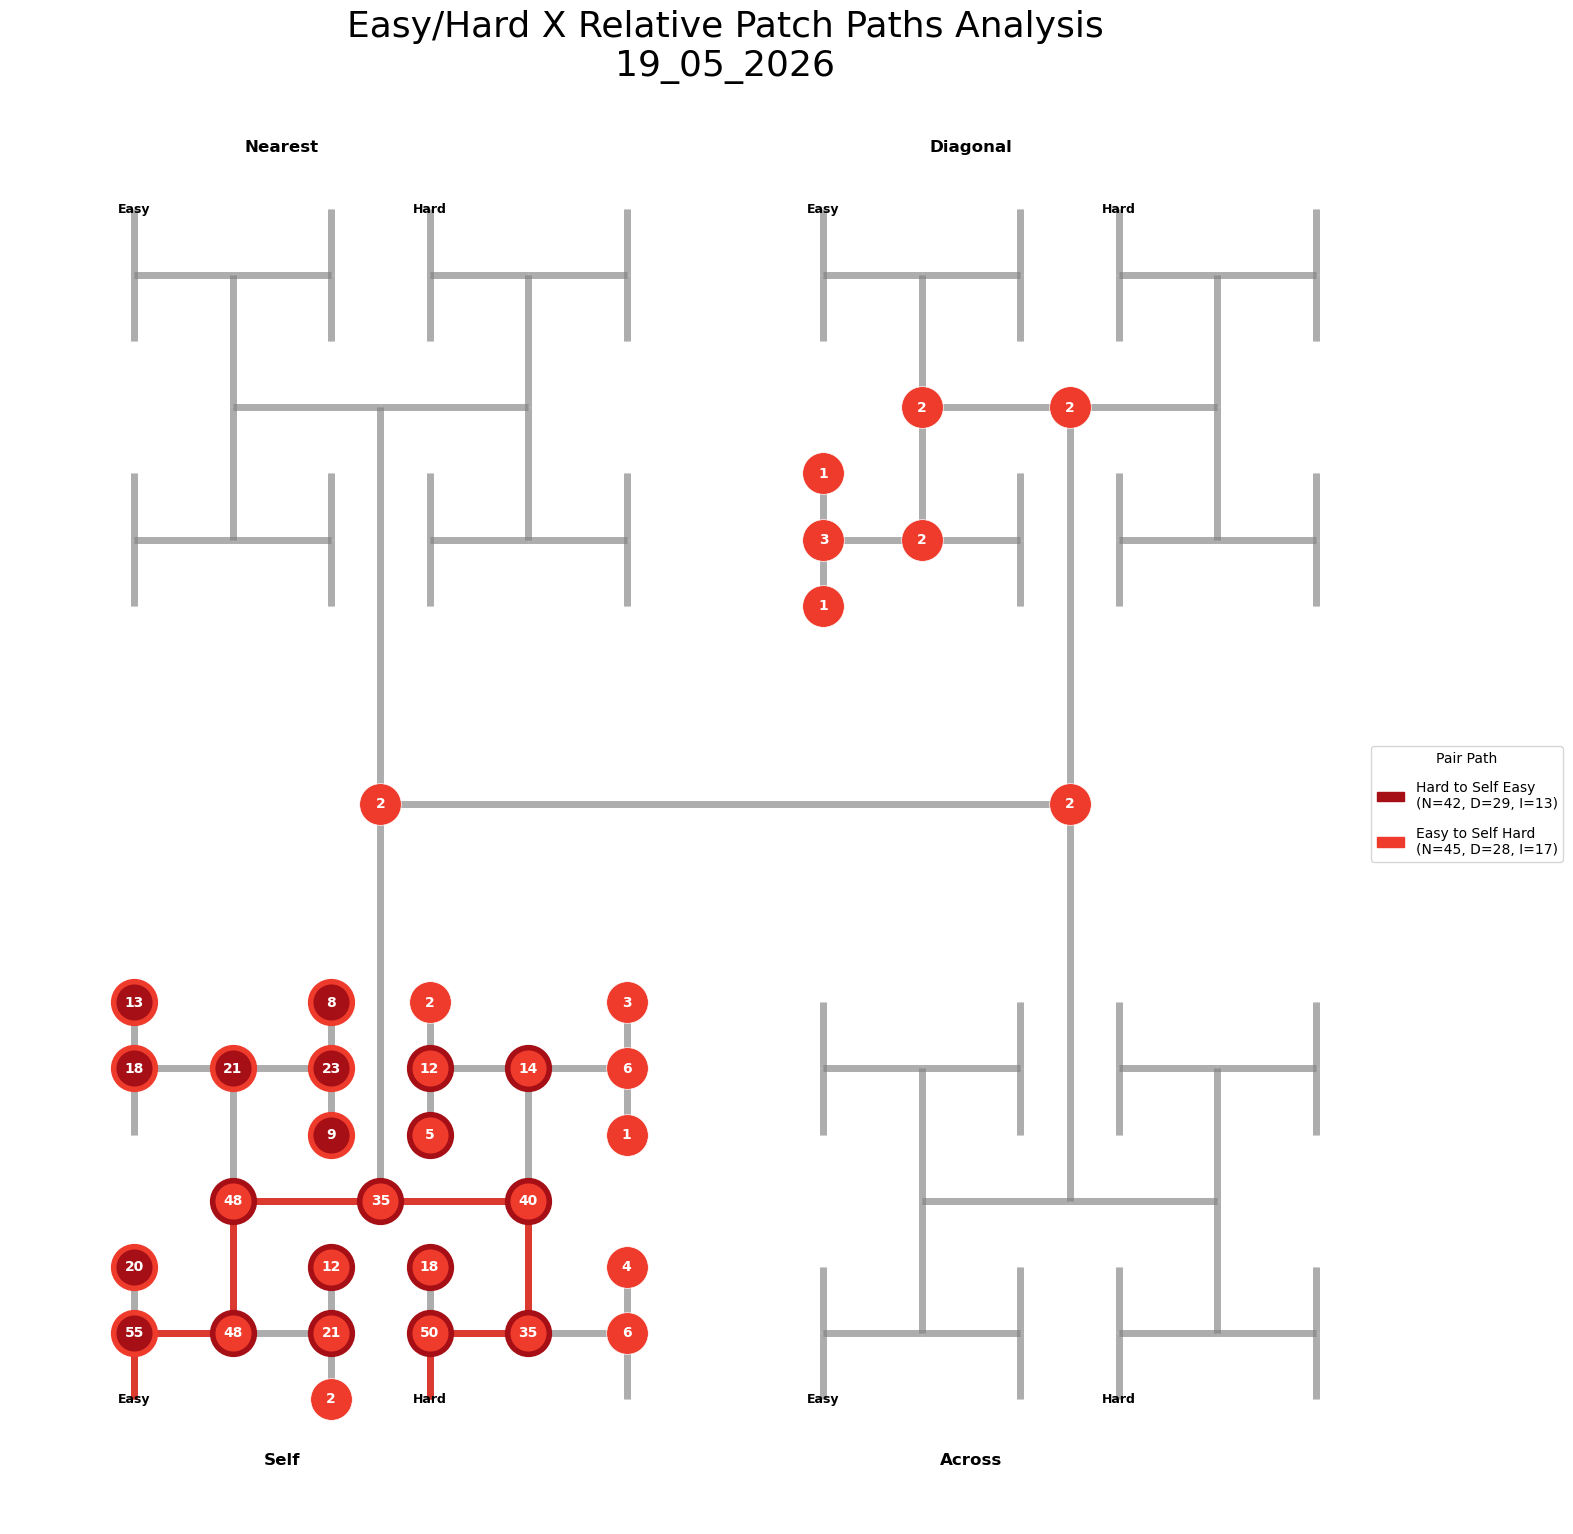

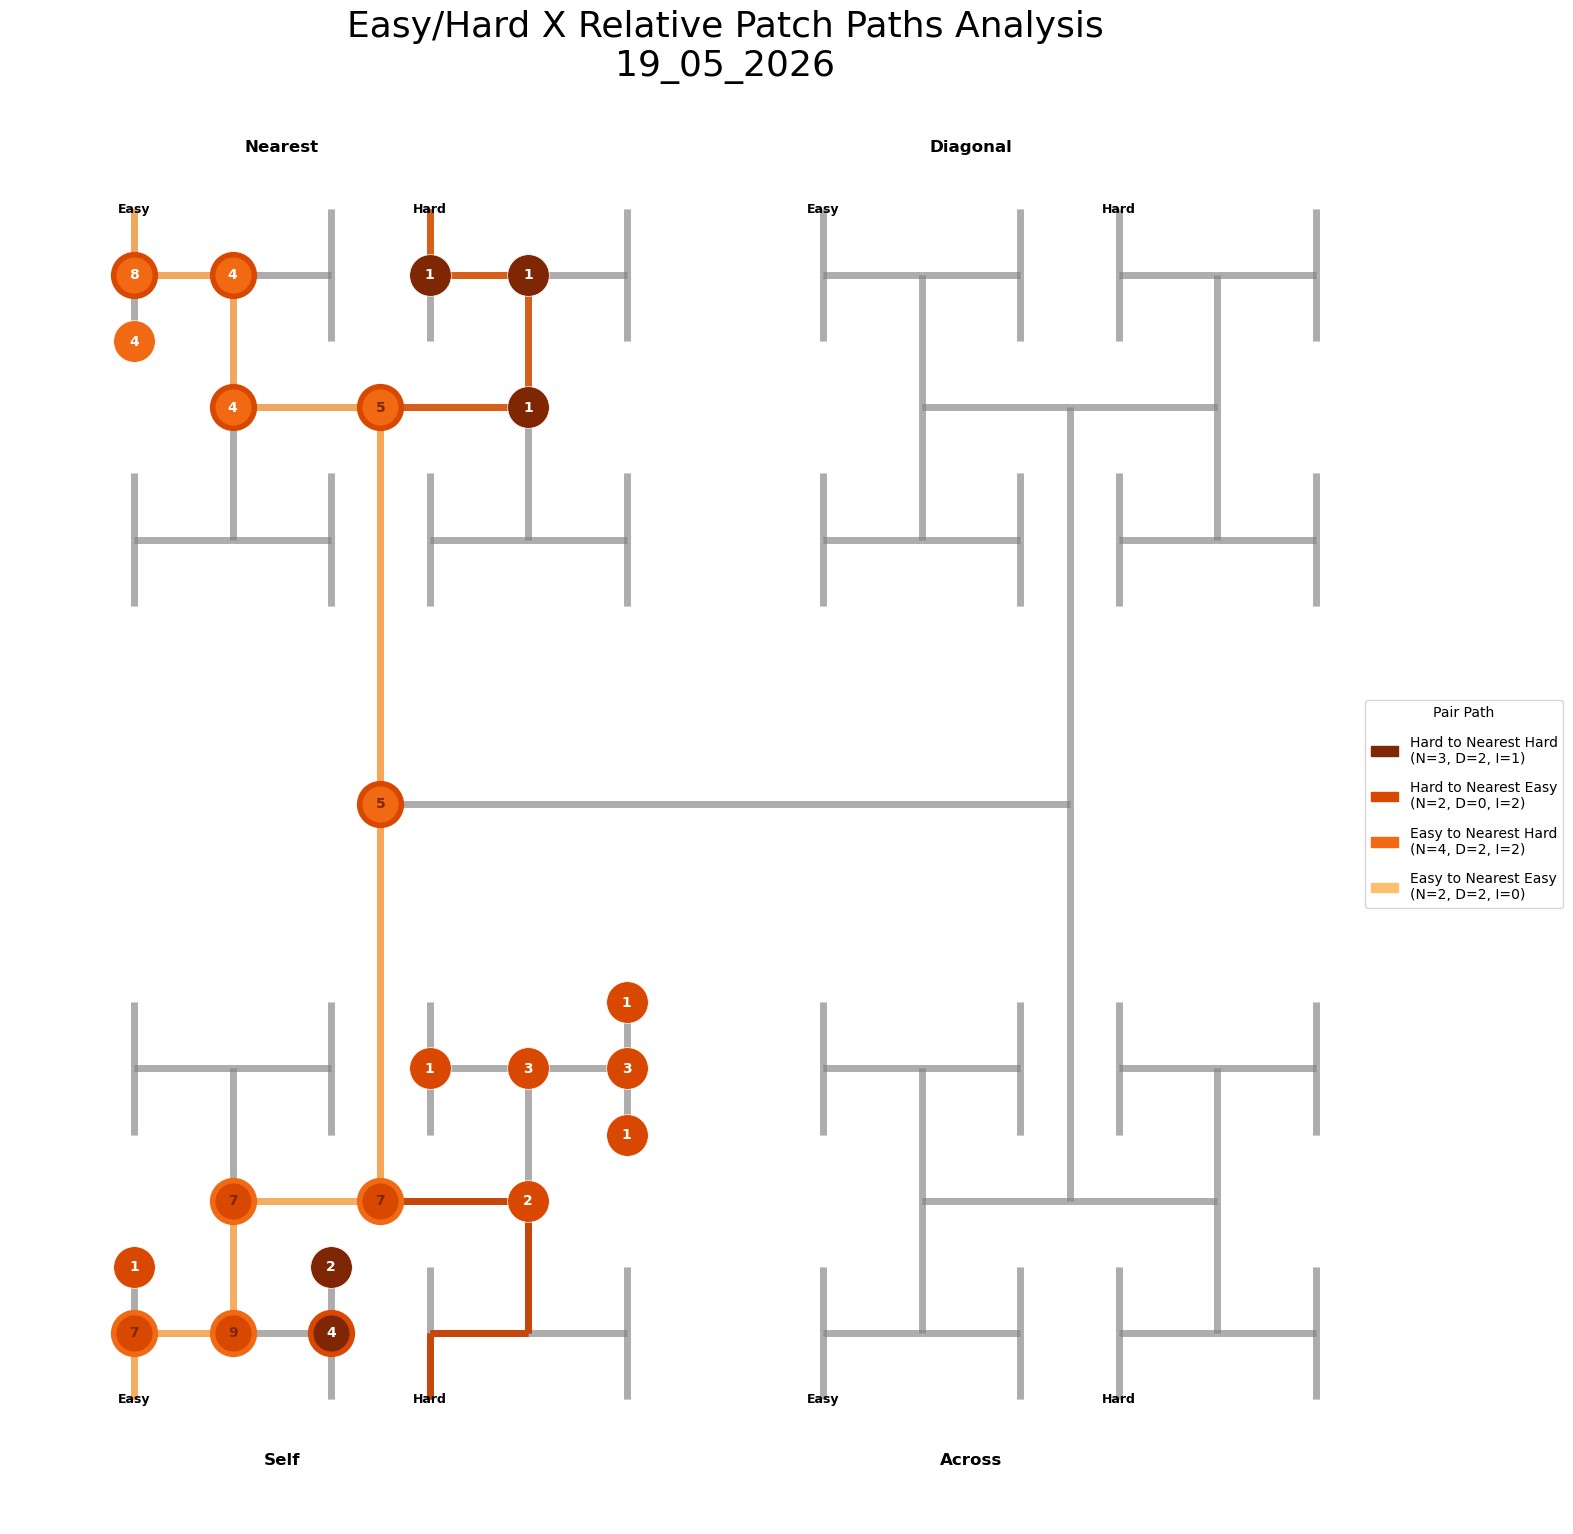

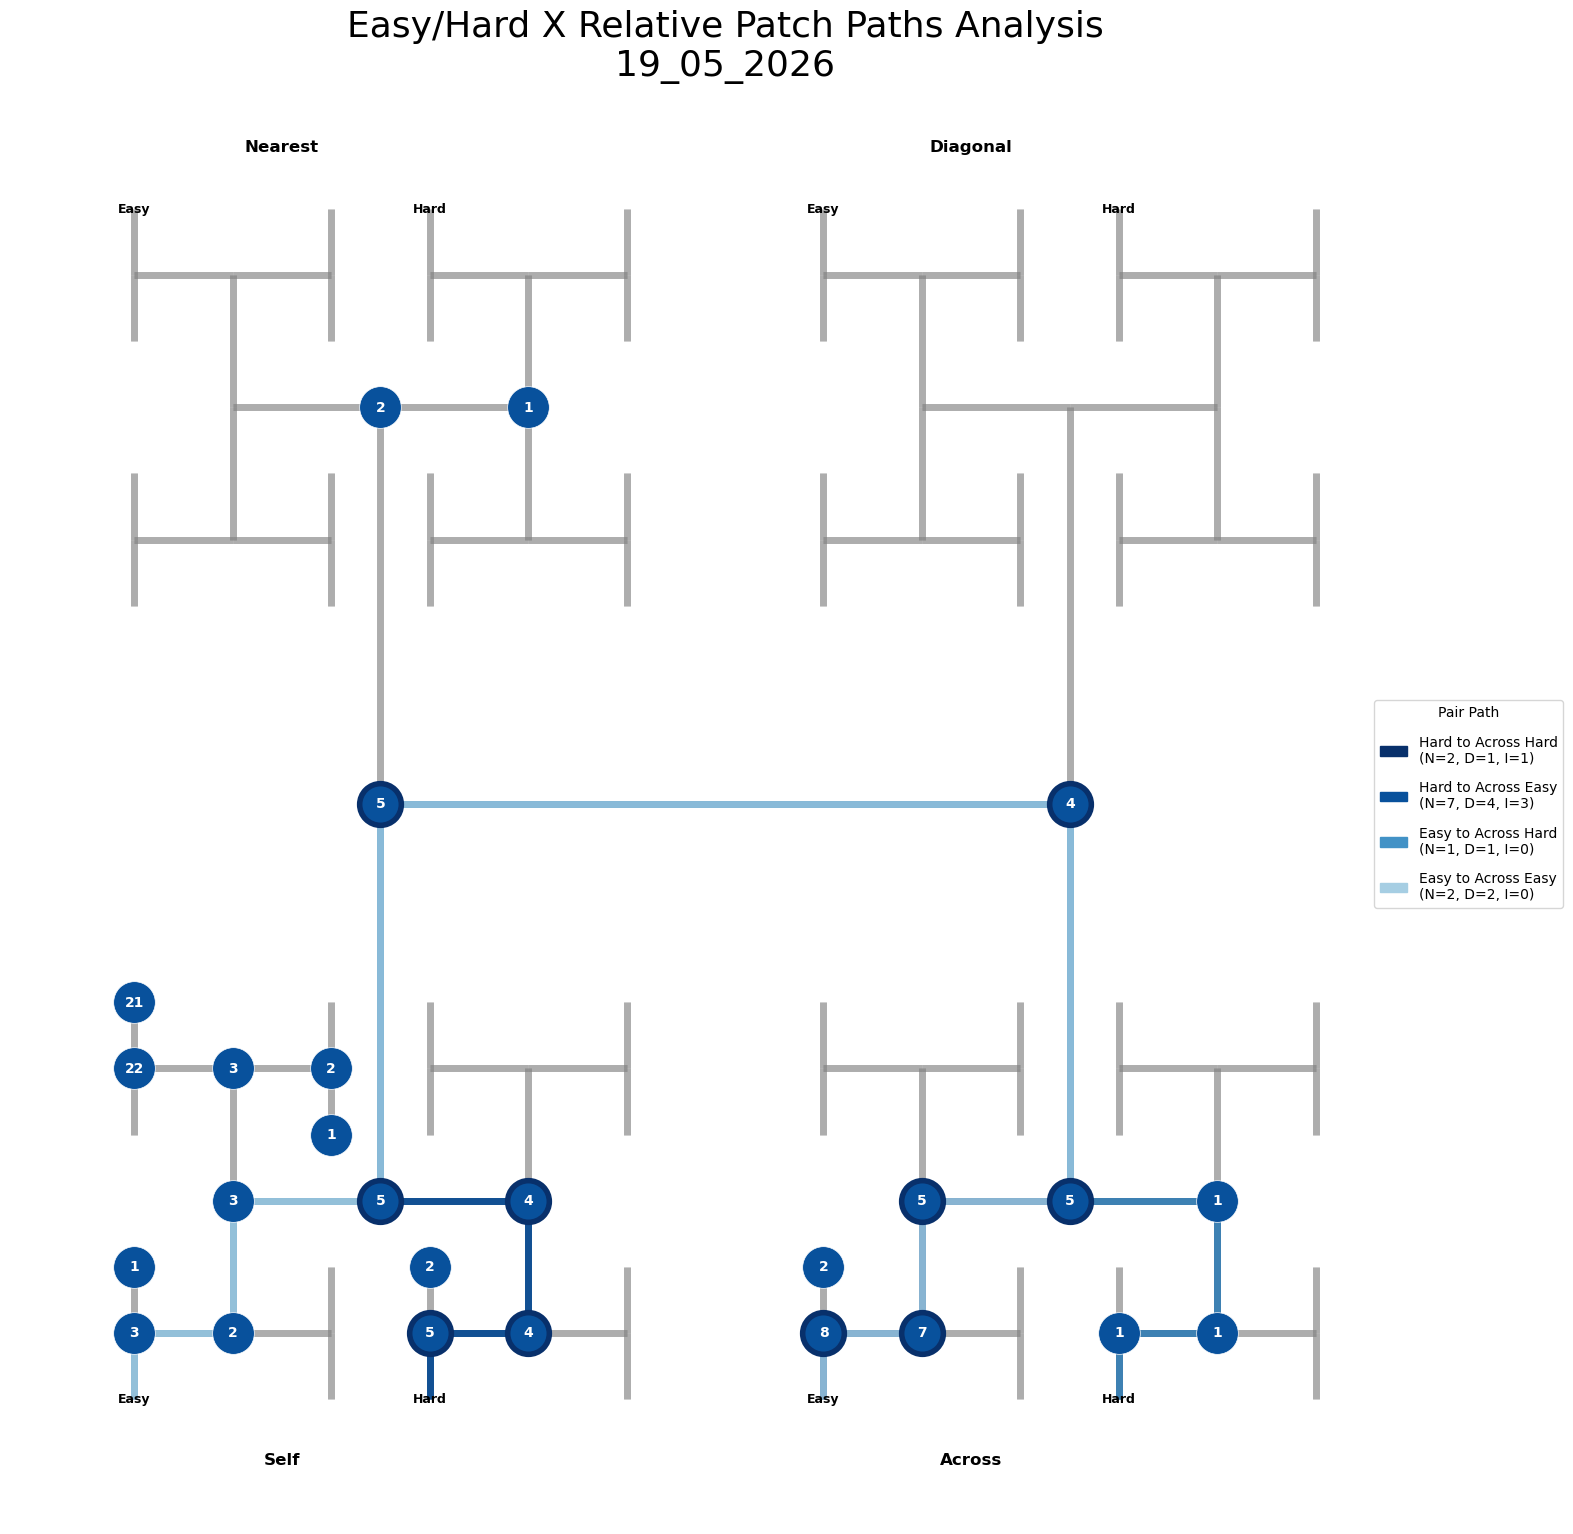

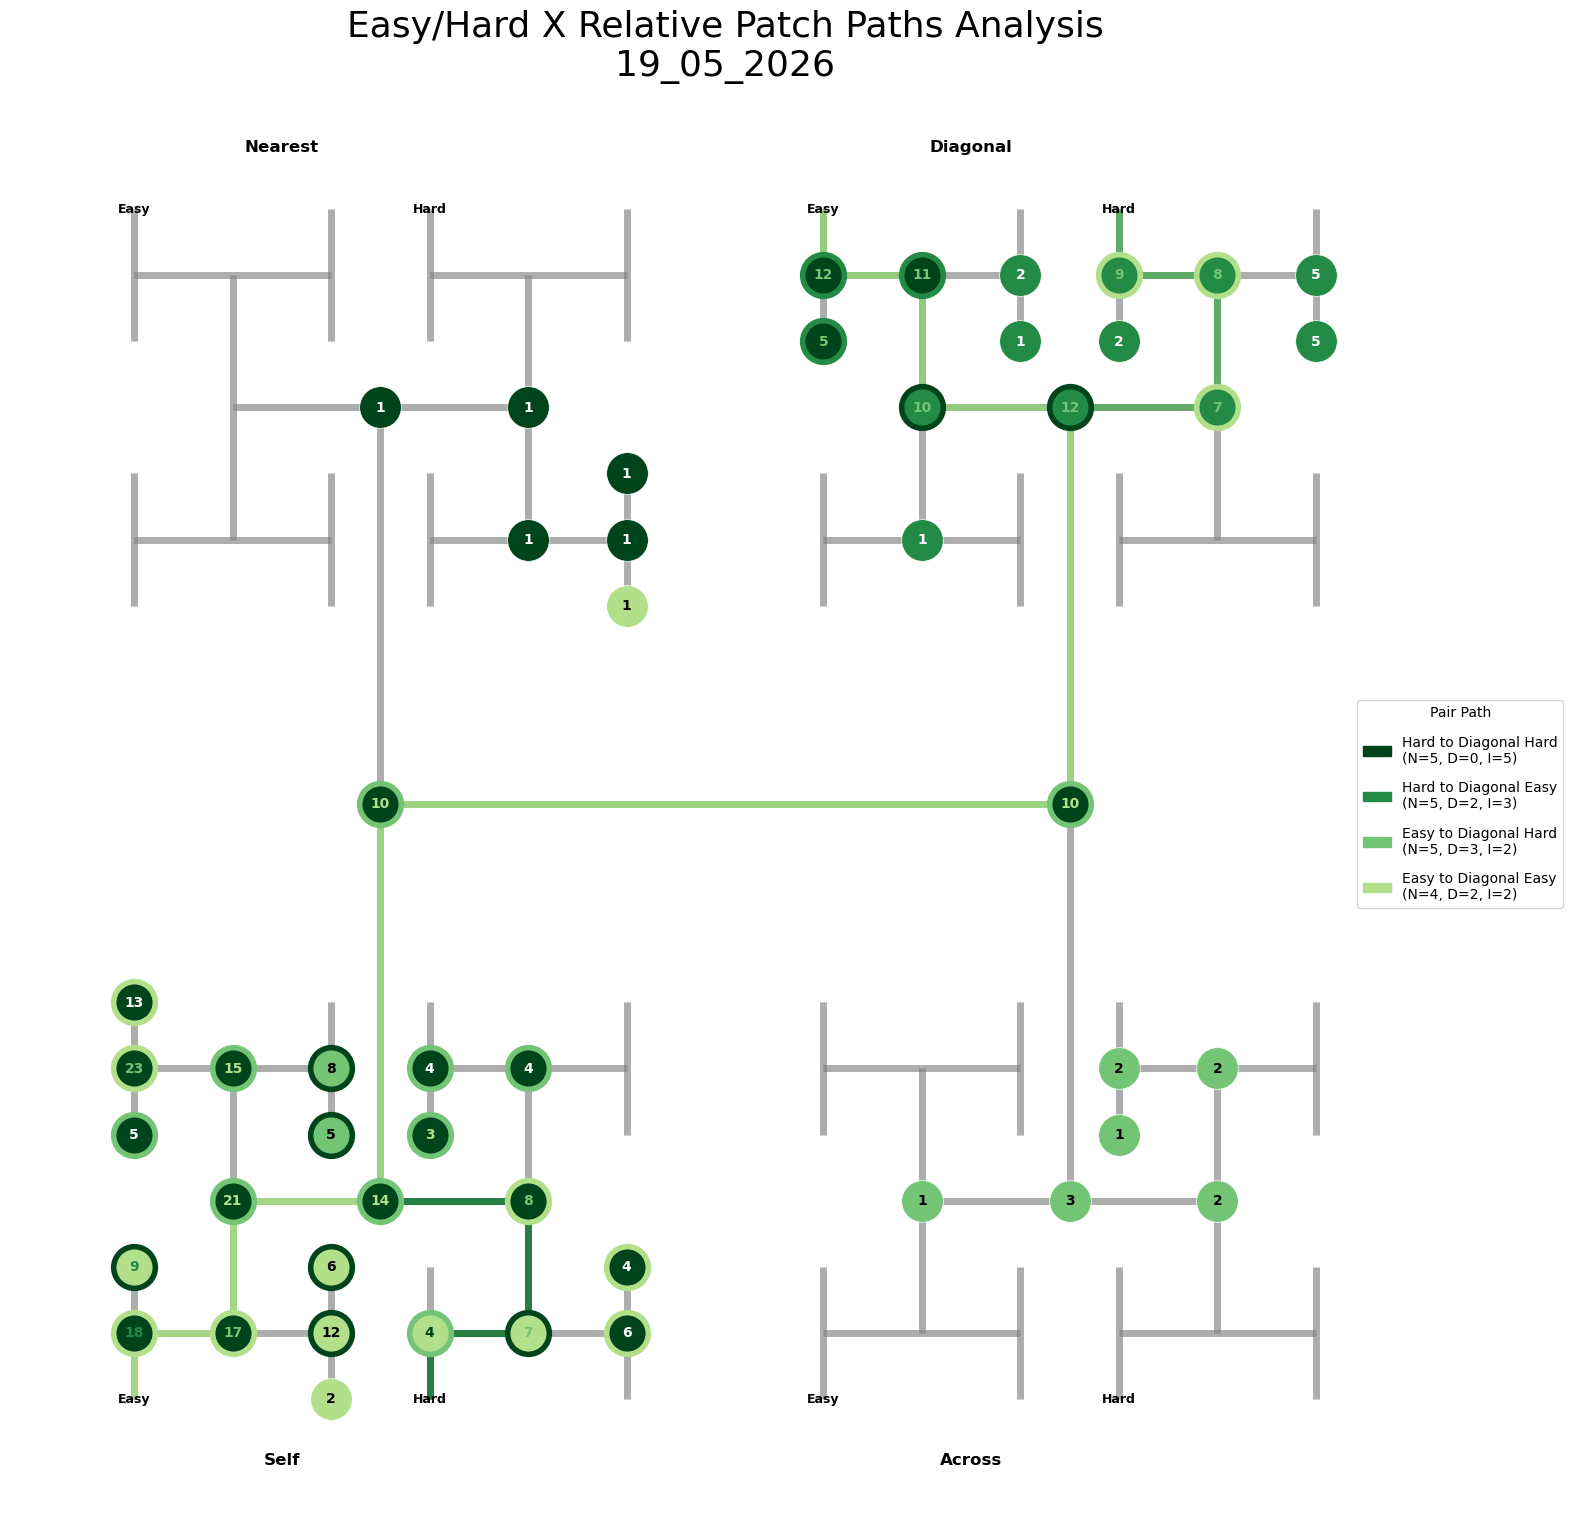

In [2319]:
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Self'], key_to_nodes, node_to_key, port_meta, save_path=ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/relative_patch_paths/Self/{MM_DD_YYYY}_relative_patch_self_paths.png"))
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Nearest'], key_to_nodes, node_to_key, port_meta, save_path=ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/relative_patch_paths/Nearest/{MM_DD_YYYY}_relative_patch_nearest_paths.png"))
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Across'], key_to_nodes, node_to_key, port_meta, save_path=ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/relative_patch_paths/Across/{MM_DD_YYYY}_relative_patch_across_paths.png"))
plot_universal_16_path_projector_complete(G, node_positions, all_paths_without_repeat[all_paths_without_repeat['relationship'] == 'Diagonal'], key_to_nodes, node_to_key, port_meta, save_path=ensure_dir(f"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/relative_patch_paths/Diagonal/{MM_DD_YYYY}_relative_patch_diagonal_paths.png"))

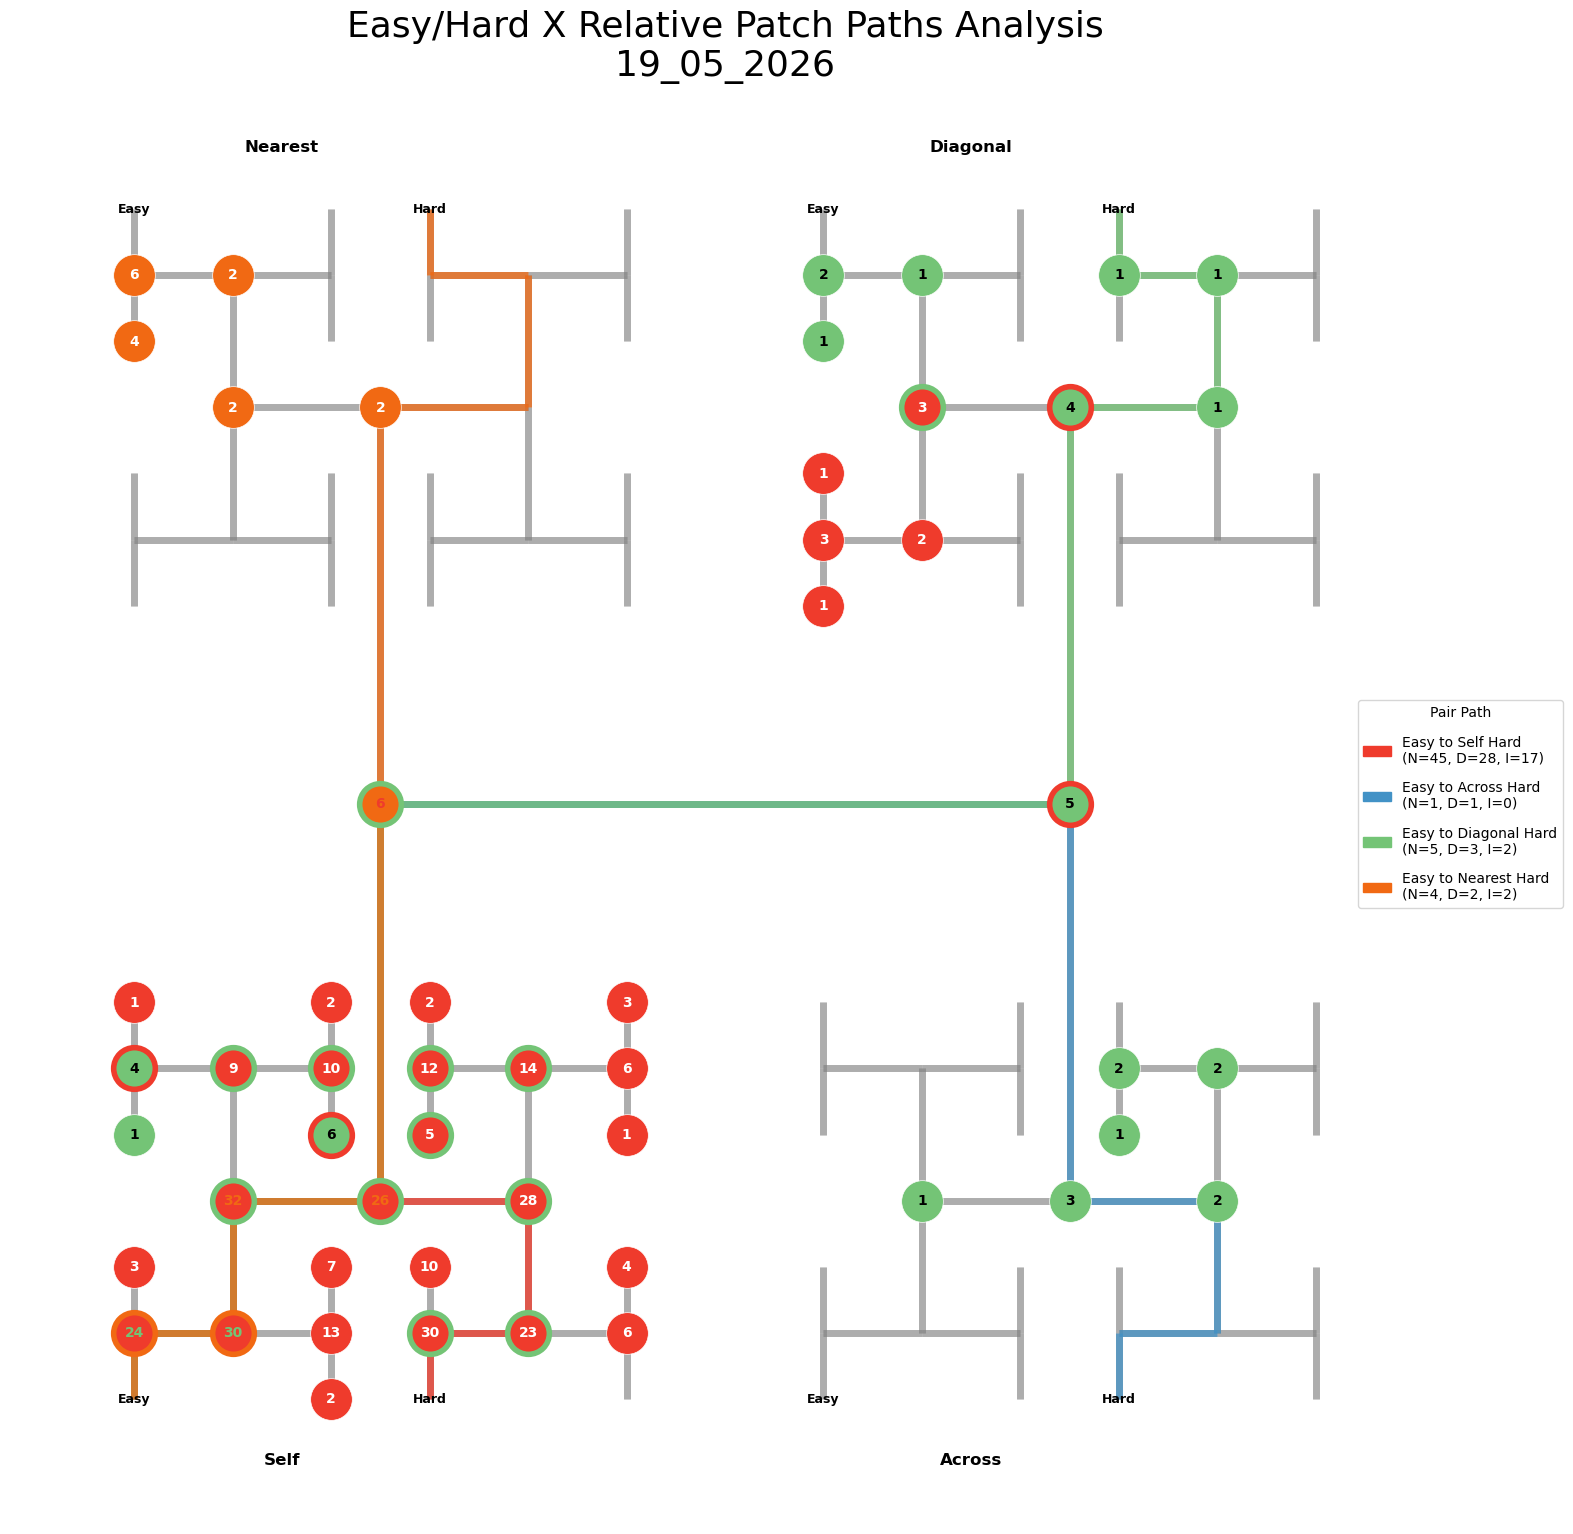

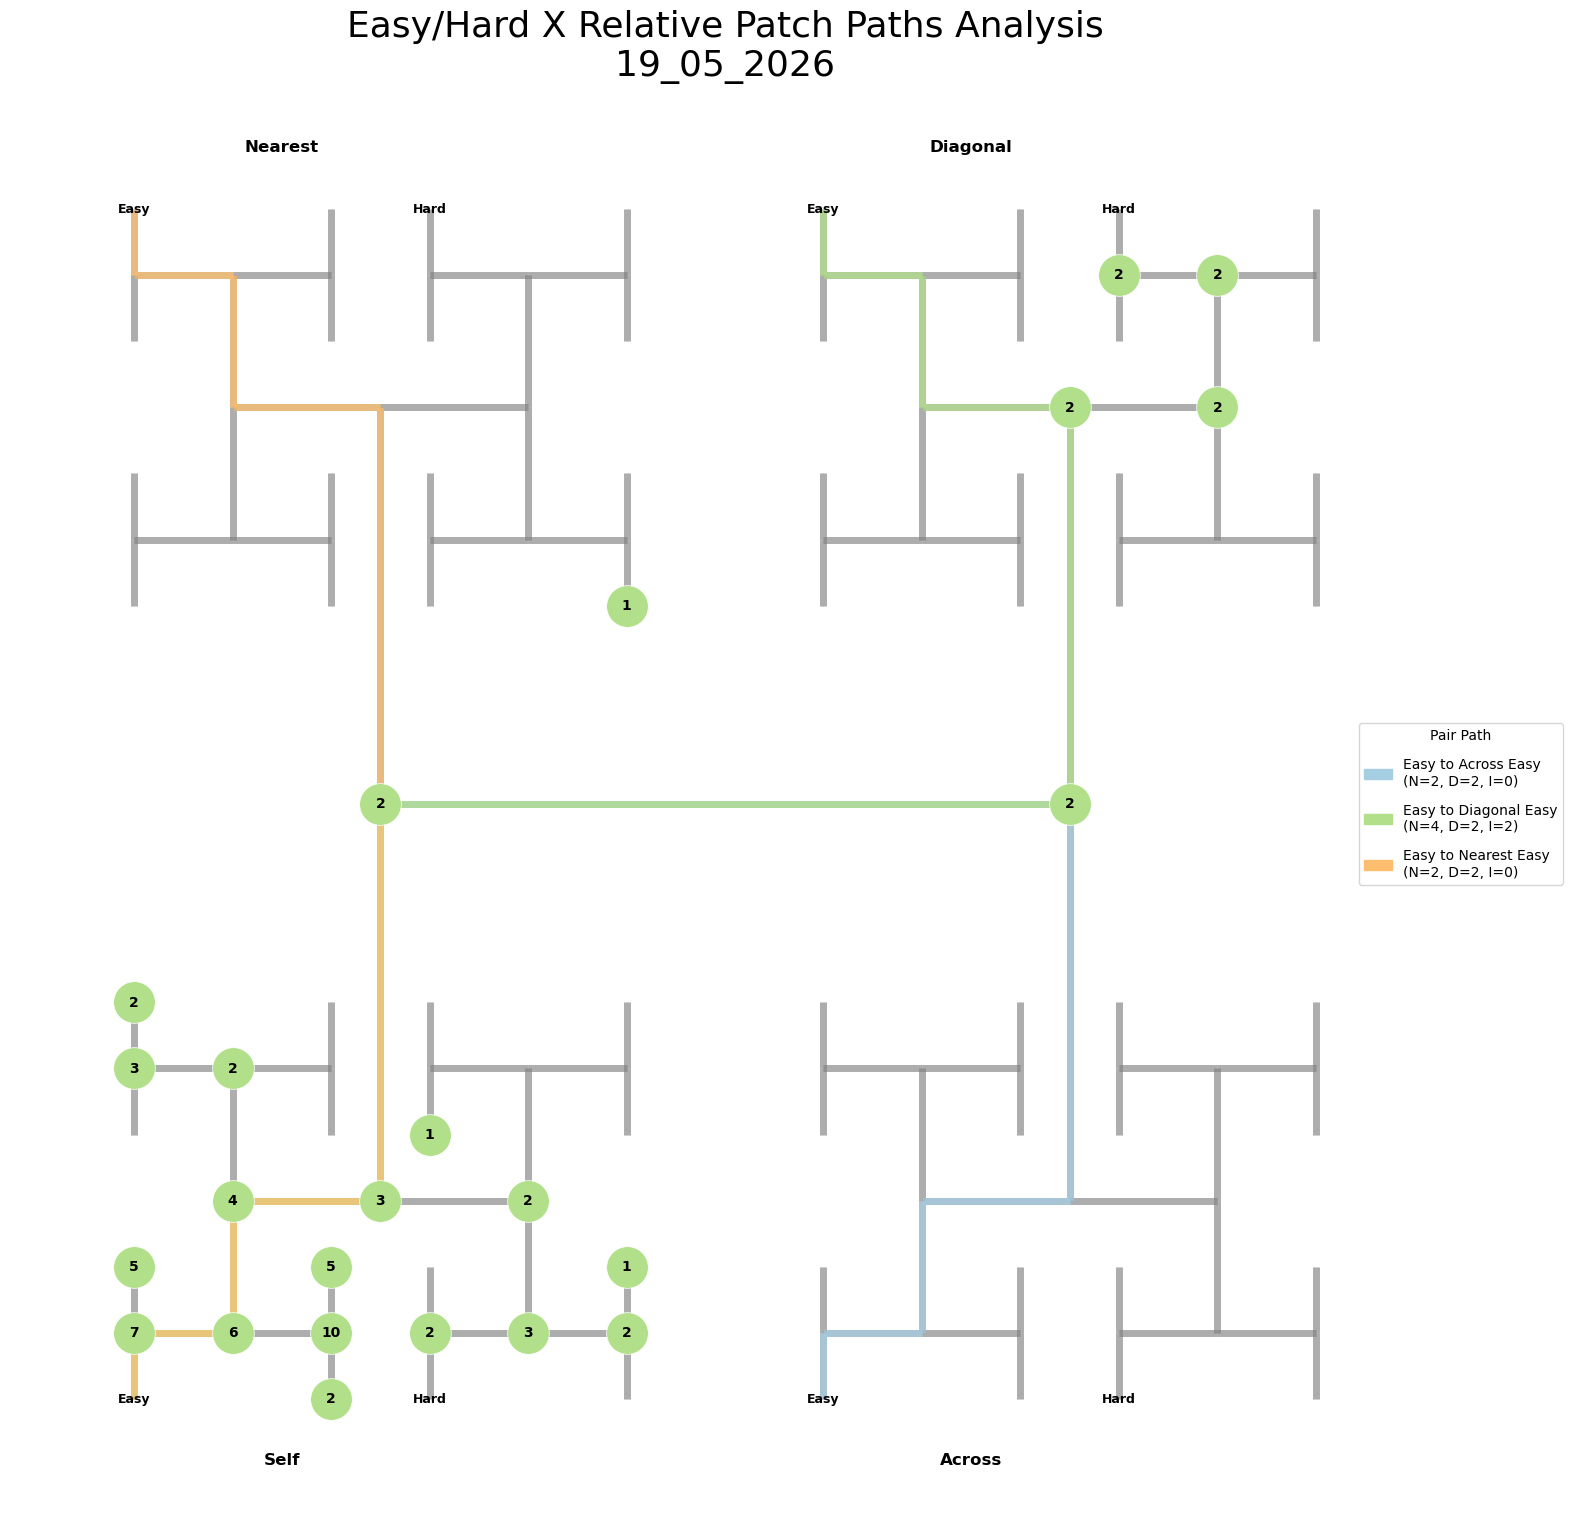

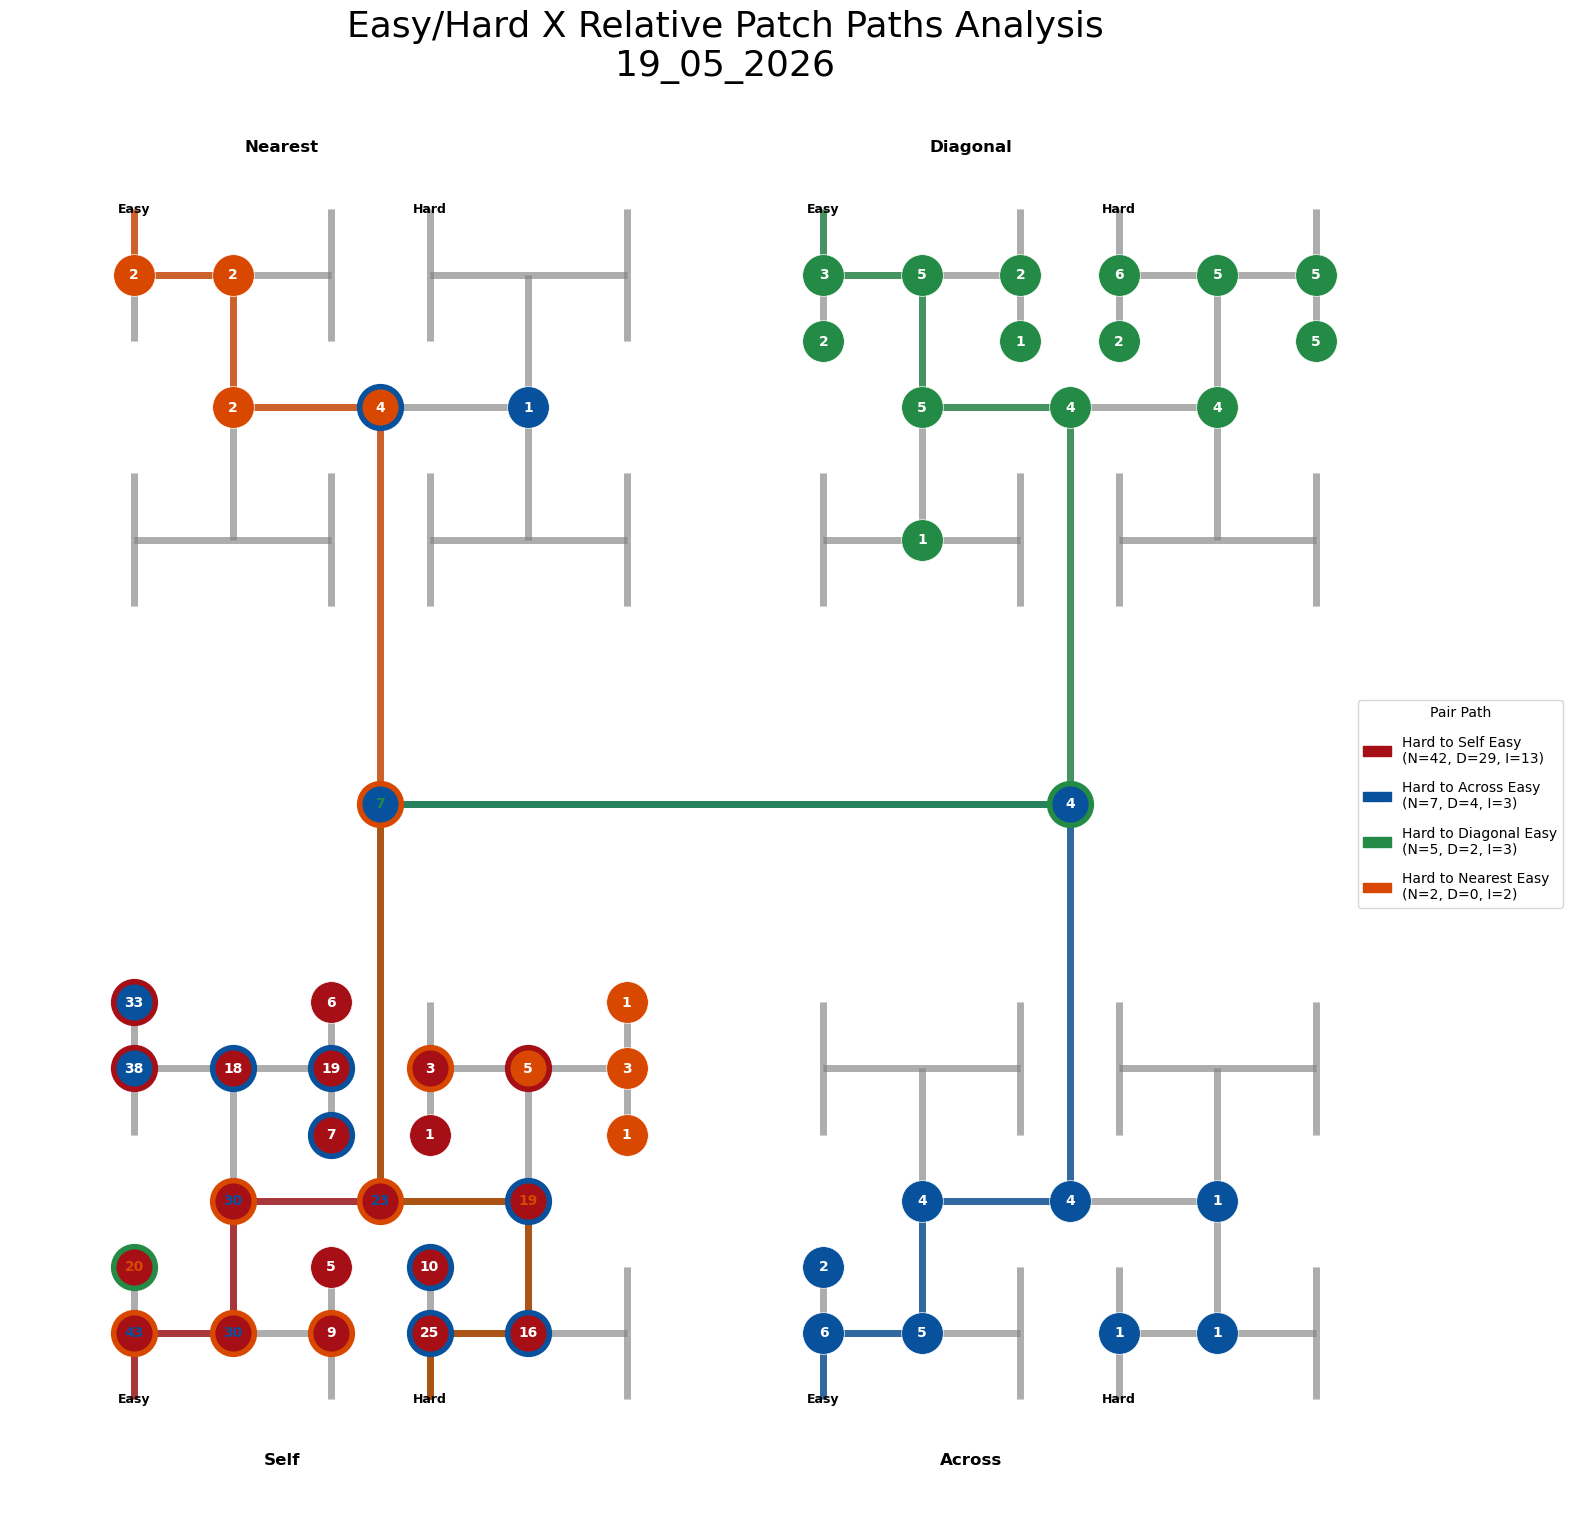

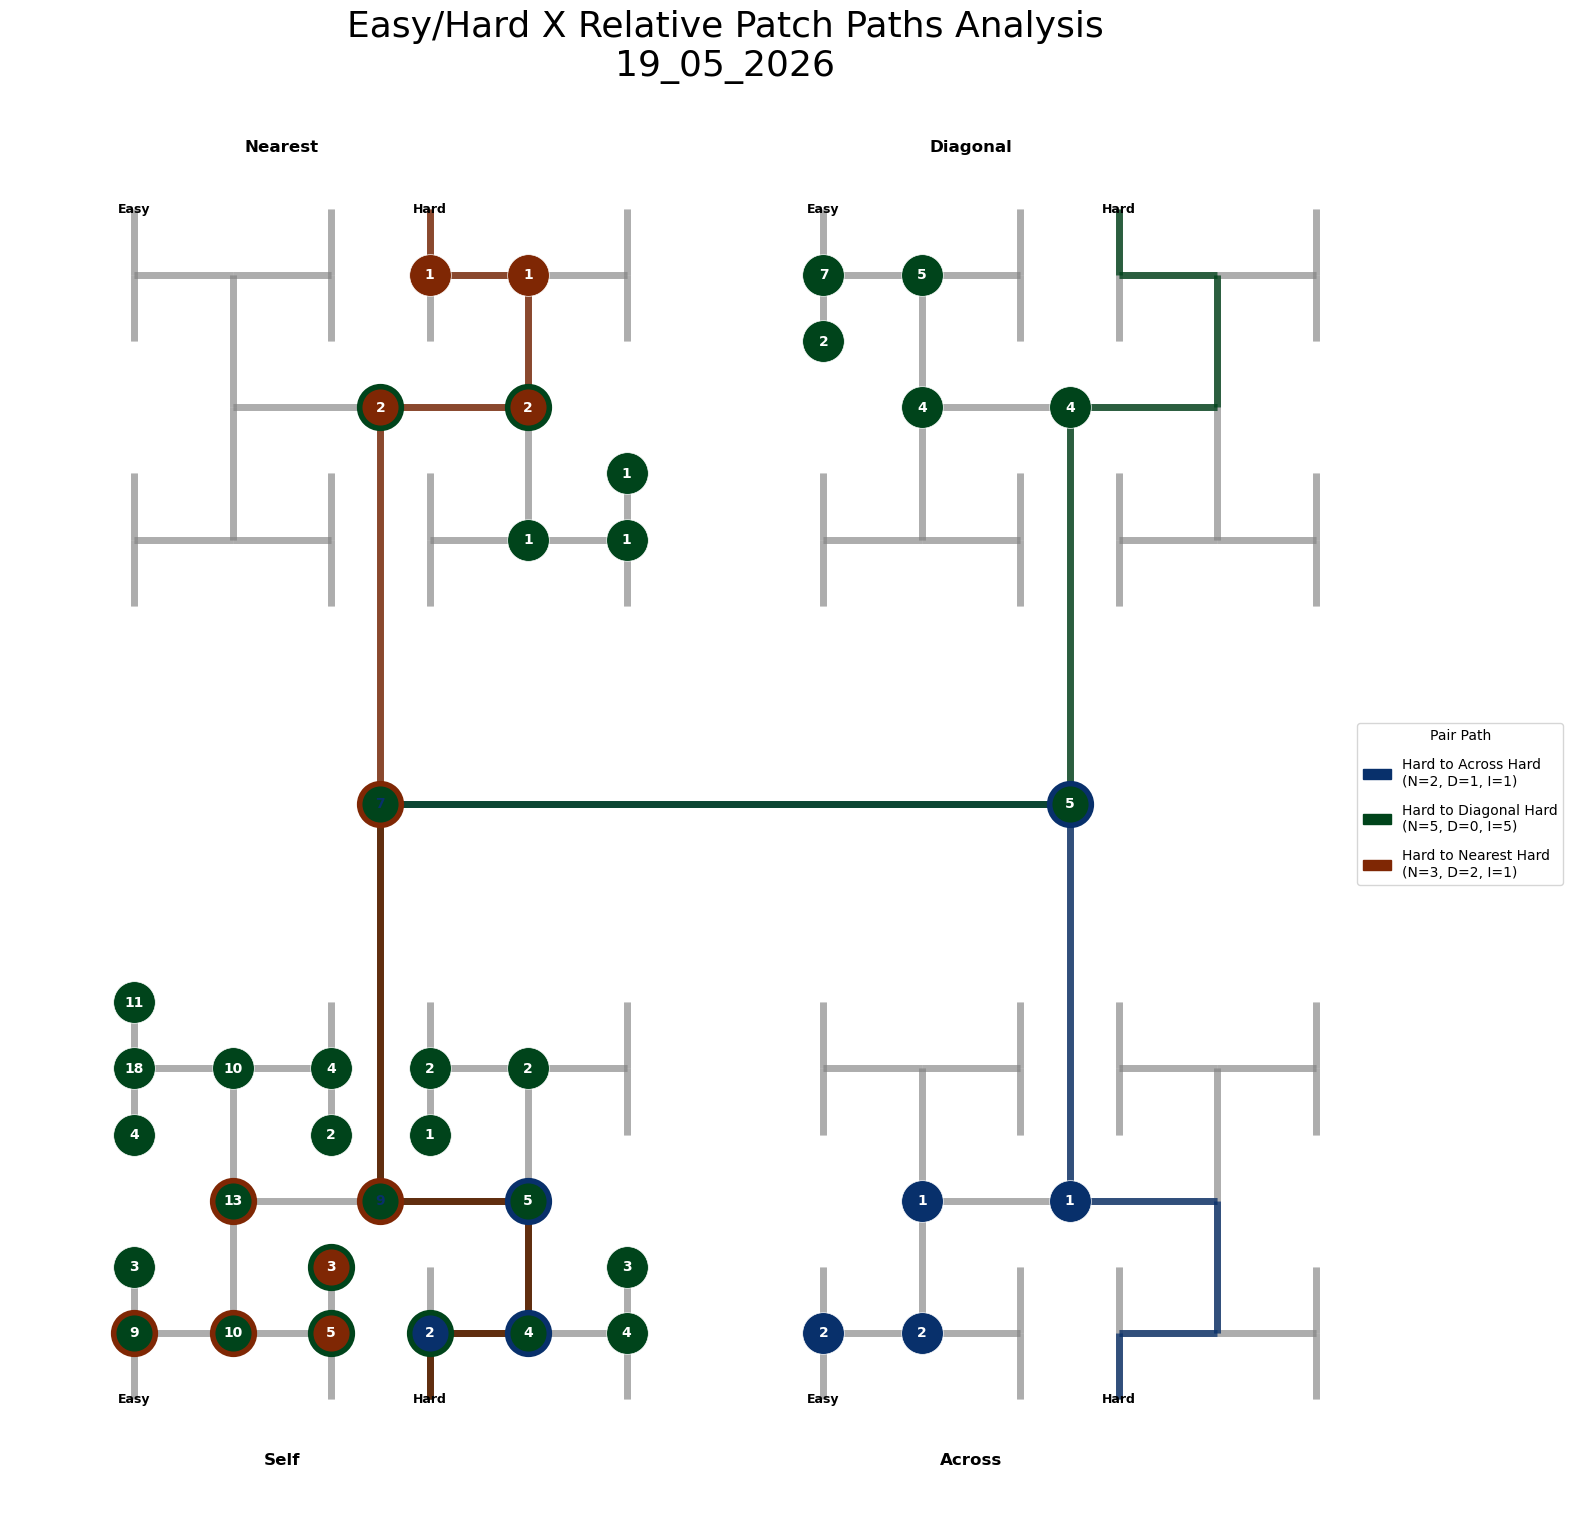

In [2320]:
# all_easy_to_easy = all_paths_without_repeat[(all_paths_without_repeat['group'] == 'Easy to Diagonal Easy') | (all_paths_without_repeat['group'] == 'Easy to Nearest Easy') | (all_paths_without_repeat['group'] == 'Easy to Across Easy')]
# all_easy_to_hard = all_paths_without_repeat[(all_paths_without_repeat['group'] == 'Easy to Diagonal Hard') | (all_paths_without_repeat['group'] == 'Easy to Nearest Hard') | (all_paths_without_repeat['group'] == 'Easy to Across Hard')]

# plot_universal_16_path_projector_complete(G, node_positions, all_easy_to_easy, key_to_nodes, node_to_key, port_meta)
# plot_universal_16_path_projector_complete(G, node_positions, all_easy_to_hard, key_to_nodes, node_to_key, port_meta)

    # 'Hard to Self Hard':   '#67000d', # Deep Burgundy (Darkest)
    # 'Hard to Self Easy':   '#a50f15', # Blood Red
    # 'Easy to Self Hard':   '#ef3b2c', # Bright Red
    # 'Easy to Self Easy':   '#fb9a99', # Soft Coral
color_map_easy_hard = {
    # Hard To Easy (RED)
    'Hard to Self Easy':   '#a50f15', # Blood Red
    'Hard to Across Easy': '#a50f15', # Blood Red
    'Hard to Diagonal Easy':'#a50f15', # Blood Red
    'Hard to Nearest Easy': '#a50f15', # Blood Red
    # Easy To Hard (GREEN)
    'Easy to Self Hard':   '#74c476', # Sage Green
    'Easy to Across Hard': '#74c476', # Sage Green
    'Easy to Diagonal Hard':'#74c476', # Sage Green
    'Easy to Nearest Hard': '#74c476', # Sage Green
    # Easy To Easy (BLUE)
    'Easy to Self Easy': '#a6cee3', # Pale Azure
    'Easy to Across Easy': '#a6cee3', # Pale Azure
    'Easy to Diagonal Easy':'#a6cee3', # Pale Azure
    'Easy to Nearest Easy': '#a6cee3', # Pale Azure
    # Hard To Hard (ORANGE)
    'Hard to Self Hard':   '#ff7f00', # Orange
    'Hard to Across Hard': '#ff7f00', # Orange
    'Hard to Diagonal Hard':'#ff7f00', # Orange
    'Hard to Nearest Hard': '#ff7f00'  # Orange
}


df = all_paths_without_repeat.copy()
df['src_role'] = df['group'].apply(lambda x: x.split(' to ')[0])
df['dest_role'] = df['group'].apply(lambda x: x.split(' ')[-1])
df['role_transition'] = df['src_role'] + " to " + df['dest_role']

# Example: Filter for Easy to Hard transitions
easy_to_hard_df = df[df['role_transition'] == 'Easy to Hard']
easy_to_easy_df = df[df['role_transition'] == 'Easy to Easy']
hard_to_easy_df = df[df['role_transition'] == 'Hard to Easy']
hard_to_hard_df = df[df['role_transition'] == 'Hard to Hard']
plot_universal_16_path_projector_complete(G, node_positions, easy_to_hard_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)
plot_universal_16_path_projector_complete(G, node_positions, easy_to_easy_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)
plot_universal_16_path_projector_complete(G, node_positions, hard_to_easy_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)
plot_universal_16_path_projector_complete(G, node_positions, hard_to_hard_df, key_to_nodes, node_to_key, port_meta, colormap=color_map_easy_hard)

In [2321]:
all_paths_without_repeat

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
0,Target6,Target5,Self,Hard to Self Easy,9,9,9,True,True,True,True,"[L525, L412, L36, L23, L11, L22, L35, L410, L521]"
2,Target5,Target3,Nearest,Easy to Nearest Hard,13,11,11,False,True,True,True,"[L521, L410, L35, L22, L11, L0, L10, L21, L32,..."
3,Target3,Target4,Self,Hard to Self Easy,11,9,9,False,True,True,True,"[L510, L45, L32, L21, L10, L20, L31, L43, L57,..."
7,Target4,Target6,Nearest,Easy to Nearest Hard,11,11,11,True,True,True,True,"[L56, L43, L31, L20, L10, L0, L11, L23, L36, L..."
8,Target6,Target3,Nearest,Hard to Nearest Hard,11,11,11,True,True,True,True,"[L525, L412, L36, L23, L11, L0, L10, L21, L32,..."
...,...,...,...,...,...,...,...,...,...,...,...,...
270,Target1,Target2,Self,Hard to Self Easy,9,9,9,True,True,True,True,"[R522, R411, R35, R22, R11, R23, R36, R413, R526]"
271,Target2,Target8,Nearest,Easy to Nearest Hard,11,11,11,True,True,True,True,"[R526, R413, R36, R23, R11, R0, R10, R20, R31,..."
314,Target8,Target7,Self,Hard to Self Easy,9,9,9,True,True,True,True,"[R55, R42, R31, R20, R10, R21, R32, R44, R59]"
316,Target7,Target8,Self,Easy to Self Hard,19,19,9,False,False,False,False,"[R59, R44, R32, R21, R10, R20, R31, R20, R10, ..."


In [2322]:
# direct_skip = all_paths_without_repeat[all_paths_without_repeat['is_direct_skip_leaves'] == True]
# Get all unique paths in direct_self['path_nodes']
# unique_paths = direct_self['path_nodes'].apply(tuple).unique()
# print(f"Total unique direct self paths: {len(unique_paths)}")
# for path in unique_paths:
#     print(path)
for path in all_paths_without_repeat[all_paths_without_repeat['group'] == 'Easy to Diagonal Hard']['path_nodes']:

    print(path)
all_paths_without_repeat[all_paths_without_repeat['group'] == 'Easy to Diagonal Hard']

['L521', 'L410', 'L35', 'L22', 'L34', 'L49', 'L519', 'L49', 'L34', 'L48', 'L516', 'L48', 'L516', 'L48', 'L516', 'L48', 'L34', 'L22', 'L11', 'L0', 'R0', 'R10', 'R21', 'R33', 'R47', 'R515', 'R47', 'R33', 'R21', 'R10', 'R20', 'R10', 'R0', 'R11', 'R22', 'R35', 'R411', 'R522']
['R59', 'R44', 'R32', 'R21', 'R33', 'R47', 'R515', 'R47', 'R33', 'R21', 'R10', 'R20', 'R31', 'R20', 'R10', 'R0', 'L0', 'L10', 'L21', 'L32', 'L45', 'L511', 'L45', 'L510']
['R59', 'R44', 'R32', 'R21', 'R10', 'R0', 'L0', 'L10', 'L21', 'L32', 'L45', 'L510']
['R59', 'R44', 'R32', 'R21', 'R10', 'R0', 'L0', 'L10', 'L21', 'L32', 'L45', 'L510']
['R59', 'R44', 'R32', 'R21', 'R10', 'R0', 'L0', 'L10', 'L21', 'L32', 'L45', 'L510']


,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
62,Target5,Target1,Diagonal,Easy to Diagonal Hard,38,28,12,False,False,False,False,"[L521, L410, L35, L22, L34, L49, L519, L49, L3..."
139,Target7,Target3,Diagonal,Easy to Diagonal Hard,24,20,12,False,False,False,False,"[R59, R44, R32, R21, R33, R47, R515, R47, R33,..."
180,Target7,Target3,Diagonal,Easy to Diagonal Hard,12,12,12,True,True,True,True,"[R59, R44, R32, R21, R10, R0, L0, L10, L21, L3..."
186,Target7,Target3,Diagonal,Easy to Diagonal Hard,12,12,12,True,True,True,True,"[R59, R44, R32, R21, R10, R0, L0, L10, L21, L3..."
259,Target7,Target3,Diagonal,Easy to Diagonal Hard,12,12,12,True,True,True,True,"[R59, R44, R32, R21, R10, R0, L0, L10, L21, L3..."


In [2323]:
all_paths_without_repeat[(all_paths_without_repeat['relationship'] == 'Nearest') & (all_paths_without_repeat['group'] == 'Easy to Nearest Hard')]

,source_port,dest_port,relationship,group,actual_length,filtered_length,shortest_dist,is_direct,is_direct_tol2,is_direct_tol4,is_direct_skip_leaves,path_nodes
2,Target5,Target3,Nearest,Easy to Nearest Hard,13,11,11,False,True,True,True,"[L521, L410, L35, L22, L11, L0, L10, L21, L32,..."
7,Target4,Target6,Nearest,Easy to Nearest Hard,11,11,11,True,True,True,True,"[L56, L43, L31, L20, L10, L0, L11, L23, L36, L..."
131,Target2,Target8,Nearest,Easy to Nearest Hard,17,11,11,False,False,False,True,"[R526, R413, R36, R23, R11, R0, R10, R20, R31,..."
271,Target2,Target8,Nearest,Easy to Nearest Hard,11,11,11,True,True,True,True,"[R526, R413, R36, R23, R11, R0, R10, R20, R31,..."


In [2324]:
df_all_paths[158:159]['path_nodes']

158    [R59, R44, R59]
Name: path_nodes, dtype: object

In [2325]:
def analyze_reward_by_group_comprehensive(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Label Transitions by Group (same logic as before)
    primary_labels = [f"{port_map[a]} <-> {port_map[b]}" for a, b in primary_pairs]
    remaining_labels = [f"{port_map[a]} <-> {port_map[b]}" for a, b in remaining_pairs]
    
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['current_port_label'] = port_visits['node_name'].map(port_map)
    port_visits['prev_port_label'] = port_visits['current_port_label'].shift(1)
    
    def get_group(row):
        pair = f"{row['prev_port_label']} <-> {row['current_port_label']}"
        rev_pair = f"{row['current_port_label']} <-> {row['prev_port_label']}"
        if pair in primary_labels or rev_pair in primary_labels:
            return 'Primary Patches'
        if pair in remaining_labels or rev_pair in remaining_labels:
            return 'Remaining Pairs'
        return 'Other'

    port_visits['group'] = port_visits.apply(get_group, axis=1)
    
    # Define "Size Reward" based on the float column
    port_visits['has_size_reward'] = port_visits['reward_size_during_node'] > 0
    
    # 2. Multi-column Aggregation
    # We group by the Pair Group and then pivot both the Boolean and the Size columns
    summary = port_visits[port_visits['group'] != 'Other'].groupby('group').agg(
        Boolean_Rewarded=('reward_during_node', 'sum'),
        Boolean_Not_Rewarded=('reward_during_node', lambda x: (x == False).sum()),
        Size_Rewarded=('has_size_reward', 'sum'),
        Size_Not_Rewarded=('has_size_reward', lambda x: (x == False).sum()),
        Total_Visits=('group', 'count')
    )

    # 3. Calculate "Ghost Rewards" (Boolean is True, but Size is 0)
    summary['Ghost_Rewards'] = summary['Boolean_Rewarded'] - summary['Size_Rewarded']
    summary['Ghost_Reward_%'] = (summary['Ghost_Rewards'] / summary['Total_Visits']) * 100

    return summary

# Execute
reward_summary_complex = analyze_reward_by_group_comprehensive(
    node_summary_df, pairs_to_check, remaining_pairs, port_map
)
print(reward_summary_complex)

                 Boolean_Rewarded  Boolean_Not_Rewarded  Size_Rewarded  \
group                                                                    
Primary Patches                33                    54             35   
Remaining Pairs                20                    22              9   

                 Size_Not_Rewarded  Total_Visits  Ghost_Rewards  \
group                                                             
Primary Patches                 52            87             -2   
Remaining Pairs                 33            42             11   

                 Ghost_Reward_%  
group                            
Primary Patches       -2.298851  
Remaining Pairs       26.190476  


/tmp/ipykernel_827484/1818114807.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Ghost_Reward_%'], palette='Reds', ax=axes[1, 1])


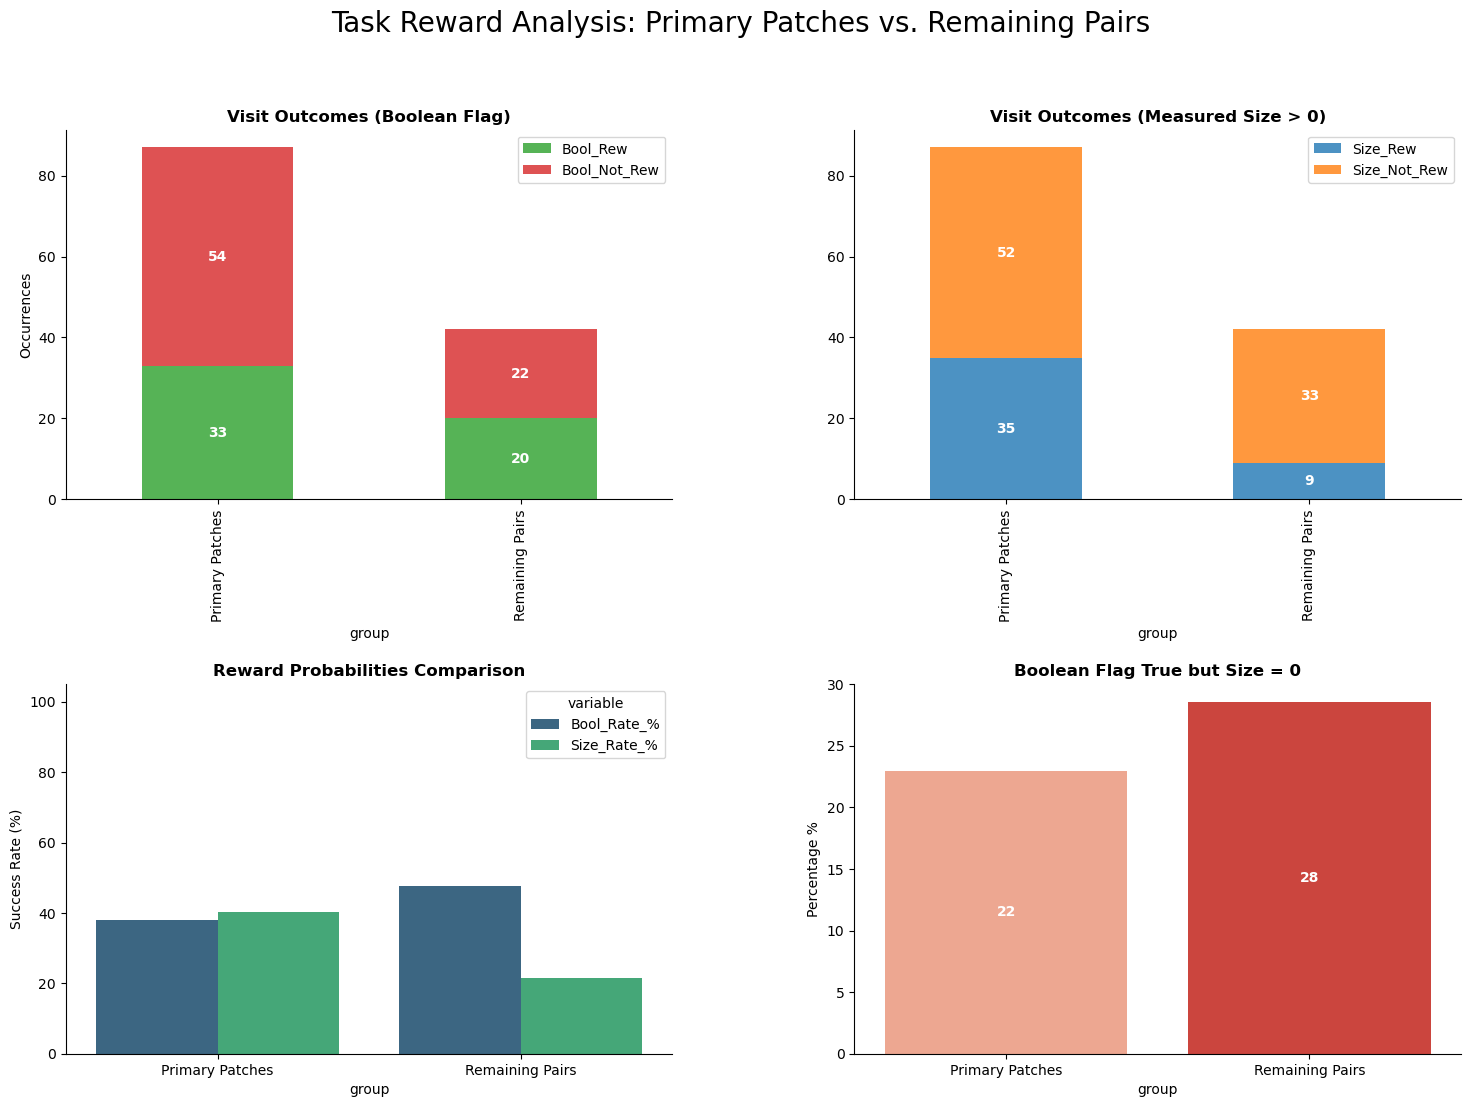

In [2326]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_and_plot_reward_groups(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Group Transitions
    primary_labels = {tuple(sorted((p1, p2))) for p1, p2 in primary_pairs}
    remaining_labels = {tuple(sorted((p1, p2))) for p1, p2 in remaining_pairs}
    
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['prev_port_node'] = port_visits['node_name'].shift(1)
    
    def get_group(row):
        if pd.isna(row['prev_port_node']): return None
        pair = tuple(sorted((row['prev_port_node'], row['node_name'])))
        if pair in primary_labels: return 'Primary Patches'
        if pair in remaining_labels: return 'Remaining Pairs'
        return 'Other'

    port_visits['group'] = port_visits.apply(get_group, axis=1)
    port_visits['has_size_reward'] = port_visits['reward_size_during_node'] > 0
    
    # Filter for target groups
    valid_df = port_visits[port_visits['group'].isin(['Primary Patches', 'Remaining Pairs'])].copy()
    
    # 2. Comprehensive Aggregation
    summary = valid_df.groupby('group').agg(
        Total_Visits=('group', 'count'),
        Bool_Rew=('reward_during_node', 'sum'),
        Size_Rew=('has_size_reward', 'sum')
    )
    
    # Calculate Ratios and Percentages
    summary['Bool_Not_Rew'] = summary['Total_Visits'] - summary['Bool_Rew']
    summary['Size_Not_Rew'] = summary['Total_Visits'] - summary['Size_Rew']
    summary['Bool_Rate_%'] = (summary['Bool_Rew'] / summary['Total_Visits']) * 100
    summary['Size_Rate_%'] = (summary['Size_Rew'] / summary['Total_Visits']) * 100
    
    # Quantify Inconsistencies (Flag is True, but Size is 0)
    ghost_mask = (valid_df['reward_during_node'] == True) & (valid_df['has_size_reward'] == False)
    summary['Ghost_Rewards'] = valid_df[ghost_mask].groupby('group').size().reindex(summary.index, fill_value=0)
    summary['Ghost_Reward_%'] = (summary['Ghost_Rewards'] / summary['Total_Visits']) * 100

    # 3. Multi-Panel Visualization
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    plt.subplots_adjust(hspace=0.5, wspace=0.3)
    
    # Panel 1: Counts (Boolean Metric)
    summary[['Bool_Rew', 'Bool_Not_Rew']].plot(
        kind='bar', stacked=True, color=['#2ca02c', '#d62728'], alpha=0.8, ax=axes[0, 0]
    )
    axes[0, 0].set_title("Visit Outcomes (Boolean Flag)", fontweight='bold')
    axes[0, 0].set_ylabel("Occurrences")
    
    # Panel 2: Counts (Size Metric)
    summary[['Size_Rew', 'Size_Not_Rew']].plot(
        kind='bar', stacked=True, color=['#1f77b4', '#ff7f0e'], alpha=0.8, ax=axes[0, 1]
    )
    axes[0, 1].set_title("Visit Outcomes (Measured Size > 0)", fontweight='bold')
    
    # Panel 3: Reward Rate Comparison (%)
    rates_melted = summary[['Bool_Rate_%', 'Size_Rate_%']].reset_index().melt(id_vars='group')
    sns.barplot(data=rates_melted, x='group', y='value', hue='variable', palette='viridis', ax=axes[1, 0])
    axes[1, 0].set_title("Reward Probabilities Comparison", fontweight='bold')
    axes[1, 0].set_ylabel("Success Rate (%)")
    axes[1, 0].set_ylim(0, 105)
    
    # Panel 4: System Discrepancies (The "Ghost" Rewards)
    sns.barplot(x=summary.index, y=summary['Ghost_Reward_%'], palette='Reds', ax=axes[1, 1])
    axes[1, 1].set_title("Boolean Flag True but Size = 0", fontweight='bold')
    axes[1, 1].set_ylabel("Percentage %")

    # Annotate absolute values on the bars
    for ax in [axes[0, 0], axes[0, 1], axes[1, 1]]:
        for p in ax.patches:
            if p.get_height() > 0:
                ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_y() + p.get_height()/2), 
                            ha='center', va='center', color='white', fontweight='bold')

    plt.suptitle("Task Reward Analysis: Primary Patches vs. Remaining Pairs", fontsize=20, y=0.98)
    sns.despine()
    plt.show()
    
    return summary

summary_stats = analyze_and_plot_reward_groups(node_summary_df, pairs_to_check, remaining_pairs, port_map)

/tmp/ipykernel_827484/891637025.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary.index, y=summary['Water_Yield_Rate_%'], palette='viridis', ax=axes[1])


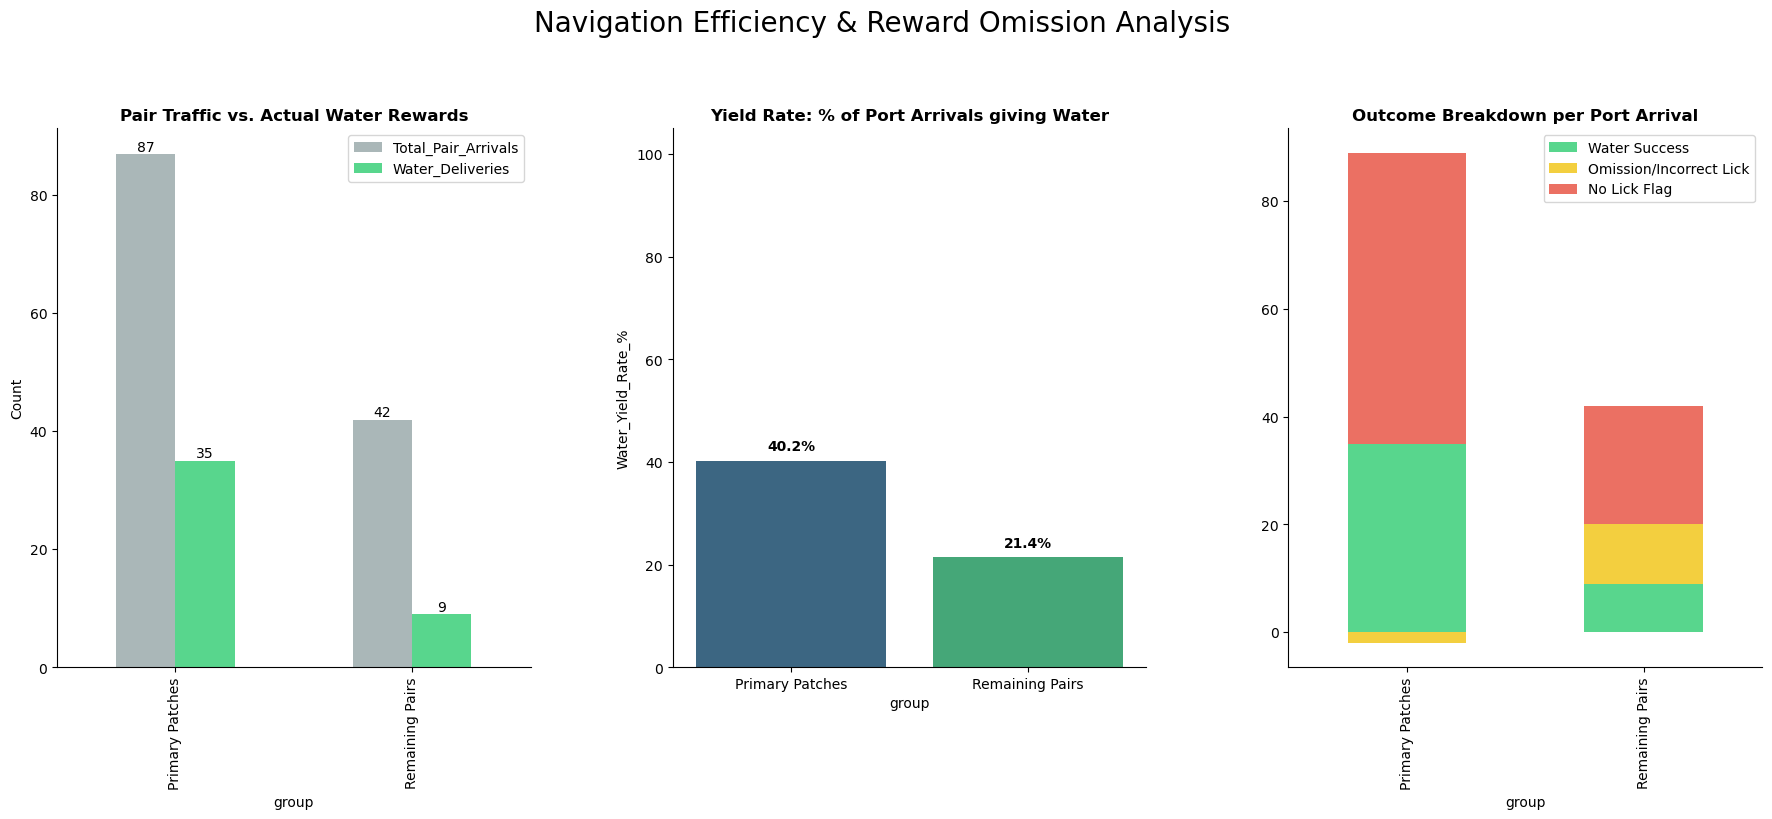

In [2327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_reward_efficiency_analysis(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Label Groups
    primary_labels = {tuple(sorted((p1, p2))) for p1, p2 in primary_pairs}
    remaining_labels = {tuple(sorted((p1, p2))) for p1, p2 in remaining_pairs}
    
    port_visits = df_clean[df_clean['is_port_node'] == True].copy()
    port_visits['prev_port_node'] = port_visits['node_name'].shift(1)
    
    def get_group(row):
        if pd.isna(row['prev_port_node']): return None
        pair = tuple(sorted((row['prev_port_node'], row['node_name'])))
        if pair in primary_labels: return 'Primary Patches'
        if pair in remaining_labels: return 'Remaining Pairs'
        return 'Other'

    port_visits['group'] = port_visits.apply(get_group, axis=1)
    port_visits['has_size_reward'] = port_visits['reward_size_during_node'] > 0
    
    # 2. Grouped Aggregation
    # Total_Visits = Every time a port was entered as part of a pair sequence
    # Bool_Rew = Every time a lick/flag was recorded (even if no water)
    # Size_Rew = Every time water was actually delivered
    summary = port_visits[port_visits['group'].isin(['Primary Patches', 'Remaining Pairs'])].groupby('group').agg(
        Total_Pair_Arrivals=('group', 'count'),
        Lick_Flags=('reward_during_node', 'sum'),
        Water_Deliveries=('has_size_reward', 'sum')
    )
    
    # 3. Calculation of "Failed" visits
    # Omissions = System flagged True (lick/rule start) but no water (probability/rule end)
    summary['Omission_or_Error'] = summary['Lick_Flags'] - summary['Water_Deliveries']
    
    # Efficiency: Water delivered / Total times a port was entered in this group
    summary['Water_Yield_Rate_%'] = (summary['Water_Deliveries'] / summary['Total_Pair_Arrivals']) * 100
    
    # Lick Success Rate: If they licked, how often did they actually get water?
    summary['Lick_Success_Rate_%'] = (summary['Water_Deliveries'] / summary['Lick_Flags']) * 100

    # 4. Visualization
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    plt.subplots_adjust(wspace=0.3)
    
    # Plot 1: Total Traffic vs Water Success
    # Shows the raw "denominator" of how many times they visited these ports
    summary[['Total_Pair_Arrivals', 'Water_Deliveries']].plot(kind='bar', ax=axes[0], color=['#95a5a6', '#2ecc71'], alpha=0.8)
    axes[0].set_title("Pair Traffic vs. Actual Water Rewards", fontweight='bold')
    axes[0].set_ylabel("Count")
    for p in axes[0].patches:
        axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()), ha='center', va='bottom')

    # Plot 2: Yield Rate (Water / Total Visits)
    # This is your "Efficiency" metric
    sns.barplot(x=summary.index, y=summary['Water_Yield_Rate_%'], palette='viridis', ax=axes[1])
    axes[1].set_title("Yield Rate: % of Port Arrivals giving Water", fontweight='bold')
    axes[1].set_ylim(0, 105)
    for i, v in enumerate(summary['Water_Yield_Rate_%']):
        axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    # Plot 3: Why visits failed (The "Ghost" logic redefined)
    # Breakdown of visits into: Water, Omission/Error, and Pure Dry Visits
    failure_data = summary.copy()
    failure_data['Dry_Visits'] = failure_data['Total_Pair_Arrivals'] - failure_data['Lick_Flags']
    failure_data[['Water_Deliveries', 'Omission_or_Error', 'Dry_Visits']].plot(
        kind='bar', stacked=True, ax=axes[2], color=['#2ecc71', '#f1c40f', '#e74c3c'], alpha=0.8
    )
    axes[2].set_title("Outcome Breakdown per Port Arrival", fontweight='bold')
    axes[2].legend(['Water Success', 'Omission/Incorrect Lick', 'No Lick Flag'])

    plt.suptitle("Navigation Efficiency & Reward Omission Analysis", fontsize=20, y=1.05)
    sns.despine()
    plt.show()
    
    return summary

summary_stats = plot_reward_efficiency_analysis(node_summary_df, pairs_to_check, remaining_pairs, port_map)

/tmp/ipykernel_827484/1594069928.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=efficiency_stats.index, y=efficiency_stats['Success_Rate_%'], palette='viridis', ax=axes[1])


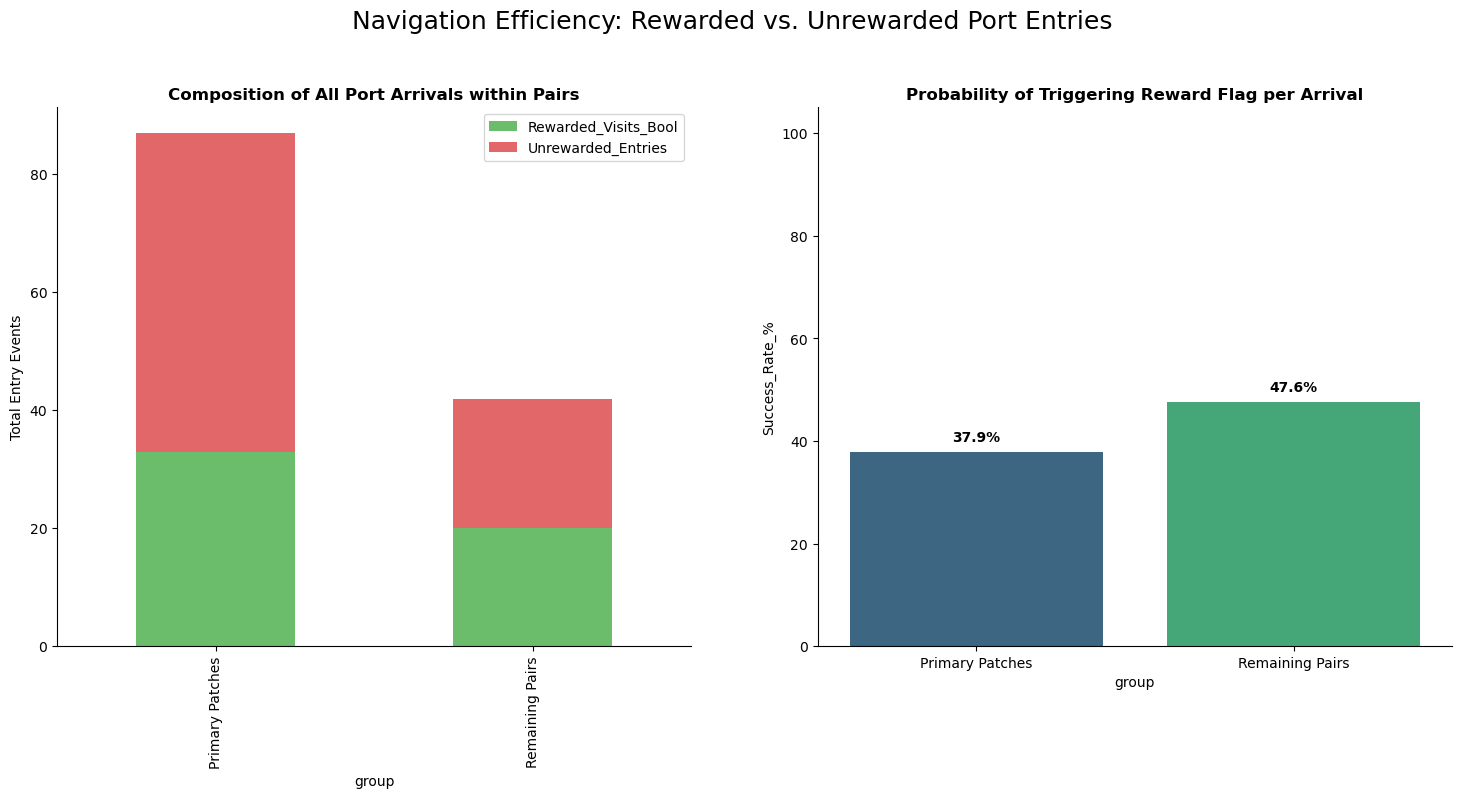

In [2328]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def analyze_true_visit_efficiency(df_clean, primary_pairs, remaining_pairs, port_map):
    # 1. Map Pairs
    primary_labels = {tuple(sorted((p1, p2))) for p1, p2 in primary_pairs}
    remaining_labels = {tuple(sorted((p1, p2))) for p1, p2 in remaining_pairs}
    
    # 2. Extract ALL Port Activity
    # We look at every single row where is_port_node is True
    port_activity = df_clean[df_clean['is_port_node'] == True].copy()
    
    # Identify the sequence/pair context for every port arrival
    port_activity['prev_port_node'] = port_activity['node_name'].shift(1)
    
    def get_group(row):
        if pd.isna(row['prev_port_node']): return None
        pair = tuple(sorted((row['prev_port_node'], row['node_name'])))
        if pair in primary_labels: return 'Primary Patches'
        if pair in remaining_labels: return 'Remaining Pairs'
        return 'Other'

    port_activity['group'] = port_activity.apply(get_group, axis=1)
    
    # 3. Quantify Rewarded vs. Unrewarded
    # We group by the Pair Group and count the outcomes of the Boolean Flag
    # This captures the "Empty Visits" (False) that were previously ignored
    efficiency_stats = port_activity[port_activity['group'].isin(['Primary Patches', 'Remaining Pairs'])].groupby('group').agg(
        Total_Port_Entries=('reward_during_node', 'count'), # The true denominator
        Rewarded_Visits_Bool=('reward_during_node', 'sum'), # True cases
        Actual_Water_Delivered=('reward_size_during_node', lambda x: (x > 0).sum()) # Size > 0
    )
    
    # Calculate derived metrics
    efficiency_stats['Unrewarded_Entries'] = efficiency_stats['Total_Port_Entries'] - efficiency_stats['Rewarded_Visits_Bool']
    efficiency_stats['Success_Rate_%'] = (efficiency_stats['Rewarded_Visits_Bool'] / efficiency_stats['Total_Port_Entries']) * 100
    
    # Check for your "Ghost Rewards" (True flag, but 0 size) within this larger context
    efficiency_stats['Omissions_or_Errors'] = efficiency_stats['Rewarded_Visits_Bool'] - efficiency_stats['Actual_Water_Delivered']

    # 4. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    
    # Plot 1: Stacked Composition of All Visits
    # This shows the "Dry" visits (False) vs "Flagged" visits (True)
    efficiency_stats[['Rewarded_Visits_Bool', 'Unrewarded_Entries']].plot(
        kind='bar', stacked=True, color=['#2ca02c', '#d62728'], alpha=0.7, ax=axes[0]
    )
    axes[0].set_title("Composition of All Port Arrivals within Pairs", fontweight='bold')
    axes[0].set_ylabel("Total Entry Events")
    
    # Plot 2: True Probability of Reward
    sns.barplot(x=efficiency_stats.index, y=efficiency_stats['Success_Rate_%'], palette='viridis', ax=axes[1])
    axes[1].set_title("Probability of Triggering Reward Flag per Arrival", fontweight='bold')
    axes[1].set_ylim(0, 105)
    
    for i, v in enumerate(efficiency_stats['Success_Rate_%']):
        axes[1].text(i, v + 2, f'{v:.1f}%', ha='center', fontweight='bold')

    plt.suptitle("Navigation Efficiency: Rewarded vs. Unrewarded Port Entries", fontsize=18, y=1.02)
    sns.despine()
    plt.show()
    
    return efficiency_stats

stats = analyze_true_visit_efficiency(node_summary_df, pairs_to_check, remaining_pairs, port_map)

In [2329]:
# count how many rows in node_summary_df have is_port_node == True
num_port_nodes = node_summary_df[node_summary_df['is_port_node'] == True].shape[0]
# count haw many rows in node_summary_df have reward_during_node == True
num_rewarded_ports = node_summary_df[node_summary_df['reward_during_node'] == True].shape[0]
# count how many rows in node_summary_df have reward_size_during_node > 0
num_size_rewarded_ports = node_summary_df[node_summary_df['reward_size_during_node'] > 0].shape[0]

num_port_nodes, num_rewarded_ports, num_size_rewarded_ports

(320, 90, 63)

In [2330]:
# # Extract short trial videos for inspection
# from pathlib import Path
# import os
# import cv2
# import numpy as np
# import pandas as pd

# # How many examples per class
# N = 20
# # Path to the maze video used by this notebook
# maze_video = globals().get('maze_video_path', None)
# out_dir = Path(f'/var/home/almogmeir/Documents/M.Sc/Project/trial_video_previews/{MM}_{DD}_{YYYY}/')
# out_dir.mkdir(parents=True, exist_ok=True)

# Use the annotated reward dataframe available in the kernel
df = reward_df.copy()

# Find a start-frame column (several common names tried)
start_col = None
for c in ['reward_port_transition_start_frame']:
    if c in df.columns:
        start_col = c
        break
if start_col is None:
    raise ValueError('No start-frame column found in reward_df. Expected one of reward_port_transition_start_frame, reward_port_transition_start, start_frame, start_frame_in_trial')

# Try to detect a direct/indirect indicator column
raw_direct_col = None
for c in ['reward_port_transition_type_chain']:
    if c in df.columns:
        raw_direct_col = c
        break
if raw_direct_col is None:
    # try scanning object columns for the words 'direct'/'indirect' (to find the column name only)
    for c in df.columns:
        if df[c].dtype == object and df[c].astype(str).str.contains('direct|indirect', case=False, na=False).any():
            raw_direct_col = c
            break

# Create a normalized label column with categories: 'direct', 'indirect', 'other', None
_dir_label = pd.Series([None] * len(df), index=df.index)
if raw_direct_col is None:
    print('Warning: could not detect a direct/indirect column — all labels will be None')
else:
    # exact match: strip + lower and compare equality to 'direct' or 'indirect'
    for i, val in df[raw_direct_col].items():
        if pd.isna(val):
            _dir_label.iloc[i] = None
            continue
        v = str(val).strip().lower()
        if v == 'direct':
            _dir_label.iloc[i] = 'direct'
        elif v == 'indirect':
            _dir_label.iloc[i] = 'indirect'
        else:
            # any other non-NaN value (including combined strings) -> 'other'
            _dir_label.iloc[i] = 'other'

# attach normalized label
df['_dir_label'] = _dir_label

# Ensure integer frame columns, handling NaN start frames
# convert start column to numeric, coercing non-numeric/NaN to np.nan
df['_start_frame'] = pd.to_numeric(df[start_col], errors='coerce')

# Compute end-frame as next valid start_frame - 1 (or add a short window for the final valid row)
end_frames = []
fps_guess = int(globals().get('FPS', 30))
for i in range(len(df)):
    s_val = df.loc[i, '_start_frame']
    if pd.isna(s_val):
        end_frames.append(np.nan)
        continue
    s = int(s_val)
    # find next non-NaN start frame after i
    next_vals = df['_start_frame'].iloc[i+1:].dropna()
    if not next_vals.empty:
        e = int(next_vals.iloc[0]) - 1
    else:
        e = s + fps_guess * 3
    end_frames.append(e)

df['_end_frame'] = end_frames

# Only consider trials with valid start frames
valid_mask = df['_start_frame'].notnull()

# Select indices: first N direct, first N indirect, first N 'other' (skip None labels)
direct_indices = df[valid_mask & (df['_dir_label'] == 'direct')].index.tolist()
indirect_indices = df[valid_mask & (df['_dir_label'] == 'indirect')].index.tolist()
other_indices = df[valid_mask & (df['_dir_label'] == 'other')].index.tolist()


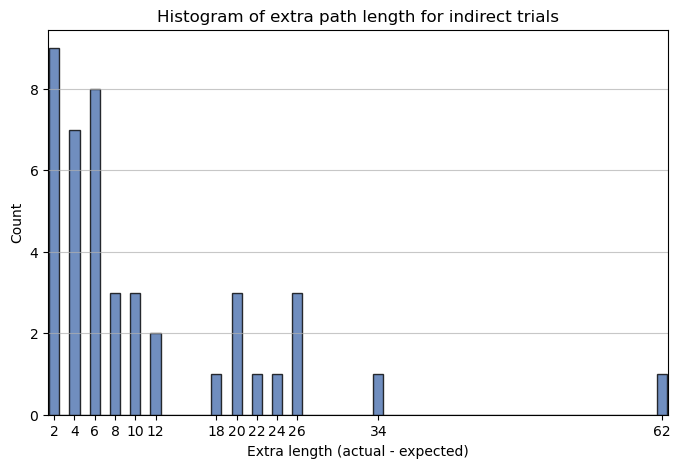

In [2331]:
# Histogram: extra length for indirect trials (actual - expected)
import matplotlib.pyplot as plt
import numpy as np


length_col = 'reward_port_transition_length_sum'
short_col = 'reward_port_expected_shortest_length'

if length_col not in df.columns or short_col not in df.columns:
    raise ValueError(f"Required columns not found: {length_col}, {short_col}")

indirect_df = df[df['_dir_label'] == 'indirect'].copy()
indirect_df = indirect_df.dropna(subset=[length_col, short_col])

if indirect_df.empty:
    print('No indirect trials with valid length/shortest-length found.')
else:
    extra = indirect_df[length_col].astype(float) - indirect_df[short_col].astype(float)
    extra = extra.dropna()
    if extra.empty:
        print('No valid extra-length values to plot.')
    else:
        min_val = float(extra.min())
        max_val = float(extra.max())
        min_int = int(np.floor(min_val))
        max_int = int(np.ceil(max_val))
        # integer-aligned bins (width=1) covering the integer range
        if max_int >= min_int:
            bins = np.arange(min_int - 0.5, max_int + 1.5, 1.0)
        else:
            bins = np.array([min_val - 0.5, max_val + 0.5])

        plt.figure(figsize=(8,5))
        plt.hist(extra, bins=bins, color='#4c72b0', edgecolor='k', alpha=0.8)

        # show x-ticks only at integer values that actually appear in the data
        observed_ints = np.unique(extra.astype(int))
        plt.xticks(observed_ints)
        plt.xlim(min_int - 0.6, max_int + 0.6)

        plt.xlabel('Extra length (actual - expected)')
        plt.ylabel('Count')
        plt.title('Histogram of extra path length for indirect trials')
        plt.grid(axis='y', alpha=0.7)
        plt.savefig(ensure_dir(rf"/var/home/almogmeir/Documents/M.Sc/Project/Graphs/{subject}/Indirect_Path_Lengths/{MM_DD_YYYY}.png"), dpi=150, bbox_inches='tight')
        plt.show()


In [2332]:
# Diagnostic + extraction for long indirect paths (>=4 extra nodes)
import pandas as pd
import numpy as np
import ast

# locate the indirect DataFrame in the notebook globals
_indirect = indirect_df.copy()
length_col = 'reward_port_transition_length_sum'
short_col = 'reward_port_expected_shortest_length'
extra = indirect_df[length_col].astype(float) - indirect_df[short_col].astype(float)
extra = extra.dropna()
print("Columns in indirect:", list(_indirect.columns))
print("\nextra_len value counts:\n", extra.value_counts(dropna=False).sort_index())

# show histogram-like top entries if no long detours found
longs = _indirect[extra >= 4].copy()
print(f"\nFound {len(longs)} rows with extra_len >= 4")

def _ensure_list(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return None
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return list(x)
    if isinstance(x, str):
        # try to parse string representations of lists
        try:
            val = ast.literal_eval(x)
            if isinstance(val, (list, tuple)):
                return list(val)
        except Exception:
            pass
    return [x]

def get_direct_info(row):
    types = _ensure_list(row.get("reward_port_transition_type_chain"))
    starts = _ensure_list(row.get("reward_port_transition_start_frame"))
    pairs = _ensure_list(row.get("reward_port_transition_pairs"))
    lengths = _ensure_list(row.get("reward_port_transition_lengths"))
    exp_short = row.get("reward_port_expected_shortest_length")

    direct_idx = None
    # prefer explicit 'direct' label in the type chain
    if types:
        for i, t in enumerate(types):
            try:
                if isinstance(t, str) and "dir" in t.lower():
                    direct_idx = i
                    break
            except Exception:
                continue

    # fallback: match transition length equal to expected shortest
    if direct_idx is None and lengths is not None and exp_short is not None:
        for i, l in enumerate(lengths):
            try:
                if int(l) == int(exp_short):
                    direct_idx = i
                    break
            except Exception:
                continue

    # fallback: pick first transition that has a start frame
    if direct_idx is None and starts:
        for i, s in enumerate(starts):
            if s is not None and not (isinstance(s, float) and np.isnan(s)):
                direct_idx = i
                break

    # final fallback: use first transition if any
    if direct_idx is None:
        if types or pairs or starts or lengths:
            direct_idx = 0

    node = None
    frame = None
    if direct_idx is not None:
        if pairs and direct_idx < len(pairs):
            p = pairs[direct_idx]
            # pairs might be a tuple/list like ('A','B') or a string; handle both
            if isinstance(p, (list, tuple)) and len(p) > 0:
                node = p[0]
            else:
                node = p
        if starts and direct_idx < len(starts):
            frame = starts[direct_idx]

    return {
        "direct_idx": direct_idx,
        "direct_start_node": node,
        "direct_start_frame": frame,
        "type_chain": types,
        "pairs": pairs,
        "lengths": lengths,
        "exp_short": exp_short
    }

if len(longs) == 0:
    print("\nTop 10 rows by extra_len (for debugging):")
    cols = [c for c in ("trial_idx", "extra_len", "reward_port", "next_reward_port",
                       "reward_port_transition_length_sum", "reward_port_expected_shortest_length") if c in _indirect.columns]
    display(_indirect.sort_values("extra_len", ascending=False).head(10)[cols])
else:
    details = longs.apply(lambda r: pd.Series(get_direct_info(r)), axis=1)
    out = pd.concat([longs.reset_index(drop=False).rename(columns={"index":"indirect_index"}), details.reset_index(drop=True)], axis=1)
    display_cols = [c for c in ("indirect_index","trial_idx","extra_len","direct_idx","direct_start_node","direct_start_frame","_start_frame","_end_frame","next_reward_port") if c in out.columns]
    print("\nDiagnostic rows (first 50):")
    display(out[display_cols].head(50))

    # assign result variable for later use
    detour_direct_starts = out.copy()
    print(f"\nSaved results to variable: detour_direct_starts (rows: {len(detour_direct_starts)})")

Columns in indirect: ['trial_idx', 'reward_time', 'reward_port', 'subject_id', 'session', 'session_epoch_type', 'session_epoch_number', 'reward_size', 'reward_relative_time', 'reward_abs_time', 'depletion_step', 'depletion_size', 'next_reward_port', 'next_reward_port_label', 'reward_port_transition_type_chain', 'reward_port_transition_pairs', 'reward_port_transition_lengths', 'reward_port_transition_length_sum', 'reward_port_transition_start_frame', 'reward_port_transition_start_time', 'reward_port_transition_match_trial_idx', 'reward_port_transition_match_offset', 'reward_port_expected_shortest_length', '_dir_label', '_start_frame', '_end_frame']

extra_len value counts:
 2.0     9
4.0     7
6.0     8
8.0     3
10.0    3
12.0    2
18.0    1
20.0    3
22.0    1
24.0    1
26.0    3
34.0    1
62.0    1
Name: count, dtype: int64

Found 34 rows with extra_len >= 4

Diagnostic rows (first 50):


,indirect_index,trial_idx,direct_idx,direct_start_node,direct_start_frame,_start_frame,_end_frame,next_reward_port
0,6,6,0,Target2,2177,2177.0,2918.0,1.0
1,10,10,0,Target7,3344,3344.0,21508.0,8.0
2,13,13,0,Target8,21509,21509.0,21839.0,7.0
3,15,15,0,Target5,22942,22942.0,24076.0,6.0
4,22,22,0,Target5,25874,25874.0,27449.0,1.0
5,24,24,0,Target3,27974,27974.0,28895.0,4.0
6,25,25,0,Target4,28896,28896.0,29912.0,3.0
7,27,27,0,Target4,30235,30235.0,31142.0,3.0
8,29,29,0,Target7,31526,31526.0,36134.0,8.0
9,30,30,0,Target8,36135,36135.0,37924.0,3.0



Saved results to variable: detour_direct_starts (rows: 34)


In [2333]:
# Fresh approach: match longs rows to node_summary_df by frame, then find direct-start node backwards
import pandas as pd
import numpy as np
import networkx as nx

# get dataframes
_longs = longs.copy()
_node_summ = node_summary_df.copy()
_G = G

print(f"Processing {len(_longs)} long indirect trials\n")

# identify key columns
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

# node_summary_df columns
trial_col_ns = find_col(_node_summ, ["trial_idx", "trial", "trial_index"])
node_col_ns = find_col(_node_summ, ["node", "node_name", "node_corrected", "node_original"])
start_col_ns = find_col(_node_summ, ["start_frame", "_start_frame", "frame"])
end_col_ns = find_col(_node_summ, ["end_frame", "_end_frame"])

print(f"node_summary_df columns: trial={trial_col_ns}, node={node_col_ns}, start={start_col_ns}, end={end_col_ns}\n")

# longs columns
trial_col_long = find_col(_longs, ["trial_idx", "trial", "trial_index"])
start_frame_col = "reward_port_transition_start_frame"
end_node_col = find_col(_longs, ["next_reward_port", "next_port", "reward_port"])

if start_frame_col not in _longs.columns:
    raise RuntimeError(f"Column '{start_frame_col}' not found in longs")
if end_node_col is None:
    raise RuntimeError("Cannot find end node column in longs")

print(f"longs columns: trial={trial_col_long}, start_frame={start_frame_col}, end_node={end_node_col}\n")

# helper to extract node from (src, dest) tuple/list
def node_from_pair(p):
    if p is None:
        return None
    if isinstance(p, (list, tuple, pd.Series, np.ndarray)):
        p = list(p)
        if len(p) > 0:
            return p[0]
    return p

results = []

for long_idx, long_row in _longs.iterrows():
    trial = long_row.get(trial_col_long)
    detour_start_frame = long_row.get(start_frame_col)
    end_node = long_row.get(end_node_col)
    extra_nodes = long_row.get("extra_len")
    
    # handle if start_frame is stored as list
    if isinstance(detour_start_frame, (list, tuple, pd.Series, np.ndarray)):
        detour_start_frame = list(detour_start_frame)[0] if len(detour_start_frame) > 0 else None
    
    detour_start_frame = int(detour_start_frame) if detour_start_frame is not None else None
    
    # find matching row(s) in node_summary_df
    if trial_col_ns:
        ns_rows = _node_summ[_node_summ[trial_col_ns] == trial].copy()
    else:
        # fallback: use all rows (risky)
        ns_rows = _node_summ.copy()
    
    if ns_rows.empty:
        print(f"No node_summary rows for trial {trial} (long_idx {long_idx})")
        results.append({
            "long_idx": long_idx, "trial": trial, "detour_start_frame": detour_start_frame,
            "direct_start_node": None, "direct_start_frame": None, "direct_path_length": None,
            "reason": "no_node_summary_rows"
        })
        continue
    
    # sort by start frame
    if start_col_ns in ns_rows.columns:
        ns_rows = ns_rows.sort_values(start_col_ns).reset_index(drop=True)
    else:
        ns_rows = ns_rows.reset_index(drop=True)
    
    # extract node trajectory (name, start_frame, end_frame for each node visit)
    trajectory = []
    for _, r in ns_rows.iterrows():
        node = r.get(node_col_ns)
        start_f = r.get(start_col_ns)
        end_f = r.get(end_col_ns)
        if node is not None:
            trajectory.append({
                "node": node,
                "start": start_f,
                "end": end_f
            })
    
    if not trajectory:
        print(f"No node trajectory extracted for trial {trial}")
        results.append({
            "long_idx": long_idx, "trial": trial, "detour_start_frame": detour_start_frame,
            "direct_start_node": None, "direct_start_frame": None, "direct_path_length": None,
            "reason": "no_trajectory"
        })
        continue
    
    # sanity check: find where detour_start_frame aligns with trajectory
    # (should be in or near first node's frame range, or close to it)
    detour_idx = 0  # start from first node by default
    if detour_start_frame is not None:
        for i, seg in enumerate(trajectory):
            s = seg.get("start")
            e = seg.get("end")
            if s is not None and e is not None:
                if s <= detour_start_frame <= e:
                    detour_idx = i
                    break
                elif s > detour_start_frame:
                    detour_idx = max(0, i - 1)
                    break
    
    # trajectory from detour start onwards
    traj_nodes = [trajectory[i]["node"] for i in range(detour_idx, len(trajectory))]
    traj_frames = [trajectory[i] for i in range(detour_idx, len(trajectory))]
    
    if not traj_nodes:
        results.append({
            "long_idx": long_idx, "trial": trial, "detour_start_frame": detour_start_frame,
            "direct_start_node": None, "direct_start_frame": None, "direct_path_length": None,
            "reason": "empty_trajectory_after_detour"
        })
        continue
    
    # the last node should be the target (end_node / next_reward_port)
    last_node = traj_nodes[-1]
    
    # work backwards: find furthest node from end where actual path to end == shortest path to end
    direct_start_idx = None
    for j in range(len(traj_nodes) - 1, -1, -1):
        src_node = traj_nodes[j]
        
        # get shortest path from src to last
        try:
            # handle string/int conversions in graph
            src_key = str(src_node) if str(src_node) not in _G else src_node
            dest_key = str(last_node) if str(last_node) not in _G else last_node
            if src_key not in _G:
                src_key = src_node
            if dest_key not in _G:
                dest_key = last_node
            
            shortest = nx.shortest_path(_G, source=src_key, target=dest_key)
            shortest = [str(x) for x in shortest]  # normalize to strings for comparison
        except Exception as e:
            # no path or node not in graph
            continue
        
        # actual path from j to end
        actual = [str(x) for x in traj_nodes[j:]]
        
        # check if they match
        if actual == shortest:
            direct_start_idx = j
            break
    
    if direct_start_idx is None:
        # fallback: use the last node (purely direct)
        direct_start_idx = len(traj_nodes) - 1
    
    # extract result
    direct_start_node = traj_nodes[direct_start_idx]
    direct_start_frame = traj_frames[direct_start_idx].get("end")  # last frame in that node
    direct_path_length = len(traj_nodes) - direct_start_idx  # number of nodes in direct path
    
    results.append({
        "long_idx": long_idx,
        "trial": trial,
        "detour_start_frame": detour_start_frame,
        "detour_start_node": traj_nodes[0] if traj_nodes else None,
        "trajectory_length": len(traj_nodes),
        "direct_start_idx": direct_start_idx,
        "direct_start_node": direct_start_node,
        "direct_start_frame": direct_start_frame,
        "direct_path_length": direct_path_length,
        "end_node": last_node,
        "extra_len": extra_nodes,
        "reason": "matched"
    })

# assemble results
detour_direct_starts = pd.DataFrame(results)
print(f"Matched {(detour_direct_starts['reason']=='matched').sum()} / {len(detour_direct_starts)} trials")
print(f"Detected direct_start_node: {detour_direct_starts['direct_start_node'].notna().sum()}")
print(f"Detected direct_start_frame: {detour_direct_starts['direct_start_frame'].notna().sum()}\n")

display_cols = ["long_idx", "trial", "extra_len", "trajectory_length", "direct_start_node", "direct_start_frame", "direct_path_length", "reason"]
display(detour_direct_starts[display_cols])

Processing 34 long indirect trials

node_summary_df columns: trial=trial_idx, node=node_name, start=start_frame, end=end_frame

longs columns: trial=trial_idx, start_frame=reward_port_transition_start_frame, end_node=next_reward_port

No node_summary rows for trial 46 (long_idx 46)
No node_summary rows for trial 51 (long_idx 51)
Matched 32 / 34 trials
Detected direct_start_node: 32
Detected direct_start_frame: 32



,long_idx,trial,extra_len,trajectory_length,direct_start_node,direct_start_frame,direct_path_length,reason
0,6,6,NaN,16.0,R413,2005.0,1.0,matched
1,10,10,NaN,2.0,R44,3426.0,1.0,matched
2,13,13,NaN,4.0,R20,21576.0,1.0,matched
3,15,15,NaN,2.0,L410,22988.0,1.0,matched
4,22,22,NaN,3.0,L35,26046.0,1.0,matched
5,24,24,NaN,3.0,L511,28126.0,1.0,matched
6,25,25,NaN,2.0,L43,29057.0,1.0,matched
7,27,27,NaN,4.0,L43,30283.0,1.0,matched
8,29,29,NaN,4.0,R21,31731.0,1.0,matched
9,30,30,NaN,2.0,R42,36143.0,1.0,matched


In [2334]:
# Find indirect trials where extra length == 1 and count by pair
pairs_col = 'reward_port_transition_pairs'
length_col = 'reward_port_transition_length_sum'
short_col = 'reward_port_expected_shortest_length'

if pairs_col not in df.columns:
    raise ValueError(f"Missing expected column: {pairs_col}")

indirect = df[df['_dir_label'] == 'indirect'].copy()
indirect[length_col] = pd.to_numeric(indirect[length_col], errors='coerce')
indirect[short_col] = pd.to_numeric(indirect[short_col], errors='coerce')
indirect['extra_len'] = indirect[length_col] - indirect[short_col]

# consider only exact +1 (allow tiny float tolerance)
mask = indirect['extra_len'].notna() & (np.isclose(indirect['extra_len'], 1.0))
subset = indirect[mask]

print(f"Found {len(subset)} indirect trials with extra length == 1")
if subset.empty:
    # show a quick summary of available extras
    print('Extras summary (all indirect trials):')
    print(indirect['extra_len'].describe())
else:
    counts = subset[pairs_col].value_counts(dropna=True)
    print('\nCounts by pair (reward_port_transition_pairs):')
    print(counts.to_string())

    # show sample rows to inspect
    display_cols = [pairs_col, length_col, short_col, 'extra_len', '_start_frame', '_end_frame']
    display_cols = [c for c in display_cols if c in subset.columns]
    print('\nExample rows:')
    display(subset[display_cols].head(50))


Found 0 indirect trials with extra length == 1
Extras summary (all indirect trials):
count    43.000000
mean     10.930233
std      11.640233
min       2.000000
25%       4.000000
50%       6.000000
75%      15.000000
max      62.000000
Name: extra_len, dtype: float64


In [2335]:
# save node_summary_df to a csv (intermediate checkpoint)
node_summary_csv_path = f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/improved_node_summary_df.csv"

os.makedirs(os.path.dirname(node_summary_csv_path), exist_ok=True)
node_summary_df.to_csv(node_summary_csv_path, index=False)
print(f"✓ Saved node_summary_df to: {node_summary_csv_path}")


✓ Saved node_summary_df to: /var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/NPC4/19_05_2026/improved_node_summary_df.csv


In [2336]:
reward_df

,trial_idx,reward_time,reward_port,subject_id,session,session_epoch_type,session_epoch_number,reward_size,reward_relative_time,reward_abs_time,...,next_reward_port_label,reward_port_transition_type_chain,reward_port_transition_pairs,reward_port_transition_lengths,reward_port_transition_length_sum,reward_port_transition_start_frame,reward_port_transition_start_time,reward_port_transition_match_trial_idx,reward_port_transition_match_offset,reward_port_expected_shortest_length
0,0,3.4399,6,108104,1,behav_only,2,0.03,3.4399,19.1740,...,Target5,direct,"((Target6, Target5),)","(8,)",8,83,2.075,0,0,8
1,1,1.0897,5,108104,1,behav_only,2,0.00,1.0897,32.4155,...,Target3,indirect,"((Target5, Target3),)","(12,)",12,627,15.675,1,0,10
2,2,5.6735,3,108104,1,behav_only,2,0.03,5.6735,40.3092,...,Target4,indirect,"((Target3, Target4),)","(10,)",10,974,24.35,2,0,8
3,3,3.2077,4,108104,1,behav_only,2,0.03,3.2077,45.7655,...,Target6,direct,"((Target4, Target6),)","(10,)",10,1188,29.7,3,0,10
4,4,4.3811,6,108104,1,behav_only,2,0.00,4.3811,52.3964,...,Target3,direct,"((Target6, Target3),)","(10,)",10,1419,35.475,4,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,159,273.4800,8,108104,1,behav_only,2,0.00,273.4800,2870.2009,...,Target8,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
160,160,194.3536,8,108104,1,behav_only,2,0.00,194.3536,3066.8037,...,Target7,direct,"((Target8, Target7),)","(8,)",8,121292,3032.3,160,0,8
161,161,52.2572,7,108104,1,behav_only,2,0.00,52.2572,3121.3164,...,Target8,indirect,"((Target7, Target8),)","(18,)",18,123543,3088.575,162,1,8
162,162,94.7654,8,108104,1,behav_only,2,0.00,94.7654,3218.3307,...,Target7,direct,"((Target8, Target7),)","(8,)",8,127337,3183.425,162,0,8


# More reward_df analysis

In [2337]:
import pandas as pd
import numpy as np

# 1. Filter out NaNs
filtered_df = reward_df.dropna(subset=['reward_port_transition_type_chain'])

# 2. Filter out the single 'direct' and 'indirect' cases
# The ~ operator negates the condition, keeping only the combinations
complex_chains = filtered_df[~filtered_df['reward_port_transition_type_chain'].isin(['direct', 'indirect'])]

# 3. Get the counts of each combination case
chain_counts = complex_chains['reward_port_transition_type_chain'].value_counts()
print("Counts for each combination:")
print(chain_counts)
print("-" * 30)

# 4. Save each group to a unique DataFrame inside a dictionary
grouped_dfs = {}

for group_name, group_data in complex_chains.groupby('reward_port_transition_type_chain'):
    # Optional: Clean the string so it makes a nice dictionary key or filename
    # e.g., turning "direct + indirect" into "direct_plus_indirect"
    safe_name = group_name.replace(' + ', '_plus_').replace(' ', '_')
    
    # Store the subset DataFrame in the dictionary
    grouped_dfs[safe_name] = group_data.copy()

# Now you can access individual DataFrames by their group name!
# Example: grouped_dfs['direct_plus_indirect']

Counts for each combination:
reward_port_transition_type_chain
indirect + indirect + indirect    2
indirect + indirect               1
Name: count, dtype: int64
------------------------------


In [2338]:
import sys
sys.exit("Stopping 'Run All' execution here.")

SystemExit: Stopping 'Run All' execution here.

/var/home/almogmeir/miniconda3/envs/navigraph/lib/python3.14/site-packages/IPython/core/interactiveshell.py:3709: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


# Video

In [ ]:
def hex_to_bgr(hex_str):
    # Remove '#' if present
    hex_str = hex_str.lstrip('#')
    # Convert hex pairs to integers and reverse to BGR order
    return tuple(int(hex_str[i:i+2], 16) for i in (4, 2, 0))

In [ ]:
# Helper: convert MATLAB RGB colors to OpenCV BGR colors
# MATLAB typically stores colors as [R, G, B] with values in [0, 1]
# OpenCV expects (B, G, R) with values in [0, 255]

import numpy as np


def matlab_rgb_to_opencv(color):
    """Convert one MATLAB-style RGB color to an OpenCV BGR tuple.

    Parameters
    ----------
    color : sequence of 3 numbers
        MATLAB RGB values in [0, 1], ordered as [R, G, B].

    Returns
    -------
    tuple[int, int, int]
        OpenCV BGR values in 0-255 integer range.
    """
    rgb = np.asarray(color, dtype=float).reshape(3)
    rgb = np.clip(rgb, 0.0, 1.0)
    bgr = (rgb[::-1] * 255.0).round().astype(int)
    return tuple(int(v) for v in bgr)


def matlab_rgb_dict_to_opencv(color_dict):
    """Convert a dict of MATLAB RGB colors to OpenCV BGR colors."""
    return {key: matlab_rgb_to_opencv(value) for key, value in color_dict.items()}


# Example:
matlab_port_colors = {
    'Target1': [0.80, 0.25, 0.33],
    'Target2': [1.00, 0.55, 0.50],
    'Target3': [0.20, 0.45, 0.80],
    'Target4': [0.55, 0.75, 1.00],
    'Target5': [0.25, 0.60, 0.35],
    'Target6': [0.65, 0.80, 0.55],
    'Target7': [0.55, 0.40, 0.70],
    'Target8': [0.90, 0.60, 0.85]
}
port_colors = matlab_rgb_dict_to_opencv(matlab_port_colors)
print(port_colors)


{'Target1': (84, 64, 204), 'Target2': (128, 140, 255), 'Target3': (204, 115, 51), 'Target4': (255, 191, 140), 'Target5': (89, 153, 64), 'Target6': (140, 204, 166), 'Target7': (178, 102, 140), 'Target8': (217, 153, 230)}


In [ ]:
# Interactive helper: click 8 points on a single frame to place port labels on the left video
# Uses an OpenCV window instead of matplotlib ginput to avoid non-interactive backend warnings.
# Click 8 points in order: Target1 -> Target8, then press any key to finish.

import cv2
import pandas as pd
from pathlib import Path

frame_idx = 1000
video_path = Path(maze_video_path)

port_labels_order = [
    'Target1', 'Target2', 'Target3', 'Target4',
    'Target5', 'Target6', 'Target7', 'Target8',
]


cap = cv2.VideoCapture(str(video_path))
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
ret, frame = cap.read()
cap.release()

if not ret:
    raise RuntimeError(f'Could not read frame {frame_idx} from {video_path}')

clicked_points = []
preview = frame.copy()

def draw_overlay(img):
    vis = img.copy()
    for i, (x, y) in enumerate(clicked_points):
        label = port_labels_order[i]
        color = port_colors.get(label, (0, 255, 255))
        cv2.circle(vis, (x, y), 5, color, -1)
        cv2.putText(vis, f'{label}', (x + 8, y - 8), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    cv2.putText(
        vis,
        f'Click 8 points in order: {len(clicked_points)}/8',
        (20, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2,
        cv2.LINE_AA,
    )
    return vis

window_name = 'Click port label positions'
cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)


def mouse_callback(event, x, y, flags, param):
    global preview
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked_points) < 8:
        clicked_points.append((x, y))
        preview = draw_overlay(frame)
        cv2.imshow(window_name, preview)

cv2.setMouseCallback(window_name, mouse_callback)
preview = draw_overlay(frame)
cv2.imshow(window_name, preview)

print('Click 8 points on the image in this order:')
for label in port_labels_order:
    print(f'  - {label}')
print("After the 8th click, press any key in the image window to finish.")

while True:
    key = cv2.waitKey(20) & 0xFF
    if len(clicked_points) >= 8 and key != 255:
        break

cv2.destroyAllWindows()

if len(clicked_points) != 8:
    raise RuntimeError(f'Expected 8 clicks, got {len(clicked_points)}')

port_label_positions = pd.DataFrame(
    [
        {'port_label': label, 'x': x, 'y': y}
        for label, (x, y) in zip(port_labels_order, clicked_points)
    ]
)

print('\nCollected port-label positions:')
display(port_label_positions)

port_label_xy = {
    row['port_label']: (int(row['x']), int(row['y']))
    for _, row in port_label_positions.iterrows()
}

print('\nDictionary form:')
print(port_label_xy)

# Optional save
# port_label_positions.to_csv('/var/home/almogmeir/Documents/GitHub/NaviGraph/output/port_label_positions.csv', index=False)


Click 8 points on the image in this order:
  - Target1
  - Target2
  - Target3
  - Target4
  - Target5
  - Target6
  - Target7
  - Target8
After the 8th click, press any key in the image window to finish.

Collected port-label positions:


,port_label,x,y
0,Target1,306,511
1,Target2,306,511
2,Target3,306,511
3,Target4,306,511
4,Target5,306,511
5,Target6,306,511
6,Target7,306,511
7,Target8,306,511



Dictionary form:
{'Target1': (306, 511), 'Target2': (306, 511), 'Target3': (306, 511), 'Target4': (306, 511), 'Target5': (306, 511), 'Target6': (306, 511), 'Target7': (306, 511), 'Target8': (306, 511)}


In [ ]:
port_label_positions.loc[port_label_positions['port_label'] == 'Target1', ['x', 'y']] = [945, 45]
port_label_positions.loc[port_label_positions['port_label'] == 'Target2', ['x', 'y']] = [700, 45]
port_label_positions.loc[port_label_positions['port_label'] == 'Target3', ['x', 'y']] = [350, 45]
port_label_positions.loc[port_label_positions['port_label'] == 'Target4', ['x', 'y']] = [120, 45]
port_label_positions.loc[port_label_positions['port_label'] == 'Target5', ['x', 'y']] = [120, 890]
port_label_positions.loc[port_label_positions['port_label'] == 'Target6', ['x', 'y']] = [360, 890]
port_label_positions.loc[port_label_positions['port_label'] == 'Target7', ['x', 'y']] = [945, 890]
port_label_positions.loc[port_label_positions['port_label'] == 'Target8', ['x', 'y']] = [695, 890]

port_lbel_xy = {
    row["port_label"]: (int(row["x"]), int(row["y"]))
    for _, row in port_label_positions.iterrows()
}

In [ ]:
port_label_positions

,port_label,x,y
0,Target1,945,45
1,Target2,700,45
2,Target3,350,45
3,Target4,120,45
4,Target5,120,890
5,Target6,360,890
6,Target7,945,890
7,Target8,695,890


In [ ]:
def create_side_by_side_video(start_frame, end_frame, output_path, summary_df, G, node_positions, port_map,
                               video_path, reward_leaf_parents=None, fps=40, video_height=720,
                               graph_width=400, bodypart_colors=None,
                               port_label_positions=None, port_colors=None):
    """
    Create a side-by-side video with video on left and graph on right, with water drop icon on reward.
    """
    import cv2
    import numpy as np
    import pandas as pd
    from pathlib import Path
    
    video_path = Path(video_path)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    reward_size_to_px = {}

    if reward_leaf_parents is None:
        reward_leaf_parents = {}

    def _resolve_column(df, candidates):
        cols = df.columns
        candidate_l = [c.lower() for c in candidates]
        if isinstance(cols, pd.MultiIndex):
            for col in cols:
                parts = [str(v).strip().lower() for v in col]
                for candidate in candidate_l:
                    if candidate in parts:
                        return col
            return None
        lower_map = {str(col).strip().lower(): col for col in cols}
        for candidate in candidate_l:
            if candidate in lower_map:
                return lower_map[candidate]
        return None

    def _resolve_tracking_column(df, bodypart, field):
        cols = df.columns
        if isinstance(cols, pd.MultiIndex):
            for col in cols:
                if len(col) >= 2 and str(col[0]) == bodypart and str(col[1]).lower() == field.lower():
                    return col
            return None
        for col in [f'{bodypart}_{field}', f'{bodypart}.{field}', f'{bodypart}{field}']:
            if col in cols:
                return col
        return None

    def _normalize_node(value):
        if value is None or pd.isna(value):
            return None
        text = str(value).strip().strip('"').strip("'")
        if text.lower() in {'none', 'nan', ''}:
            return None
        return text if text in node_positions else None

    def _parse_edge_value(value):
        if value is None or pd.isna(value):
            return None
        if isinstance(value, (list, tuple)) and len(value) == 2:
            src = _normalize_node(value[0])
            dst = _normalize_node(value[1])
            if src is not None and dst is not None:
                return (src, dst)
            return None
        text = str(value)
        if text.lower().strip() in {'none', 'nan', ''}:
            return None
        hits = [node for node in node_positions.keys() if node in text]
        if len(hits) >= 2:
            return (hits[0], hits[1])
        for sep in ['->', '-', '|', ',', ' to ']:
            if sep in text:
                parts = [p.strip().strip("()[]\"'") for p in text.split(sep)]
                parts = [p for p in parts if p in node_positions]
                if len(parts) >= 2:
                    return (parts[0], parts[1])
        return None

    def _normalize_port_label_positions(value):
        positions = {}
        if value is None:
            return positions
        if isinstance(value, pd.DataFrame):
            if {'port_label', 'x', 'y'}.issubset(value.columns):
                for _, row in value.iterrows():
                    label = str(row['port_label']).strip()
                    if label:
                        positions[label] = (float(row['x']), float(row['y']))
            return positions
        if isinstance(value, dict):
            for label, pos in value.items():
                label = str(label).strip()
                if isinstance(pos, (list, tuple)) and len(pos) >= 2:
                    positions[label] = (float(pos[0]), float(pos[1]))
            return positions
        return positions

    # helper to convert hex to bgr
    def hex_to_bgr(h):
        h = h.lstrip('#')
        lv = len(h)
        rgb = tuple(int(h[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))
        return (int(rgb[2]), int(rgb[1]), int(rgb[0]))

    # Load water drop icon
    icon_path = Path('/var/home/almogmeir/Documents/M.Sc/Project/Input/water-drop-icon.png')
    icon_drop = None
    if icon_path.exists():
        icon_drop = cv2.imread(str(icon_path), cv2.IMREAD_UNCHANGED)
        print("✓ Loaded water drop icon")
    else:
        print(f"⚠ Icon file not found: {icon_path}")

    # Load or create red X icon (RGBA)
    icon_x_path = Path('/var/home/almogmeir/Documents/M.Sc/Project/Input/red_x_icon.png')
    if icon_x_path.exists():
        icon_x = cv2.imread(str(icon_x_path), cv2.IMREAD_UNCHANGED)
        print("✓ Loaded red X icon")
    else:
        # create a simple red X icon with alpha
        size_px = 26
        icon_x = np.zeros((size_px, size_px, 4), dtype=np.uint8)
        thickness = max(4, size_px // 20)
        color = (0, 0, 255, 255)  # BGR A (red)
        cv2.line(icon_x, (int(size_px*0.15), int(size_px*0.15)), (int(size_px*0.85), int(size_px*0.85)), color, thickness, cv2.LINE_AA)
        cv2.line(icon_x, (int(size_px*0.85), int(size_px*0.15)), (int(size_px*0.15), int(size_px*0.85)), color, thickness, cv2.LINE_AA)
        print("✓ Created synthetic red X icon")

    def _overlay_icon(img, center, icon_img):
        """Overlay PNG icon with alpha blending centered at center, respecting its actual dimensions."""
        if icon_img is None:
            return
            
        # Rely on the pre-resized dimensions
        h, w = icon_img.shape[:2]
        cx, cy = int(center[0]), int(center[1])
        
        # Calculate bounding box on the background image
        x1 = max(0, cx - w // 2)
        y1 = max(0, cy - h // 2)
        x2 = min(img.shape[1], cx + w // 2)
        y2 = min(img.shape[0], cy + h // 2)
        
        roi_width = x2 - x1
        roi_height = y2 - y1
        if roi_width <= 0 or roi_height <= 0:
            return
            
        # Calculate slice logic for the icon itself (in case it bleeds off the left/top edges)
        icon_x1 = 0 if cx - w // 2 >= 0 else -(cx - w // 2)
        icon_y1 = 0 if cy - h // 2 >= 0 else -(cy - h // 2)
        
        roi = img[y1:y2, x1:x2].astype(float)
        
        if icon_img.shape[2] == 4:
            bgr = icon_img[:, :, :3].astype(float)
            alpha = icon_img[:, :, 3].astype(float) / 255.0
        else:
            bgr = icon_img.astype(float)
            alpha = np.ones((h, w), dtype=float)
            
        # Extract the correct crop of the icon
        icon_crop = bgr[icon_y1:icon_y1+roi_height, icon_x1:icon_x1+roi_width]
        alpha_crop = alpha[icon_y1:icon_y1+roi_height, icon_x1:icon_x1+roi_width]
        
        for c in range(3):
            roi[:, :, c] = (icon_crop[:, :, c] * alpha_crop +
                            roi[:, :, c] * (1 - alpha_crop))
        img[y1:y2, x1:x2] = roi.astype(np.uint8)

    # Precompute mapping from reward_size values to icon pixel sizes early so we have it for the resize block
    reward_size_col = _resolve_column(summary_df, ['reward_size'])
    if reward_size_col is not None:
        vals = summary_df[reward_size_col]
        non_zero_vals = sorted(pd.unique(vals.dropna().astype(float)))
        non_zero_vals = [v for v in non_zero_vals if v != 0]
        # limit to 4 as requested, map to pixel sizes increasing
        size_pixels = [12, 16, 20, 26]  # example sizes (px)
        for i, v in enumerate(non_zero_vals[:4]):
            reward_size_to_px[float(v)] = size_pixels[i]
        # if there are more than 4, map any extras to largest
        if len(non_zero_vals) > 4:
            largest_px = size_pixels[-1]
            for v in non_zero_vals[4:]:
                reward_size_to_px[float(v)] = largest_px

    # Pre-resize icons based on reward sizes
    icon_drop_resized = {}  # maps pixel size -> resized icon
    
    # Ensure our fallback size (26) is always in the dictionary!
    sizes_to_resize = set(reward_size_to_px.values())
    sizes_to_resize.add(26) 
    
    for px_size in sizes_to_resize:
        if icon_drop is not None:
            # Cast to int to ensure dictionary keys match perfectly later
            icon_drop_resized[int(px_size)] = cv2.resize(icon_drop, (int(px_size), int(px_size)), interpolation=cv2.INTER_LINEAR)

    # Pre-resize X icon (fixed size)
    icon_x_resized = None
    if icon_x is not None:
        icon_x_resized = cv2.resize(icon_x, (24, 24), interpolation=cv2.INTER_LINEAR)

    if bodypart_colors is None:
        bodypart_colors = {
            'headstage': hex_to_bgr('#ff595e'),
            'ear_L': hex_to_bgr('#ffca3a'),
            'ear_R': hex_to_bgr('#8ac926'),
            'midbody': hex_to_bgr('#1982c4'),
            'tailbase': hex_to_bgr('#6a4c93'),
        }

    if port_colors is None:
        port_colors = {
            'Target1': (178, 140, 87), 'Target2': (122, 165, 110), 'Target3': (143, 108, 183),
            'Target4': (104, 170, 196), 'Target5': (171, 122, 164), 'Target6': (96, 147, 186),
            'Target7': (153, 151, 102), 'Target8': (128, 112, 184),
        }

    port_label_positions = _normalize_port_label_positions(port_label_positions)

    bodypart_columns = {}
    for bp in ['headstage', 'ear_L', 'ear_R', 'midbody', 'tailbase']:
        x_col = _resolve_tracking_column(summary_df, bp, 'x')
        y_col = _resolve_tracking_column(summary_df, bp, 'y')
        if x_col is not None and y_col is not None:
            bodypart_columns[bp] = {'x': x_col, 'y': y_col}

    # --- THE FIX IS HERE ---
    node_col = _resolve_column(summary_df, ['headstage_graph_node'])
    edge_col = _resolve_column(summary_df, ['headstage_graph_edge'])
    frame_map_col = _resolve_column(summary_df, ['frame_idx_global', 'frame_idx'])
    reward_port_col = _resolve_column(summary_df, ['reward_port', 'target_port']) 

    print(f"Found {len(bodypart_columns)} bodyparts, reward_size_col={reward_size_col}, reward_port_col={reward_port_col}")

    cap = cv2.VideoCapture(str(video_path))
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    original_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    original_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    video_width = int(video_height * original_width / original_height)
    total_width = video_width + graph_width
    total_height = video_height

    # Find the iloc range that covers [start_frame, end_frame] by frame_idx_global.
    # Using numpy for speed; then iterate with iloc (avoids slow iterrows).
    if frame_map_col is not None:
        _frame_np = pd.to_numeric(summary_df[frame_map_col], errors='coerce').to_numpy()
        _match_ilocs = np.where(
            (_frame_np >= float(start_frame)) & (_frame_np <= float(end_frame))
        )[0]
        if len(_match_ilocs) == 0:
            valid = _frame_np[~np.isnan(_frame_np)]
            print(f"Warning: no rows with frame_idx_global in [{start_frame}, {end_frame}]. "
                  f"summary_df range: [{int(valid.min())}, {int(valid.max())}]")
            cap.release()
            out.release()
            return
        _start_iloc = int(_match_ilocs[0])
        _end_iloc   = int(_match_ilocs[-1])
        # print(f"Window: iloc {_start_iloc}–{_end_iloc}  "
            #   f"(frame_idx_global {int(_frame_np[_start_iloc])}–{int(_frame_np[_end_iloc])})")
    else:
        print("Warning: frame_idx_global column not found — falling back to row-index interpretation.")
        _start_iloc = max(0, int(start_frame))
        _end_iloc   = min(int(end_frame), len(summary_df) - 1)
    n_frames = _end_iloc - _start_iloc + 1

    # ── Debug: print the rows that will be used so frame alignment is visible ──
    # print(f"\n--- Row window for frame_idx_global [{int(start_frame)}, {int(end_frame)}] ---")
    # print(f"{'out_frame':>9}  {'summary_df iloc':>15}  {'frame_idx_global':>16}  {'node'}")
    # _n_preview = n_frames  # print every row (user asked for full visibility)
    # for _dbg_offset in range(_n_preview):
    #     _dbg_iloc = _start_iloc + _dbg_offset
    #     _dbg_row  = summary_df.iloc[_dbg_iloc]
    #     _dbg_fidx = int(_dbg_row[frame_map_col]) if frame_map_col is not None and pd.notna(_dbg_row[frame_map_col]) else _dbg_iloc
    #     _dbg_node = _normalize_node(_dbg_row[node_col]) if node_col is not None else '?'
    #     print(f"{_dbg_offset + 1:>9}  {_dbg_iloc:>15}  {_dbg_fidx:>16}  {_dbg_node}")
    # print("-----------------------------------------------------------\n")

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (total_width, total_height))

    if node_positions:
        all_x = [pos[0] for pos in node_positions.values()]
        all_y = [pos[1] for pos in node_positions.values()]
        min_x, max_x = min(all_x), max(all_x)
        min_y, max_y = min(all_y), max(all_y)
        data_width = max_x - min_x if max_x > min_x else 1
        data_height = max_y - min_y if max_y > min_y else 1

        padding = 30
        available_graph_width = graph_width - 2 * padding
        available_graph_height = total_height - 2 * padding
        scale_x = available_graph_width / data_width
        scale_y = available_graph_height / data_height
        scale = min(scale_x, scale_y, 1.0)

        scaled_width = data_width * scale
        scaled_height = data_height * scale
        offset_x = video_width + padding + (available_graph_width - scaled_width) / 2
        offset_y = padding + (available_graph_height - scaled_height) / 2
    else:
        scale = 1.0
        offset_x = video_width + 30
        offset_y = 30
        min_x = min_y = 0

    graph_xy = {
        node_id: (int((pos[0] - min_x) * scale + offset_x), int((pos[1] - min_y) * scale + offset_y))
        for node_id, pos in node_positions.items()
    }

    print(f"Creating {n_frames} frames...")

    highlighted_node_count = 0
    highlighted_edge_count = 0
    # reward_icon_timers maps port_label -> dict { 'timer': int, 'type': 'drop'|'x', 'size': px }
    reward_icon_timers = {}

    for out_idx, row_iloc in enumerate(range(_start_iloc, _end_iloc + 1), start=1):
        row = summary_df.iloc[row_iloc]
        if frame_map_col is not None and pd.notna(row[frame_map_col]):
            video_frame_idx = int(row[frame_map_col])
        else:
            video_frame_idx = row_iloc

        video_frame_idx = max(0, min(video_frame_idx, frame_count - 1))
        cap.set(cv2.CAP_PROP_POS_FRAMES, video_frame_idx)
        ret, frame = cap.read()
        if not ret:
            break

        frame_resized = cv2.resize(frame, (video_width, video_height))
        output_frame = np.full((total_height, total_width, 3), (255, 255, 255), dtype=np.uint8)
        output_frame[:, :video_width] = frame_resized

        # Draw bodyparts on left video
        for bp, cols in bodypart_columns.items():
            x_val = row[cols['x']]
            y_val = row[cols['y']]
            if pd.notna(x_val) and pd.notna(y_val):
                x_draw = int(float(x_val) * video_width / original_width)
                y_draw = int(float(y_val) * video_height / original_height)
                if 0 <= x_draw < video_width and 0 <= y_draw < video_height:
                    cv2.circle(output_frame, (x_draw, y_draw), 3, bodypart_colors.get(bp, (200, 200, 200)), -1)

        # Draw left-side port labels and reward icons next to them
        for port_label, (px, py) in port_label_positions.items():
            label_color = port_colors.get(port_label, (90, 90, 90))
            lx = int(px * video_width / original_width)
            ly = int(py * video_height / original_height)
            text = str(port_label)
            font = cv2.FONT_HERSHEY_TRIPLEX
            font_scale = 0.5
            thickness = 1
            (tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)

            x1 = max(0, lx - 4)
            y1 = max(0, ly - th - 8)
            x2 = min(video_width - 1, lx + tw + 6)
            y2 = min(video_height - 1, ly + baseline + 4)

            cv2.rectangle(output_frame, (x1, y1), (x2, y2), label_color, -1)
            cv2.putText(output_frame, text, (lx, ly), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

            # Left-side reward icons (next to port labels)
            timer_info = reward_icon_timers.get(port_label, None)
            if timer_info and timer_info.get('timer', 0) > 0:
                icon_x_pos = x2 + 20
                icon_y_pos = (y1 + y2) // 2
                if icon_x_pos + 20 > video_width:
                    icon_x_pos = x1 - 14
                
                if timer_info.get('type') == 'drop':
                    px_size = int(timer_info.get('size', 26))
                    # Safely fallback to the resized 26px version, NOT the giant original file
                    icon_to_use = icon_drop_resized.get(px_size, icon_drop_resized.get(26))
                else:  # 'x'
                    icon_to_use = icon_x_resized
                
                if icon_to_use is not None:
                    _overlay_icon(output_frame, (icon_x_pos, icon_y_pos), icon_to_use)


        current_node = _normalize_node(row[node_col]) if node_col is not None else None
        reward_size_value = row[reward_size_col] if reward_size_col is not None else np.nan
        
        # --- NEW STRICT REWARD LOGIC ---
        if pd.notna(reward_size_value):
            target_port_label = None
            
            # 1. Determine the port based strictly on the node in THIS specific row
            if current_node is not None:
                import re
                for p_node, p_label in port_map.items():
                    valid_nodes = {str(p_node).strip()}
                    
                    # Extract the pure integer from the port label (e.g., 'Target8' -> 8)
                    match = re.search(r'\d+', str(p_label))
                    if match:
                        port_num = int(match.group())
                        # Now it perfectly matches keys 1, 2, 3... 8 in reward_leaf_parents
                        parent_data = reward_leaf_parents.get(port_num)
                        
                        # Add parents and grandparents to the valid node pool
                        if isinstance(parent_data, tuple) and len(parent_data) > 0:
                            valid_nodes.add(str(parent_data[0]).strip())
                            if len(parent_data) > 1 and isinstance(parent_data[1], list):
                                for gp in parent_data[1]:
                                    valid_nodes.add(str(gp).strip())

                    # Apply tolerance: check if tracking node is the port, parent, or grandparent
                    if str(current_node).strip() in valid_nodes:
                        target_port_label = p_label
                        break
            
            # 2. FAILSAFE: If tracking glitches and current_node is missing or doesn't match, 
            # use the reward_port column as an absolute backup
            if target_port_label is None and reward_port_col is not None:
                raw_port = str(row[reward_port_col]).strip()
                if pd.notna(row[reward_port_col]) and raw_port.lower() not in {'nan', 'none', ''}:
                    # If it's a known label or node
                    if raw_port in port_map.values():
                        target_port_label = raw_port
                    elif raw_port in port_map.keys():
                        target_port_label = port_map[raw_port]
                    else:
                        # Fallback: extract the number from the raw data and match it to a label
                        import re
                        match = re.search(r'\d+', raw_port)
                        if match:
                            for lbl in port_map.values():
                                if match.group() in str(lbl):
                                    target_port_label = lbl
                                    break

            # 3. If we successfully found a target port, set the timer and icon type
            if target_port_label:
                val = float(reward_size_value)
                if val > 0:
                    px_size = reward_size_to_px.get(val, 26)
                    reward_icon_timers[target_port_label] = {'timer': 40, 'type': 'drop', 'size': px_size}
                else:
                    reward_icon_timers[target_port_label] = {'timer': 40, 'type': 'x', 'size': 24}

        # Draw graph edges
        for node_a, node_b in G.edges():
            if node_a in graph_xy and node_b in graph_xy:
                cv2.line(output_frame, graph_xy[node_a], graph_xy[node_b], (55, 55, 55), 1)

        # Port nodes
        for node_id, port_label in port_map.items():
            if node_id in graph_xy:
                xg, yg = graph_xy[node_id]
                node_color = port_colors.get(port_label, (90, 90, 90))
                cv2.circle(output_frame, (xg, yg), 7, node_color, 2)
                if port_label in {'Target1', 'Target2', 'Target3', 'Target4'}:
                    cv2.rectangle(output_frame, (xg - 20, yg - 30), (xg + 50, yg - 10), node_color, -1)
                    cv2.putText(output_frame, str(port_label), (xg - 15, yg - 15),
                                cv2.FONT_HERSHEY_TRIPLEX, 0.5, (255, 255, 255), 1)
                else:
                    cv2.rectangle(output_frame, (xg - 20, yg + 15), (xg + 50, yg + 35), node_color, -1)
                    cv2.putText(output_frame, str(port_label), (xg - 15, yg + 30),
                                cv2.FONT_HERSHEY_TRIPLEX, 0.5, (255, 255, 255), 1)

        # Reward icons on graph
        for node_id, port_label in port_map.items():
            info = reward_icon_timers.get(port_label, None)
            if info and info.get('timer', 0) > 0 and node_id in graph_xy:
                xg, yg = graph_xy[node_id]
                if port_label in {'Target1', 'Target2', 'Target3', 'Target4'}:
                    icon_x_pos = xg
                    icon_y_pos = yg - 55
                else:
                    icon_x_pos = xg
                    icon_y_pos = yg + 65
                
                # 1. DEFINE icon_to_use FIRST
                if info.get('type') == 'drop':
                    px_size = int(info.get('size', 26))
                    # Safely fallback to the resized 26px version
                    icon_to_use = icon_drop_resized.get(px_size, icon_drop_resized.get(26))
                else:  # 'x'
                    icon_to_use = icon_x_resized
                
                # Safety check in case the image completely failed to load earlier
                if icon_to_use is None:
                    continue
                
                # 2. NOW GET DIMENSIONS AND CLAMP
                icon_h, icon_w = icon_to_use.shape[:2]
                
                # Clamp the center position so that the edges of the icon don't bleed off the screen
                icon_x_pos = int(max(icon_w // 2, min(total_width - (icon_w // 2), icon_x_pos)))
                icon_y_pos = int(max(icon_h // 2, min(total_height - (icon_h // 2), icon_y_pos)))
                
                # 3. OVERLAY ICON
                _overlay_icon(output_frame, (icon_x_pos, icon_y_pos), icon_to_use)

        current_edge = _parse_edge_value(row[edge_col]) if edge_col is not None else None
        current = hex_to_bgr("#975100")

        # Current edge highlight
        if current_edge is not None:
            ea, eb = current_edge
            if ea in graph_xy and eb in graph_xy:
                cv2.line(output_frame, graph_xy[ea], graph_xy[eb], current, 5)
                highlighted_edge_count += 1

        # Current node highlight
        if current_node is not None and current_node in graph_xy:
            xg, yg = graph_xy[current_node]
            port_label = port_map.get(current_node)
            is_port_node = port_label is not None
            border_color = port_colors.get(port_label, current) if is_port_node else current
            cv2.circle(output_frame, (xg, yg), 9, current, -1)
            cv2.circle(output_frame, (xg, yg), 11, border_color, 2)
            highlighted_node_count += 1

        out.write(output_frame)
        # _dbg_fidx_live = video_frame_idx
        # _dbg_node_live = str(current_node) if current_node is not None else 'None'
        # print(f"  frame {out_idx:>4}/{n_frames}  iloc={row_iloc:>6}  frame_idx_global={_dbg_fidx_live:>6}  node={_dbg_node_live}")

        # decrement timers
        for port_label in list(reward_icon_timers.keys()):
            if reward_icon_timers[port_label].get('timer', 0) > 0:
                reward_icon_timers[port_label]['timer'] -= 1

    print("\n✓ Video created!")
    cap.release()
    out.release()
    print(f"Saved to: {output_path}")

In [ ]:
port_label_positions

,port_label,x,y
0,Target1,945,45
1,Target2,700,45
2,Target3,350,45
3,Target4,120,45
4,Target5,120,890
5,Target6,360,890
6,Target7,945,890
7,Target8,695,890


In [ ]:
# Example: Create a 10-second clip (400 frames at 40 fps)
# This shows: video on left with 5 bodyparts, graph on right

try:
    required = {
        'summary_df': globals().get('summary_df', None),
        'G': globals().get('G', None),
        'node_positions': globals().get('node_positions', None),
        'port_map': globals().get('port_map', None),
        'maze_video_path': globals().get('maze_video_path', None),
    }
    missing = [name for name, value in required.items() if value is None]
    if missing:
        print(f"Skipping example: missing variables: {', '.join(missing)}")
    else:
        # Select frame range
        start_frame = 1000  # 6702, 8270, 92670
        end_frame = 1020   # 7936, 9669, 95140
        
        # Create output path
        output_video_path = Path(f"/var/home/almogmeir/Documents/GitHub/NaviGraph/output/side_by_side_{start_frame}_{end_frame}.mp4")
        
        print("Creating side-by-side video...")
        print("LEFT SIDE:  Video with all 5 bodyparts (different colors)")
        print("RIGHT SIDE: NetworkX graph visualization")
        print()
        
        # Create the video
        create_side_by_side_video(
            start_frame=start_frame,
            end_frame=end_frame,
            output_path=output_video_path,
            summary_df=summary_df,
            G=G,                          # NetworkX graph object
            node_positions=node_positions, # From mapping file
            port_map=port_map,            # Node to port mapping
            video_path=maze_video_path,
            fps=40,
            video_height=720,
            graph_width=500,
            port_label_positions=globals().get('port_label_positions', None),
            port_colors=port_colors
        )
        
        print(f"\n✓ Video created successfully!")
        print(f"Output: {output_video_path}")
        print(f"File size: {output_video_path.stat().st_size / (1024*1024):.1f} MB")
        print(f"\nBodypart colors:")
        print("  🔴 Headstage  (Red)")
        print("  🟢 Ear_L      (Green)")
        print("  🔵 Ear_R      (Blue)")
        print("  🟡 Midbody    (Yellow)")
        print("  🟣 Tailbase   (Magenta)")
        
except Exception as e:
    print(f"Error creating video: {e}")
    import traceback
    traceback.print_exc()

Creating side-by-side video...
LEFT SIDE:  Video with all 5 bodyparts (different colors)
RIGHT SIDE: NetworkX graph visualization

✓ Loaded water drop icon
✓ Loaded red X icon
Found 5 bodyparts, reward_size_col=('reward_size', ''), reward_port_col=None
Creating 21 frames...

✓ Video created!
Saved to: /var/home/almogmeir/Documents/GitHub/NaviGraph/output/side_by_side_1000_1020.mp4

✓ Video created successfully!
Output: /var/home/almogmeir/Documents/GitHub/NaviGraph/output/side_by_side_1000_1020.mp4
File size: 0.2 MB

Bodypart colors:
  🔴 Headstage  (Red)
  🟢 Ear_L      (Green)
  🔵 Ear_R      (Blue)
  🟡 Midbody    (Yellow)
  🟣 Tailbase   (Magenta)


In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from pathlib import Path

def create_trajectory_images(start_frame, end_frame, summary_df, G, node_positions, port_map, video_path, output_dir, 
                             video_height=720, graph_width=400):
    """
    Creates two static images showing the trajectory color-coded by time:
    1. Video frame with the exact x,y headstage tracking.
    2. Graph layout with the discrete graph_node sequence, using jitter to prevent overlap.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # 1. Restored MultiIndex column resolution (from your original code)
    def _resolve_column(df, candidates):
        cols = df.columns
        candidate_l = [c.lower() for c in candidates]
        if isinstance(cols, pd.MultiIndex):
            for col in cols:
                parts = [str(v).strip().lower() for v in col]
                for candidate in candidate_l:
                    if candidate in parts:
                        return col
            return None
        lower_map = {str(col).strip().lower(): col for col in cols}
        for candidate in candidate_l:
            if candidate in lower_map:
                return lower_map[candidate]
        return None

    def _resolve_tracking_column(df, bodypart, field):
        cols = df.columns
        if isinstance(cols, pd.MultiIndex):
            for col in cols:
                # Matches ('headstage', 'x') or ('DLC_resnet50', 'headstage', 'x')
                if len(col) >= 2 and bodypart in col and field in [str(x).lower() for x in col]:
                    return col
            return None
        for col in [f'{bodypart}_{field}', f'{bodypart}.{field}', f'{bodypart}{field}']:
            if col in cols:
                return col
        return None

    # 2. Extract Data
    x_col = _resolve_tracking_column(summary_df, 'headstage', 'x')
    y_col = _resolve_tracking_column(summary_df, 'headstage', 'y')
    node_col = _resolve_column(summary_df, ['headstage_graph_node'])
    
    # Safety check so we get a clear error if columns are still missing
    if x_col is None or y_col is None:
        raise ValueError(f"Could not find headstage x/y columns in DataFrame. Available columns: {list(summary_df.columns[:5])}...")

    start_row = max(0, int(start_frame))
    end_row = min(int(end_frame), len(summary_df) - 1)
    window_df = summary_df.iloc[start_row:end_row + 1].copy()
    
    # Drop NaNs to avoid breaks in the line
    track_df = window_df[[x_col, y_col]].dropna()
    x_vals = track_df[x_col].values
    y_vals = track_df[y_col].values
    
    # Normalized time array for colormap (0.0 to 1.0)
    time_norm_video = np.linspace(0, 1, len(x_vals))

    # 3. Extract Background Video Frame
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_row)
    ret, frame = cap.read()
    cap.release()
    if ret:
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    else:
        frame_rgb = np.ones((video_height, video_height, 3), dtype=np.uint8) * 255

    # Helper function to draw colored trajectories
    def draw_colored_trajectory(ax, x, y, time_array, cmap_name='viridis', linewidth=2, alpha=0.8):
        points = np.array([x, y]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm = plt.Normalize(0, 1)
        lc = LineCollection(segments, cmap=cmap_name, norm=norm, linewidth=linewidth, alpha=alpha)
        lc.set_array(time_array)
        ax.add_collection(lc)
        return lc

    # ==========================================
    # IMAGE 1: VIDEO TRACKING TRAJECTORY
    # ==========================================
    fig1, ax1 = plt.subplots(figsize=(10, 10 * (frame_rgb.shape[0] / frame_rgb.shape[1])))
    ax1.imshow(frame_rgb)
    
    if len(x_vals) > 1:
        lc1 = draw_colored_trajectory(ax1, x_vals, y_vals, time_norm_video, cmap_name='plasma', linewidth=2.5)
        cbar1 = fig1.colorbar(lc1, ax=ax1, fraction=0.046, pad=0.04)
        cbar1.set_label('Time Progression', rotation=270, labelpad=15)
        cbar1.set_ticks([0, 1])
        cbar1.set_ticklabels(['Start', 'End'])
    
    ax1.set_title(f"Headstage Trajectory (Frames {start_frame}-{end_frame})")
    ax1.axis('off')
    
    img1_path = output_dir / f"trajectory_video_{start_frame}_{end_frame}.png"
    fig1.savefig(img1_path, dpi=300, bbox_inches='tight')
    plt.close(fig1)

    import re
    import matplotlib.patches as mpatches
    import matplotlib.cm as cm

    # ==========================================
    # IMAGE 2: GRAPH LOCATION TRAJECTORY (CURVED ARCS)
    # ==========================================
    fig2, ax2 = plt.subplots(figsize=(8, 8))
    
    # 1. Draw base graph structure (light gray background)
    graph_xy = {node: pos for node, pos in node_positions.items()}
    for node_a, node_b in G.edges():
        if node_a in graph_xy and node_b in graph_xy:
            xa, ya = graph_xy[node_a]
            xb, yb = graph_xy[node_b]
            ax2.plot([xa, xb], [ya, yb], color='lightgray', zorder=1, linewidth=2)
            
    for node, (nx, ny) in graph_xy.items():
        # Draw the node circle for all nodes
        ax2.scatter(nx, ny, s=200, color='darkgray', zorder=2, edgecolors='white', linewidths=2)
        
        # ONLY draw text if the node is in our port_map
        if port_map and node in port_map:
            port_label = str(port_map[node])
            # Extract just the digits from strings like 'Target1' or 'Port_8'
            match = re.search(r'\d+', port_label)
            if match:
                port_num = match.group()
                ax2.text(nx, ny + 15, port_num, ha='center', va='bottom', 
                         fontsize=12, fontweight='bold', color='black')

    # 2. Extract valid node sequence
    if node_col is not None:
        node_seq_df = window_df[[node_col]].dropna()
        node_seq = node_seq_df[node_col].values
        
        # Flatten tuples if using MultiIndex
        if isinstance(node_col, tuple):
            node_seq = [str(x[0]) if isinstance(x, tuple) else str(x) for x in node_seq]
        else:
            node_seq = [str(x) for x in node_seq]
            
        valid_nodes = [n for n in node_seq if n in graph_xy]
        
        if len(valid_nodes) > 1:
            # 3. Collapse sequence to only capture actual movements (transitions)
            transitions = []
            time_indices = []
            for i in range(len(valid_nodes) - 1):
                if valid_nodes[i] != valid_nodes[i+1]:
                    transitions.append((valid_nodes[i], valid_nodes[i+1]))
                    # Map the exact moment in time (0.0 to 1.0)
                    time_indices.append(i / max(1, len(valid_nodes) - 1))
            
            # 4. Draw the curved transitions
            edge_visit_counts = {}
            cmap = cm.get_cmap('plasma')
            
            for (n1, n2), t_val in zip(transitions, time_indices):
                # Use a sorted tuple as a key so A->B and B->A count as the same edge pair
                edge_key = tuple(sorted([n1, n2]))
                count = edge_visit_counts.get(edge_key, 0)
                edge_visit_counts[edge_key] = count + 1
                
                # Calculate curvature (rad). 
                # First visit: 0.1 curve. Second: -0.1. Third: 0.2. Fourth: -0.2...
                step = (count // 2 + 1) * 0.15
                sign = 1 if count % 2 == 0 else -1
                rad = step * sign
                
                # Assign color based on time progression
                color = cmap(t_val)
                
                # Draw curved arrow between nodes
                arrow = mpatches.FancyArrowPatch(
                    posA=graph_xy[n1], 
                    posB=graph_xy[n2],
                    connectionstyle=f"arc3,rad={rad}",
                    color=color,
                    linewidth=2.0,
                    arrowstyle="-|>", # Adds an arrowhead to show direction
                    mutation_scale=12, # Size of the arrowhead
                    alpha=0.85,
                    zorder=3
                )
                ax2.add_patch(arrow)
            
            # Add Colorbar (using a dummy ScalarMappable since we didn't use LineCollection)
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
            sm.set_array([])
            cbar2 = fig2.colorbar(sm, ax=ax2, fraction=0.046, pad=0.04)
            cbar2.set_label('Time Progression', rotation=270, labelpad=15)
            cbar2.set_ticks([0, 1])
            cbar2.set_ticklabels(['Start', 'End'])

    ax2.invert_yaxis() # Vertical flip to match video
    ax2.set_title(f"Graph Trajectory Sequence (Frames {start_frame}-{end_frame})")
    ax2.axis('off')
    ax2.set_aspect('equal', adjustable='datalim')
    
    img2_path = output_dir / f"trajectory_graph_{start_frame}_{end_frame}.png"
    fig2.savefig(img2_path, dpi=300, bbox_inches='tight')
    plt.close(fig2)

    print(f"✓ Saved static trajectory images to {output_dir}")

In [ ]:
create_trajectory_images(start_frame, end_frame, summary_df, G, node_positions, port_map, maze_video_path,
                         output_dir="/var/home/almogmeir/Documents/GitHub/NaviGraph/output/trajectories",
                         video_height=720, graph_width=400)

/tmp/ipykernel_968054/993303181.py:165: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('plasma')


✓ Saved static trajectory images to /var/home/almogmeir/Documents/GitHub/NaviGraph/output/trajectories


In [ ]:
from pathlib import Path
import pandas as pd

# 1. FIRST, drop the NaN rows. 
# This removes the gaps, so the remaining rows form a perfect sequence of valid events.
filtered_df = reward_df.dropna(subset=['reward_port_transition_type_chain']).copy()

# 2. NOW calculate the 'end_frame'. 
# Because the NaNs are gone, shift(-1) looks exactly at the NEXT valid event's start_frame.
filtered_df['end_frame'] = filtered_df['reward_port_transition_start_frame'].shift(-1)

# 3. Clean up the frame columns (Fill the very last row's missing next-frame and convert to int)
filtered_df['end_frame'] = filtered_df['end_frame'].fillna(-1).astype(int)
filtered_df['reward_port_transition_start_frame'] = filtered_df['reward_port_transition_start_frame'].astype(int)

# 4. Filter out the single 'direct' and 'indirect' cases
complex_chains = filtered_df[
    ~filtered_df['reward_port_transition_type_chain'].isin(['direct', 'indirect'])
].copy()


# 5. Group the complex cases and generate the videos
grouped_dfs = {}

for group_name, group_data in complex_chains.groupby('reward_port_transition_type_chain'):
    # Create a safe name for dataframe dictionary keys
    safe_name = group_name.replace(' + ', '_plus_').replace(' ', '_')
    grouped_dfs[safe_name] = group_data
    
    print(f"Processing group: {group_name} ({len(group_data)} videos)")
    
    # Iterate through the rows of this specific group
    for idx, row in group_data.iterrows():
        # Extract the required variables
        trial_idx = row['trial_idx']
        reward_port_transition_pairs = row['reward_port_transition_pairs']
        reward_port_transition_type_chain = row['reward_port_transition_type_chain']
        start_frame = row['reward_port_transition_start_frame']
        end_frame = row['end_frame']
        
        # Skip the absolute last row in the dataset if it has no next event to end on
        if end_frame == -1:
            print(f"Skipping trial {trial_idx} (final event in dataset).")
            continue
            
        # Construct the unique output path
        output_video_path = Path(
            f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/path_videos/"
            f"t{trial_idx}_{reward_port_transition_pairs}_{reward_port_transition_type_chain}_{start_frame}_{end_frame}.mp4"
        )
        
        # Ensure the output directory exists
        output_video_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Call your video generation function here
        # your_video_function(start_frame=start_frame, end_frame=end_frame, output_path=output_video_path, ...)
        create_side_by_side_video(
            start_frame=start_frame,
            end_frame=end_frame,
            output_path=output_video_path,
            summary_df=summary_df,
            G=G,                          # NetworkX graph object
            node_positions=node_positions, # From mapping file
            port_map=port_map,            # Node to port mapping
            video_path=maze_video_path,
            fps=40,
            video_height=720,
            graph_width=500,
            port_label_positions=globals().get('port_label_positions', None),
            port_colors=port_colors,
        )
        
print("\nAll videos have been processed!")

Processing group: direct + direct (1 videos)
✓ Loaded water drop icon
✓ Loaded red X icon
Found 5 bodyparts, reward_size_col=('reward_size', ''), reward_port_col=None
Creating 205 frames...
  frame    1/205  iloc= 25556  frame_idx_global= 25721  node=R55
  frame    2/205  iloc= 25557  frame_idx_global= 25722  node=R55
  frame    3/205  iloc= 25558  frame_idx_global= 25723  node=R55
  frame    4/205  iloc= 25559  frame_idx_global= 25724  node=R55
  frame    5/205  iloc= 25560  frame_idx_global= 25725  node=R55
  frame    6/205  iloc= 25561  frame_idx_global= 25726  node=R55
  frame    7/205  iloc= 25562  frame_idx_global= 25727  node=R55
  frame    8/205  iloc= 25563  frame_idx_global= 25728  node=R55
  frame    9/205  iloc= 25564  frame_idx_global= 25729  node=R55
  frame   10/205  iloc= 25565  frame_idx_global= 25730  node=R42
  frame   11/205  iloc= 25566  frame_idx_global= 25731  node=R42
  frame   12/205  iloc= 25567  frame_idx_global= 25732  node=R42
  frame   13/205  iloc= 25568 

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

def extract_reward_clips(summary_df, G, node_positions, port_map, video_path, 
                         reward_leaf_parents, output_dir, fps=40, window_sec=3, sample_rate=20,
                         port_colors=None, port_label_positions=None):
    """
    Extracts short video clips around the reward frame, sampling 1 in every 'sample_rate' trials.
    Calculates time boundaries strictly using the 'frame_idx_global' column to account for dropped frames,
    then safely maps those targets to row positions.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    # Calculate the physical frame window based on FPS (e.g., 3 sec * 40 fps = 120 actual video frames)
    frame_offset = window_sec * fps
    
    # 1. Identify the exact frames where a reward was given
    if 'reward_node' in summary_df.columns:
        reward_frames_df = summary_df[summary_df['reward_node'] == True] 
    else:
        # Fallback in case you are using reward_size > 0 for this logic now
        reward_size_col = [c for c in summary_df.columns if 'reward_size' in c.lower()][0]
        reward_frames_df = summary_df[summary_df[reward_size_col] > 0]
    
    # 2. Get a list of unique trials that actually contained a reward
    unique_reward_trials = reward_frames_df['trial_idx'].dropna().unique()
    
    # 3. Sample 1 in every 'sample_rate' trials
    sampled_trials = unique_reward_trials[::sample_rate]
    print(f"Found {len(unique_reward_trials)} rewarded trials. Extracting clips for {len(sampled_trials)} sampled trials...")
    
    # Convert frame_idx_global to a numpy array once for fast, vectorized searching
    global_frames_array = summary_df['frame_idx_global'].values
    
    for trial in sampled_trials:
        # Isolate the reward data for this specific trial
        trial_reward_data = reward_frames_df[reward_frames_df['trial_idx'] == trial]
        
        # --- THE FIX: GLOBAL FRAME MATH ---
        # 1. Get the actual GLOBAL video frame where the reward happened
        reward_global_frame = int(trial_reward_data['frame_idx_global'].iloc[0])
        
        # 2. Calculate the target global frames (what the actual video file frame numbers should be)
        target_start_global = max(0, reward_global_frame - frame_offset)
        target_end_global = reward_global_frame + frame_offset
        
        # 3. Map those target global frames back to strict Row Positions (iloc) for the video function
        # Find all rows where the global frame is >= our target start
        start_matches = np.where(global_frames_array >= target_start_global)[0]
        start_pos_idx = start_matches[0] if len(start_matches) > 0 else 0
        
        # Find all rows where the global frame is <= our target end
        end_matches = np.where(global_frames_array <= target_end_global)[0]
        end_pos_idx = end_matches[-1] if len(end_matches) > 0 else len(summary_df) - 1
        
        output_video_path = output_dir / f"reward_clip_trial_{int(trial)}.mp4"
        
        print(f"\n--- Processing Trial {int(trial)} ---")
        print(f"Reward at Global Frame {reward_global_frame}.")
        print(f"Targeting Global Frames {target_start_global} to {target_end_global}.")
        print(f"Mapped to DataFrame Rows {start_pos_idx} to {end_pos_idx}.")
        
        # 4. Call your existing video generation function
        create_side_by_side_video(
            start_frame=start_pos_idx,
            end_frame=end_pos_idx,
            output_path=output_video_path,
            summary_df=summary_df,
            G=G,
            node_positions=node_positions,
            port_map=port_map,
            video_path=video_path,
            reward_leaf_parents=reward_leaf_parents,
            fps=fps,
            video_height=720,
            graph_width=500,
            port_label_positions=globals().get('port_label_positions', None),
            port_colors=port_colors
        )
        
    print("\n✓ All sampled reward clips have been extracted successfully!")

# --- Execution ---
output_directory = "/var/home/almogmeir/Documents/GitHub/NaviGraph/output/reward_clips"
extract_reward_clips(
    summary_df=summary_df, 
    G=G, 
    node_positions=node_positions, 
    port_map=port_map, 
    video_path=maze_video_path,
    reward_leaf_parents=reward_leaf_parents,
    output_dir=output_directory
)

Found 737 rewarded trials. Extracting clips for 37 sampled trials...

--- Processing Trial 0 ---
Reward at Global Frame 306.
Targeting Global Frames 186 to 426.
Mapped to DataFrame Rows 186 to 425.
✓ Loaded water drop icon
✓ Loaded red X icon
Found 5 bodyparts, reward_size_col=('reward_size', ''), reward_port_col=None
Creating 240 frames...
Progress: 240/240
✓ Video created!
Saved to: /var/home/almogmeir/Documents/GitHub/NaviGraph/output/reward_clips/reward_clip_trial_0.mp4

--- Processing Trial 20 ---
Reward at Global Frame 4208.
Targeting Global Frames 4088 to 4328.
Mapped to DataFrame Rows 4069 to 4307.
✓ Loaded water drop icon
✓ Loaded red X icon
Found 5 bodyparts, reward_size_col=('reward_size', ''), reward_port_col=None
Creating 239 frames...
Progress: 239/239
✓ Video created!
Saved to: /var/home/almogmeir/Documents/GitHub/NaviGraph/output/reward_clips/reward_clip_trial_20.mp4

--- Processing Trial 40 ---
Reward at Global Frame 7256.
Targeting Global Frames 7136 to 7376.
Mapped t

In [ ]:
from pathlib import Path
import pandas as pd

# 1. FIRST, drop the NaN rows. 
# This removes the gaps, so the remaining rows form a perfect sequence of valid events.
filtered_df = reward_df.dropna(subset=['reward_port_transition_type_chain']).copy()

# 2. NOW calculate the 'end_frame'. 
# Because the NaNs are gone, shift(-1) looks exactly at the NEXT valid event's start_frame.
filtered_df['end_frame'] = filtered_df['reward_port_transition_start_frame'].shift(-1)

# 3. Clean up the frame columns (Fill the very last row's missing next-frame and convert to int)
filtered_df['end_frame'] = filtered_df['end_frame'].fillna(-1).astype(int)
filtered_df['reward_port_transition_start_frame'] = filtered_df['reward_port_transition_start_frame'].astype(int)

# 4. Filter out the single 'direct' and 'indirect' cases
long_indirect_chains = filtered_df[
    (filtered_df['reward_port_transition_type_chain'] == 'indirect') & 
    ((filtered_df['reward_port_transition_length_sum'] - filtered_df['reward_port_expected_shortest_length']) >= 4)
].copy()


# 5. Group the complex cases and generate the videos
grouped_dfs = {}

for group_name, group_data in long_indirect_chains.groupby('reward_port_transition_type_chain'):
    # Create a safe name for dataframe dictionary keys
    safe_name = group_name.replace(' + ', '_plus_').replace(' ', '_')
    grouped_dfs[safe_name] = group_data
    
    print(f"Processing group: {group_name} ({len(group_data)} videos)")
    
    # Iterate through the rows of this specific group
    for idx, row in group_data.iterrows():
        # Extract the required variables
        trial_idx = row['trial_idx']
        reward_port_transition_pairs = row['reward_port_transition_pairs']
        reward_port_transition_type_chain = row['reward_port_transition_type_chain']
        start_frame = row['reward_port_transition_start_frame']
        end_frame = row['end_frame']
        
        # Skip the absolute last row in the dataset if it has no next event to end on
        if end_frame == -1:
            print(f"Skipping trial {trial_idx} (final event in dataset).")
            continue
            
        # Construct the unique output path
        output_video_path = Path(
            f"/var/home/almogmeir/Documents/GitHub/NaviGraph/examples/dual_root_tree/resources/outputs/{subject}/{DD}_{MM}_{YYYY}/path_videos/"
            f"t{trial_idx}_{reward_port_transition_pairs}_{reward_port_transition_type_chain}_{start_frame}_{end_frame}.mp4"
        )
        
        # Ensure the output directory exists
        output_video_path.parent.mkdir(parents=True, exist_ok=True)
        
        # Call your video generation function here
        # your_video_function(start_frame=start_frame, end_frame=end_frame, output_path=output_video_path, ...)
        create_side_by_side_video(
            start_frame=start_frame,
            end_frame=end_frame,
            output_path=output_video_path,
            summary_df=summary_df,
            G=G,                          # NetworkX graph object
            node_positions=node_positions, # From mapping file
            port_map=port_map,            # Node to port mapping
            video_path=maze_video_path,
            fps=40,
            video_height=720,
            graph_width=500,
            port_label_positions=globals().get('port_label_positions', None),
            port_colors=port_colors,
        )
        
print("\nAll videos have been processed!")

Processing group: indirect (17 videos)
✓ Loaded water drop icon
✓ Loaded red X icon
Found 5 bodyparts, reward_size_col=('reward_size', ''), reward_port_col=None
Creating 820 frames...
  frame    1/820  iloc=  1587  frame_idx_global=  1594  node=L521
  frame    2/820  iloc=  1588  frame_idx_global=  1595  node=L521
  frame    3/820  iloc=  1589  frame_idx_global=  1596  node=L521
  frame    4/820  iloc=  1590  frame_idx_global=  1597  node=L521
  frame    5/820  iloc=  1591  frame_idx_global=  1598  node=L521
  frame    6/820  iloc=  1592  frame_idx_global=  1599  node=L521
  frame    7/820  iloc=  1593  frame_idx_global=  1600  node=L521
  frame    8/820  iloc=  1594  frame_idx_global=  1601  node=L521
  frame    9/820  iloc=  1595  frame_idx_global=  1602  node=L521
  frame   10/820  iloc=  1596  frame_idx_global=  1603  node=L521
  frame   11/820  iloc=  1597  frame_idx_global=  1604  node=L521
  frame   12/820  iloc=  1598  frame_idx_global=  1605  node=L521
  frame   13/820  iloc= 

In [ ]:
# 1. Count rows where 'reward_node' is True
# If the column is already boolean (True/False), you can just sum it.
# If it's a string like "True", use: (summary_df['reward_node'] == 'True').sum()
reward_node_true_count = summary_df['reward_node'].sum() 

# 2. Count rows where 'reward_size' is exactly 0
reward_size_zero_count = (summary_df['reward_size'] == 0).sum()

# 3. Count rows where 'reward_size' is strictly greater than 0
reward_size_positive_count = (summary_df['reward_size'] > 0).sum()

# Print the results
print(f"Count of reward_node == True: {reward_node_true_count}")
print(f"Count of reward_size == 0: {reward_size_zero_count}")
print(f"Count of reward_size > 0: {reward_size_positive_count}")

Count of reward_node == True: 737
Count of reward_size == 0: 186
Count of reward_size > 0: 551


In [ ]:
reward_df.columns

Index(['trial_idx', 'reward_time', 'reward_port', 'subject_id', 'session',
       'reward_size', 'abs_time', 'depletion_step', 'depletion_size',
       'next_reward_port', 'next_reward_port_label',
       'reward_port_transition_type_chain', 'reward_port_transition_pairs',
       'reward_port_transition_lengths', 'reward_port_transition_length_sum',
       'reward_port_transition_start_frame',
       'reward_port_transition_start_time',
       'reward_port_transition_match_trial_idx',
       'reward_port_transition_match_offset',
       'reward_port_expected_shortest_length'],
      dtype='str')

In [ ]:
# Advanced: Custom port colors and parameters

# Define custom colors for ports (BGR format)
custom_port_colors = {
    'Target1': (255, 0, 0),      # Blue
    'Target2': (0, 255, 0),      # Green
    'Target3': (0, 0, 255),      # Red
    'Target4': (255, 255, 0),    # Cyan
    'Target5': (255, 0, 255),    # Magenta
    'Target6': (0, 255, 255),    # Yellow
    'Target7': (128, 0, 0),      # Dark Blue
    'Target8': (0, 128, 0),      # Dark Green
}

# Create multiple clips from different time periods
frame_ranges = [
    (0, 400),        # First 10 seconds
    (5000, 5400),    # Middle section
    (10000, 10400),  # Later section
]

# Example: Process one of these ranges with custom colors
try:
    start_frame, end_frame = frame_ranges[1]  # Use second range
    
    output_video_path = Path(f"/var/home/almogmeir/Documents/GitHub/NaviGraph/output/custom_colored_{start_frame}_{end_frame}.mp4")
    
    create_side_by_side_video(
        start_frame=start_frame,
        end_frame=end_frame,
        output_path=output_video_path,
        summary_df=summary_df,
        port_map=port_map,
        video_path=maze_video_path,
        mapping_file=mapping_file_path,
        bodypart='weighted',
        fps=40,
        video_scale=0.8,           # Slightly smaller frames
        graph_width_ratio=0.6,     # Larger graph portion
        port_colors=custom_port_colors
    )
    
    print(f"Custom colored video created: {output_video_path}")
    
except Exception as e:
    print(f"Error: {e}")
    import traceback
    traceback.print_exc()

print("\nFunction documentation:")
print(create_side_by_side_video.__doc__)


Error: name 'mapping_file_path' is not defined

Function documentation:

Create a side-by-side video with video on left and graph on right, with water drop icon on reward.



Traceback (most recent call last):
  File "/tmp/ipykernel_968054/3187297163.py", line 36, in <module>
    mapping_file=mapping_file_path,
                 ^^^^^^^^^^^^^^^^^
NameError: name 'mapping_file_path' is not defined


## Side-by-Side Video Creator (Updated)

### Overview

The `create_side_by_side_video()` function generates a synchronized dual-view video:

**LEFT SIDE:** Original video with all 5 bodyparts marked as colored points:
- 🔴 Headstage (Red)
- 🟢 Ear_L (Green)  
- 🔵 Ear_R (Blue)
- 🟡 Midbody (Yellow)
- 🟣 Tailbase (Magenta)

**RIGHT SIDE:** NetworkX graph visualization (same structure as your plotting code):
- All nodes with their network structure
- Edges connecting nodes
- Current node highlighted in red
- Port nodes highlighted in green with port numbers
- Graph automatically scaled and centered

### Key Improvements (from previous version)

✓ **True side-by-side layout** - video and graph properly separated (not overlapping)
✓ **All 5 bodyparts tracked** - each with distinct color on video
✓ **Uses your graph structure** - NetworkX G and node_positions from mapping  
✓ **Proper scaling** - graph scales to fit while maintaining aspect ratio

### Function Signature

```python
create_side_by_side_video(
    start_frame,       # int: Starting frame
    end_frame,         # int: Ending frame
    output_path,       # str/Path: Output video location
    summary_df,        # DataFrame: Frame-by-frame tracking data
    G,                 # networkx.DiGraph: Graph object (your G variable)
    node_positions,    # dict: Node positions from mapping file
    port_map,          # dict: Node ID -> Port label mapping
    video_path,        # str/Path: Input video file
    fps=40,            # int: Output FPS
    video_height=720,  # int: Video portion height (pixels)
    graph_width=400,   # int: Graph portion width (pixels)
    bodypart_colors=None  # dict: Custom bodypart colors (optional)
)
```

### Parameters

| Parameter | Type | Default | Description |
|-----------|------|---------|-------------|
| `start_frame` | int | - | Starting frame index |
| `end_frame` | int | - | Ending frame index |
| `output_path` | str/Path | - | Output MP4 video path |
| `summary_df` | DataFrame | - | Frame-by-frame tracking data |
| `G` | networkx.DiGraph | - | Graph object (from plotting) |
| `node_positions` | dict | - | Node positions (from mapping file) |
| `port_map` | dict | - | Node to port mapping dict |
| `video_path` | str/Path | - | Input video file path |
| `fps` | int | 40 | Output video frame rate |
| `video_height` | int | 720 | Height of video portion (pixels) |
| `graph_width` | int | 400 | Width of graph portion (pixels) |
| `bodypart_colors` | dict | None | BGR color dict for bodyparts |

### Data Requirements

**summary_df columns needed:**
- `headstage_x`, `headstage_y`
- `ear_L_x`, `ear_L_y`
- `ear_R_x`, `ear_R_y`
- `midbody_x`, `midbody_y`
- `tailbase_x`, `tailbase_y`
- `{bodypart}_graph_node` (optional, for current node highlight)

**G and node_positions:** Your existing plotted graph structure

### Example Usage

**Basic usage (10-second clip):**
```python
create_side_by_side_video(
    start_frame=1000,
    end_frame=1400,
    output_path='my_video.mp4',
    summary_df=summary_df,
    G=G,  # Your NetworkX graph
    node_positions=node_positions,  # From mapping file
    port_map=port_map,
    video_path=maze_video_path
)
```

**With custom colors:**
```python
custom_colors = {
    'headstage': (255, 0, 0),     # Different colors
    'ear_L': (0, 255, 0),
    'ear_R': (0, 0, 255),
    'midbody': (255, 255, 0),
    'tailbase': (255, 0, 255),
}

create_side_by_side_video(
    start_frame=1000,
    end_frame=1400,
    output_path='video.mp4',
    summary_df=summary_df,
    G=G,
    node_positions=node_positions,
    port_map=port_map,
    video_path=maze_video_path,
    video_height=720,
    graph_width=500,
    bodypart_colors=custom_colors
)
```

### Output Video Specifications

- **Layout:** Video (left) + Graph (right), true side-by-side
- **Video dimensions:** 720p with 5 tracked bodyparts
- **Graph visualization:** Uses NetworkX layout with node/edge drawing
- **Format:** MP4 (h.264)
- **Frame rate:** 40 fps (configurable)
- **File size:** ~150 MB for 10 seconds at 720p

# Later

## Extract Trial Videos

Now let's extract individual trial videos and visualize the first and last frames of each trial.

## Re-run Zigzag Detection on Reward-Corrected Data

Now check if zigzag patterns are reduced after applying reward-based correction.

## Apply Zigzag Smoothing to Reward-Corrected Data

Apply the smoothing algorithm to the reward-corrected data to remove remaining single-frame artifacts.

## Final Comparison: Original vs Reward-Corrected vs Reward+Zigzag-Corrected

Evaluate reward location accuracy across all three versions to quantify total improvement.

In [ ]:
# Example: How to use the aligned data with spike times
# Since spike times are trial-based, you can now match them with frames

print("="*60)
print("USAGE EXAMPLE: Matching spike times with frames")
print("="*60)

# Example: Get all frames for a specific trial
example_trial = 0
trial_frames = aligned_data[aligned_data[('trial_idx', '')] == example_trial]

print(f"\nTrial {example_trial}:")
print(f"  Number of frames: {len(trial_frames)}")
print(f"  Duration: {trial_frames[('trial_length', '')].iloc[0]:.4f} seconds")
print(f"  Frame times (trial-relative): {trial_frames[('frame_time_in_trial', '')].min():.3f} to {trial_frames[('frame_time_in_trial', '')].max():.3f} seconds")
print(f"  Frame times (absolute): {trial_frames[('frame_time_absolute', '')].min():.3f} to {trial_frames[('frame_time_absolute', '')].max():.3f} seconds")

# Example: For a spike at time t in trial n, find the closest frame
def find_closest_frame(trial_idx, spike_time_in_trial):
    """
    Find the closest frame to a spike time within a trial.
    
    Parameters:
    - trial_idx: Index of the trial (0-indexed)
    - spike_time_in_trial: Spike time relative to trial start (seconds)
    
    Returns:
    - Row index in aligned_data of the closest frame
    """
    trial_frames = aligned_data[aligned_data[('trial_idx', '')] == trial_idx]
    time_diffs = np.abs(trial_frames[('frame_time_in_trial', '')].values - spike_time_in_trial)
    closest_idx = time_diffs.argmin()
    return trial_frames.index[closest_idx]

# Example usage
example_spike_time = 5.0  # 5 seconds into the trial
closest_frame_idx = find_closest_frame(example_trial, example_spike_time)
closest_frame = aligned_data.loc[closest_frame_idx]

print(f"\n\nExample spike matching:")
print(f"  Spike at trial {example_trial}, time {example_spike_time:.3f} seconds")
print(f"  Closest frame index in aligned_data: {closest_frame_idx}")
print(f"  Frame time in trial: {closest_frame[('frame_time_in_trial', '')]:.3f} seconds")
print(f"  Frame time absolute: {closest_frame[('frame_time_absolute', '')]:.3f} seconds")
print(f"  Time difference: {abs(closest_frame[('frame_time_in_trial', '')] - example_spike_time)*1000:.2f} ms")

print("\n" + "="*60)
print("The aligned_data DataFrame is ready to use!")
print("="*60)


In [ ]:
# Compare reward location accuracy across all three versions
print("="*80)
print("FINAL COMPARISON: Reward Location Accuracy")
print("="*80)
print("\nComparing three versions:")
print("  1. Original (nav_df)")
print("  2. Reward-Corrected (nav_df_reward_corrected)")
print("  3. Reward+Zigzag-Corrected (nav_df_reward_zigzag_corrected)")
print("\n" + "="*80)

# Extract graph locations for each version at reward times
versions = {
    'Original': nav_df,
    'Reward-Corrected': nav_df_reward_corrected,
    'Reward+Zigzag': nav_df_reward_zigzag_corrected
}

column_name = 'headstage_graph_node'

# Analyze each port
comparison_results = []
for port in sorted(reward_leaf_parents.keys()):
    expected_leaf = reward_leaf_parents[port][0]
    port_rewards = reward_frames[reward_frames['reward_port'] == port]
    
    accuracies = {}
    for version_name, df in versions.items():
        correct_count = 0
        for _, reward_row in port_rewards.iterrows():
            frame_idx = int(reward_row['frame_idx_global'])
            actual_node = df.iloc[frame_idx][column_name]
            if actual_node == expected_leaf:
                correct_count += 1
        
        accuracy = (correct_count / len(port_rewards) * 100) if len(port_rewards) > 0 else 0
        accuracies[version_name] = accuracy
    
    comparison_results.append({
        'port': port,
        'leaf': expected_leaf,
        'n_rewards': len(port_rewards),
        'original': accuracies['Original'],
        'reward_corrected': accuracies['Reward-Corrected'],
        'reward_zigzag': accuracies['Reward+Zigzag']
    })
    
    print(f"\nPort {port} ({expected_leaf}) - {len(port_rewards)} rewards:")
    print(f"  Original:          {accuracies['Original']:.1f}%")
    print(f"  Reward-Corrected:  {accuracies['Reward-Corrected']:.1f}% ({accuracies['Reward-Corrected'] - accuracies['Original']:+.1f}%)")
    print(f"  Reward+Zigzag:     {accuracies['Reward+Zigzag']:.1f}% ({accuracies['Reward+Zigzag'] - accuracies['Original']:+.1f}%)")

# Calculate overall statistics
print("\n" + "="*80)
print("OVERALL STATISTICS:")
print("="*80)

comparison_df = pd.DataFrame(comparison_results)
avg_original = comparison_df['original'].mean()
avg_reward = comparison_df['reward_corrected'].mean()
avg_reward_zigzag = comparison_df['reward_zigzag'].mean()

print(f"Average Accuracy Across All Ports:")
print(f"  Original:          {avg_original:.1f}%")
print(f"  Reward-Corrected:  {avg_reward:.1f}% ({avg_reward - avg_original:+.1f}%)")
print(f"  Reward+Zigzag:     {avg_reward_zigzag:.1f}% ({avg_reward_zigzag - avg_original:+.1f}%)")

ports_at_100_original = (comparison_df['original'] == 100).sum()
ports_at_100_reward = (comparison_df['reward_corrected'] == 100).sum()
ports_at_100_reward_zigzag = (comparison_df['reward_zigzag'] == 100).sum()

print(f"\nPorts at 100% Accuracy:")
print(f"  Original:          {ports_at_100_original}/8")
print(f"  Reward-Corrected:  {ports_at_100_reward}/8 ({ports_at_100_reward - ports_at_100_original:+d})")
print(f"  Reward+Zigzag:     {ports_at_100_reward_zigzag}/8 ({ports_at_100_reward_zigzag - ports_at_100_original:+d})")

print(f"\nTotal Corrections Applied:")
print(f"  Reward-based:      {reward_corrections_total} frames")
print(f"  Zigzag smoothing:  {zigzag_corrections_total} frames")
print(f"  Combined:          {reward_corrections_total + zigzag_corrections_total} frames")

In [ ]:
# Visualize the three-way comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Panel 1: Accuracy by port across all three versions
ax1 = axes[0, 0]
x = np.arange(len(comparison_df))
width = 0.25

bars1 = ax1.bar(x - width, comparison_df['original'], width, label='Original', color='#FF6B6B', alpha=0.8)
bars2 = ax1.bar(x, comparison_df['reward_corrected'], width, label='Reward-Corrected', color='#4ECDC4', alpha=0.8)
bars3 = ax1.bar(x + width, comparison_df['reward_zigzag'], width, label='Reward+Zigzag', color='#95E1D3', alpha=0.8)

ax1.set_xlabel('Port', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax1.set_title('Reward Location Accuracy by Port', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"P{int(p)}" for p in comparison_df['port']])
ax1.legend(loc='lower right')
ax1.set_ylim([0, 105])
ax1.grid(axis='y', alpha=0.3)
ax1.axhline(y=100, color='green', linestyle='--', alpha=0.5, linewidth=1)

# Panel 2: Improvement delta
ax2 = axes[0, 1]
reward_improvement = comparison_df['reward_corrected'] - comparison_df['original']
zigzag_improvement = comparison_df['reward_zigzag'] - comparison_df['reward_corrected']

x = np.arange(len(comparison_df))
bars1 = ax2.bar(x - width/2, reward_improvement, width, label='Reward Correction', color='#4ECDC4', alpha=0.8)
bars2 = ax2.bar(x + width/2, zigzag_improvement, width, label='Zigzag Smoothing', color='#95E1D3', alpha=0.8)

ax2.set_xlabel('Port', fontsize=12, fontweight='bold')
ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
ax2.set_title('Accuracy Improvement by Correction Type', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"P{int(p)}" for p in comparison_df['port']])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)

# Panel 3: Cumulative improvement
ax3 = axes[1, 0]
total_improvement = comparison_df['reward_zigzag'] - comparison_df['original']
colors = ['#4ECDC4' if x > 0 else '#FF6B6B' for x in total_improvement]
bars = ax3.barh(comparison_df['port'].astype(str), total_improvement, color=colors, alpha=0.8)

ax3.set_ylabel('Port', fontsize=12, fontweight='bold')
ax3.set_xlabel('Total Improvement (%)', fontsize=12, fontweight='bold')
ax3.set_title('Cumulative Accuracy Improvement', fontsize=14, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)
ax3.axvline(x=0, color='black', linestyle='-', alpha=0.3, linewidth=0.5)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, total_improvement)):
    if val != 0:
        ax3.text(val + (1 if val > 0 else -1), i, f'{val:+.1f}%', 
                va='center', ha='left' if val > 0 else 'right', fontweight='bold')

# Panel 4: Summary table
ax4 = axes[1, 1]
ax4.axis('off')

summary_data = [
    ['Metric', 'Original', 'Reward-Cor.', 'Reward+Zig.', 'Change'],
    ['Avg Accuracy', f'{avg_original:.1f}%', f'{avg_reward:.1f}%', f'{avg_reward_zigzag:.1f}%', f'{avg_reward_zigzag - avg_original:+.1f}%'],
    ['Ports at 100%', f'{ports_at_100_original}/8', f'{ports_at_100_reward}/8', f'{ports_at_100_reward_zigzag}/8', f'{ports_at_100_reward_zigzag - ports_at_100_original:+d}'],
    ['', '', '', '', ''],
    ['Correction Type', 'Frames', 'Events', '', ''],
    ['Reward-based', f'{reward_corrections_total}', f'{len(reward_frames)}', '', ''],
    ['Zigzag smoothing', f'{zigzag_corrections_total}', f'{len(zigzag_correction_df)}', '', ''],
    ['Combined', f'{reward_corrections_total + zigzag_corrections_total}', '', '', '']
]

table = ax4.table(cellText=summary_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.5)

# Style header row
for i in range(5):
    table[(0, i)].set_facecolor('#4ECDC4')
    table[(0, i)].set_text_props(weight='bold', color='white')
    table[(4, i)].set_facecolor('#E8F8F5')
    table[(4, i)].set_text_props(weight='bold')

ax4.set_title('Summary Statistics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [ ]:
# Apply zigzag smoothing to reward-corrected data
print("Applying zigzag smoothing to reward-corrected data...")
nav_df_reward_zigzag_corrected, zigzag_corrections_total, zigzag_correction_df = smooth_leaf_parent_zigzags(
    nav_df_reward_corrected, reward_leaf_parents, max_gap_frames=1, bodypart='headstage'
)

print(f"\nZigzag correction complete!")
print(f"Total frames corrected by zigzag smoothing: {zigzag_corrections_total}")
print(f"Total correction events: {len(zigzag_correction_df)}")

if len(zigzag_correction_df) > 0:
    print(f"\nCorrection breakdown by leaf node:")
    for port, (leaf_node, _) in reward_leaf_parents.items():
        leaf_corrections = zigzag_correction_df[zigzag_correction_df['leaf_node'] == leaf_node]
        if len(leaf_corrections) > 0:
            print(f"  Port {port} ({leaf_node}): {len(leaf_corrections)} events, {leaf_corrections['frames_corrected'].sum()} frames")

In [ ]:
# Re-run zigzag detection on reward-corrected data
print("Re-running zigzag detection on reward-corrected data...\n")

all_zigzags_after_reward = {}
for port, (leaf_node, parent_nodes) in reward_leaf_parents.items():
    zigzags = detect_zigzags(nav_df_reward_corrected, leaf_node, parent_nodes, max_gap_frames=1, bodypart='headstage')
    all_zigzags_after_reward[port] = zigzags
    print(f"Port {port} ({leaf_node}): {len(zigzags)} zigzag events detected")

# Compare before and after reward correction
print("\n" + "="*60)
print("COMPARISON: Zigzags Before vs After Reward Correction")
print("="*60)
for port in sorted(reward_leaf_parents.keys()):
    before = len(all_zigzags.get(port, pd.DataFrame()))
    after = len(all_zigzags_after_reward.get(port, pd.DataFrame()))
    change = after - before
    print(f"Port {port}: {before} → {after} ({change:+d} events)")

In [ ]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Create output directory for trial videos
output_dir = Path(r"C:\Maze\Video Data\NPC2\trial_videos")
output_dir.mkdir(exist_ok=True)

print(f"Output directory: {output_dir}")
print(f"Original video: {maze_video_path}")

# Open the original video
cap = cv2.VideoCapture(maze_video_path)
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames_in_video = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print(f"\nVideo properties:")
print(f"  FPS: {fps}")
print(f"  Resolution: {width}x{height}")
print(f"  Total frames: {total_frames_in_video}")

cap.release()

In [ ]:
def extract_trial_video(trial_idx, aligned_data, video_path, output_dir, fps=40):
    """
    Extract frames for a specific trial and save as a video.
    
    Parameters:
    - trial_idx: Index of the trial to extract
    - aligned_data: The aligned DataFrame with frame information
    - video_path: Path to the original video file
    - output_dir: Directory to save the output video
    - fps: Frames per second for the output video
    
    Returns:
    - output_path: Path to the saved video
    - first_frame: First frame of the trial (as numpy array)
    - before_last_frame: Frame from 1 second (40 frames) before last frame (as numpy array)
    - last_frame: Last frame of the trial (as numpy array)
    """
    # Get frames for this trial
    trial_data = aligned_data[aligned_data[('trial_idx', '')] == trial_idx]
    frame_indices = trial_data[('frame_idx_global', '')].values
    
    print(f"\nTrial {trial_idx}:")
    print(f"  Number of frames: {len(frame_indices)}")
    print(f"  Frame range: {frame_indices[0]} to {frame_indices[-1]}")
    
    # Determine index for frame 2.1 seconds before last (84 frames before last)
    before_last_idx = max(0, len(frame_indices) - 85)  # 84 frames before last
    
    # Open video
    cap = cv2.VideoCapture(video_path)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    # Create output video writer
    output_path = output_dir / f"trial_{trial_idx:03d}.mp4"
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(str(output_path), fourcc, fps, (width, height))
    
    first_frame = None
    before_last_frame = None
    last_frame = None
    frames_written = 0
    
    # Read and write frames
    for i, frame_idx in enumerate(frame_indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        
        if ret:
            out.write(frame)
            frames_written += 1
            
            # Save first frame
            if first_frame is None:
                first_frame = frame.copy()
            
            # Save frame 1 second before last
            if i == before_last_idx:
                before_last_frame = frame.copy()
            
            # Save last frame
            last_frame = frame.copy()
    
    cap.release()
    out.release()
    
    print(f"  Saved: {output_path}")
    print(f"  Frames written: {frames_written}")
    print(f"  Frame 1s before end at index: {before_last_idx}")
    
    return output_path, first_frame, before_last_frame, last_frame

# Extract last 10 trials
total_trials = aligned_data[('trial_idx', '')].max() + 1
start_trial = total_trials - 10

print(f"Total trials: {total_trials}")
print(f"Extracting trials {start_trial} to {total_trials - 1}\n")

trial_videos = {}
for trial_idx in range(start_trial, total_trials):
    output_path, first_frame, before_last_frame, last_frame = extract_trial_video(
        trial_idx, aligned_data, maze_video_path, output_dir, fps=40
    )
    trial_videos[trial_idx] = {
        'path': output_path,
        'first_frame': first_frame,
        'before_last_frame': before_last_frame,
        'last_frame': last_frame

    }

print("="*60)

print("\n" + "="*60)
print("Video extraction complete!")

In [ ]:
# Plot first, 2.1-second-before-last, and last frames for each trial
total_trials = aligned_data[('trial_idx', '')].max() + 1
start_trial = total_trials - 10

fig, axes = plt.subplots(10, 3, figsize=(18, 30))
fig.suptitle(f'First, 2.1-Second-Before-Last, and Last Frames of Trials {start_trial}-{total_trials-1}', fontsize=16, fontweight='bold')

for i, trial_idx in enumerate(range(start_trial, total_trials)):
    first_frame = trial_videos[trial_idx]['first_frame']
    before_last_frame = trial_videos[trial_idx]['before_last_frame']
    last_frame = trial_videos[trial_idx]['last_frame']
    
    # Convert BGR to RGB for display
    first_frame_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    before_last_frame_rgb = cv2.cvtColor(before_last_frame, cv2.COLOR_BGR2RGB)
    last_frame_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB)
    
    # Plot first frame
    axes[i, 0].imshow(first_frame_rgb)
    axes[i, 0].set_title(f'Trial {trial_idx} - First Frame', fontsize=12, fontweight='bold')
    axes[i, 0].axis('off')
    
    # Plot frame 2.1 seconds before last
    axes[i, 1].imshow(before_last_frame_rgb)
    axes[i, 1].set_title(f'Trial {trial_idx} - 2.1s Before Last', fontsize=12, fontweight='bold')
    axes[i, 1].axis('off')
    
    # Plot last frame
    axes[i, 2].imshow(last_frame_rgb)
    axes[i, 2].set_title(f'Trial {trial_idx} - Last Frame', fontsize=12, fontweight='bold')
    axes[i, 2].axis('off')

plt.tight_layout()
plt.savefig(output_dir / 'trial_first_last_frames.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved frame comparison plot to: {output_dir / 'trial_first_last_frames.png'}")


In [ ]:
# Display trial statistics
total_trials = aligned_data[('trial_idx', '')].max() + 1
start_trial = total_trials - 10

print("="*60)
print("TRIAL VIDEO STATISTICS")
print("="*60)

for trial_idx in range(start_trial, min(start_trial + 3, total_trials)):
    trial_data = aligned_data[aligned_data[('trial_idx', '')] == trial_idx]
    print(f"\nTrial {trial_idx}:")
    print(f"  Video file: {trial_videos[trial_idx]['path'].name}")
    print(f"  Number of frames: {len(trial_data)}")
    print(f"  Duration: {trial_data[('trial_length', '')].iloc[0]:.3f} seconds")
    print(f"  Frame time range: {trial_data[('frame_time_in_trial', '')].min():.3f} - {trial_data[('frame_time_in_trial', '')].max():.3f} seconds")
    print(f"  Absolute time range: {trial_data[('frame_time_absolute', '')].min():.3f} - {trial_data[('frame_time_absolute', '')].max():.3f} seconds")

    print(f"  Has extra frame: {trial_data[('has_extra_frame', '')].iloc[0]}")print("\n" + "="*60)
    

In [ ]:
# Add trial-relative (in-trial) start/end frames and times to `node_summary_df`
# Uses corrected `start_frame`/`end_frame` when available, falls back to original indices
import math
import numpy as np
import pandas as pd

if 'node_summary_df' in globals() and 'summary_df' in globals():
    def _normalize_candidate(raw):
        """Normalize candidate to a scalar or return None for missing values."""
        if raw is None:
            return None
        # Unwrap Series/arrays/lists to first element
        if isinstance(raw, (pd.Series, np.ndarray, list)):
            try:
                if hasattr(raw, 'iloc'):
                    val = raw.iloc[0]
                else:
                    val = raw[0]
            except Exception:
                return None
            raw = val

        if pd.isna(raw):
            return None
        return raw

    def _extract_scalar(x):
        """Ensure x is a scalar number or return np.nan."""
        if isinstance(x, (pd.Series, np.ndarray, list)):
            try:
                if hasattr(x, 'iloc'):
                    out = x.iloc[0]
                else:
                    out = x[0]
            except Exception:
                return np.nan
            x = out
        if pd.isna(x):
            return np.nan
        return x

    def _get_trial_info(global_idx, orig_idx):
        """Return (frame_idx_in_trial, frame_time_in_trial) or (nan, nan)."""
        candidates = [_normalize_candidate(global_idx), _normalize_candidate(orig_idx)]
        for c in candidates:
            if c is None:
                continue
            try:
                # Safe index membership check
                if summary_df.index.isin([c]).any():
                    row = summary_df.loc[c]
                    # If multiple rows, take first
                    if isinstance(row, pd.DataFrame):
                        row = row.iloc[0]
                    fi = _extract_scalar(row.get('frame_idx_in_trial', np.nan))
                    ft = _extract_scalar(row.get('frame_time_in_trial', np.nan))
                    return (int(fi) if not pd.isna(fi) else np.nan, float(ft) if not pd.isna(ft) else np.nan)
            except Exception:
                pass

            # Try matching on common original-frame columns
            for col in ['frame_idx', 'frame', 'frame_local', 'frame_idx_global']:
                if col in summary_df.columns:
                    try:
                        match = summary_df[summary_df[col] == c]
                    except Exception:
                        # Fallback compare as string
                        try:
                            match = summary_df[summary_df[col].astype(str) == str(c)]
                        except Exception:
                            match = pd.DataFrame()
                    if not match.empty:
                        row = match.iloc[0]
                        fi = _extract_scalar(row.get('frame_idx_in_trial', np.nan))
                        ft = _extract_scalar(row.get('frame_time_in_trial', np.nan))
                        return (int(fi) if not pd.isna(fi) else np.nan, float(ft) if not pd.isna(ft) else np.nan)

        return (np.nan, np.nan)

    start_in_trial = []
    start_time_in_trial = []
    end_in_trial = []
    end_time_in_trial = []

    for _, r in node_summary_df.iterrows():
        s_global = r.get('start_frame', None)
        s_orig = r.get('orig_start_frame', None)
        e_global = r.get('end_frame', None)
        e_orig = r.get('orig_end_frame', None)

        s_fi, s_ft = _get_trial_info(s_global, s_orig)
        e_fi, e_ft = _get_trial_info(e_global, e_orig)

        start_in_trial.append(s_fi)
        start_time_in_trial.append(s_ft)
        end_in_trial.append(e_fi)
        end_time_in_trial.append(e_ft)

    node_summary_df['start_frame_in_trial'] = start_in_trial
    node_summary_df['start_time_in_trial'] = start_time_in_trial
    node_summary_df['end_frame_in_trial'] = end_in_trial
    node_summary_df['end_time_in_trial'] = end_time_in_trial

    print("✓ Added trial-relative columns to node_summary_df: start_frame_in_trial, start_time_in_trial, end_frame_in_trial, end_time_in_trial")
else:
    print("Info: Could not add trial-relative columns (missing node_summary_df or summary_df in kernel globals)")

✓ Added trial-relative columns to node_summary_df: start_frame_in_trial, start_time_in_trial, end_frame_in_trial, end_time_in_trial


In [ ]:
# Quick validation clip around the first positive reward_size frame
# This checks the new reward teardrop overlay and keeps the output short.
import pandas as pd
from pathlib import Path


def _resolve_col(df, name):
    for col in df.columns:
        if isinstance(col, tuple):
            if col[0] == name or name in [str(v) for v in col]:
                return col
        elif str(col) == name:
            return col
    return None

reward_size_col = _resolve_col(summary_df, 'reward_size')
frame_idx_col = _resolve_col(summary_df, 'frame_idx_global') or _resolve_col(summary_df, 'frame_idx') or _resolve_col(summary_df, 'frame')

if reward_size_col is None or frame_idx_col is None:
    print(f'Skipping reward preview: reward_size_col={reward_size_col}, frame_idx_col={frame_idx_col}')
else:
    reward_mask = summary_df[reward_size_col].fillna(0).astype(float) > 0
    reward_preview_df = summary_df.loc[reward_mask].copy()
    if reward_preview_df.empty:
        print('No positive reward_size frames found for preview.')
    else:
        reward_row = reward_preview_df.iloc[0]
        center_frame = int(reward_row[frame_idx_col])
        start_frame = max(0, center_frame - 10)
        end_frame = min(len(summary_df) - 1, center_frame + 45)
        output_video_path = Path(f'/var/home/almogmeir/Documents/GitHub/NaviGraph/output/side_by_side_reward_preview_{start_frame}_{end_frame}.mp4')
        print(f'Creating reward preview around frame {center_frame} with reward_size={reward_row[reward_size_col]}')
        create_side_by_side_video(
            start_frame=start_frame,
            end_frame=end_frame,
            output_path=output_video_path,
            summary_df=summary_df,
            G=G,
            node_positions=node_positions,
            port_map=port_map,
            video_path=maze_video_path,
            fps=40,
            video_height=720,
            graph_width=500,
            port_label_positions=globals().get('port_label_positions', None),
            port_colors=globals().get('port_colors', None),
        )
        print(f'Preview saved to: {output_video_path}')

# Spike Data Reorganization

Separate kilosort units by quality label and extract the 737 maze trials (trials 31–766, 1-indexed) from the per-trial spike arrays.

In [ ]:
# Load cluster_info and separate units by quality group
cluster_info = pd.read_csv(
    rf"/var/home/almogmeir/Documents/M.Sc/Project/SpikesData/{DD}_{MM}_{YYYY}/cluster_info.tsv",
    sep='\t'
)

good_units = cluster_info[cluster_info['group'] == 'good'].copy().reset_index(drop=True)
mua_units  = cluster_info[cluster_info['group'] == 'mua'].copy().reset_index(drop=True)
# noise units are dropped entirely

print(f"Total clusters : {len(cluster_info)}")
print(f"Good units     : {len(good_units)}")
print(f"MUA units      : {len(mua_units)}")
print(f"Noise dropped  : {(cluster_info['group'] == 'noise').sum()}")


Total clusters : 1005
Good units     : 34
MUA units      : 137
Noise dropped  : 793


In [ ]:
FS = 30_000  # Neuropixels sampling rate (Hz)

# spike_times / spike_clusters are dicts from scipy.io.loadmat;
# extract the underlying numpy object array (one element per trial)
def _unwrap_mat(d):
    keys = [k for k in d if not k.startswith('__')]
    arr = d[keys[0]]
    return arr.flatten()  # handles (1,N) or (N,1) cell arrays

spike_times_all    = _unwrap_mat(spike_times)
spike_clusters_all = _unwrap_mat(spike_clusters)

# Maze trials are 31–766 (1-indexed) → indices 30:767 (0-indexed, 737 trials)
MAZE_START = 30
MAZE_END   = 767

maze_spike_times    = spike_times_all[MAZE_START:MAZE_END]
maze_spike_clusters = spike_clusters_all[MAZE_START:MAZE_END]

assert len(maze_spike_times) == 737, f"Expected 737 maze trials, got {len(maze_spike_times)}"
print(f"Maze trials extracted: {len(maze_spike_times)} (trials 31–766)")
print()

# Validate: print spike count and trial length (in samples and seconds) for every trial
# Spike times within each trial are assumed to be relative to trial start (in samples)
trial_lengths_s = []
print(f"{'Trial':>7}  {'Spikes':>7}  {'Length (samples)':>17}  {'Length (s)':>11}")
print("-" * 48)
for i, st in enumerate(maze_spike_times):
    st_flat = np.asarray(st).flatten()
    n_spikes = len(st_flat)
    length_samples = int(st_flat.max() - st_flat.min()) if n_spikes > 1 else 0
    length_s = length_samples / FS
    trial_lengths_s.append(length_s)
    print(f"{MAZE_START + i + 1:>7}  {n_spikes:>7}  {length_samples:>17}  {length_s:>11.4f}")

print()
trial_lengths_s = np.array(trial_lengths_s)
print(f"Summary — length (s):  min={trial_lengths_s.min():.2f}  max={trial_lengths_s.max():.2f}  mean={trial_lengths_s.mean():.2f}")


Maze trials extracted: 737 (trials 31–766)

  Trial   Spikes   Length (samples)   Length (s)
------------------------------------------------
     31    47539             296565       9.8855
     32     8647              84894       2.8298
     33    11411             151194       5.0398
     34     6892             132829       4.4276
     35    15130             194261       6.4754
     36    10317              71064       2.3688
     37    23639             137881       4.5960
     38    25467             219322       7.3107
     39    17048             130088       4.3363
     40    42912             513845      17.1282
     41    13654              76354       2.5451
     42    30278             131639       4.3880
     43    32086             208012       6.9337
     44    22770             132741       4.4247
     45     7840              82752       2.7584
     46    14598             148083       4.9361
     47     8561              91153       3.0384
     48    13666         

## Reward-Aligned PSTH (Spike–Video Alignment Check)

For each good unit, plot a **raster + PSTH** aligned to the reward onset (`reward_node == True` in `summary_df`).  
Time 0 = reward frame; frame times are converted to seconds via `frame_idx_in_trial / 40 FPS`, then to Neuropixels samples via `× FS`.  
The ±2 s window is clipped to each trial's actual boundaries.

In [ ]:
from pathlib import Path
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

VIDEO_FPS = 40
BIN_S     = 0.05   # 50 ms bins
WINDOW_S  = 2.0    # ±2 s half-window

# summary_df inherits MultiIndex columns from aligned_data (e.g. ('trial_idx', '')).
# Flatten to plain strings so all downstream column access works uniformly.
if isinstance(summary_df.columns, pd.MultiIndex):
    _sum = summary_df.copy()
    _sum.columns = [
        c[0] if (isinstance(c, tuple) and c[1] == '') else
        '_'.join(str(x) for x in c) if isinstance(c, tuple) else c
        for c in summary_df.columns
    ]
else:
    _sum = summary_df

# Pre-compute trial end in Neuropixels samples from video frame counts.
# Using frame counts (not max spike time) handles trials with sparse spikes.
_frame_counts  = _sum.groupby('trial_idx')['frame_idx_in_trial'].max() + 1
trial_end_samp = (_frame_counts / VIDEO_FPS * FS).to_dict()   # {trial_idx → n_samples}


def plot_reward_psth(
    reward_range=(0, 10),
    bin_size_s=BIN_S,
    window_s=WINDOW_S,
    smooth_sigma_bins=2,
    save_dir='psth_reward_aligned',
):
    """
    Plot raster + PSTH for every good unit aligned to reward onset.

    Parameters
    ----------
    reward_range : (int, int)
        (start, end) into the ordered list of maze reward events (0-based, end exclusive).
        end is auto-clipped to the total number of available maze reward events.
    bin_size_s : float
        PSTH histogram bin width (seconds).
    window_s : float
        Half-window in seconds (±).  Clipped per event to trial start / end boundaries.
    smooth_sigma_bins : float | None
        Gaussian smoothing sigma in bins applied to the PSTH curve.  None = raw bins.
    save_dir : str | Path
        Sub-directory where one PNG per unit is saved.
    """
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    # ── reward events within maze trial range ─────────────────────────────
    reward_rows = _sum[
        _sum['reward_node'].astype(bool) &
        _sum['trial_idx'].between(MAZE_START, MAZE_END - 1)
    ].reset_index(drop=True)

    n_total  = len(reward_rows)
    r0       = reward_range[0]
    r1       = min(reward_range[1], n_total)
    selected = reward_rows.iloc[r0:r1]
    n_sel    = len(selected)

    print(f"Maze reward events  : {n_total}")
    print(f"Using events        : {r0} – {r1 - 1}  ({n_sel} events)")
    print(f"Window              : ±{window_s} s  |  bin {bin_size_s * 1000:.0f} ms")
    print(f"Good units          : {len(good_units)}")
    print(f"Saving to           : {save_dir.resolve()}\n")

    bins        = np.arange(-window_s, window_s + bin_size_s, bin_size_s)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    cluster_col = 'cluster_id'   # kilosort default; update if your column is named differently
    cluster_ids = good_units[cluster_col].values

    for uid, cid in enumerate(cluster_ids):
        rasters = []   # one spike-time array (s, relative to reward) per event

        for _, row in selected.iterrows():
            t_idx = int(row['trial_idx'])
            m_idx = t_idx - MAZE_START   # index into maze_spike_times / maze_spike_clusters

            st_all = np.asarray(maze_spike_times[m_idx]).flatten().astype(np.float64)
            sc_all = np.asarray(maze_spike_clusters[m_idx]).flatten().astype(np.int64)

            # Reward time within the trial in Neuropixels samples
            # (spike times assumed trial-relative, starting near 0)
            reward_samp = float(row['frame_idx_in_trial']) / VIDEO_FPS * FS

            # Trial end in samples (video-based; fallback: max spike time)
            t_end = trial_end_samp.get(t_idx, st_all.max() if len(st_all) else 0.0)

            # Effective window limits clipped to [trial_start=0, trial_end]
            left_s  = max(-window_s, -reward_samp / FS)
            right_s = min( window_s, (t_end - reward_samp) / FS)

            # Spikes for this unit, shifted so reward = 0, in seconds
            st_unit  = st_all[sc_all == int(cid)] - reward_samp
            st_rel_s = st_unit / FS
            rasters.append(st_rel_s[(st_rel_s >= left_s) & (st_rel_s <= right_s)])

        # ── figure: raster (top) + PSTH bar (bottom) ─────────────────────
        rh = max(2.0, n_sel * 0.15)
        fig, (ax_r, ax_p) = plt.subplots(
            2, 1, figsize=(9, rh + 2.5), sharex=True,
            gridspec_kw={'height_ratios': [rh, 2.5], 'hspace': 0.04},
        )

        # raster
        for ti, spk in enumerate(rasters):
            ax_r.vlines(spk, ti + 0.5, ti + 1.5, lw=0.5, color='k')
        ax_r.axvline(0, color='tab:red', lw=1.2, ls='--', label='reward')
        ax_r.set_ylim(0.5, n_sel + 0.5)
        ax_r.set_xlim(-window_s, window_s)
        ax_r.set_yticks([1, n_sel])
        ax_r.set_yticklabels([str(r0), str(r1 - 1)])
        ax_r.set_ylabel('Reward event', fontsize=9)
        ax_r.legend(fontsize=8, loc='upper right')
        ax_r.tick_params(labelbottom=False)

        # PSTH
        all_spk = np.concatenate(rasters) if rasters else np.array([])
        counts, _ = np.histogram(all_spk, bins=bins)
        rate = counts / (n_sel * bin_size_s)   # mean firing rate (Hz) per bin
        if smooth_sigma_bins:
            rate = gaussian_filter1d(rate.astype(float), sigma=smooth_sigma_bins)
        ax_p.fill_between(bin_centers, rate, alpha=0.35, color='steelblue')
        ax_p.plot(bin_centers, rate, lw=1.3, color='steelblue')
        ax_p.axvline(0, color='tab:red', lw=1.2, ls='--')
        ax_p.set_xlim(-window_s, window_s)
        ax_p.set_xlabel('Time from reward (s)', fontsize=10)
        ax_p.set_ylabel('Firing rate (Hz)', fontsize=10)

        # title: cluster id + optional kilosort metadata
        info  = good_units.loc[good_units[cluster_col] == cid].iloc[0]
        parts = [f"Cluster {int(cid)}"]
        for col in ('ch', 'depth', 'fr'):
            if col in info.index and pd.notna(info[col]):
                parts.append(f"{col}={info[col]}")
        parts.append(f"events {r0}–{r1 - 1}  (n={n_sel})")
        fig.suptitle('  |  '.join(parts), fontsize=10, fontweight='bold')

        out = save_dir / f"unit_{int(cid):04d}_psth.png"
        fig.savefig(out, dpi=120, bbox_inches='tight')
        plt.close(fig)

        if (uid + 1) % 10 == 0 or uid == len(cluster_ids) - 1:
            print(f"  [{uid + 1:>3}/{len(cluster_ids)}] {out.name}")

    print(f"\nDone — {len(cluster_ids)} figures in {save_dir.resolve()}")


In [ ]:
# Quick sanity check: first 10 reward events, all good units
plot_reward_psth(reward_range=(0, 10))

# More examples:
# plot_reward_psth(reward_range=(0, 50), smooth_sigma_bins=3)   # broader average, more smoothing
# plot_reward_psth(reward_range=(50, 150))                       # different reward window
# plot_reward_psth(reward_range=(0, 10), smooth_sigma_bins=None) # raw un-smoothed bins


## Neuron-Overlay Video

Extends `create_side_by_side_video` with a **firing-rate strip** at the bottom.  
The strip shows the Gaussian-smoothed spike rate of a chosen unit over the video window `[start_frame, end_frame]`, with a red cursor tracking playback position.

Pipeline: base video → temp file → compute FR → cv2 composite → output.

In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.ndimage import gaussian_filter1d


def create_neuron_overlay_video(
    output_path,
    summary_df, G, node_positions, port_map, video_path, cluster_id,
    start_frame=None, end_frame=None,
    trial_range=None,
    reward_leaf_parents=None, fps=40, video_height=720,
    graph_width=400, fr_height=140,
    bodypart_colors=None, port_label_positions=None, port_colors=None,
    fr_sigma_ms=50, unit_label=None,
):
    """
    Extends create_side_by_side_video with a firing-rate strip at the bottom.

    Specify the video window via either:
      start_frame + end_frame  (frame_idx_global values, inclusive)
      trial_range=(first, last) (trial_idx values in summary_df, inclusive)

    output_path=None auto-generates neuron_overlay_f{start}_{end}_c{id}.mp4.

    Firing rate is anchored to frame_idx_in_trial (trial-relative video frame),
    so it is robust regardless of whether maze_spike_times values are
    trial-relative samples or absolute recording samples.
    """
    # flatten MultiIndex columns once
    if isinstance(summary_df.columns, pd.MultiIndex):
        _s = summary_df.copy()
        _s.columns = [
            c[0] if (isinstance(c, tuple) and c[1] == "") else
            "_".join(str(x) for x in c) if isinstance(c, tuple) else c
            for c in summary_df.columns
        ]
    else:
        _s = summary_df

    # resolve frame window
    if trial_range is not None:
        t0_idx, t1_idx = int(trial_range[0]), int(trial_range[1])
        win = _s[_s["trial_idx"].between(t0_idx, t1_idx)]
        if win.empty:
            raise ValueError(f"No rows in summary_df for trial_range={trial_range}")
        start_frame = int(win["frame_idx_global"].min())
        end_frame   = int(win["frame_idx_global"].max())
        print(f"trial_range {t0_idx}-{t1_idx}  ->  frames {start_frame}-{end_frame}")

    if start_frame is None or end_frame is None:
        raise ValueError("Provide start_frame+end_frame or trial_range.")

    if output_path is None:
        output_path = f"neuron_overlay_f{start_frame}_{end_frame}_c{int(cluster_id)}.mp4"

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    tmp = output_path.parent / f"_tmp_{output_path.stem}.mp4"

    try:
        # Step 1: base video
        print("Step 1/3 - generating base video ...")
        create_side_by_side_video(
            start_frame=start_frame, end_frame=end_frame,
            output_path=tmp, summary_df=summary_df,
            G=G, node_positions=node_positions, port_map=port_map,
            video_path=video_path, reward_leaf_parents=reward_leaf_parents,
            fps=fps, video_height=video_height, graph_width=graph_width,
            bodypart_colors=bodypart_colors, port_label_positions=port_label_positions,
            port_colors=port_colors,
        )

        # Step 2: firing rate via frame_idx_in_trial anchor
        print("Step 2/3 - computing firing rate ...")

        relevant = _s[
            (_s["frame_idx_global"] >= start_frame) &
            (_s["frame_idx_global"] <= end_frame)
        ].copy()

        n_video_frames = end_frame - start_frame + 1
        spk_counts     = np.zeros(n_video_frames, dtype=np.float64)
        half_frame_s   = 0.5 / fps

        for t_idx, grp in relevant.groupby("trial_idx"):
            t_idx_int = int(t_idx)
            if not (MAZE_START <= t_idx_int <= MAZE_END - 1):
                continue
            m_idx  = t_idx_int - MAZE_START
            st_all = np.asarray(maze_spike_times[m_idx]).flatten().astype(np.float64)
            sc_all = np.asarray(maze_spike_clusters[m_idx]).flatten().astype(np.int64)
            st_s   = st_all[sc_all == int(cluster_id)] / FS  # trial-relative seconds

            if len(st_s) == 0:
                continue

            frame_t = grp["frame_idx_in_trial"].values.astype(np.float64) / fps
            vpos    = (grp["frame_idx_global"].values - start_frame).astype(np.int64)

            order  = np.argsort(frame_t)
            ft_s   = frame_t[order]
            vp_s   = vpos[order]

            ins    = np.searchsorted(ft_s, st_s)
            li     = np.clip(ins - 1, 0, len(ft_s) - 1)
            ri     = np.clip(ins,     0, len(ft_s) - 1)
            ld     = np.abs(ft_s[li] - st_s)
            rd     = np.abs(ft_s[ri] - st_s)
            best_i = np.where(ld <= rd, li, ri)
            best_d = np.minimum(ld, rd)

            valid   = best_d < half_frame_s
            best_vp = vp_s[best_i[valid]]
            good_vp = best_vp[(best_vp >= 0) & (best_vp < n_video_frames)]
            np.add.at(spk_counts, good_vp, 1)

        total_spikes = int(spk_counts.sum())
        if total_spikes == 0:
            print("  WARNING: No spikes found in window. Verify maze_spike_times "
                  "are trial-relative (starting near sample 0).")

        fr_raw = spk_counts * fps
        fr     = gaussian_filter1d(fr_raw, sigma=(fr_sigma_ms / 1000.0) * fps)
        print(f"   Cluster {int(cluster_id)}: {total_spikes} spikes"
              f"  |  mean {fr.mean():.1f} Hz  |  peak {fr.max():.1f} Hz")

        # Step 3: static FR panel (cv2)
        cap_base    = cv2.VideoCapture(str(tmp))
        total_width = int(cap_base.get(cv2.CAP_PROP_FRAME_WIDTH))
        n_frames    = int(cap_base.get(cv2.CAP_PROP_FRAME_COUNT))

        MX_L, MX_R = 52, 10
        MY_T, MY_B = 20, 24
        pw = total_width - MX_L - MX_R
        ph = fr_height   - MY_T - MY_B
        fr_max      = max(fr.max() * 1.1, 1.0)
        video_dur_s = (end_frame - start_frame) / fps

        def _cx(fi_base):
            return MX_L + int(np.clip(fi_base * pw / max(n_frames - 1, 1), 0, pw))

        def _fy(f):
            return MY_T + ph - int(np.clip(f / fr_max, 0, 1) * ph)

        bg = np.full((fr_height, total_width, 3), (22, 22, 32), dtype=np.uint8)

        # Grid lines + y-tick labels
        for fval in np.linspace(0, fr_max, 5)[1:]:
            gy = _fy(fval)
            cv2.line(bg, (MX_L, gy), (MX_L + pw, gy), (45, 45, 60), 1)
            cv2.putText(bg, f"{fval:.0f}", (2, gy + 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.32, (150, 150, 150), 1)

        # Axis lines
        cv2.line(bg, (MX_L, MY_T + ph), (MX_L + pw, MY_T + ph), (90, 90, 90), 1)
        cv2.line(bg, (MX_L, MY_T),      (MX_L,      MY_T + ph), (90, 90, 90), 1)
        cv2.putText(bg, "Hz", (4, MY_T + ph // 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.33, (150, 150, 150), 1)

        # X-axis ticks in absolute session time
        tick_step = max(1, round(video_dur_s / 10))
        for xt in np.arange(0, video_dur_s + 0.01, tick_step):
            xp = MX_L + int(np.clip(xt / max(video_dur_s, 1e-6) * pw, 0, pw))
            cv2.line(bg, (xp, MY_T + ph), (xp, MY_T + ph + 3), (90, 90, 90), 1)
            abs_t = start_frame / fps + xt
            cv2.putText(bg, f"{abs_t:.0f}s", (xp - 8, MY_T + ph + MY_B - 2),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.30, (130, 130, 130), 1)

        # FR trace downsampled to pw points (one per plot pixel)
        px_idx = np.arange(pw + 1)
        fr_idx = np.clip((px_idx * (len(fr) - 1) / max(pw, 1)).astype(int), 0, len(fr) - 1)
        fr_vis = fr[fr_idx]
        pts = [
            (MX_L + int(xi), int(np.clip(_fy(fv), MY_T, MY_T + ph)))
            for xi, fv in zip(px_idx, fr_vis)
        ]
        poly = np.array(
            pts + [(pts[-1][0], MY_T + ph), (pts[0][0], MY_T + ph)], dtype=np.int32
        )
        cv2.fillPoly(bg, [poly], (18, 52, 88))
        for i in range(len(pts) - 1):
            cv2.line(bg, pts[i], pts[i + 1], (65, 165, 255), 1, cv2.LINE_AA)

        # Panel title
        title = f"Cluster {int(cluster_id)}"
        if unit_label:
            title += f"  |  {unit_label}"
        title += f"  (sigma={fr_sigma_ms:.0f} ms)  frames {start_frame}-{end_frame}"
        cv2.putText(bg, title, (MX_L + 4, MY_T + 13),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.38, (210, 210, 210), 1)

        # Step 4: composite
        print(f"Step 3/3 - compositing {n_frames} frames ...")
        fourcc = cv2.VideoWriter_fourcc(*"mp4v")
        writer = cv2.VideoWriter(
            str(output_path), fourcc, fps,
            (total_width, video_height + fr_height),
        )
        for fi in range(n_frames):
            ret, base_frame = cap_base.read()
            if not ret:
                break
            fr_strip = bg.copy()
            cx = _cx(fi)
            cv2.line(fr_strip, (cx, MY_T), (cx, MY_T + ph), (0, 80, 255), 2)
            abs_t = start_frame / fps + fi / fps
            cv2.putText(fr_strip, f"{abs_t:.1f}s", (cx + 3, MY_T + 11),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.32, (80, 160, 255), 1)
            writer.write(np.vstack([base_frame, fr_strip]))

        cap_base.release()
        writer.release()
        print(f"\nSaved: {output_path}")

    finally:
        if tmp.exists():
            tmp.unlink()


In [ ]:
# Option 1: trial range (consecutive trials -> one longer video)
example_cluster = int(good_units["cluster_id"].iloc[0])

create_neuron_overlay_video(
    output_path=None,           # auto-named: neuron_overlay_f{start}_{end}_c{id}.mp4
    summary_df=summary_df,
    G=G, node_positions=node_positions, port_map=port_map,
    video_path=maze_video_path,
    cluster_id=example_cluster,
    trial_range=(50, 55),       # trial_idx values inclusive
    reward_leaf_parents=reward_leaf_parents,
    fps=40, fr_sigma_ms=50,
    unit_label=None,            # e.g. "CA1"
)

# Option 2: explicit frame range
# create_neuron_overlay_video(
#     output_path="overlay_custom.mp4",
#     summary_df=summary_df, G=G, node_positions=node_positions, port_map=port_map,
#     video_path=maze_video_path, cluster_id=example_cluster,
#     start_frame=12000, end_frame=14000,
#     reward_leaf_parents=reward_leaf_parents,
# )


## Place Cell Analysis

For each node in the maze graph, test whether any unit (good or MUA) fires
significantly more when the animal occupies that node.  
Method:
1. Build a spike-count matrix `(n_maze_frames x n_units)` using the
   `frame_idx_in_trial` anchor (same as the neuron-overlay video).
2. For each `(unit, node)` pair, sum spikes during all visits to that node
   and compare to the expected count under uniform occupancy via a
   one-sided **binomial test**.
3. Apply Benjamini-Hochberg FDR correction across all pairs.
4. Save `place_cell_results.csv`, `place_cells_dict.pkl`, and
   `spike_matrix.npy` for downstream use.

In [ ]:
import numpy as np
import pandas as pd

# Flatten MultiIndex columns (same pattern as other cells)
if isinstance(summary_df.columns, pd.MultiIndex):
    _s = summary_df.copy()
    _s.columns = [
        c[0] if (isinstance(c, tuple) and c[1] == '') else
        '_'.join(str(x) for x in c) if isinstance(c, tuple) else c
        for c in summary_df.columns
    ]
else:
    _s = summary_df.copy()

# All units to analyse
all_units_pc  = pd.concat([good_units, mua_units], ignore_index=True)
pc_unit_ids   = all_units_pc['cluster_id'].values.astype(np.int64)
pc_unit_group = np.array(['good'] * len(good_units) + ['mua'] * len(mua_units))
n_units_pc    = len(pc_unit_ids)
uid_to_pcidx  = {int(uid): i for i, uid in enumerate(pc_unit_ids)}

# Restrict to maze trials
maze_s = _s[_s['trial_idx'].between(MAZE_START, MAZE_END - 1)].copy()

min_maze_frame = int(maze_s['frame_idx_global'].min())
max_maze_frame = int(maze_s['frame_idx_global'].max())
n_maze_frames  = max_maze_frame - min_maze_frame + 1
print(f'Maze frames {min_maze_frame} to {max_maze_frame}  '
      f'({n_maze_frames} frames = {n_maze_frames/VIDEO_FPS:.1f} s)')

# Spike matrix: rows = frame offset, cols = unit
spike_matrix_pc = np.zeros((n_maze_frames, n_units_pc), dtype=np.float32)

half_frame_s = 0.5 / VIDEO_FPS

for t_idx_int, grp in maze_s.groupby('trial_idx'):
    m_idx  = int(t_idx_int) - MAZE_START
    st_all = np.asarray(maze_spike_times[m_idx]).flatten().astype(np.float64)
    sc_all = np.asarray(maze_spike_clusters[m_idx]).flatten().astype(np.int64)

    frame_t = grp['frame_idx_in_trial'].values.astype(np.float64) / VIDEO_FPS
    frame_g = grp['frame_idx_global'].values.astype(np.int64)

    if len(frame_t) == 0 or len(st_all) == 0:
        continue

    order = np.argsort(frame_t)
    ft_s  = frame_t[order]
    fg    = frame_g[order]
    st_s  = st_all / FS   # trial-relative seconds

    ins    = np.searchsorted(ft_s, st_s)
    li     = np.clip(ins - 1, 0, len(ft_s) - 1)
    ri     = np.clip(ins,     0, len(ft_s) - 1)
    ld     = np.abs(ft_s[li] - st_s)
    rd     = np.abs(ft_s[ri] - st_s)
    best_i = np.where(ld <= rd, li, ri)
    valid  = np.minimum(ld, rd) < half_frame_s

    v_sc   = sc_all[valid]
    v_fg   = fg[best_i[valid]] - min_maze_frame

    u_idx_arr = np.array([uid_to_pcidx.get(int(sc), -1) for sc in v_sc])
    ok        = (u_idx_arr >= 0) & (v_fg >= 0) & (v_fg < n_maze_frames)
    np.add.at(spike_matrix_pc, (v_fg[ok].astype(np.int64), u_idx_arr[ok]), 1)

total_spikes = spike_matrix_pc.sum(axis=0)
print(f'Total spikes in matrix : {spike_matrix_pc.sum():,.0f}')
print(f'Units with any spikes  : {(total_spikes > 0).sum()} / {n_units_pc}')
print(f'Mean FR good units     : {total_spikes[:len(good_units)].mean() / (n_maze_frames/VIDEO_FPS):.2f} Hz')
print(f'Mean FR MUA units      : {total_spikes[len(good_units):].mean() / (n_maze_frames/VIDEO_FPS):.2f} Hz')


Maze frames 5748 to 145416  (139669 frames = 3491.7 s)
Total spikes in matrix : 2,947,319
Units with any spikes  : 171 / 171
Mean FR good units     : 5.17 Hz
Mean FR MUA units      : 4.88 Hz


In [ ]:
from scipy.stats import binomtest
import os, pickle

# BH FDR correction (manual, no extra deps)
def bh_fdr(p_values):
    p = np.asarray(p_values, dtype=float)
    n = len(p)
    order = np.argsort(p)
    rank  = np.empty(n, dtype=int)
    rank[order] = np.arange(1, n + 1)
    p_adj = np.minimum(1.0, p * n / rank)
    # Make monotone: p_adj[i] = min(p_adj[i:]) in rank order
    running_min = np.minimum.accumulate(p_adj[order][::-1])[::-1]
    p_adj[order] = running_min
    return p_adj

# Filter node_summary_df to maze trials
maze_node_df = node_summary_df[
    node_summary_df['trial_idx'].between(MAZE_START, MAZE_END - 1)
].copy()

nodes = sorted(maze_node_df['node_name'].unique())
print(f'Analysing {len(nodes)} nodes x {n_units_pc} units ...')

# Accumulate spikes and occupancy frames per node (across all visits)
node_spikes_agg = {nd: np.zeros(n_units_pc, dtype=np.float64) for nd in nodes}
node_occ_frames = {nd: 0 for nd in nodes}

for row in maze_node_df.itertuples(index=False):
    nd   = row.node_name
    sf   = max(int(row.start_frame) - min_maze_frame, 0)
    ef   = min(int(row.end_frame)   - min_maze_frame, n_maze_frames - 1)
    if sf > ef:
        continue
    node_spikes_agg[nd] += spike_matrix_pc[sf:ef + 1, :].sum(axis=0)
    node_occ_frames[nd] += ef - sf + 1

total_maze_time_s     = n_maze_frames / VIDEO_FPS
total_spikes_per_unit = spike_matrix_pc.sum(axis=0)   # shape (n_units,)

# Compute statistics for every (unit, node) pair
records = []
for nd in nodes:
    occ_f  = node_occ_frames[nd]
    if occ_f == 0:
        continue
    p_occ      = occ_f / n_maze_frames   # expected spike fraction under null
    occ_time_s = occ_f / VIDEO_FPS

    for u_idx in range(n_units_pc):
        n_nd  = int(node_spikes_agg[nd][u_idx])
        n_tot = int(total_spikes_per_unit[u_idx])
        if n_tot == 0:
            continue
        node_fr    = n_nd  / occ_time_s
        overall_fr = n_tot / total_maze_time_s
        fr_ratio   = node_fr / (overall_fr + 1e-9)
        p_val      = binomtest(n_nd, n_tot, p_occ, alternative='greater').pvalue

        records.append(dict(
            cluster_id      = int(pc_unit_ids[u_idx]),
            unit_group      = pc_unit_group[u_idx],
            node_name       = nd,
            node_fr_hz      = node_fr,
            overall_fr_hz   = overall_fr,
            fr_ratio        = fr_ratio,
            node_spikes     = n_nd,
            node_occ_frames = occ_f,
            node_occ_s      = occ_time_s,
            p_val_raw       = p_val,
        ))

results_df_pc = pd.DataFrame(records)

# FDR correction
results_df_pc['p_val_fdr'] = bh_fdr(results_df_pc['p_val_raw'].values)
results_df_pc['significant'] = (
    (results_df_pc['p_val_fdr'] < 0.05) &
    (results_df_pc['fr_ratio']  >= 1.5)
)

# Build place_cells dict: cluster_id -> [nodes where it's significant]
place_cells = {}
for row in results_df_pc[results_df_pc['significant']].itertuples(index=False):
    uid = int(row.cluster_id)
    place_cells.setdefault(uid, []).append(row.node_name)

# Save
save_dir_pc = f'place_cell_results_{DD}_{MM}_{YYYY}'
os.makedirs(save_dir_pc, exist_ok=True)
results_df_pc.to_csv(f'{save_dir_pc}/place_cell_results.csv', index=False)
with open(f'{save_dir_pc}/place_cells_dict.pkl', 'wb') as fh:
    pickle.dump(place_cells, fh)
np.save(f'{save_dir_pc}/spike_matrix.npy', spike_matrix_pc)
np.save(f'{save_dir_pc}/pc_unit_ids.npy',  pc_unit_ids)

# Summary
sig = results_df_pc[results_df_pc['significant']]
print(f"\n{'='*60}")
print(f'Tested {len(results_df_pc):,} (unit, node) pairs')
print(f'Significant (FDR<0.05 and FR ratio>=1.5): {len(sig)}')
print(f'Place cells in good units : {sig[sig["unit_group"]=="good"]["cluster_id"].nunique()}')
print(f'Place cells in MUA units  : {sig[sig["unit_group"]=="mua"]["cluster_id"].nunique()}')
print(f'Total place cells         : {len(place_cells)}')

if len(sig) > 0:
    print(f"\nTop units by number of place fields:")
    top_units = (
        sig.groupby(['cluster_id', 'unit_group'])['node_name'].count()
           .rename('n_nodes').reset_index()
           .sort_values('n_nodes', ascending=False).head(10)
    )
    print(top_units.to_string(index=False))

    print(f"\nNodes with most responsive units:")
    top_nodes = (
        sig.groupby('node_name')['cluster_id'].count()
           .rename('n_units').sort_values(ascending=False)
    )
    print(top_nodes.to_string())

    print(f"\nPlace cells dict (cluster_id -> nodes):")
    for uid, nds in sorted(place_cells.items()):
        grp = 'good' if uid in good_units['cluster_id'].values else 'mua'
        print(f'  unit {uid:4d} ({grp}): {nds}')

print(f"\nResults saved to '{save_dir_pc}/'")


Analysing 85 nodes x 171 units ...

Tested 14,535 (unit, node) pairs
Significant (FDR<0.05 and FR ratio>=1.5): 365
Place cells in good units : 29
Place cells in MUA units  : 106
Total place cells         : 135

Top units by number of place fields:
 cluster_id unit_group  n_nodes
        575       good       11
        699        mua        7
          4       good        7
        374        mua        7
        305        mua        7
        331        mua        7
        546        mua        7
        744        mua        6
        177        mua        6
        685        mua        6

Nodes with most responsive units:
node_name
R527    47
R410    45
L52     38
R41     29
R32     24
L518    20
R30     14
L53     13
R520    13
R521    13
R21     11
R414     9
L34      8
L49      7
R49      6
L511     6
R522     4
R42      4
R44      4
L22      4
R411     3
R519     3
R54      3
R59      3
R37      3
L414     3
L21      3
L520     3
R523     2
L525     2
R10      2
R526     2
L35

### Place Cell Visualization

For each unit identified as a place cell:
- **Bar chart**: firing rate at every node (red = significant place field),
  dashed line = overall mean FR, error bars = SEM across individual visits.
- **Graph panel** (if `node_positions`/`G` are passed): nodes coloured by FR ratio.
- **Summary heatmap**: all place-cell units × all nodes, colour = FR ratio (★ = significant).

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import numpy as np
import networkx as nx
import os

def plot_place_cells(
    results_df,
    place_cells_dict,
    spike_matrix_pc,
    node_summary_df,
    min_maze_frame,
    n_maze_frames,
    pc_unit_ids,
    pc_unit_group,
    save_dir='place_cell_plots',
    min_visit_s=0.1,
    heatmap_clip_ratio=5.0,
    node_positions=None,
    G=None,
    port_map=None,
):
    os.makedirs(save_dir, exist_ok=True)
    if not place_cells_dict:
        print('No place cells found to plot.')
        return

    place_unit_ids = sorted(place_cells_dict.keys())
    uid_to_pcidx   = {int(uid): i for i, uid in enumerate(pc_unit_ids)}
    all_nodes      = sorted(results_df['node_name'].unique())
    n_nodes        = len(all_nodes)

    # ── Per-visit FRs for error bars ─────────────────────────────────────────
    maze_nd      = node_summary_df[node_summary_df['trial_idx'].between(MAZE_START, MAZE_END - 1)]
    pc_u_indices = [uid_to_pcidx[uid] for uid in place_unit_ids]
    visit_fr     = {uid: {nd: [] for nd in all_nodes} for uid in place_unit_ids}
    for row in maze_nd.itertuples(index=False):
        nd    = row.node_name
        sf    = max(int(row.start_frame) - min_maze_frame, 0)
        ef    = min(int(row.end_frame)   - min_maze_frame, n_maze_frames - 1)
        if sf > ef:
            continue
        dur_s = (ef - sf + 1) / VIDEO_FPS
        if dur_s < min_visit_s:
            continue
        v_spk = spike_matrix_pc[sf:ef + 1, :].sum(axis=0)
        for uid, u_idx in zip(place_unit_ids, pc_u_indices):
            visit_fr[uid][nd].append(float(v_spk[u_idx]) / dur_s)

    # ── Graph drawing setup ───────────────────────────────────────────────────
    use_graph = (
        node_positions is not None and G is not None
        and len(set(all_nodes) & set(G.nodes())) > 0
    )
    cmap_r = cm.get_cmap('YlOrRd')
    norm_r = mcolors.Normalize(vmin=0, vmax=heatmap_clip_ratio)

    if use_graph:
        # Normalise to [0,1] and flip y so top of image = top of plot
        g_nodes = [nd for nd in node_positions if nd in G.nodes()]
        all_x   = [node_positions[nd][0] for nd in g_nodes]
        all_y   = [node_positions[nd][1] for nd in g_nodes]
        x_min, x_max = min(all_x), max(all_x)
        y_min, y_max = min(all_y), max(all_y)
        x_rng = (x_max - x_min) or 1
        y_rng = (y_max - y_min) or 1
        draw_pos = {
            nd: ((node_positions[nd][0] - x_min) / x_rng,
                 (y_max - node_positions[nd][1]) / y_rng)   # y flipped
            for nd in g_nodes
        }
        port_nodes_set = set(port_map.keys()) if port_map else set()
        node_display   = {
            nd: (port_map[nd] if (port_map and nd in port_map) else nd)
            for nd in G.nodes()
        }

    def _bar_label(nd):
        return port_map[nd] if (port_map and nd in port_map) else nd

    # ── Individual unit plots ─────────────────────────────────────────────────
    for uid in place_unit_ids:
        u_df       = results_df[results_df['cluster_id'] == uid].set_index('node_name')
        u_idx      = uid_to_pcidx[uid]
        grp        = pc_unit_group[u_idx]
        sig_nodes  = set(place_cells_dict[uid])
        overall_fr = float(u_df['overall_fr_hz'].iloc[0])

        bar_h   = [float(u_df.loc[nd, 'node_fr_hz']) if nd in u_df.index else 0.0
                   for nd in all_nodes]
        bar_sem = [
            float(np.std(visit_fr[uid][nd]) / max(np.sqrt(len(visit_fr[uid][nd])), 1))
            if len(visit_fr[uid][nd]) > 1 else 0.0
            for nd in all_nodes
        ]
        bar_sig  = [nd in sig_nodes for nd in all_nodes]
        bar_pval = [float(u_df.loc[nd, 'p_val_fdr']) if nd in u_df.index else 1.0
                    for nd in all_nodes]
        colors   = ['#D94040' if s else '#C0C0C0' for s in bar_sig]

        # Bar chart drives the figure width; graph is centered in 3/5 of that
        fig_w = max(8, n_nodes * 0.15)
        if use_graph:
            fig  = plt.figure(figsize=(fig_w, 10))
            gs   = GridSpec(2, 5, figure=fig,
                            height_ratios=[5, 2], hspace=0.3, wspace=0.25)
            ax_graph = fig.add_subplot(gs[0, 1:4])   # centre 3 of 5 cols
            ax_bar   = fig.add_subplot(gs[1, :])
        else:
            fig, ax_bar = plt.subplots(figsize=(fig_w, 4.5))

        # ── Graph panel ───────────────────────────────────────────────────────
        if use_graph:
            node_ratio = {
                nd: min(float(u_df.loc[nd, 'fr_ratio']), heatmap_clip_ratio)
                if nd in u_df.index else 0.0
                for nd in G.nodes()
            }
            graph_nodes = [nd for nd in G.nodes() if nd in draw_pos]
            n_cols = [cmap_r(norm_r(node_ratio[nd])) for nd in graph_nodes]
            n_size = [
                550 if nd in sig_nodes else
                350 if nd in port_nodes_set else
                180
                for nd in graph_nodes
            ]
            n_ec   = [
                '#D94040' if nd in sig_nodes else
                '#333333' if nd in port_nodes_set else
                '#999999'
                for nd in graph_nodes
            ]
            n_lw   = [
                2.5 if nd in sig_nodes else
                1.2 if nd in port_nodes_set else
                0.3
                for nd in graph_nodes
            ]

            nx.draw_networkx_edges(
                G, draw_pos, ax=ax_graph,
                alpha=0.2, edge_color='#888888', width=0.6, arrows=False
            )
            nx.draw_networkx_nodes(
                G, draw_pos, ax=ax_graph,
                nodelist=graph_nodes,
                node_color=n_cols, node_size=n_size,
                edgecolors=n_ec, linewidths=n_lw,
            )
            label_subset = {
                nd: node_display[nd]
                for nd in graph_nodes
                if nd in port_nodes_set or nd in sig_nodes
            }
            nx.draw_networkx_labels(
                G, draw_pos, ax=ax_graph,
                labels=label_subset, font_size=7, font_weight='bold'
            )

            sm = cm.ScalarMappable(cmap=cmap_r, norm=norm_r)
            sm.set_array([])
            plt.colorbar(sm, ax=ax_graph, shrink=0.6, pad=0.02,
                         label=f'FR ratio (max {heatmap_clip_ratio}x)')
            ax_graph.set_title(
                f'Unit {uid} ({grp})  |  FR ratio on maze  '
                f'(red outline = place field,  {len(sig_nodes)} field(s))',
                fontsize=11
            )
            ax_graph.set_xlim(-0.04, 1.04)
            ax_graph.set_ylim(-0.04, 1.04)
            ax_graph.axis('off')

        # ── Bar chart ─────────────────────────────────────────────────────────
        x = np.arange(n_nodes)
        ax_bar.bar(x, bar_h, width=0.3, color=colors, edgecolor='none', alpha=0.88, zorder=3)
        ax_bar.errorbar(x, bar_h, yerr=bar_sem, fmt='none',
                        color='#333333', capsize=3, lw=1, zorder=4)
        ax_bar.axhline(overall_fr, color='steelblue', lw=1.8, linestyle='--',
                       label=f'Overall mean: {overall_fr:.2f} Hz')

        y_top = max(max(bar_h) if bar_h else 0, overall_fr)
        for xi, (sig, p, h, sem) in enumerate(zip(bar_sig, bar_pval, bar_h, bar_sem)):
            if sig:
                star = '***' if p < 0.001 else '**' if p < 0.01 else '*'
                ax_bar.text(xi, h + sem + y_top * 0.05,
                            star, ha='center', va='bottom', fontsize=9, color='#D94040')

        ax_bar.set_xticks(x)
        ax_bar.set_xticklabels(
            [_bar_label(nd) for nd in all_nodes],
            rotation=90, ha='right', fontsize=8
        )
        ax_bar.set_ylabel('Firing rate (Hz)', fontsize=10)
        if not use_graph:
            ax_bar.set_title(f'Unit {uid} ({grp})  |  {len(sig_nodes)} place field(s)', fontsize=11)
        ax_bar.legend(fontsize=8, loc='upper right')
        ax_bar.spines[['top', 'right']].set_visible(False)
        ax_bar.set_xlim(-0.5, n_nodes - 0.5)
        ax_bar.set_ylim(bottom=0)

        fig.savefig(f'{save_dir}/unit_{uid}_{grp}.png', dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f'  unit {uid} ({grp}) -> {sorted(sig_nodes)}')

    # ── Summary heatmap ───────────────────────────────────────────────────────
    ratio_mat = np.full((len(place_unit_ids), n_nodes), np.nan)
    sig_mat   = np.zeros_like(ratio_mat, dtype=bool)
    for ri, uid in enumerate(place_unit_ids):
        u_df = results_df[results_df['cluster_id'] == uid].set_index('node_name')
        for ci, nd in enumerate(all_nodes):
            if nd in u_df.index:
                ratio_mat[ri, ci] = min(float(u_df.loc[nd, 'fr_ratio']), heatmap_clip_ratio)
                sig_mat[ri, ci]   = bool(u_df.loc[nd, 'significant'])

    disp_mat = np.where(np.isnan(ratio_mat), 0.0, ratio_mat)
    fig_h = max(4.0, len(place_unit_ids) * 0.45 + 1.5)
    fig_w = max(8.0, n_nodes * 0.5 + 2)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(disp_mat, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=heatmap_clip_ratio, interpolation='nearest')
    for ri in range(len(place_unit_ids)):
        for ci in range(n_nodes):
            if sig_mat[ri, ci]:
                ax.plot(ci, ri, 'w*', markersize=8,
                        markeredgecolor='#444444', markeredgewidth=0.4)
    cb = plt.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
    cb.set_label(f'FR ratio (clipped at {heatmap_clip_ratio}x)', fontsize=9)
    ylabels = [f'{uid} ({pc_unit_group[uid_to_pcidx[uid]]})' for uid in place_unit_ids]
    ax.set_yticks(range(len(place_unit_ids)))
    ax.set_yticklabels(ylabels, fontsize=8)
    ax.set_xticks(range(n_nodes))
    ax.set_xticklabels(
        [_bar_label(nd) for nd in all_nodes],
        rotation=45, ha='right', fontsize=8
    )
    ax.set_title(
        'Place cells  FR ratio per node  (\u2605 = significant, FDR<0.05 & ratio>=1.5x)',
        fontsize=11
    )
    plt.tight_layout()
    hmap = f'{save_dir}/heatmap_all_place_cells.png'
    fig.savefig(hmap, dpi=150, bbox_inches='tight')
    plt.close(fig)

    n_good = sum(1 for uid in place_unit_ids if pc_unit_group[uid_to_pcidx[uid]] == 'good')
    print(f'\nSummary heatmap -> {hmap}')
    print(f'Plotted {len(place_unit_ids)} place cells  ({n_good} good, {len(place_unit_ids)-n_good} mua)')
    print(f'All plots in: {save_dir}/')


/tmp/ipykernel_822986/3304639378.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = cm.get_cmap('YlOrRd')


ValueError: Incorrect use of keyword argument 'rotation'. Keyword arguments other than 'minor' modify the text labels and can only be used if 'labels' are passed as well.

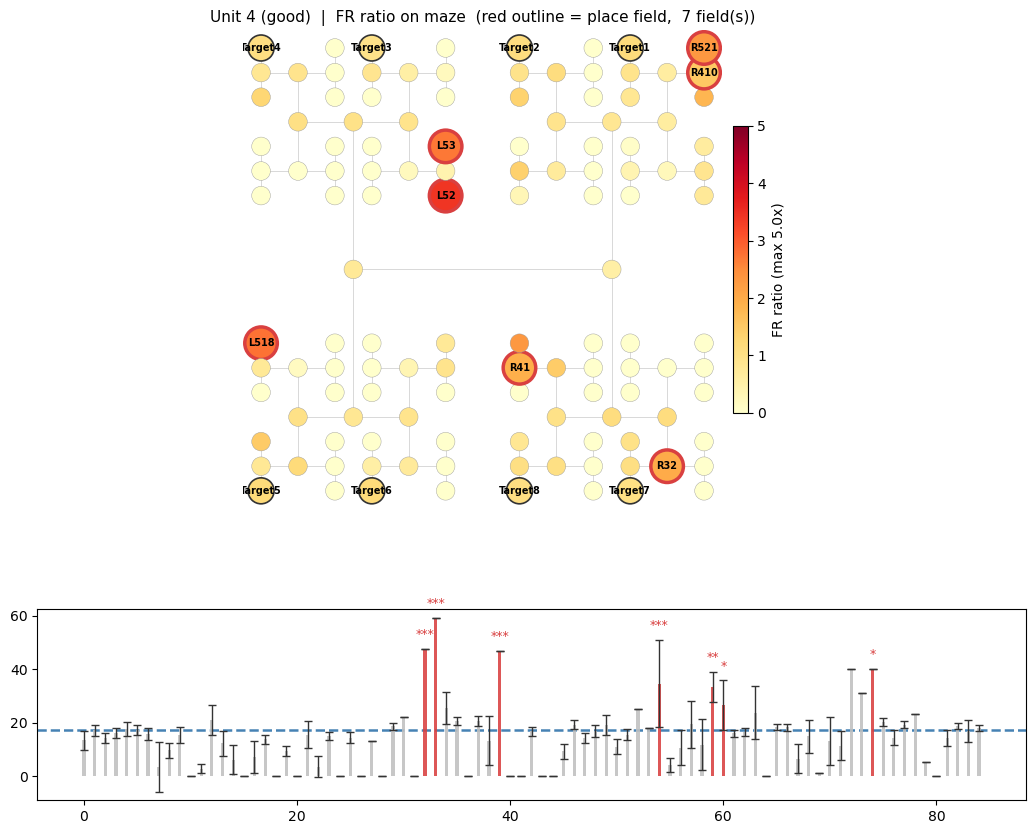

In [ ]:
plot_place_cells(
    results_df        = results_df_pc,
    place_cells_dict  = place_cells,
    spike_matrix_pc   = spike_matrix_pc,
    node_summary_df   = node_summary_df,
    min_maze_frame    = min_maze_frame,
    n_maze_frames     = n_maze_frames,
    pc_unit_ids       = pc_unit_ids,
    pc_unit_group     = pc_unit_group,
    save_dir          = f'place_cell_plots_{DD}_{MM}_{YYYY}',
    min_visit_s       = 0.1,
    heatmap_clip_ratio= 5.0,
    node_positions    = node_positions,
    G                 = G,
    port_map          = port_map,   # TargetN labels on port nodes
)


## Place Cell Analysis — Method 2 (session-wide raw mean FR)

Method 1 (above) computes the baseline "overall FR" from the same
frame-matched spike count used for per-node accounting
(`spike_matrix_pc`), i.e. spikes that successfully matched to a video frame
within half a frame period.

Method 2 instead computes the baseline directly from the **raw spike
count** for each unit (every spike in `maze_spike_clusters` across all
maze trials, with no frame-matching exclusion), divided by the total
session time:

```
overall_fr_hz_v2 = total_raw_spike_count / total_session_time_s
```

Per-node spike counts/occupancy are unchanged (still require frame
matching to know *where* the animal was), only the reference/baseline
FR — and therefore the FR ratio and the binomial test's `n_total` — differ.

In [ ]:
# ── Method 2: raw spike count / total session time as baseline ─────────────
total_spikes_raw = np.zeros(n_units_pc, dtype=np.float64)
for m_idx in range(len(maze_spike_clusters)):
    sc_all = np.asarray(maze_spike_clusters[m_idx]).flatten().astype(np.int64)
    uniq, counts = np.unique(sc_all, return_counts=True)
    for u, c in zip(uniq, counts):
        u_idx = uid_to_pcidx.get(int(u), -1)
        if u_idx >= 0:
            total_spikes_raw[u_idx] += c

total_session_time_s = n_maze_frames / VIDEO_FPS   # same elapsed time as method 1

print(f'Total session time : {total_session_time_s:.1f} s')
print('Mean raw spike count vs frame-matched spike count (good units):')
print(f'  method 1 (frame-matched): {total_spikes_per_unit[:len(good_units)].mean():.0f}')
print(f'  method 2 (raw)          : {total_spikes_raw[:len(good_units)].mean():.0f}')

records_v2 = []
for nd in nodes:
    occ_f = node_occ_frames[nd]
    if occ_f == 0:
        continue
    p_occ      = occ_f / n_maze_frames
    occ_time_s = occ_f / VIDEO_FPS

    for u_idx in range(n_units_pc):
        n_nd     = int(node_spikes_agg[nd][u_idx])
        n_tot_v2 = int(total_spikes_raw[u_idx])
        if n_tot_v2 == 0:
            continue
        n_nd = min(n_nd, n_tot_v2)   # per-node count can't exceed session total

        node_fr       = n_nd / occ_time_s
        overall_fr_v2 = n_tot_v2 / total_session_time_s
        fr_ratio_v2   = node_fr / (overall_fr_v2 + 1e-9)
        p_val         = binomtest(n_nd, n_tot_v2, p_occ, alternative='greater').pvalue

        records_v2.append(dict(
            cluster_id      = int(pc_unit_ids[u_idx]),
            unit_group      = pc_unit_group[u_idx],
            node_name       = nd,
            node_fr_hz      = node_fr,
            overall_fr_hz   = overall_fr_v2,
            fr_ratio        = fr_ratio_v2,
            node_spikes     = n_nd,
            node_occ_frames = occ_f,
            node_occ_s      = occ_time_s,
            p_val_raw       = p_val,
        ))

results_df_pc_v2 = pd.DataFrame(records_v2)
results_df_pc_v2['p_val_fdr'] = bh_fdr(results_df_pc_v2['p_val_raw'].values)
results_df_pc_v2['significant'] = (
    (results_df_pc_v2['p_val_fdr'] < 0.05) &
    (results_df_pc_v2['fr_ratio']  >= 1.5)
)

place_cells_v2 = {}
for row in results_df_pc_v2[results_df_pc_v2['significant']].itertuples(index=False):
    uid = int(row.cluster_id)
    place_cells_v2.setdefault(uid, []).append(row.node_name)

save_dir_v2 = f'place_cell_results_v2_{DD}_{MM}_{YYYY}'
os.makedirs(save_dir_v2, exist_ok=True)
results_df_pc_v2.to_csv(f'{save_dir_v2}/place_cell_results.csv', index=False)
with open(f'{save_dir_v2}/place_cells_dict.pkl', 'wb') as fh:
    pickle.dump(place_cells_v2, fh)

sig2   = results_df_pc_v2[results_df_pc_v2['significant']]
n_good2 = sum(1 for u in place_cells_v2 if pc_unit_group[uid_to_pcidx[u]] == 'good')
print(f"\nMethod 2: tested {len(results_df_pc_v2):,} pairs, "
      f"{len(sig2)} significant, {len(place_cells_v2)} place cells "
      f"({n_good2} good, {len(place_cells_v2)-n_good2} mua)")
print(f'Saved to {save_dir_v2}/')


Total session time : 3491.7 s
Mean raw spike count vs frame-matched spike count (good units):
  method 1 (frame-matched): 18047
  method 2 (raw)          : 25543

Method 2: tested 14,535 pairs, 40 significant, 25 place cells (9 good, 16 mua)
Saved to place_cell_results_v2_10_09_2025/


In [ ]:
plot_place_cells(
    results_df        = results_df_pc_v2,
    place_cells_dict  = place_cells_v2,
    spike_matrix_pc   = spike_matrix_pc,
    node_summary_df   = node_summary_df,
    min_maze_frame    = min_maze_frame,
    n_maze_frames     = n_maze_frames,
    pc_unit_ids       = pc_unit_ids,
    pc_unit_group     = pc_unit_group,
    save_dir          = f'place_cell_plots_v2_{DD}_{MM}_{YYYY}',
    min_visit_s       = 0.1,
    heatmap_clip_ratio= 5.0,
    node_positions    = node_positions,
    G                 = G,
    port_map          = port_map,
)


/tmp/ipykernel_822986/1495367425.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_r = cm.get_cmap('YlOrRd')


  unit 4 (good) -> ['L52']
  unit 107 (mua) -> ['R527']
  unit 177 (mua) -> ['L52']
  unit 207 (mua) -> ['L518']
  unit 265 (mua) -> ['L52', 'R527']
  unit 271 (mua) -> ['L518', 'L52', 'L53']
  unit 305 (mua) -> ['L518', 'L52', 'R41', 'R527']
  unit 331 (mua) -> ['L520', 'R32']
  unit 343 (good) -> ['L518']
  unit 374 (mua) -> ['L52']
  unit 390 (mua) -> ['L518']
  unit 399 (mua) -> ['R522']
  unit 435 (good) -> ['R527']
  unit 438 (good) -> ['R32']
  unit 546 (mua) -> ['R37', 'R527']
  unit 575 (good) -> ['L511', 'L52', 'L53', 'R32', 'R414', 'R520']
  unit 646 (good) -> ['R521']
  unit 685 (mua) -> ['R41', 'R521']
  unit 734 (mua) -> ['L52']
  unit 865 (good) -> ['R410']
  unit 867 (mua) -> ['L52', 'R527']
  unit 962 (mua) -> ['R527']
  unit 1012 (mua) -> ['R527']
  unit 1014 (good) -> ['R522']
  unit 1019 (good) -> ['L34']

Summary heatmap -> place_cell_plots_v2_10_09_2025/heatmap_all_place_cells.png
Plotted 25 place cells  (9 good, 16 mua)
All plots in: place_cell_plots_v2_10_09_202

### Comparison: Method 1 vs Method 2 overall mean FR

For every unit identified as a place cell under **Method 1**, compare its
overall mean FR computed the two ways. Large discrepancies would indicate
that frame-matching is losing a non-trivial fraction of spikes for that unit.

In [ ]:
import matplotlib.pyplot as plt

m1_overall = results_df_pc.drop_duplicates('cluster_id').set_index('cluster_id')['overall_fr_hz']
m2_overall = results_df_pc_v2.drop_duplicates('cluster_id').set_index('cluster_id')['overall_fr_hz']

place_unit_ids_m1 = sorted(place_cells.keys())
comp_rows = []
for uid in place_unit_ids_m1:
    fr1 = float(m1_overall.get(uid, np.nan))
    fr2 = float(m2_overall.get(uid, np.nan))
    grp = pc_unit_group[uid_to_pcidx[uid]]
    comp_rows.append(dict(
        cluster_id=uid, unit_group=grp,
        mean_fr_method1=fr1, mean_fr_method2=fr2,
        pct_diff=100 * (fr2 - fr1) / fr1 if fr1 else np.nan,
    ))
comp_df = pd.DataFrame(comp_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 6))

# Scatter: method 1 vs method 2
colors_scatter = ['#2E7D32' if g == 'good' else '#9E9E9E' for g in comp_df['unit_group']]
ax1.scatter(comp_df['mean_fr_method1'], comp_df['mean_fr_method2'],
            c=colors_scatter, s=5, alpha=0.75, edgecolor='black', linewidth=0.3)
max_val = max(comp_df['mean_fr_method1'].max(), comp_df['mean_fr_method2'].max()) * 1.1
ax1.plot([0, max_val], [0, max_val], 'k--', lw=1, alpha=0.6, label='y = x')
for _, r in comp_df.iterrows():
    ax1.annotate(str(int(r['cluster_id'])), (r['mean_fr_method1'], r['mean_fr_method2']),
                 fontsize=3, alpha=0.7, xytext=(3, 3), textcoords='offset points')
ax1.set_xlabel('Method 1: frame-matched mean FR (Hz)', fontsize=10)
ax1.set_ylabel('Method 2: raw spike-count mean FR (Hz)', fontsize=10)
ax1.set_title('Overall mean FR per unit', fontsize=11)
ax1.legend(fontsize=8)
ax1.spines[['top', 'right']].set_visible(False)

# Grouped bar chart per unit
x = np.arange(len(comp_df))
width = 0.35
ax2.bar(x - width/2, comp_df['mean_fr_method1'], width, label='Method 1', color='steelblue')
ax2.bar(x + width/2, comp_df['mean_fr_method2'], width, label='Method 2', color='darkorange')
ax2.set_xticks(x)
ax2.set_xticklabels(
    [f"{int(r.cluster_id)}" for r in comp_df.itertuples()],
    fontsize=6, rotation=90
)
ax2.set_ylabel('Overall mean FR (Hz)', fontsize=10)
ax2.set_title('Per-unit comparison (place cells from Method 1)', fontsize=11)
ax2.legend(fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
comp_dir = f'place_cell_results_{DD}_{MM}_{YYYY}'
os.makedirs(comp_dir, exist_ok=True)
fig.savefig(f'{comp_dir}/mean_fr_method_comparison.png', dpi=250, bbox_inches='tight')
plt.close(fig)
comp_df.to_csv(f'{comp_dir}/mean_fr_method_comparison.csv', index=False)

print(comp_df.to_string(index=False))
print(f"\nMean absolute % diff: {comp_df['pct_diff'].abs().mean():.1f}%")
print(f'Saved comparison to {comp_dir}/mean_fr_method_comparison.png')


 cluster_id unit_group  mean_fr_method1  mean_fr_method2  pct_diff
          4       good        17.269974        24.766269 43.406521
          5        mua        12.765324        17.741947 38.985484
          7        mua         3.816738         5.894794 54.445862
         21        mua         0.273504         0.337083 23.246073
         24       good         3.185245         3.990291 25.274231
         25       good         2.750503         4.037832 46.803415
         26       good        10.477343        14.147735 35.031708
         27        mua         1.551382         2.238435 44.286505
         34        mua         0.529538         0.693640 30.989724
         40        mua        14.275179        20.438322 43.173839
         51        mua         1.481503         2.168842 46.394742
         77        mua         5.226643         7.741732 48.120548
         96       good        10.035441        14.117664 40.678063
        107        mua         3.045486         4.288138 40.80